# Notebook 1 - Preparacion del modelo con COBRApy

Objetivo:
- Cargar `yeast-GEM.xml` en un objeto `model`.
- Aplicar la preparacion metabolica usada en el pipeline.
- Exportar `out/S.csv`, `out/lb.csv`, `out/ub.csv`.
- Exportar tambien `out/rxn_ids.txt`, `out/met_ids.txt` y `out/model_ready.xml`.


We start by defining outdir of the main files. 

In [22]:
from pathlib import Path
import numpy as np
import cobra
from cobra.util.array import create_stoichiometric_matrix

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

SBML_PATH = Path("yeast-GEM.xml")
assert SBML_PATH.is_file(), f"No se encontro SBML: {SBML_PATH.resolve()}"

MODEL_READY_SBML = OUT_DIR / "model_ready.xml"
S_FILE = OUT_DIR / "S.csv"
LB_FILE = OUT_DIR / "lb.csv"
UB_FILE = OUT_DIR / "ub.csv"
RXN_FILE = OUT_DIR / "rxn_ids.txt"
MET_FILE = OUT_DIR / "met_ids.txt"

print(f"SBML: {SBML_PATH.resolve()}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")


SBML: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\yeast-GEM.xml
OUT_DIR: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out


We then load and check though COBRA Toolbox the metabolic model. We use Yeast9 in this work.

In [23]:
model = cobra.io.read_sbml_model(str(SBML_PATH))

print("Modelo cargado")
print(f"- Metabolitos: {len(model.metabolites)}")
print(f"- Reacciones: {len(model.reactions)}")
print(f"- Genes: {len(model.genes)}")

rxn_ids = {r.id for r in model.reactions}
obj_candidates = ["r_2111"]
obj_id = next((rid for rid in obj_candidates if rid in rxn_ids), None)
print(f"- Objetivo candidato: {obj_id}")


Modelo cargado
- Metabolitos: 2806
- Reacciones: 4131
- Genes: 1161
- Objetivo candidato: r_2111


Definition of main reactions, corresponding to primary metabolites included in ODE model, as well as other relevant reactions related to growth and maintenance.

In [24]:
key_rxn_ids = ["r_1761", "r_1714", "r_1709", "r_1992", "r_4046", "r_4598"]
METS_ANAEROBIC_BYPASS = ["s_3714[c]", "s_1198[c]", "s_1203[c]", "s_1207[c]", "s_1212[c]", "s_0529[c]"]

rxn_idx = {r.id: i + 1 for i, r in enumerate(model.reactions)}
met_idx = {m.id: i + 1 for i, m in enumerate(model.metabolites)}

rxn_nms = {r.id: r.name for r in model.reactions}
met_nms = {m.id: m.name for m in model.metabolites}

print()
print("Chequeo de reacciones clave")
for rid in key_rxn_ids:
    found = rid in rxn_idx
    idx = rxn_idx[rid] if found else -1
    name = rxn_nms.get(rid, "Unknown")
    print(f"- {rid:8s} found={found} idx={idx} name={name}")

print()
print("Chequeo de metabolitos clave")
for mid in METS_ANAEROBIC_BYPASS:
    found = mid in met_idx
    alt = mid.replace("[c]", "")
    found_alt = (not found) and (alt in met_idx)
    idx = met_idx[mid] if found else (met_idx[alt] if found_alt else -1)
    print(f"- {mid:10s} found={found or found_alt} idx={idx} name={met_nms.get(mid, met_nms.get(alt, 'Unknown'))}")



Chequeo de reacciones clave
- r_1761   found=True idx=1221 name=ethanol exchange
- r_1714   found=True idx=1180 name=D-glucose exchange
- r_1709   found=True idx=1175 name=D-fructose exchange
- r_1992   found=True idx=1408 name=oxygen exchange
- r_4046   found=True idx=3411 name=non-growth associated maintenance reaction
- r_4598   found=True idx=3948 name=cofactor pseudoreaction

Chequeo de metabolitos clave
- s_3714[c]  found=True idx=2208 name=heme a
- s_1198[c]  found=True idx=942 name=NAD
- s_1203[c]  found=True idx=947 name=NADH
- s_1207[c]  found=True idx=951 name=NADP(+)
- s_1212[c]  found=True idx=955 name=NADPH
- s_0529[c]  found=True idx=400 name=coenzyme A


Adjustement of the growth reaction formula to enable growth under anaerobic conditions.

In [25]:
def find_metabolite(mdl, mid):
    met_ids = {m.id for m in mdl.metabolites}
    if mid in met_ids:
        return mdl.metabolites.get_by_id(mid)
    clean = mid.replace("[c]", "")
    if clean in met_ids:
        return mdl.metabolites.get_by_id(clean)
    return None

print(f"Reacción r_4598 antes: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

removed = 0.0
if "r_4598" in {r.id for r in model.reactions}:
    rcof = model.reactions.get_by_id("r_4598")
    updates = {}
    for mid in METS_ANAEROBIC_BYPASS:
        met = find_metabolite(model, mid)
        if met is None:
            continue
        coef = rcof.metabolites.get(met, 0.0)
        if coef != 0:
            updates[met] = -coef
            removed += abs(coef)
    if updates:
        rcof.add_metabolites(updates)

print(f"- Metabolitos eliminados de r_4598: {len(METS_ANAEROBIC_BYPASS)}")
print(f"Reacción r_4598 actualizada: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

Reacción r_4598 antes: 0.000190000006114133 s_0529 + 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.00264999992214143 s_1198 + 0.000150000007124618 s_1203 + 0.000569999974686652 s_1207 + 0.00270000007003546 s_1212 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 + 9.99999997475243e-07 s_3714 --> s_4205
- Metabolitos eliminados de r_4598: 6
Reacción r_4598 actualizada: 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 --> s_4205


Definición de medio de cultivo en condiciones anaeróbicas

In [26]:
# --- Configuracion de bounds con trazabilidad ---

# Index rapido por ID para evitar busquedas repetidas
rxn_by_id = {r.id: r for r in model.reactions}
change_log = []

# Trazas configurables (ajustables)
VITAMIN_TRACE_LB = -1e-2   # traza mas elevada para vitaminas
ION_TRACE_LB = -1e-3       # trazas para iones esenciales


def _fmt_bound(x):
    return f"{x:.3f}" if isinstance(x, (int, float)) else str(x)


def _short(txt, n=70):
    txt = (txt or "").strip()
    return txt if len(txt) <= n else txt[: n - 3] + "..."


def set_bounds_logged(mdl, rid, lb=None, ub=None, group="", note=""):
    rec = {
        "group": group,
        "rid": rid,
        "note": note,
        "status": "MISSING",
        "name": "",
        "old_lb": None,
        "old_ub": None,
        "new_lb": None,
        "new_ub": None,
    }

    if rid not in rxn_by_id:
        print(f"  [MISSING] {rid:8s} | no existe en el modelo")
        change_log.append(rec)
        return rec

    r = rxn_by_id[rid]
    old_lb, old_ub = float(r.lower_bound), float(r.upper_bound)
    new_lb = old_lb if lb is None else float(lb)
    new_ub = old_ub if ub is None else float(ub)

    r.lower_bound = new_lb
    r.upper_bound = new_ub

    rec.update(
        {
            "status": "UPDATED",
            "name": r.name,
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": new_lb,
            "new_ub": new_ub,
        }
    )
    change_log.append(rec)

    print(
        f"  [OK] {rid:8s} | {_short(r.name, 46):46s} | "
        f"({_fmt_bound(old_lb):>8s}, {_fmt_bound(old_ub):>8s}) -> "
        f"({_fmt_bound(new_lb):>8s}, {_fmt_bound(new_ub):>8s})"
    )
    return rec


def apply_group(group_name, reaction_ids, lb=None, ub=None, note=""):
    print("\n" + "=" * 100)
    print(f"Grupo: {group_name}")
    print(f"Objetivo de bounds: lb={lb if lb is not None else 'sin cambio'}, ub={ub if ub is not None else 'sin cambio'}")
    if note:
        print(f"Nota: {note}")
    print("-" * 100)
    for rid in reaction_ids:
        set_bounds_logged(model, rid, lb=lb, ub=ub, group=group_name, note=note)


# Reglas de manipulacion, agrupadas por sentido biologico/proceso
ALL_N_SOURCE_IDS = [
    "r_1654", "r_1904", "r_1891", "r_1889", "r_1880", "r_1881",
    "r_1873", "r_1879", "r_1810", "r_1906", "r_1911", "r_1914",
    "r_1899", "r_1897", "r_1903", "r_1913", "r_1912", "r_1893",
    "r_1900", "r_1902", "r_1883", "r_1987", "r_1800",
]

KINETIC_N_SOURCE_IDS = [
    "r_1654",  # NH4+
    "r_1879",  # Arg
    "r_1891",  # Gln
    "r_1889",  # Glu
    "r_1906",  # Ser
    "r_1911",  # Thr
    "r_1873",  # Ala
    "r_1912",  # Trp
]

GROUP_RULES = [
    {
        "group": "Anaerobiosis (O2 apagado)",
        "ids": ["r_1992"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Forzar intercambio de oxigeno en cero.",
    },
    {
        "group": "Suplementos anaerobicos abiertos",
        "ids": ["r_1757", "r_1915", "r_1994", "r_2106", "r_2134", "r_2137", "r_2189"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Permitir captacion de suplementos en anaerobiosis.",
    },
    {
        "group": "Shuttles cerrados",
        "ids": ["r_0713", "r_0714", "r_0487"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Se aplican bounds asimetricos por reaccion.",
    },
    {
        "group": "Fuentes de carbono",
        "ids": ["r_1714", "r_1709"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Glucosa y fructosa solo como uptake.",
    },
    {
        "group": "Fuentes de nitrogeno (todos)",
        "ids": ALL_N_SOURCE_IDS,
        "lb": 0.0,
        "ub": 0.0,
        "note": "23 fuentes de N inhabilitadas para captacion.",
    },
    {
        "group": "Fuentes de nitrogeno (medio vinico) - cinetica",
        "ids": KINETIC_N_SOURCE_IDS,
        "lb": -1000.0,
        "ub": 0.0,
        "note": "7 fuentes de N cineticas habilitadas para captacion.",
    },
    {
        "group": "Vitaminas",
        "ids": ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"],
        "lb": VITAMIN_TRACE_LB,
        "ub": 0.0,
        "note": "Vitaminas en traza elevada (evitar uso masivo como carbono).",
    },
    {
        "group": "Fosfato abierto",
        "ids": ["r_2005"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de fosfato para diagnostico.",
    },
    {
        "group": "Sulfato abierto",
        "ids": ["r_2060"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de sulfato para diagnostico.",
    },
    {
        "group": "Iones esenciales",
        "ids": ["r_2020", "r_1861", "r_4596", "r_4597", "r_4594", "r_4600", "r_4595", "r_4593"],
        "lb": ION_TRACE_LB,
        "ub": 0.0,
        "note": "Iones en traza.",
    },
    {
        "group": "Productos abiertos",
        "ids": ["r_1761", "r_1808", "r_1634", "r_2056", "r_1549", "r_1546", "r_1552", "r_1765", "r_1867", "r_1866", "r_1862", "r_1865"],
        "lb": 0.0,
        "ub": 1000.0,
        "note": "Excrecion permitida.",
    },
    {
        "group": "Agua y protones",
        "ids": ["r_2100", "r_1832"],
        "lb": -1000.0,
        "ub": 1000.0,
    },
]

# Aplicar grupos estandar
for rule in GROUP_RULES:
    # Caso especial: shuttles con limites asimetricos
    if rule["group"] == "Shuttles cerrados":
        print("\n" + "=" * 100)
        print(f"Grupo: {rule['group']}")
        print("Nota: Cierres especificos por reaccion")
        print("-" * 100)
        set_bounds_logged(model, "r_0713", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0714", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0487", lb=None, ub=0.0, group=rule["group"], note="Cerrar direccion directa")
        continue

    apply_group(
        rule["group"],
        rule["ids"],
        lb=rule.get("lb", None),
        ub=rule.get("ub", None),
        note=rule.get("note", ""),
    )

# ATP de mantenimiento fijo
print("\n" + "=" * 100)
print("Grupo: ATP de mantenimiento")
print("-" * 100)
set_bounds_logged(model, "r_4046", lb=0.7, ub=0.7, group="ATPM", note="ATPM fijo")

# Resumen global de cambios
updated = [x for x in change_log if x["status"] == "UPDATED"]
missing = [x for x in change_log if x["status"] == "MISSING"]
print("\n" + "=" * 100)
print("Resumen de aplicacion de bounds")
print("=" * 100)
print(f"Total reglas procesadas: {len(change_log)}")
print(f"- Reacciones actualizadas: {len(updated)}")
print(f"- Reacciones faltantes:   {len(missing)}")
if missing:
    print("IDs faltantes:")
    for m in missing:
        print(f"  - {m['rid']} (grupo: {m['group']})")

# Chequeo final de reacciones clave con nombre y ecuacion
KEY_RXN_LABELS = {
    "r_1992": "Intercambio O2",
    "r_1714": "Uptake glucosa",
    "r_1709": "Uptake fructosa",
    "r_4046": "Mantenimiento ATP",
    "r_1761": "Intercambio etanol",
}

print("\n" + "=" * 100)
print("Chequeo final (reacciones clave)")
print("=" * 100)
for rid, label in KEY_RXN_LABELS.items():
    if rid not in rxn_by_id:
        print(f"- {label:20s} | {rid:8s} | MISSING")
        continue
    r = rxn_by_id[rid]
    eq = _short(getattr(r, "reaction", ""), n=90)
    print(
        f"- {label:20s} | {rid:8s} | {_short(r.name, 42):42s} | "
        f"lb={r.lower_bound:.3f}, ub={r.upper_bound:.3f}"
    )
    if eq:
        print(f"    ecuacion: {eq}")



Grupo: Anaerobiosis (O2 apagado)
Objetivo de bounds: lb=0.0, ub=0.0
Nota: Forzar intercambio de oxigeno en cero.
----------------------------------------------------------------------------------------------------
  [OK] r_1992   | oxygen exchange                                | (-1000.000, 1000.000) -> (   0.000,    0.000)

Grupo: Suplementos anaerobicos abiertos
Objetivo de bounds: lb=-1000.0, ub=0.0
Nota: Permitir captacion de suplementos en anaerobiosis.
----------------------------------------------------------------------------------------------------
  [OK] r_1757   | ergosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1915   | lanosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1994   | palmitoleate exchange                          | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_2106   | zymosterol exchange                            | (   0.000, 1000.000) -> (-10

# Chequeo inicial de crecimiento

Resolvemos FBA empleando cobra toolbox

In [27]:
# Diagnostico FBA rapido (antes de exportar a Julia)
print("\n" + "=" * 100)
print("Chequeo FBA con bounds actuales")
print("=" * 100)

solution = model.optimize()
print(f"status: {solution.status}")
print(f"objective ({model.objective.expression}): {solution.objective_value:.6g}")

if solution.status != "optimal":
    print("[WARN] El problema FBA no llego a optimo. Revisar bounds y consistencia del modelo.")

# Convencion: biomasa esperada positiva
if solution.objective_value <= 1e-8:
    print("[WARN] Crecimiento nulo o casi nulo (objective <= 1e-8).")
else:
    print("[OK] El modelo muestra crecimiento bajo bounds actuales.")

# Flujos clave: etiqueta biologica + ID + nombre de reaccion
key_flux_map = [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]

print("\nFlujos clave (FBA):")
for label, rid in key_flux_map:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# Diagnostico adicional de posibles bloqueos (uptakes de C/N)
print("\nUptakes de C/N habilitados (lb, ub, flujo):")
for rid in ["r_1714", "r_1709"] + KINETIC_N_SOURCE_IDS:
    if rid not in rxn_by_id:
        print(f"- {rid:8s}: MISSING")
        continue
    rxn = rxn_by_id[rid]
    v = solution.fluxes.get(rid, float("nan"))
    print(f"- {rxn.name:40s} ({rid}) | lb={rxn.lower_bound:8.3f}, ub={rxn.upper_bound:8.3f}, v={v: .6g}")



Chequeo FBA con bounds actuales
status: optimal
objective (1.0*r_2111 - 1.0*r_2111_reverse_58b69): 0.275482
[OK] El modelo muestra crecimiento bajo bounds actuales.

Flujos clave (FBA):
- Biomasa              (r_2111) | growth | v =  0.275482
- Uptake glucosa       (r_1714) | D-glucose exchange | v =  0
- Uptake fructosa      (r_1709) | D-fructose exchange | v = -16.6185
- Produccion etanol    (r_1761) | ethanol exchange | v =  0
- Intercambio O2       (r_1992) | oxygen exchange | v =  0
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v =  0.7

Uptakes de C/N habilitados (lb, ub, flujo):
- D-glucose exchange                       (r_1714) | lb=-1000.000, ub=   0.000, v= 0
- D-fructose exchange                      (r_1709) | lb=-1000.000, ub=   0.000, v=-16.6185
- ammonium exchange                        (r_1654) | lb=-1000.000, ub=   0.000, v= 0
- L-arginine exchange                      (r_1879) | lb=-1000.000, ub=   0.000, v=-0.129808
- L-glutamine ex

# Chequeo de variabilida de flujos 

Empleamos FVA de cobra toolbox para chequear variabilidad sobre flujos principales, así como fuentes de nitrógeno

In [28]:
# FVA dirigido + pruebas de sensibilidad de fuentes de carbono/nitrogeno
print("\n" + "=" * 100)
print("FVA dirigido (diagnostico de degeneracion y alternativas de flujo)")
print("=" * 100)

fva_ids = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids = [rid for rid in fva_ids if rid in rxn_by_id]

fva_df = cobra.flux_analysis.flux_variability_analysis(
    model,
    reaction_list=fva_ids,
    fraction_of_optimum=0.99,
)

print("FVA @99% del optimo (min, max):")
for rid in fva_ids:
    rxn = rxn_by_id[rid]
    mn = float(fva_df.loc[rid, "minimum"])
    mx = float(fva_df.loc[rid, "maximum"])
    print(f"- {rxn.name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")

print("\nLectura rapida:")
print("- En exchanges de uptake, valores negativos = consumo posible.")
print("- Si glucosa/fructosa tienen min ~ 0 y aminoacidos min << 0, el modelo prefiere aminoacidos.")


def _solve_with_bounds(base_model, lb_updates):
    m = base_model.copy()
    for rid, new_lb in lb_updates.items():
        if rid in {r.id for r in m.reactions}:
            m.reactions.get_by_id(rid).lower_bound = float(new_lb)
    sol = m.optimize()
    return sol

# Escenario A: bloquear aminoacidos cineticos -> fuerza dependencia de azucares
lb_block_n = {rid: 0.0 for rid in KINETIC_N_SOURCE_IDS if rid in rxn_by_id}
sol_no_n = _solve_with_bounds(model, lb_block_n)

# Escenario B: bloquear azucares -> mide crecimiento posible solo con N/suplementos
lb_block_sugars = {"r_1714": 0.0, "r_1709": 0.0}
sol_no_sugar = _solve_with_bounds(model, lb_block_sugars)

print("\n" + "=" * 100)
print("Pruebas de sensibilidad (objetivo biomasa)")
print("=" * 100)
print(f"- Base (actual):                 status={solution.status:8s}  obj={solution.objective_value: .6g}")
print(f"- Sin aminoacidos cineticos:     status={sol_no_n.status:8s}  obj={sol_no_n.objective_value: .6g}")
print(f"- Sin azucares (glu+fru):        status={sol_no_sugar.status:8s}  obj={sol_no_sugar.objective_value: .6g}")

print("\nInterpretacion:")
print("- Si 'Sin azucares' mantiene crecimiento alto, hay ruta alternativa dominante (ej. aminoacidos).")
print("- Si 'Sin aminoacidos cineticos' cae fuerte o 0, el modelo depende de esas fuentes de N como C/N.")



FVA dirigido (diagnostico de degeneracion y alternativas de flujo)
FVA @99% del optimo (min, max):
- growth                                   (r_2111) | min= 0.272727  max= 0.275482
- D-glucose exchange                       (r_1714) | min=-1000  max= 0
- D-fructose exchange                      (r_1709) | min=-1000  max= 0
- ethanol exchange                         (r_1761) | min= 0  max= 1000
- oxygen exchange                          (r_1992) | min= 0  max= 0
- non-growth associated maintenance reaction (r_4046) | min= 0.7  max= 0.7
- ammonium exchange                        (r_1654) | min=-1000  max= 0
- L-arginine exchange                      (r_1879) | min=-1000  max= 0
- L-glutamine exchange                     (r_1891) | min=-1000  max= 0
- L-glutamate exchange                     (r_1889) | min=-1000  max= 0
- L-serine exchange                        (r_1906) | min=-1000  max= 0
- L-threonine exchange                     (r_1911) | min=-1000  max= 0
- L-alanine exchange     

# Integración de modelo ODE para efectos de restricciones dinámicas

Implementamos cinética de modelo de Zenteno et al. 2010 para modelamiento de FA de vinos sobre flujos involucrados, que incluye glucosa, fructosa, YAN, etanol y biomasa. Alternamos con diferentes sets de parámetros, específicamente sobre set obtenido de parámetros del modelo vs parámetros calibrados con ensayos 2024-2025 en SB. 


In [29]:
# Aplicar en COBRApy las mismas restricciones clave que en Notebook 2 (aprox. en t=0)
print("\n" + "=" * 100)
print("Imposicion de restricciones estilo Notebook 2 sobre flujos clave")
print("=" * 100)

import os
import re

# Switch principal: sin capeo de productos/biomasa (recomendado para diagnostico FBA/FVA)
APPLY_PRODUCT_CAPS = False
print(f"Modo capeo de producto/biomasa: {'ON' if APPLY_PRODUCT_CAPS else 'OFF (sin capeo)'}")

# --- Parametros con switch entre legacy y paper Zenteno ---
ZENTENO_PARAM_SET = os.getenv("ZENTENO_PARAM_SET", "paper2010").strip().lower()
if ZENTENO_PARAM_SET == "paper2010":
    MU0_nom    = 0.18
    YXN_nom    = 19.69
    YXG_nom    = 1.60
    YXF_nom    = 1.60
    YEG_nom    = 0.49
    YEF_nom    = 0.49
    Kn0_nom    = 0.01
    Kg0_nom    = 7.5
    Kf0_nom    = 7.5
    Kig0_nom   = 55.0
    Kie0_nom   = 40.0
    Kd0_nom    = 0.00044
    betaG0_nom = 0.225
    betaF0_nom = 0.225
elif ZENTENO_PARAM_SET == "legacy_calibrated":
    MU0_nom    = 0.141665
    YXN_nom    = 9.80576
    YXG_nom    = 0.394345
    YXF_nom    = 0.18622
    YEG_nom    = 0.14133
    YEF_nom    = 0.96932
    Kn0_nom    = 0.226882
    Kg0_nom    = 3.1514
    Kf0_nom    = 2.97625
    Kig0_nom   = 29.5276
    Kie0_nom   = 2.99809
    Kd0_nom    = 0.0000311736
    betaG0_nom = 1.41182
    betaF0_nom = 8.49482
else:
    raise ValueError(f"ZENTENO_PARAM_SET invalido: {ZENTENO_PARAM_SET}")

MU0 = MU0_nom
YEG = YEG_nom
YEF = YEF_nom
YXN = YXN_nom
MRATE_0 = 0.01

R_GAS = 8.314
R = R_GAS
EPS = 1e-9

try:
    T_BASE = float(os.getenv("T_CONST", "298.15"))
except ValueError:
    T_BASE = 293.15

T_STEPS = [36.0, 96.0]
T_DELTAS = [5.0, 3.0]
T_STEEP = 0.5

def dynamic_temperature(t):
    val = T_BASE
    for step_t, delta_t in zip(T_STEPS, T_DELTAS):
        sigmoid = 1.0 / (1.0 + np.exp(-T_STEEP * (t - step_t)))
        val += delta_t * sigmoid
    return val

def death_rate_T(E, T_val):
    Td = -0.0001 * E**3 + 0.0049 * E**2 - 0.1279 * E + 315.89
    s = 0.5 * (1.0 + np.tanh(0.5 * (T_val - Td)))
    base = Kd0_nom * np.exp(0.0415 * E + (130000.0 * (T_val - 305.65)) / (305.65 * R * T_val))
    return base * s

SQRT_2PI = np.sqrt(2.0 * np.pi)
def smooth_injection(t, t_shot, dose, width=1.0):
    if abs(t - t_shot) > 5.0 * width:
        return 0.0
    return (dose / (width * SQRT_2PI)) * np.exp(-0.5 * ((t - t_shot) / width) ** 2)

T_INJ_1 = 0.0
DOSE_1 = 0.0
WIDTH_1 = 5.0
T_INJ_2 = 0.0
DOSE_2 = 0.0
WIDTH_2 = 5.0

print(f"Parametros cineticos cargados: {ZENTENO_PARAM_SET}")
print(
    f"MU0={MU0}, YXN={YXN}, YXG={YXG_nom}, YXF={YXF_nom}, YEG={YEG}, YEF={YEF}, "
    f"Kn0={Kn0_nom}, Kg0={Kg0_nom}, Kf0={Kf0_nom}, Kig0={Kig0_nom}, Kie0={Kie0_nom}, "
    f"Kd0={Kd0_nom}, betaG0={betaG0_nom}, betaF0={betaF0_nom}"
)

MW_N   = 0.014007
MW_GLU = 0.180156
MW_FRU = 0.180156
MW_ETH = 0.046070

# Estado inicial usado en Notebook 2
cX, cN, cG, cF, cE, cO2 = 0.5, 0.14, 110.0, 110.0, 0.0, 0.0
T_val = dynamic_temperature(0.0)

# Factores de temperatura (mismas ecuaciones)
mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

vx = mu
vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
vn = mu / YXN_nom
ve = (betaG + betaF) / MW_ETH

# Composicion de N (misma usada en notebooks)
N_atoms_map = {
    "r_1654": 1.0,
    "r_1879": 4.0,
    "r_1891": 2.0,
    "r_1889": 1.0,
    "r_1906": 1.0,
    "r_1911": 1.0,
    "r_1873": 1.0,
    "r_1912": 2.0,
}
N_profile_map = {
    "r_1654": 0.40,
    "r_1879": 0.20,
    "r_1891": 0.10,
    "r_1889": 0.05,
    "r_1906": 0.05,
    "r_1911": 0.05,
    "r_1873": 0.05,
    "r_1912": 0.10,
}

N_frac_map = {}
for rid in KINETIC_N_SOURCE_IDS:
    n_atoms = N_atoms_map[rid]
    n_profile = N_profile_map[rid]
    N_frac_map[rid] = n_profile / (n_atoms * MW_N)

# Limites fisicos equivalentes a Notebook 2 (en este snapshot)
lim_glu = vg / MW_GLU
lim_fru = vf / MW_FRU
lim_eth = ve
lim_obj = vx
lim_n_map = {rid: vn * N_frac_map[rid] for rid in KINETIC_N_SOURCE_IDS}

print("Limites calculados (snapshot t=0):")
print(f"- lim_glu uptake  : {lim_glu:.6g}")
print(f"- lim_fru uptake  : {lim_fru:.6g}")
print(f"- lim_eth prod    : {lim_eth:.6g}")
print(f"- lim_obj prod    : {lim_obj:.6g}")
print(f"- limN agregado   : {sum(lim_n_map.values()):.6g}")

# Aplicar bounds sobre modelo actual
# Uptakes: -v <= L  -> lb = -L, ub = 0
if "r_1714" in rxn_by_id:
    rxn_by_id["r_1714"].lower_bound = max(rxn_by_id["r_1714"].lower_bound, -lim_glu)
    rxn_by_id["r_1714"].upper_bound = min(rxn_by_id["r_1714"].upper_bound, 0.0)
if "r_1709" in rxn_by_id:
    rxn_by_id["r_1709"].lower_bound = max(rxn_by_id["r_1709"].lower_bound, -lim_fru)
    rxn_by_id["r_1709"].upper_bound = min(rxn_by_id["r_1709"].upper_bound, 0.0)

# N cinetico por fuente: -v_i <= L_i
for rid in KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        Li = lim_n_map[rid]
        rxn_by_id[rid].lower_bound = max(rxn_by_id[rid].lower_bound, -Li)
        rxn_by_id[rid].upper_bound = min(rxn_by_id[rid].upper_bound, 0.0)

# Productos/biomasa: opcional
if APPLY_PRODUCT_CAPS:
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = min(rxn_by_id["r_1761"].upper_bound, lim_eth)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = min(rxn_by_id["r_2111"].upper_bound, lim_obj)
else:
    # Sin capeo: liberar cualquier cap previo de sesiones anteriores
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = max(rxn_by_id["r_1761"].upper_bound, 1000.0)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = max(rxn_by_id["r_2111"].upper_bound, 1000.0)

# O2 anaerobio: v=0
if "r_1992" in rxn_by_id:
    rxn_by_id["r_1992"].lower_bound = 0.0
    rxn_by_id["r_1992"].upper_bound = 0.0

print("\nBounds aplicados a flujos clave:")
for rid in ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        r = rxn_by_id[rid]
        print(f"- {r.name:40s} ({rid}) | lb={r.lower_bound: .6g}, ub={r.upper_bound: .6g}")

# Repetir FBA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FBA con restricciones estilo Notebook 2")
print("=" * 100)

solution_nb2 = model.optimize()
print(f"status: {solution_nb2.status}")
print(f"objective ({model.objective.expression}): {solution_nb2.objective_value:.6g}")

print("\nFlujos clave (FBA restringido):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution_nb2.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")

# Diagnostico de fuente de carbono en la solucion
print("\n" + "=" * 100)
print("Diagnostico de fuentes de carbono (intercambios con uptake)")
print("=" * 100)

def carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    m = re.search(r"C(?![a-z])(\d*)", formula)
    if not m:
        return 0
    g = m.group(1)
    return 1 if g == "" else int(g)

carbon_uptakes = []
for ex in model.exchanges:
    rid = ex.id
    v = float(solution_nb2.fluxes.get(rid, 0.0))
    if v < -1e-9:
        met = next(iter(ex.metabolites.keys()))
        c_atoms = carbon_atoms_from_formula(getattr(met, "formula", ""))
        c_rate = (-v) * c_atoms
        carbon_uptakes.append((rid, ex.name, met.id, met.formula, v, c_atoms, c_rate))

carbon_uptakes.sort(key=lambda x: x[6], reverse=True)

if not carbon_uptakes:
    print("No hay uptakes detectados en exchanges (v<0).")
else:
    total_c = sum(x[6] for x in carbon_uptakes)
    print(f"Top fuentes por C-atoms*|v| (total={total_c:.6g}):")
    for rid, rname, mid, formula, v, c_atoms, c_rate in carbon_uptakes[:15]:
        print(f"- {rname:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_rate: .6g}")

    v_glu = float(solution_nb2.fluxes.get("r_1714", 0.0)) if "r_1714" in rxn_by_id else 0.0
    v_fru = float(solution_nb2.fluxes.get("r_1709", 0.0)) if "r_1709" in rxn_by_id else 0.0
    print("\nChequeo rapido azucares:")
    print(f"- r_1714 (glucosa): v={v_glu: .6g}")
    print(f"- r_1709 (fructosa): v={v_fru: .6g}")

# Repetir FVA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FVA @99% con restricciones estilo Notebook 2")
print("=" * 100)

fva_ids_nb2 = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids_nb2 = [rid for rid in fva_ids_nb2 if rid in rxn_by_id]
fva_nb2_df = cobra.flux_analysis.flux_variability_analysis(
    model,
    reaction_list=fva_ids_nb2,
    fraction_of_optimum=0.99,
)

print("FVA @99% del optimo (restricciones Notebook 2):")
for rid in fva_ids_nb2:
    rxn = rxn_by_id[rid]
    mn = float(fva_nb2_df.loc[rid, "minimum"])
    mx = float(fva_nb2_df.loc[rid, "maximum"])
    print(f"- {rxn.name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")



Imposicion de restricciones estilo Notebook 2 sobre flujos clave
Modo capeo de producto/biomasa: OFF (sin capeo)
Parametros cineticos cargados: paper2010
MU0=0.18, YXN=19.69, YXG=1.6, YXF=1.6, YEG=0.49, YEF=0.49, Kn0=0.01, Kg0=7.5, Kf0=7.5, Kig0=55.0, Kie0=40.0, Kd0=0.00044, betaG0=0.225, betaF0=0.225
Limites calculados (snapshot t=0):
- lim_glu uptake  : 2.92775
- lim_fru uptake  : 1.5037
- lim_eth prod    : 6.47475
- lim_obj prod    : 0.141388
- limN agregado   : 0.384488

Bounds aplicados a flujos clave:
- growth                                   (r_2111) | lb= 0, ub= 1000
- D-glucose exchange                       (r_1714) | lb=-2.92775, ub= 0
- D-fructose exchange                      (r_1709) | lb=-1.5037, ub= 0
- ethanol exchange                         (r_1761) | lb= 0, ub= 1000
- oxygen exchange                          (r_1992) | lb= 0, ub= 0
- non-growth associated maintenance reaction (r_4046) | lb= 0.7, ub= 0.7
- ammonium exchange                        (r_1654) | lb=-0.2

Agregamos leucina dentro de pool aminoacídico por su relevancia en síntesis de isoamyl acetato.

In [30]:
# Activar leucina como fuente N cinética (alineado con el manejo de otros aminoácidos)
print("\n" + "=" * 100)
print("Ajuste: leucina disponible como nutriente cinético")
print("=" * 100)

LEU_ID = "r_1899"

# 1) Incluir leucina en la lista cinética
if "KINETIC_N_SOURCE_IDS" not in globals():
    raise RuntimeError("KINETIC_N_SOURCE_IDS no está definido en sesión.")

if LEU_ID not in KINETIC_N_SOURCE_IDS:
    KINETIC_N_SOURCE_IDS.append(LEU_ID)

# 2) Asegurar composición de N para leucina
N_atoms_map = dict(globals().get("N_atoms_map", {}))
N_atoms_map[LEU_ID] = 1.0  # leucina tiene 1 átomo de N
globals()["N_atoms_map"] = N_atoms_map

N_profile_map = dict(globals().get("N_profile_map", {}))

# Dar a leucina una disponibilidad tipo aminoácido (0.05),
# compensando desde NH4 para mantener el total ~1.0 en el perfil.
target_leu_profile = 0.05
if N_profile_map:
    if LEU_ID not in N_profile_map:
        nh4_id = "r_1654"
        if nh4_id in N_profile_map:
            N_profile_map[nh4_id] = max(0.0, float(N_profile_map[nh4_id]) - target_leu_profile)
        N_profile_map[LEU_ID] = target_leu_profile

    # Completar faltantes y normalizar solo sobre fuentes cinéticas
    for rid in KINETIC_N_SOURCE_IDS:
        N_profile_map.setdefault(rid, 0.0)

    prof_sum = sum(float(N_profile_map.get(rid, 0.0)) for rid in KINETIC_N_SOURCE_IDS)
    if prof_sum > 0:
        for rid in KINETIC_N_SOURCE_IDS:
            N_profile_map[rid] = float(N_profile_map.get(rid, 0.0)) / prof_sum
else:
    # Fallback: distribución uniforme si no existía perfil previo
    uniform = 1.0 / max(1, len(KINETIC_N_SOURCE_IDS))
    N_profile_map = {rid: uniform for rid in KINETIC_N_SOURCE_IDS}

globals()["N_profile_map"] = N_profile_map

# 3) Recalcular fracciones de N por fuente y límites cinéticos
if "MW_N" in globals():
    N_frac_map = {}
    for rid in KINETIC_N_SOURCE_IDS:
        n_atoms = float(N_atoms_map.get(rid, 1.0))
        n_prof = float(N_profile_map.get(rid, 0.0))
        N_frac_map[rid] = n_prof / max(n_atoms * float(MW_N), 1e-12)
    globals()["N_frac_map"] = N_frac_map

    if "vn" in globals():
        lim_n_map = {rid: float(vn) * float(N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}
        globals()["lim_n_map"] = lim_n_map

# 4) Aplicar bounds de leucina como uptake
if "rxn_by_id" in globals() and LEU_ID in rxn_by_id:
    r = rxn_by_id[LEU_ID]
    old_lb, old_ub = float(r.lower_bound), float(r.upper_bound)
    r.lower_bound = max(old_lb, -1000.0)
    r.upper_bound = min(old_ub, 0.0)
    print(f"[OK] {LEU_ID} | {r.name} | ({old_lb:.3f}, {old_ub:.3f}) -> ({r.lower_bound:.3f}, {r.upper_bound:.3f})")
else:
    print(f"[WARN] {LEU_ID} no está disponible en rxn_by_id; revisa mapeo de reacciones.")

print(f"Fuentes N cinéticas activas: {len(KINETIC_N_SOURCE_IDS)}")
print("Incluye leucina:", LEU_ID in KINETIC_N_SOURCE_IDS)
if "N_profile_map" in globals():
    print("Perfil leucina N_profile_map[r_1899] =", N_profile_map.get(LEU_ID, None))
if "lim_n_map" in globals():
    print("Límite cinético leucina lim_n_map[r_1899] =", globals()["lim_n_map"].get(LEU_ID, None))


Ajuste: leucina disponible como nutriente cinético
[OK] r_1899 | L-leucine exchange | (0.000, 0.000) -> (0.000, 0.000)
Fuentes N cinéticas activas: 9
Incluye leucina: True
Perfil leucina N_profile_map[r_1899] = 0.05
Límite cinético leucina lim_n_map[r_1899] = 0.02563252269695435


# dFBA empleando Static Optimization Approach

A continuación, se establece problema de optimización vía toolbox de Cobrapy para resovler dFBA empleando método de optimización secuencial (SOA). Se emplean valores fijos para restricciones (no dependiente de modelo dinámico ni estado en el momento). Es un dFBA puro del modelo metabólico




dFBA (SOA) - modelo actual
Estado final: X=2.2345, N=0.0000, G=97.1216, F=73.7059, E=18.0154
Pasos óptimos: 72/72
Archivo guardado: out\dfba_soa_states_cell9.csv


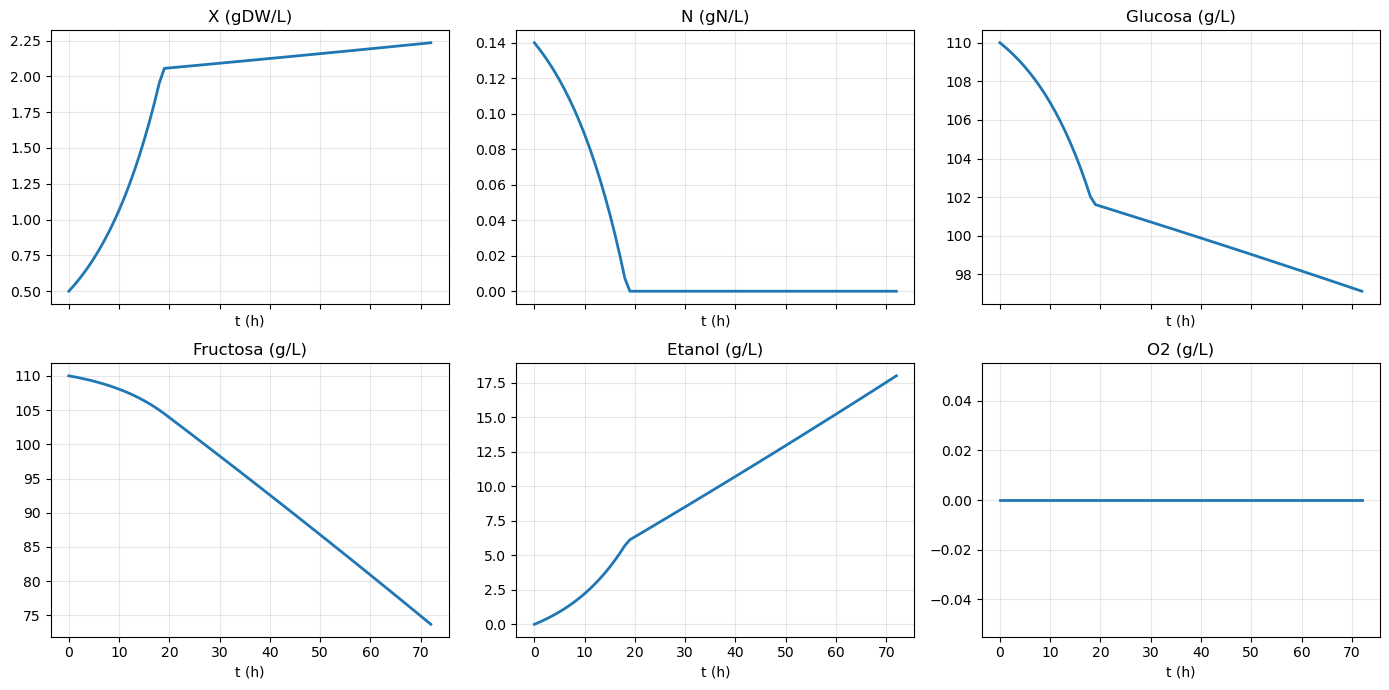

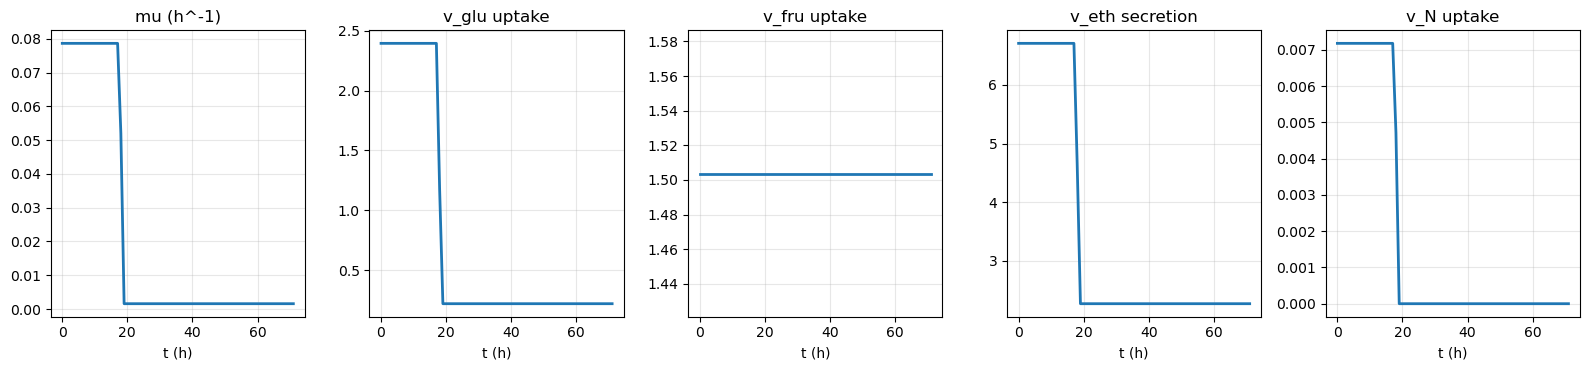

In [31]:
# dFBA con Static Optimization Approach (SOA) usando el modelo actual
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("dFBA (SOA) - modelo actual")
print("=" * 100)

# --- Requisitos mínimos ---
required = ["model", "KINETIC_N_SOURCE_IDS", "rxn_by_id"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables en sesión: {missing}")

# IDs clave (usa existentes si ya están definidos)
OBJ_ID = globals().get("OBJ_ID", "r_2111")
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

# Pesos moleculares (fallback por si no existen)
MW_GLU = float(globals().get("MW_GLU", 0.180156))
MW_FRU = float(globals().get("MW_FRU", 0.180156))
MW_ETH = float(globals().get("MW_ETH", 0.046070))
MW_N = float(globals().get("MW_N", 0.014007))

# Estado inicial (usa el de tu notebook si ya existe)
X0 = float(globals().get("cX", 0.5))    # gDW/L
N0 = float(globals().get("cN", 0.14))   # gN/L
G0 = float(globals().get("cG", 110.0))  # g/L
F0 = float(globals().get("cF", 110.0))  # g/L
E0 = float(globals().get("cE", 0.0))    # g/L
O20 = float(globals().get("cO2", 0.0))  # g/L

# Horizonte de simulación
DFBA_TH = 72.0   # h
DFBA_DT = 1.0    # h
n_steps = int(round(DFBA_TH / DFBA_DT))
t = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Límites máximos por biomasa (tomados del snapshot ya calculado en tu notebook)
vmax_glu = float(globals().get("lim_glu", 2.5))
vmax_fru = float(globals().get("lim_fru", 1.5))
vmax_eth = float(globals().get("lim_eth", 8.0))
lim_n_map_ref = globals().get("lim_n_map", {rid: 0.02 for rid in KINETIC_N_SOURCE_IDS})

# Mapa de N-atoms (usa el existente si está en memoria)
N_atoms_map_local = globals().get("N_atoms_map", {rid: 1.0 for rid in KINETIC_N_SOURCE_IDS})

# Fracción por fuente de N (normalizada desde lim_n_map_ref)
sum_ref_n = max(sum(float(lim_n_map_ref.get(rid, 0.0)) for rid in KINETIC_N_SOURCE_IDS), 1e-12)
n_share = {rid: float(lim_n_map_ref.get(rid, 0.0)) / sum_ref_n for rid in KINETIC_N_SOURCE_IDS}

# Historial de estados
Y = np.zeros((n_steps + 1, 6), dtype=float)  # X, N, G, F, E, O2
Y[0, :] = [X0, N0, G0, F0, E0, O20]

# Historial de flujos (por biomasa)
mu_hist = np.zeros(n_steps)
vglu_hist = np.zeros(n_steps)
vfru_hist = np.zeros(n_steps)
veth_hist = np.zeros(n_steps)
vn_hist = np.zeros(n_steps)
status_hist = []

def max_uptake_by_availability(c_sub, X, MW_sub, dt):
    if X <= 1e-12:
        return 0.0
    # v_max para no consumir más de lo disponible en el paso
    return max(0.0, c_sub / (MW_sub * X * dt))

for k in range(n_steps):
    X, N, G, F, E, O2 = np.maximum(Y[k, :], 0.0)

    # Capacidad por disponibilidad del medio
    cap_glu = min(vmax_glu, max_uptake_by_availability(G, X, MW_GLU, DFBA_DT))
    cap_fru = min(vmax_fru, max_uptake_by_availability(F, X, MW_FRU, DFBA_DT))

    # Límite total de N por disponibilidad del pool N
    cap_n_total = 0.0
    if X > 1e-12:
        cap_n_total = max(0.0, N / (MW_N * X * DFBA_DT))

    with model as m:
        rb = {r.id: r for r in m.reactions}

        # Azúcares
        if GLU_ID in rb:
            rb[GLU_ID].lower_bound = max(float(rb[GLU_ID].lower_bound), -cap_glu)
            rb[GLU_ID].upper_bound = min(float(rb[GLU_ID].upper_bound), 0.0)
        if FRU_ID in rb:
            rb[FRU_ID].lower_bound = max(float(rb[FRU_ID].lower_bound), -cap_fru)
            rb[FRU_ID].upper_bound = min(float(rb[FRU_ID].upper_bound), 0.0)

        # N cinético por fuente (distribuido por shares)
        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                cap_i = cap_n_total * n_share.get(rid, 0.0)
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), -cap_i)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        # Anaerobiosis fija
        if O2_ID in rb:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        # Etileno/etanol solo excreción (mantén según tu setup)
        if ETH_ID in rb:
            rb[ETH_ID].upper_bound = min(float(rb[ETH_ID].upper_bound), max(float(rb[ETH_ID].upper_bound), vmax_eth))

        m.objective = OBJ_ID
        m.objective_direction = "max"
        sol = m.optimize()
        status_hist.append(sol.status)

        if sol.status != "optimal":
            # Si no hay óptimo, estado congelado en ese paso
            Y[k + 1, :] = Y[k, :]
            continue

        v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
        v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
        v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
        v_eth = float(sol.fluxes.get(ETH_ID, 0.0))

        # N uptake efectivo (gN/gDW/h)
        vn_eff = 0.0
        for rid in KINETIC_N_SOURCE_IDS:
            vi = float(sol.fluxes.get(rid, 0.0))
            n_atoms = float(N_atoms_map_local.get(rid, 0.0))
            vn_eff += max(0.0, -vi) * n_atoms * MW_N

    # Guardar flujos
    mu_hist[k] = max(0.0, v_obj)
    vglu_hist[k] = max(0.0, -v_glu)
    vfru_hist[k] = max(0.0, -v_fru)
    veth_hist[k] = max(0.0, v_eth)
    vn_hist[k] = max(0.0, vn_eff)

    # SOA-Euler
    dX = v_obj * X
    dN = -vn_eff * X
    dG = -MW_GLU * max(0.0, -v_glu) * X
    dF = -MW_FRU * max(0.0, -v_fru) * X
    dE =  MW_ETH * max(0.0,  v_eth) * X
    dO2 = 0.0

    Y[k + 1, 0] = max(0.0, X + DFBA_DT * dX)
    Y[k + 1, 1] = max(0.0, N + DFBA_DT * dN)
    Y[k + 1, 2] = max(0.0, G + DFBA_DT * dG)
    Y[k + 1, 3] = max(0.0, F + DFBA_DT * dF)
    Y[k + 1, 4] = max(0.0, E + DFBA_DT * dE)
    Y[k + 1, 5] = max(0.0, O2 + DFBA_DT * dO2)

# --- Resultados ---
X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist = Y.T

print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}")
print(f"Pasos óptimos: {sum(s=='optimal' for s in status_hist)}/{len(status_hist)}")

# Guardar CSV
out_dfba = OUT_DIR / "dfba_soa_states_cell9.csv"
arr = np.column_stack([t, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
np.savetxt(out_dfba, arr, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
print(f"Archivo guardado: {out_dfba}")

# --- Gráficos ---
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    (X_hist, "X (gDW/L)"),
    (N_hist, "N (gN/L)"),
    (G_hist, "Glucosa (g/L)"),
    (F_hist, "Fructosa (g/L)"),
    (E_hist, "Etanol (g/L)"),
    (O2_hist, "O2 (g/L)"),
]
for a, (yy, title) in zip(ax.ravel(), series):
    a.plot(t, yy, lw=2)
    a.set_title(title)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 5, figsize=(16, 3.8), sharex=True)
flux_series = [
    (mu_hist, "mu (h^-1)"),
    (vglu_hist, "v_glu uptake"),
    (vfru_hist, "v_fru uptake"),
    (veth_hist, "v_eth secretion"),
    (vn_hist, "v_N uptake"),
]
tt = t[:-1]
for a, (yy, title) in zip(ax, flux_series):
    a.plot(tt, yy, lw=2)
    a.set_title(title)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
plt.tight_layout()
plt.show()

## Diagnóstico preliminar

Se realizan pruebas "whatif" cerrando exportaicón de etanol, presencai de esteroles y candidatos a sumideros de carbono 

In [32]:
# Diagnóstico específico: etanol=0, sumideros alternativos y experimento etanol forzado
print("\n" + "=" * 100)
print("Diagnóstico dirigido: competencia redox/carbono y desbloqueo de etanol")
print("=" * 100)

OBJ_ID = "r_2111"
ETH_ID = "r_1761"
ATPM_ID = "r_4046"

if OBJ_ID not in rxn_by_id or ETH_ID not in rxn_by_id:
    raise RuntimeError("Faltan r_2111 o r_1761 en el modelo")

# Exchanges estructurales no plausibles como válvula de carbono
LEAK_CLOSE_IDS = {
    "r_4501": "turanose exchange",
    "r_1650": "trehalose exchange",
    "r_4502": "D-glucose 6-phosphate exchange",
    "r_4538": "6-phospho-D-gluconate exchange",
}

# Sumideros alternativos sospechosos (ajuste fisiológico)
ALT_SINK_CAPS = {
    "r_1549": 0.5,  # (R,R)-2,3-butanodiol exchange
    "r_4659": 0.1,  # propanol exchange
    "r_4731": 0.1,  # diethyl-succinate exchange
    "r_4737": 0.1,  # ethyl-pyruvate exchange
    "r_1989": 0.0,  # oxaloacetate exchange (no excreción)
}

# Cierre de excreción de esteroles (permitiendo uptake si aplica)
STEROL_KEYWORDS = ("sterol", "ergosterol", "lanosterol", "zymosterol", "fecosterol", "episterol")
ETH_FORCED_MIN = 1.0
ATPM_STRESS_LB = 1.2

# 1) Referencia: máximo crecimiento sin forzar etanol
with model as m:
    m.objective = OBJ_ID
    m.objective_direction = "max"
    sol_ref_mu = m.optimize()

if sol_ref_mu.status != "optimal":
    raise RuntimeError("No se obtuvo solución óptima de referencia para biomasa")

mu_star = float(sol_ref_mu.objective_value)
v_eth_ref = float(sol_ref_mu.fluxes.get(ETH_ID, np.nan))
print(f"Referencia (sin forzar etanol): mu*={mu_star:.6g}, v_eth={v_eth_ref:.6g}")

def _carbon_atoms(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", formula)
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)

def _apply_leak_closure(m):
    ids = {r.id for r in m.reactions}
    for rid in LEAK_CLOSE_IDS:
        if rid in ids:
            rr = m.reactions.get_by_id(rid)
            rr.lower_bound = 0.0
            rr.upper_bound = 0.0

def _apply_alt_sink_caps(m):
    ids = {r.id for r in m.reactions}
    for rid, ub_cap in ALT_SINK_CAPS.items():
        if rid in ids:
            rr = m.reactions.get_by_id(rid)
            rr.lower_bound = max(0.0, float(rr.lower_bound))
            rr.upper_bound = min(float(rr.upper_bound), float(ub_cap))

def _close_sterol_excretion(m):
    touched = []
    for ex in m.exchanges:
        txt = f"{ex.id} {(ex.name or '')}".lower()
        if any(k in txt for k in STEROL_KEYWORDS):
            old_ub = float(ex.upper_bound)
            ex.upper_bound = min(float(ex.upper_bound), 0.0)
            touched.append((ex.id, ex.name, old_ub, float(ex.upper_bound)))
    return touched

def _solve_case(*, eth_fixed_zero=False, close_leaks=False, cap_alt_sinks=False, close_sterol=False, atpm_lb=None, eth_forced_min=None):
    with model as m:
        ids = {r.id for r in m.reactions}

        if close_leaks:
            _apply_leak_closure(m)

        if cap_alt_sinks:
            _apply_alt_sink_caps(m)

        sterol_touched = []
        if close_sterol:
            sterol_touched = _close_sterol_excretion(m)

        if atpm_lb is not None and ATPM_ID in ids:
            r_atpm = m.reactions.get_by_id(ATPM_ID)
            atpm_lb_val = float(atpm_lb)
            r_atpm.upper_bound = max(float(r_atpm.upper_bound), atpm_lb_val)
            r_atpm.lower_bound = max(float(r_atpm.lower_bound), atpm_lb_val)
        r_eth = m.reactions.get_by_id(ETH_ID)
        if eth_fixed_zero:
            r_eth.lower_bound = 0.0
            r_eth.upper_bound = 0.0
        if eth_forced_min is not None:
            r_eth.lower_bound = max(float(r_eth.lower_bound), float(eth_forced_min))
        m.objective = OBJ_ID
        m.objective_direction = "max"
        sol = m.optimize()
    return sol, sterol_touched

# 2) Casos comparativos
sol_A, ster_A = _solve_case(eth_fixed_zero=True, close_leaks=False, cap_alt_sinks=False, close_sterol=False)
sol_B, ster_B = _solve_case(eth_fixed_zero=True, close_leaks=True,  cap_alt_sinks=False, close_sterol=True)
sol_C, ster_C = _solve_case(eth_fixed_zero=True, close_leaks=True,  cap_alt_sinks=True,  close_sterol=True)

# Sensibilidad ATPM en caso curado + caps
sol_D, ster_D = _solve_case(
    eth_fixed_zero=True,
    close_leaks=True,
    cap_alt_sinks=True,
    close_sterol=True,
    atpm_lb=ATPM_STRESS_LB,
    eth_forced_min=None,
)

# Experimento de desbloqueo: forzar etanol mínimo
sol_E, ster_E = _solve_case(
    eth_fixed_zero=False,
    close_leaks=True,
    cap_alt_sinks=True,
    close_sterol=True,
    atpm_lb=None,
    eth_forced_min=ETH_FORCED_MIN,
)

def _report_case(title, sol_case, sterol_touched):
    print("\n" + "-" * 100)
    print(title)
    print("-" * 100)
    print(f"Esterol exchanges con excreción cerrada: {len(sterol_touched)}")

    if sol_case.status != "optimal":
        print(f"status: {sol_case.status} (sin óptimo)")
        return

    mu_case = float(sol_case.objective_value)
    v_eth = float(sol_case.fluxes.get(ETH_ID, np.nan))
    v_glu = float(sol_case.fluxes.get("r_1714", np.nan)) if "r_1714" in rxn_by_id else np.nan
    v_fru = float(sol_case.fluxes.get("r_1709", np.nan)) if "r_1709" in rxn_by_id else np.nan
    drop_pct = 100.0 * (mu_star - mu_case) / max(mu_star, 1e-12)
    print(f"mu={mu_case:.6g}, v_eth={v_eth:.6g}, caída biomasa={drop_pct:.4f}%")
    print(f"azúcares: v_glu={v_glu:.6g}, v_fru={v_fru:.6g}")

    try:
        rc_eth = float(sol_case.reduced_costs.get(ETH_ID, np.nan))
        print(f"costo reducido r_1761={rc_eth:.6g}")
        if np.isfinite(rc_eth):
            if abs(rc_eth) < 1e-6:
                print("Interpretación RC: presión prácticamente nula por abrir etanol.")
            elif abs(rc_eth) < 1e-2:
                print("Interpretación RC: presión débil por abrir etanol.")
            else:
                print("Interpretación RC: presión relevante por abrir etanol.")
    except Exception:
        pass

    # Exchanges de carbono más activos
    carb_rows = []

    for ex in model.exchanges:
        rid = ex.id
        v = float(sol_case.fluxes.get(rid, 0.0))
        met = next(iter(ex.metabolites.keys()))
        c_atoms = _carbon_atoms(getattr(met, "formula", ""))
        if c_atoms > 0 and abs(v) > 1e-8:
            carb_rows.append((rid, ex.name, v, c_atoms, abs(v) * c_atoms))

    carb_rows.sort(key=lambda x: x[4], reverse=True)
    print("Top exchanges de carbono activos:")

    for rid, name, v, c_atoms, cscore in carb_rows[:12]:
        direction = "uptake" if v < 0 else "secretion"
        print(f"- {name:36s} ({rid}) | v={v: .6g} | C={c_atoms:2d} | {direction:9s} | C*|v|={cscore: .6g}")

    # Flujos clave sospechosos

    key_ids = [
        "r_1714", "r_1709", "r_1761",
        "r_1549", "r_4659", "r_4731", "r_4737", "r_1989", "r_1808", "r_1672",
        "r_2111", "r_1992", "r_4046",
    ]

    print("Flujos clave:")
    for rid in key_ids:
        if rid in rxn_by_id:
            name = rxn_by_id[rid].name
            vv = float(sol_case.fluxes.get(rid, np.nan))
            print(f"- {name:36s} ({rid}) | v={vv: .6g}")

_report_case("Caso A: etanol=0 (sin cerrar leaks)", sol_A, ster_A)
_report_case("Caso B: etanol=0 + cierre de leaks + sin excreción de esteroles", sol_B, ster_B)
_report_case("Caso C: Caso B + caps de sumideros exóticos", sol_C, ster_C)
_report_case("Caso D: Caso C + ATPM más exigente", sol_D, ster_D)
_report_case(f"Caso E: Caso C + etanol forzado (v_eth >= {ETH_FORCED_MIN})", sol_E, ster_E)

print("\nLectura rápida:")
print("- Se restringieron r_4731/r_4737 y se cerró r_1989 para excreción.")
print("- También se cerró excreción de exchanges con nombre de esterol (ub<=0).")
print("- Si E (etanol forzado) derrumba μ o vuelve inviable, revisar estequiometría ADH/transporte de etanol y cofactores del medio.")


Diagnóstico dirigido: competencia redox/carbono y desbloqueo de etanol
Referencia (sin forzar etanol): mu*=0.0786662, v_eth=6.75811


c:\Users\ctorrealba\AppData\Local\anaconda3\envs\Data_Science\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)



----------------------------------------------------------------------------------------------------
Caso A: etanol=0 (sin cerrar leaks)
----------------------------------------------------------------------------------------------------
Esterol exchanges con excreción cerrada: 0
mu=0.0375449, v_eth=0, caída biomasa=52.2732%
azúcares: v_glu=-2.92775, v_fru=-1.5037
costo reducido r_1761=0.0149897
Interpretación RC: presión relevante por abrir etanol.
Top exchanges de carbono activos:
- D-glucose exchange                   (r_1714) | v=-2.92775 | C= 6 | uptake    | C*|v|= 17.5665
- diethyl-succinate exchange           (r_4731) | v= 1.78372 | C= 8 | secretion | C*|v|= 14.2697
- D-fructose exchange                  (r_1709) | v=-1.5037 | C= 6 | uptake    | C*|v|= 9.02218
- (R,R)-2,3-butanediol exchange        (r_1549) | v= 1.60142 | C= 4 | secretion | C*|v|= 6.40568
- carbon dioxide exchange              (r_1672) | v= 5.18133 | C= 1 | secretion | C*|v|= 5.18133
- L-tryptophan exchange    

Ahora seguimos con FBA con Caso C y etanol abierto

In [33]:
# Modelo operativo para simulación: Caso C + etanol liberado (pFBA)
print("\n" + "=" * 100)
print("Construcción del modelo operativo (Caso C + r_1761 abierto, pFBA)")
print("=" * 100)

required_symbols = [
    "model", "OBJ_ID", "ETH_ID", "ATPM_ID", "KINETIC_N_SOURCE_IDS",
    "_apply_leak_closure", "_apply_alt_sink_caps", "_close_sterol_excretion",
    "rxn_by_id",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos en sesión: {missing_symbols}")

model_case_c_open_eth = model.copy()

# Aplicar configuración Caso C
_apply_leak_closure(model_case_c_open_eth)
_apply_alt_sink_caps(model_case_c_open_eth)
ster_case_c_open_eth = _close_sterol_excretion(model_case_c_open_eth)

rxn_case = {r.id: r for r in model_case_c_open_eth.reactions}
if ETH_ID not in rxn_case:
    raise RuntimeError(f"No se encontró {ETH_ID} en el modelo de trabajo")

# Liberar intercambio de etanol (uptake y excreción)
rxn_case[ETH_ID].lower_bound = 0.0
rxn_case[ETH_ID].upper_bound = 1000.0

# Exigir mayor mantenimiento (ATPM fijo)
ATPM_CASE_C = 0.7
if ATPM_ID in rxn_case:
    rxn_case[ATPM_ID].upper_bound = max(float(rxn_case[ATPM_ID].upper_bound), ATPM_CASE_C)
    rxn_case[ATPM_ID].lower_bound = ATPM_CASE_C
    rxn_case[ATPM_ID].upper_bound = ATPM_CASE_C
else:
    print(f"[WARN] No se encontró {ATPM_ID}; no se ajustó ATPM")

# Resolver pFBA con objetivo de biomasa
model_case_c_open_eth.objective = OBJ_ID
model_case_c_open_eth.objective_direction = "max"
sol_case_c_open_eth = cobra.flux_analysis.pfba(model_case_c_open_eth, fraction_of_optimum=1.0)

mu_case = float(sol_case_c_open_eth.fluxes.get(OBJ_ID, np.nan)) if OBJ_ID in rxn_case else np.nan

print(f"Esterol exchanges con excreción cerrada: {len(ster_case_c_open_eth)}")
print(f"Bounds etanol {ETH_ID}: lb={rxn_case[ETH_ID].lower_bound:.3f}, ub={rxn_case[ETH_ID].upper_bound:.3f}")
if ATPM_ID in rxn_case:
    print(f"Bounds ATPM {ATPM_ID}: lb={rxn_case[ATPM_ID].lower_bound:.3f}, ub={rxn_case[ATPM_ID].upper_bound:.3f}")
print(f"pFBA status: {sol_case_c_open_eth.status}")
print(f"Crecimiento (flujo {OBJ_ID}) en pFBA: {mu_case:.6g}")
print(f"Objetivo interno pFBA (min suma de flujos): {sol_case_c_open_eth.objective_value:.6g}")

print("\nFlujos clave (Caso C + etanol abierto, pFBA):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Intercambio etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_case:
        v = float(sol_case_c_open_eth.fluxes.get(rid, np.nan))
        print(f"- {label:20s} ({rid}) | {rxn_case[rid].name} | v={v: .6g} | bounds=[{rxn_case[rid].lower_bound: .6g}, {rxn_case[rid].upper_bound: .6g}]")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# FVA dirigido, análogo a celdas anteriores
print("\n" + "=" * 100)
print("FVA @99% (Caso C + etanol abierto)")
print("=" * 100)

fva_ids_case_c_open_eth = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids_case_c_open_eth = [rid for rid in fva_ids_case_c_open_eth if rid in rxn_case]

fva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
    model_case_c_open_eth,
    reaction_list=fva_ids_case_c_open_eth,
    fraction_of_optimum=0.99,
)

for rid in fva_ids_case_c_open_eth:
    mn = float(fva_case_c_open_eth_df.loc[rid, "minimum"])
    mx = float(fva_case_c_open_eth_df.loc[rid, "maximum"])
    print(f"- {rxn_case[rid].name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")

# pFVA (FVA parsimonioso)
print("\n" + "=" * 100)
print("pFVA @99% (pfba_factor=1.0)")
print("=" * 100)

pfva_case_c_open_eth_df = None
try:
    pfva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
        model_case_c_open_eth,
        reaction_list=fva_ids_case_c_open_eth,
        fraction_of_optimum=0.99,
        pfba_factor=1.0,
    )

    for rid in fva_ids_case_c_open_eth:
        mn = float(pfva_case_c_open_eth_df.loc[rid, "minimum"])
        mx = float(pfva_case_c_open_eth_df.loc[rid, "maximum"])
        print(f"- {rxn_case[rid].name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")
except TypeError:
    print("[WARN] La versión actual de COBRApy no soporta 'pfba_factor' en flux_variability_analysis.")
    print("       pFVA no fue calculado.")

print("\nVariables guardadas:")
print("- model_case_c_open_eth")
print("- sol_case_c_open_eth")
print("- fva_case_c_open_eth_df")
print("- pfva_case_c_open_eth_df")


Construcción del modelo operativo (Caso C + r_1761 abierto, pFBA)
Esterol exchanges con excreción cerrada: 6
Bounds etanol r_1761: lb=0.000, ub=1000.000
Bounds ATPM r_4046: lb=0.700, ub=0.700
pFBA status: optimal
Crecimiento (flujo r_2111) en pFBA: 0.0786662
Objetivo interno pFBA (min suma de flujos): 115.65

Flujos clave (Caso C + etanol abierto, pFBA):
- Biomasa              (r_2111) | growth | v= 0.0786662 | bounds=[ 0,  1000]
- Uptake glucosa       (r_1714) | D-glucose exchange | v=-2.39755 | bounds=[-2.92775,  0]
- Uptake fructosa      (r_1709) | D-fructose exchange | v=-1.5037 | bounds=[-1.5037,  0]
- Intercambio etanol   (r_1761) | ethanol exchange | v= 6.66308 | bounds=[ 0,  1000]
- Intercambio O2       (r_1992) | oxygen exchange | v= 0 | bounds=[ 0,  0]
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v= 0.7 | bounds=[ 0.7,  0.7]

FVA @99% (Caso C + etanol abierto)
- growth                                   (r_2111) | min= 0.0778795  max= 0.07866

In [34]:
# Diagnóstico extendido de fuentes de carbono (Caso C + etanol abierto)
print("\n" + "=" * 100)
print("Diagnóstico extendido: ¿por dónde entra carbono en la solución FBA?")
print("=" * 100)

if "model_case_c_open_eth" not in globals() or "sol_case_c_open_eth" not in globals():
    raise RuntimeError("Primero ejecuta la celda de Caso C + etanol abierto")

m_diag = model_case_c_open_eth
sol_diag = sol_case_c_open_eth
rxn_diag = {r.id: r for r in m_diag.reactions}

def _carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)

exchange_ids = {r.id for r in m_diag.exchanges}
sink_ids = {r.id for r in m_diag.sinks}
demand_ids = {r.id for r in m_diag.demands}
boundary_ids = exchange_ids | sink_ids | demand_ids

# 1) Medium actual: qué exchanges están habilitados para uptake
print("\n[1] Exchanges con uptake habilitado en medium (bound > 0):")
medium_map = m_diag.medium
medium_open = sorted(medium_map.items(), key=lambda kv: kv[1], reverse=True)
if not medium_open:
    print("- No hay exchanges con uptake habilitado en medium.")
else:
    for rid, ub_up in medium_open[:30]:
        if rid in rxn_diag:
            r = rxn_diag[rid]
            met = next(iter(r.metabolites.keys())) if r.metabolites else None
            c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", "")) if met is not None else 0
            print(f"- {r.name:40s} ({rid}) | medium_bound={ub_up: .6g} | C_atoms={c_atoms}")

# 2) Uptakes de carbono realmente activos en la solución óptima
print("\n[2] Uptakes de carbono activos (exchanges con v < 0):")
carbon_uptake_rows = []
for rid in exchange_ids:
    v = float(sol_diag.fluxes.get(rid, 0.0))
    if v >= -1e-9:
        continue
    r = rxn_diag[rid]
    if not r.metabolites:
        continue
    met = next(iter(r.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms <= 0:
        continue
    c_score = (-v) * c_atoms
    carbon_uptake_rows.append((rid, r.name, met.id, getattr(met, "formula", ""), v, c_atoms, c_score, r.lower_bound, r.upper_bound))

carbon_uptake_rows.sort(key=lambda x: x[6], reverse=True)
if not carbon_uptake_rows:
    print("- No hay uptake de compuestos con carbono en el óptimo.")
else:
    total_c = sum(x[6] for x in carbon_uptake_rows)
    print(f"Total C*|v| (uptake activo) = {total_c:.6g}")
    for rid, name, mid, formula, v, c_atoms, c_score, lb, ub in carbon_uptake_rows[:20]:
        print(f"- {name:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_score: .6g} | bounds=[{lb: .6g}, {ub: .6g}]")

# 3) Reacciones de frontera activas con carbono (incluye sink/demand)
print("\n[3] Reacciones de frontera activas con metabolitos carbonados (|v|>1e-9):")
boundary_carbon_rows = []
for rid in boundary_ids:
    v = float(sol_diag.fluxes.get(rid, 0.0))
    if abs(v) <= 1e-9:
        continue
    r = rxn_diag[rid]
    if not r.metabolites:
        continue
    met = next(iter(r.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms <= 0:
        continue
    rtype = "exchange" if rid in exchange_ids else ("sink" if rid in sink_ids else "demand")
    boundary_carbon_rows.append((rid, r.name, rtype, met.id, getattr(met, "formula", ""), v, c_atoms, abs(v) * c_atoms, r.lower_bound, r.upper_bound))

boundary_carbon_rows.sort(key=lambda x: x[7], reverse=True)
if not boundary_carbon_rows:
    print("- No se detectaron fronteras activas con carbono.")
else:
    for rid, name, rtype, mid, formula, v, c_atoms, cscore, lb, ub in boundary_carbon_rows[:30]:
        direction = "uptake" if v < 0 else "secretion"
        print(f"- [{rtype:8s}] {name:30s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} ({direction}) | C={c_atoms:2d} | C*|v|={cscore: .6g} | bounds=[{lb: .6g}, {ub: .6g}]")

# 4) FVA sobre TODOS los exchanges carbonados para detectar vías alternativas
print("\n[4] FVA @99% en exchanges carbonados (potenciales uptakes alternativos)")
carbon_exchange_ids = []
for ex in m_diag.exchanges:
    if not ex.metabolites:
        continue
    met = next(iter(ex.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms > 0:
        carbon_exchange_ids.append(ex.id)

if not carbon_exchange_ids:
    print("- No se encontraron exchanges carbonados para analizar.")
else:
    fva_carbon_ex = cobra.flux_analysis.flux_variability_analysis(
        m_diag,
        reaction_list=carbon_exchange_ids,
        fraction_of_optimum=0.99,
    )

    possible_c_uptake = []
    for rid in carbon_exchange_ids:
        mn = float(fva_carbon_ex.loc[rid, "minimum"])
        mx = float(fva_carbon_ex.loc[rid, "maximum"])
        if mn < -1e-9:
            r = rxn_diag[rid]
            met = next(iter(r.metabolites.keys()))
            c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
            possible_c_uptake.append((rid, r.name, met.id, getattr(met, "formula", ""), mn, mx, c_atoms, r.lower_bound, r.upper_bound))

    possible_c_uptake.sort(key=lambda x: x[4])
    if not possible_c_uptake:
        print("- Ningún exchange carbonado puede tomar flujo negativo al 99% del óptimo.")
    else:
        print("Exchanges carbonados con uptake posible (min < 0):")
        for rid, name, mid, formula, mn, mx, c_atoms, lb, ub in possible_c_uptake[:40]:
            print(f"- {name:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | FVA[min,max]=[{mn: .6g}, {mx: .6g}] | C={c_atoms:2d} | bounds=[{lb: .6g}, {ub: .6g}]")

# 5) Lectura dirigida para tu caso
print("\n[5] Lectura dirigida:")
v_glu = float(sol_diag.fluxes.get("r_1714", np.nan)) if "r_1714" in rxn_diag else np.nan
v_fru = float(sol_diag.fluxes.get("r_1709", np.nan)) if "r_1709" in rxn_diag else np.nan
print(f"- Glucosa (r_1714): v={v_glu: .6g}")
print(f"- Fructosa (r_1709): v={v_fru: .6g}")
print("- Si glucosa queda en 0 y fructosa < 0, el óptimo actual prioriza fructosa dadas las restricciones vigentes.")
print("- Revisa en [2] y [4] si hay otros exchanges carbonados con uptake activo o factible (min<0).")


Diagnóstico extendido: ¿por dónde entra carbono en la solución FBA?

[1] Exchanges con uptake habilitado en medium (bound > 0):
- ergosterol exchange                      (r_1757) | medium_bound= 1000 | C_atoms=28
- H+ exchange                              (r_1832) | medium_bound= 1000 | C_atoms=0
- lanosterol exchange                      (r_1915) | medium_bound= 1000 | C_atoms=30
- palmitoleate exchange                    (r_1994) | medium_bound= 1000 | C_atoms=16
- phosphate exchange                       (r_2005) | medium_bound= 1000 | C_atoms=0
- sodium exchange                          (r_2049) | medium_bound= 1000 | C_atoms=0
- sulphate exchange                        (r_2060) | medium_bound= 1000 | C_atoms=0
- water exchange                           (r_2100) | medium_bound= 1000 | C_atoms=0
- zymosterol exchange                      (r_2106) | medium_bound= 1000 | C_atoms=27
- 14-demethyllanosterol exchange           (r_2134) | medium_bound= 1000 | C_atoms=29
- ergosta-5,7,22

In [35]:
# Sensibilidad dual (precios sombra y costos reducidos)
print("\n" + "=" * 100)
print("Analisis de sensibilidad dual (COBRA)")
print("=" * 100)

# Reusar solucion vigente; si no existe, optimizar
sol_dual = solution_nb2 if 'solution_nb2' in globals() else model.optimize()
print(f"status: {sol_dual.status}")
print(f"objective: {sol_dual.objective_value:.6g}")

if sol_dual.status != "optimal":
    print("[WARN] Solucion no optima: precios sombra/costos reducidos pueden ser poco confiables.")

# 1) Precios sombra de metabolitos (dual de balance S*v = 0)
shadow = sol_dual.shadow_prices.copy()
shadow = shadow.replace([np.inf, -np.inf], np.nan).dropna()
shadow_nz = shadow[shadow.abs() > 1e-9]
shadow_top = shadow_nz.reindex(shadow_nz.abs().sort_values(ascending=False).index)

print("\nTop metabolitos por |precio sombra| (abs):")
if shadow_top.empty:
    print("- No hay precios sombra significativos sobre el umbral.")
else:
    for mid, sp in shadow_top.head(20).items():
        met = model.metabolites.get_by_id(mid)
        comp = getattr(met, "compartment", "?")
        print(f"- {met.name:42s} ({mid}) [comp={comp}] | shadow={sp: .6g}")

print("\nInterpretacion rapida precio sombra:")
print("- |shadow| alto => metabolito mas 'caro' para sostener el objetivo (cuello potencial).")
print("- shadow < 0 suele indicar que aumentar disponibilidad de ese balance favoreceria el objetivo.")
print("- shadow > 0 suele indicar presion en sentido opuesto del balance.")

# 2) Costos reducidos de reacciones (dual de bounds)
reduced = sol_dual.reduced_costs.copy()
reduced = reduced.replace([np.inf, -np.inf], np.nan).dropna()
reduced_nz = reduced[reduced.abs() > 1e-9]
reduced_top = reduced_nz.reindex(reduced_nz.abs().sort_values(ascending=False).index)

print("\nTop reacciones por |costo reducido| (abs):")
if reduced_top.empty:
    print("- No hay costos reducidos significativos sobre el umbral.")
else:
    for rid, rc in reduced_top.head(20).items():
        rxn = model.reactions.get_by_id(rid)
        v = float(sol_dual.fluxes.get(rid, np.nan))
        at_lb = abs(v - rxn.lower_bound) <= 1e-7
        at_ub = abs(v - rxn.upper_bound) <= 1e-7
        where = "LB" if at_lb else ("UB" if at_ub else "interior")
        print(f"- {rxn.name:42s} ({rid}) | rc={rc: .6g} | v={v: .6g} | activo_en={where}")

# 3) Exchanges activos en cota (suelen ser cuellos de entrada/salida)
print("\nExchanges activos en cota (|v-lb|<tol o |v-ub|<tol):")
active_ex = []
for ex in model.exchanges:
    rid = ex.id
    v = float(sol_dual.fluxes.get(rid, 0.0))
    at_lb = abs(v - ex.lower_bound) <= 1e-7
    at_ub = abs(v - ex.upper_bound) <= 1e-7
    if at_lb or at_ub:
        active_ex.append((rid, ex.name, v, ex.lower_bound, ex.upper_bound, "LB" if at_lb else "UB"))

if not active_ex:
    print("- Ningun exchange detectado en cota activa.")
else:
    active_ex.sort(key=lambda x: abs(x[2]), reverse=True)
    for rid, name, v, lb, ub, side in active_ex[:25]:
        print(f"- {name:38s} ({rid}) | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | cota={side}")

# 4) Semaforo: cruza exchange en cota + |reduced cost|
print("\n" + "=" * 100)
print("Semaforo de cuellos (exchange en cota + |costo reducido|)")
print("=" * 100)

def bottleneck_level(abs_rc):
    if abs_rc >= 10:
        return "ALTO"
    if abs_rc >= 1:
        return "MEDIO"
    return "BAJO"

def is_actionable_exchange(side, lb, ub):
    blocked = abs(lb) <= 1e-12 and abs(ub) <= 1e-12
    if blocked:
        return False, "bloqueada"

    # Uptake cap activo (flujo en LB negativo): candidato biologicamente accionable
    if side == "LB" and lb < -1e-9:
        return True, "uptake_cap"

    # Product/secreted cap activo (flujo en UB acotado): accionable si no esta abierto a 1000
    if side == "UB" and ub > 1e-9 and ub < 999.0:
        return True, "secretion_cap"

    # Casos tipicos no accionables: LB=0 en solo-secrecion, UB=1000 en abierto
    return False, "estructural"

rc_map = reduced.abs().to_dict()
cross_all = []
cross_actionable = []
for rid, name, v, lb, ub, side in active_ex:
    abs_rc = float(rc_map.get(rid, 0.0))
    if abs_rc <= 1e-9:
        continue

    ok, kind = is_actionable_exchange(side, lb, ub)
    row = (abs_rc, rid, name, side, v, lb, ub, bottleneck_level(abs_rc), kind)
    cross_all.append(row)
    if ok:
        cross_actionable.append(row)

if not cross_all:
    print("- No se detectaron exchanges en cota con costo reducido relevante.")
else:
    cross_all.sort(reverse=True, key=lambda x: x[0])
    cross_actionable.sort(reverse=True, key=lambda x: x[0])

    if cross_actionable:
        print("Top 5 cuellos ACCIONABLES:")
        for abs_rc, rid, name, side, v, lb, ub, lvl, kind in cross_actionable[:5]:
            print(f"- [{lvl:5s}] {name:34s} ({rid}) | |rc|={abs_rc: .6g} | cota={side} | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | tipo={kind}")
    else:
        print("- No hay cuellos accionables bajo este filtro (solo estructurales/bloqueados).")

    print("\nTop 5 cuellos GLOBALES (incluye estructurales):")
    for abs_rc, rid, name, side, v, lb, ub, lvl, kind in cross_all[:5]:
        print(f"- [{lvl:5s}] {name:34s} ({rid}) | |rc|={abs_rc: .6g} | cota={side} | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | tipo={kind}")

print("\nSugerencia:")
print("- Prioriza ajustes en cuellos [ALTO] del bloque ACCIONABLE, luego reoptimiza y vuelve a revisar este semaforo.")


Analisis de sensibilidad dual (COBRA)
status: optimal
objective: 0.0786662

Top metabolitos por |precio sombra| (abs):
- P(1),P(4)-bis(5'-adenosyl) tetraphosphate  (s_1282) [comp=c] | shadow=-1.58276
- P(1),P(3)-bis(5'-adenosyl) triphosphate    (s_4317) [comp=c] | shadow=-1.58276
- 5,6,7,8-tetrahydrofolyl-L-glutamic acid    (s_0308) [comp=c] | shadow=-1.26621
- 5-methyltetrahydrofolate                   (s_0322) [comp=c] | shadow=-1.10793
- 5,10-methylenetetrahydrofolate             (s_0306) [comp=c] | shadow=-1.10793
- dihydrofolic acid                          (s_0626) [comp=m] | shadow=-1.10793
- dihydrofolic acid                          (s_0625) [comp=c] | shadow=-1.10793
- THF                                        (s_1487) [comp=c] | shadow=-1.10793
- 5'-S-methyl-5'-thioadenosine               (s_0303) [comp=c] | shadow=-1.10793
- 10-formyl-THF                              (s_0120) [comp=c] | shadow=-1.10793
- 5-formyltetrahydrofolic acid               (s_0319) [comp=c] | shado

# SOA empleando modelo de Zenteno
En funcion de análisis anteriores, definimos nuevo bloque SOA. Aplicamos algunos cambios, en específico un threshold de depletion de N, y el cierre de aporte de N por parte de vitaminas una vez agotadas las fuentes de N principales. Se emplea valor de temperatura onstante, ajustado a Tval = 293 K


dFBA SOA básico con COBRApy (anaeróbico vs aeróbico)
Regla N-depletion: cierre de vitaminas N cuando N <= 1e-06
Exchanges vitaminas-N afectados: ['r_2067', 'r_1671', 'r_1967', 'r_2028', 'r_1548', 'r_2038']

Bloque dFBA: Anaeróbico
Estado final: X=2.3957, N=0.0000, G=58.3220, F=83.6315, E=12.4943, O2=0.000000
O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)
Archivo guardado: out\dfba_direct_states_anaerobic.csv

Bloque dFBA: Aeróbico (arranque O2=0.8 mg/L)
Estado final: X=2.3957, N=0.0000, G=57.9217, F=83.4073, E=10.8327, O2=0.000288
O2 inicial: 0.8000 mg/L | Transición estimada a anaerobiosis: t≈72.00 h
Archivo guardado: out\dfba_direct_states_aerobic.csv


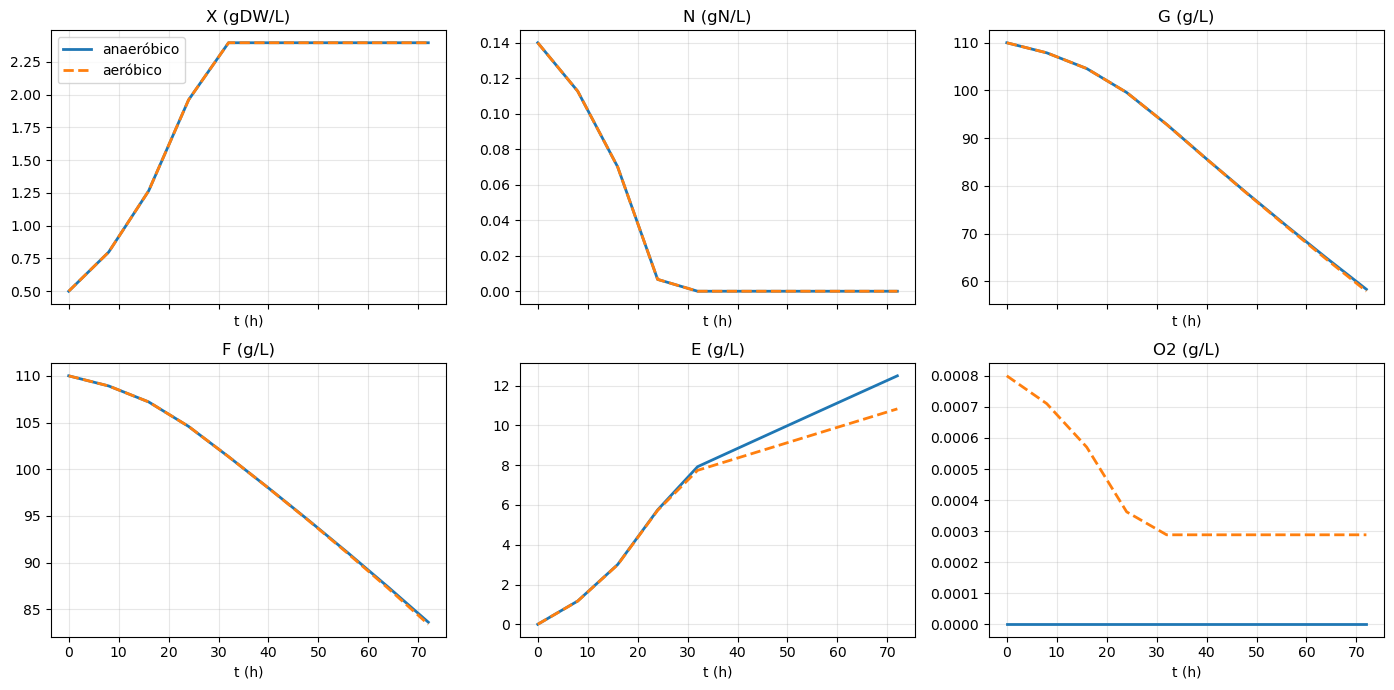

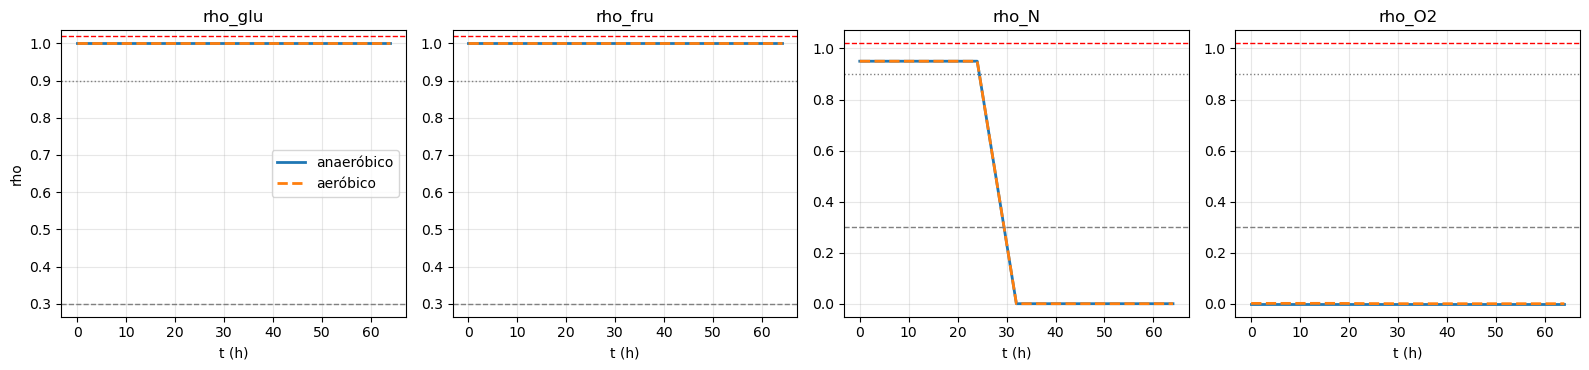

In [36]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico)
print("\n" + "=" * 100)
print("dFBA SOA básico con COBRApy (anaeróbico vs aeróbico)")
print("=" * 100)

import matplotlib.pyplot as plt
import re

# Horizonte y paso
DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Escenario aeróbico
O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

# Cierre de uptake nitrogenado al agotarse N
N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

# IDs clave
OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: cierre de vitaminas N cuando N <= {N_DEPLETION_CLOSE_THRESHOLD:g}")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2 = _apply_dynamic_bounds(mtmp, yk)
            sol = mtmp.optimize()

            if sol.status != "optimal":
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist = Y[:, 0]
    N_hist = Y[:, 1]
    G_hist = Y[:, 2]
    F_hist = Y[:, 3]
    E_hist = Y[:, 4]
    O2_hist = Y[:, 5]

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic" if aerobic_mode else "anaerobic"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
    }

# Bloque 1: anaeróbico
res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

# Bloque 2: aeróbico (arranque con 0.8 mg/L O2)
res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

# Comparación gráfica de estados
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

# Comparación gráfica de activación de restricciones
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.axhline(0.30, color="gray", ls="--", lw=1)
    a.axhline(0.90, color="gray", ls=":", lw=1)
    a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("rho")
ax[0].legend()
plt.tight_layout()
plt.show()

Idem a anterior, ahora empleando pFBA en vez de FBA como base de simulación

In [ ]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico) usando pFBA en cada paso
print("\n" + "=" * 100)
print("dFBA SOA básico con COBRApy (anaeróbico vs aeróbico) usando pFBA")
print("=" * 100)

# Horizonte y paso
DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Escenario aeróbico
O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

# Cierre de uptake nitrogenado al agotarse N
N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

# IDs clave
OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: cierre de vitaminas N cuando N <= {N_DEPLETION_CLOSE_THRESHOLD:g}")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2 = _apply_dynamic_bounds(mtmp, yk)

            mtmp.objective = OBJ_ID
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0) #aplicamos solución pFBA para favorecer rutas más eficientes energéticamente dentro de las opciones óptimas
            except Exception:
                continue

            if getattr(sol, "status", "optimal") != "optimal":
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist = Y[:, 0]
    N_hist = Y[:, 1]
    G_hist = Y[:, 2]
    F_hist = Y[:, 3]
    E_hist = Y[:, 4]
    O2_hist = Y[:, 5]

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA-pFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic_pfba" if aerobic_mode else "anaerobic_pfba"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
    }

# Bloque 1: anaeróbico
res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

# Bloque 2: aeróbico
res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

# Comparación gráfica de estados
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

# Comparación gráfica de activación de restricciones
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.axhline(0.30, color="gray", ls="--", lw=1)
    a.axhline(0.90, color="gray", ls=":", lw=1)
    a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("rho")
ax[0].legend()
plt.tight_layout()
plt.show()

# Nuevo segmento dedicado a objetivo multifase

Ahora extendemos dFBA anterior considerando cambio de fase. Para ello, definimos múltiples objetivos de crecimiento, comenzando por maximizar crecimiento, y seguido por maximizar producción de energía, vía maximización de racción de mantenmimeinto.

In [ ]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico) usando pFBA
# con cambio de objetivo al agotarse N:
# 1) ATPM: lb=0.7, ub=1000
# 2) Biomasa fija en 0
# 3) Objetivo = maximizar ATPM
print("\n" + "=" * 100)
print("dFBA SOA con pFBA y cambio de objetivo por agotamiento de N")
print("=" * 100)

DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"
ATPM_ID = "r_4046"

ATPM_LB_NO_GROWTH = 0.7
ATPM_UB_NO_GROWTH = 1000.0

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: N <= {N_DEPLETION_CLOSE_THRESHOLD:g} -> objetivo ATPM")
print(f"ATPM no-growth bounds: [{ATPM_LB_NO_GROWTH}, {ATPM_UB_NO_GROWTH}]")
print(f"Biomasa no-growth bounds: [0, 0]")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2) #obtenemos límites cinéticos dinámicos de modelo zenteno

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2, rb

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    vatpm_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)
    mode_hist = []

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)
        cN = float(yk[1])

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2, rb = _apply_dynamic_bounds(mtmp, yk)

            if cN <= N_DEPLETION_CLOSE_THRESHOLD:
                rb[ATPM_ID].lower_bound = ATPM_LB_NO_GROWTH
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0
                mtmp.objective = ATPM_ID
                mode_hist.append("ATPM")
            else:
                mtmp.objective = OBJ_ID
                mode_hist.append("BIOMASS")

            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                mode_hist[-1] = "FAIL"
                continue

            if getattr(sol, "status", "optimal") != "optimal":
                mode_hist[-1] = "NO_OPT"
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        vatpm_hist[k] = max(0.0, v_atpm)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist = Y.T

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    atpm_steps = sum(m == "ATPM" for m in mode_hist)
    biomass_steps = sum(m == "BIOMASS" for m in mode_hist)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA-pFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    print(f"Pasos objetivo BIOMASS={biomass_steps}, ATPM={atpm_steps}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic_pfba_atpm_switch" if aerobic_mode else "anaerobic_pfba_atpm_switch"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
        "vatpm_hist": vatpm_hist,
        "mode_hist": mode_hist,
    }

res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 5, figsize=(18, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
    ("vatpm_hist", "v_ATPM"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    if key.startswith("rho_"):
        a.axhline(0.30, color="gray", ls="--", lw=1)
        a.axhline(0.90, color="gray", ls=":", lw=1)
        a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("valor")
ax[0].legend()
plt.tight_layout()
plt.show()

## Resumen breve: implementación de protein turnover en dFBA

1. **Estados relevantes del modelo**  
   El sistema incluye biomasa \(X\), nitrógeno libre \(N\), proteína total \(Prot\) y aminoácidos precursores \(AA_i\), además de sustratos y aromas.

2. **Inicialización de la proteína**  
   La proteína inicial se asume proporcional a la biomasa:
   \[
   Prot(0)=X(0)\cdot PROT\_CONTENT
   \]
   con `PROT_CONTENT = 0.45`.

3. **Cambio de régimen según nitrógeno disponible**  
   Se calcula un nitrógeno total como:
   \[
   N_{total}=N_{free}+N_{from\,AA}
   \]
   Si \(N_{total}\) cae bajo un umbral, el modelo deja de priorizar crecimiento y entra en modo de mantenimiento con turnover.

4. **Ecuación dinámica de proteína**  
   La proteína evoluciona según:
   \[
   \frac{dProt}{dt}=\mu X\cdot PROT\_CONTENT - K_{death}Prot + X_a v_{Prot} - \lambda Prot
   \]
   donde el último término representa el recambio/degradación proteica.

5. **Turnover como fuente interna de aminoácidos**  
   En fase de agotamiento de N, el turnover genera una capacidad máxima de uso de aminoácidos:
   \[
   q_i=\lambda\,Prot\,\alpha_i/X_a
   \]
   repartida entre los aminoácidos precursores según \(\alpha_i\).

6. **Implementación dentro del FBA**  
   Esa capacidad no entra como un flujo explícito al medio, sino como una **cota de uptake** para cada aminoácido en la red metabólica, limitando cuánto puede usar el modelo desde el reciclaje interno.

7. **Objetivo metabólico en fase de turnover**  
   Cuando ya no hay nitrógeno suficiente, se bloquea el crecimiento, se fuerza un flujo mínimo de proteína cercano al máximo factible y luego se optimiza ATP de mantención (`ATPM`), representando metabolismo estacionario sostenido por reciclaje proteico.

In [ ]:
# ======================================================================================
# dFBA SOA + pFBA con protein-turnover y tracking de aromas fermentativos
# ======================================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cobra

print("\n" + "=" * 100)
print("dFBA SOA + pFBA con protein-turnover + aromas")
print("=" * 100)

required_symbols = [
    "model", "rxn_by_id", "required_ids", "base_lb", "base_ub",
    "KINETIC_N_SOURCE_IDS", "N_VITAMIN_EX_IDS", "N_atoms_map",
    "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "ATPM_LB_NO_GROWTH", "ATPM_UB_NO_GROWTH",
    "_kinetic_limits", "DFBA_DT", "time_grid",
    "N_DEPLETION_CLOSE_THRESHOLD", "O2_DEPLETION_THRESHOLD",
    "O2_VMAX_UPTAKE", "O2_KO_G_L",
    "MW_GLU", "MW_FRU", "MW_ETH", "MW_N", "MW_O2",
    "OUT_DIR", "APPLY_PRODUCT_CAPS", "EPS",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos: {missing_symbols}")


def _rxn_search_text(rxn):
    met_names = " ".join(getattr(m, "name", "") for m in rxn.metabolites)
    return f"{rxn.id} {rxn.name} {met_names}".lower()


def _is_exchange_like(rxn):
    nm = (rxn.name or "").lower()
    return ("exchange" in nm) or (len(rxn.metabolites) == 1)


def _find_candidates(keyword_sets, exchange_preferred=True):
    found = []
    for rxn in model.reactions:
        txt = _rxn_search_text(rxn)
        for kws in keyword_sets:
            if all(str(k).lower() in txt for k in kws):
                score = 0
                if exchange_preferred and _is_exchange_like(rxn):
                    score -= 10
                score += len(rxn.metabolites)
                found.append((score, rxn.id, rxn.name))
                break
    return sorted(set(found))


def _pick_first(keyword_sets, manual_id=None, exchange_preferred=True):
    if manual_id is not None:
        if manual_id not in {r.id for r in model.reactions}:
            raise RuntimeError(f"Manual ID no encontrado: {manual_id}")
        return manual_id, [(0, manual_id, model.reactions.get_by_id(manual_id).name)]
    cands = _find_candidates(keyword_sets, exchange_preferred=exchange_preferred)
    rid = cands[0][1] if cands else None
    return rid, cands


MANUAL_PROT_RXN_ID = "r_4047"
MANUAL_AA_EX_IDS = {"phe": None, "leu": None, "val": None, "met": None, "tyr": None}
MANUAL_AROMA_EX_IDS = {"pea": None, "isoamyl": None, "isobutanol": None, "methionol": None, "tyrosol": None, "ethyl_acetate": None}

PROT_SEARCH = [["protein", "exchange"], ["protein", "production"], ["protein"]]
AA_SEARCH = {
    "phe": [["phenylalanine", "exchange"], ["l-phenylalanine"], ["phenylalanine"]],
    "leu": [["leucine", "exchange"], ["l-leucine"], ["leucine"]],
    "val": [["valine", "exchange"], ["l-valine"], ["valine"]],
    "met": [["methionine", "exchange"], ["l-methionine"], ["methionine"]],
    "tyr": [["tyrosine", "exchange"], ["l-tyrosine"], ["tyrosine"]],
}
AROMA_SEARCH = {
    "pea": [["2-phenylethanol", "exchange"], ["phenylethanol", "exchange"], ["pea", "exchange"]],
    "isoamyl": [["isoamyl alcohol", "exchange"], ["3-methyl-1-butanol", "exchange"], ["isoamyl"]],
    "isobutanol": [["isobutanol", "exchange"], ["2-methyl-1-propanol", "exchange"], ["isobutanol"]],
    "methionol": [["methionol", "exchange"], ["3-methylthio-1-propanol", "exchange"], ["methionol"]],
    "tyrosol": [["tyrosol", "exchange"], ["tyrosol"]],
    "ethyl_acetate": [["ethyl acetate", "exchange"], ["ethyl-acetate", "exchange"], ["ethyl acetate"]],
}

PROT_RXN_ID, prot_cands = _pick_first(PROT_SEARCH, manual_id=MANUAL_PROT_RXN_ID, exchange_preferred=True)
AA_EX_IDS, AROMA_EX_IDS = {}, {}
for k, qs in AA_SEARCH.items():
    AA_EX_IDS[k], _ = _pick_first(qs, manual_id=MANUAL_AA_EX_IDS.get(k), exchange_preferred=True)
for k, qs in AROMA_SEARCH.items():
    AROMA_EX_IDS[k], _ = _pick_first(qs, manual_id=MANUAL_AROMA_EX_IDS.get(k), exchange_preferred=True)

found_precursors = {k: v for k, v in AA_EX_IDS.items() if v is not None}
found_aromas = {k: v for k, v in AROMA_EX_IDS.items() if v is not None}
if PROT_RXN_ID is None or len(found_precursors) < 3:
    raise RuntimeError("Revisa mapeo PROT/AA en MANUAL_*_IDS")

# ---------------------------
# Parámetros
# ---------------------------
PROT_CONTENT = 0.45
K_DEATH = 0.005
TURNOVER_LAMBDA = 0.03
VPROT_FLOOR_FRAC = 0.90
XA_FRACTION = 1.0
N_AMMONIA_FRACTION = 0.50  # fracción de N macroscópico inicial como N amoniacal
N_TOTAL_DEPLETION_THRESHOLD = 1e-3

# NUEVO: cinética de uptake en crecimiento (misma k para todos)
K_AA_UPTAKE_GROWTH = 0.08  # 1/h
BIOMASS_LOCK_FRAC = 0.999  # lock de biomasa para fase B en crecimiento
AA_UPTAKE_WEIGHT = 1.0

# Refinamiento temporal del dFBA
DFBA_DT_FINE = min(float(DFBA_DT), 1.0)
TIME_GRID_FINE = np.arange(float(time_grid[0]), float(time_grid[-1]) + 0.5 * DFBA_DT_FINE, DFBA_DT_FINE)

AA_ALPHA_TOTAL = 1.0
AA_ALPHA_STATIC = AA_ALPHA_TOTAL / max(1, len(found_precursors))
AA_ALPHA = {k: AA_ALPHA_STATIC for k in found_precursors.keys()}

AA_MW = {
    "phe": 0.16519,
    "leu": 0.13117,
    "val": 0.11715,
    "met": 0.14921,
    "tyr": 0.18119,
}
AROMA_MW = {
    "pea": 0.12217,
    "isoamyl": 0.08815,
    "isobutanol": 0.07412,
    "methionol": 0.10619,
    "tyrosol": 0.13816,
    "ethyl_acetate": 0.08811,
}

TRACKED_RXN_IDS = list(dict.fromkeys(
    list(required_ids)
    + [PROT_RXN_ID]
    + [rid for rid in AA_EX_IDS.values() if rid is not None]
    + [rid for rid in AROMA_EX_IDS.values() if rid is not None]
) )
base_lb_turn, base_ub_turn = {}, {}
for rid in TRACKED_RXN_IDS:
    rxn = model.reactions.get_by_id(rid)
    base_lb_turn[rid] = float(rxn.lower_bound)
    base_ub_turn[rid] = float(rxn.upper_bound)


def _run_dfba_turnover_aroma(*, scenario_name="Anaeróbico-turnover", aerobic_mode=False, o2_init_g_l=0.0, dfba_dt=DFBA_DT_FINE, time_grid_local=TIME_GRID_FINE):
    aroma_keys = list(found_aromas.keys())
    aa_keys = list(found_precursors.keys())
    n_aroma = len(aroma_keys)
    n_aa = len(aa_keys)
    dt = float(dfba_dt)
    tt = np.asarray(time_grid_local, dtype=float)

    # Partición de N inicial: 50% amoniacal + 50% en AA (uniforme entre AA_i)
    N0_total = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each_mmol_L = (N0_from_aa / MW_N) / max(1, n_aa)

    # Estados: [X,N,G,F,E,O2,Prot,AA_i...,aromas...]
    Y = np.zeros((len(tt), 7 + n_aa + n_aroma), dtype=float)
    Y[0, 0] = 0.5
    Y[0, 1] = N0_ammonia
    Y[0, 2] = 110.0
    Y[0, 3] = 110.0
    Y[0, 4] = 0.0
    Y[0, 5] = o2_init_g_l
    Y[0, 6] = Y[0, 0] * PROT_CONTENT # Se asueme esta composición proteica fija de la biomasa, para simplificar el tracking de turnover proteico
    for idx in range(n_aa):
        Y[0, 7 + idx] = aa0_each_mmol_L #Creamos estados de modelo para cada AA precursor, con la concentración inicial correspondiente a la fracción de N asignada a AA

    n_steps = len(tt) - 1
    mu_hist = np.zeros(n_steps)
    vglu_hist, vfru_hist, veth_hist = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)
    vo2_hist, vn_eff_hist = np.zeros(n_steps), np.zeros(n_steps)
    vatpm_hist, vprot_hist, vprot_star_hist = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)
    turn_cap_hist, turn_uptake_hist = np.zeros(n_steps), np.zeros(n_steps)
    mode_hist = []

    aroma_flux_hist = {k: np.zeros(n_steps) for k in aroma_keys}
    precursor_uptake_hist = {k: np.zeros(n_steps) for k in aa_keys}
    precursor_net_flux_hist = {k: np.zeros(n_steps) for k in aa_keys}
    aa_release_hist = {k: np.zeros(n_steps) for k in aa_keys}
    aa_turnover_internal_hist = {k: np.zeros(n_steps) for k in aa_keys}

    interest_rxn_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, PROT_RXN_ID] + list(found_precursors.values()) + list(found_aromas.values())
    interest_rxn_ids = list(dict.fromkeys(interest_rxn_ids))
    v_interest_hist = {rid: np.zeros(n_steps) for rid in interest_rxn_ids}

    def _apply_bounds_turnover(mtmp, y):
        cX, cN_free, cG, cF, cE, cO2, cProt = [max(0.0, float(v)) for v in y[:7]]
        aa_state = {aa_key: max(0.0, float(y[7 + idx])) for idx, aa_key in enumerate(aa_keys)}
        aa_n_total = MW_N * float(sum(aa_state.values()))
        cN_total = cN_free + aa_n_total

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN_free, cG, cF, cE, cO2) #obtenemos límites cinéticos dinámicos de modelo zenteno
        rb = {r.id: r for r in mtmp.reactions}

        for rid in TRACKED_RXN_IDS:
            rb[rid].lower_bound = base_lb_turn[rid]
            rb[rid].upper_bound = base_ub_turn[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        turnover_caps = {k: 0.0 for k in aa_keys}

        if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
            for aa_key, rid in found_precursors.items():
                q_i = K_AA_UPTAKE_GROWTH * aa_state[aa_key] / max(cX, EPS)
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
                turnover_caps[aa_key] = q_i
            qturn_total = float(sum(turnover_caps.values()))
        else:
            for rid in KINETIC_N_SOURCE_IDS:
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            XA = max(EPS, XA_FRACTION * cX)
            for aa_key, rid in found_precursors.items():
                q_i = TURNOVER_LAMBDA * cProt * AA_ALPHA[aa_key] / XA
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
                turnover_caps[aa_key] = q_i
            qturn_total = float(sum(turnover_caps.values()))

        return rb, turnover_caps, qturn_total, cN_total

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)
        cX, cN, cG, cF, cE, cO2, cProt = yk[:7]

        with model as mtmp:
            rb, turnover_caps, qturn_total, cN_total = _apply_bounds_turnover(mtmp, yk)

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                mode_hist.append("BIOMASS")
                try:
                    mtmp.objective = OBJ_ID
                    mtmp.objective_direction = "max"
                    sol_mu = mtmp.optimize()
                except Exception:
                    mode_hist[-1] = "FAIL"
                    continue
                if getattr(sol_mu, "status", "") != "optimal":
                    mode_hist[-1] = "NO_OPT"
                    continue

                mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))
                rb[OBJ_ID].lower_bound = max(float(rb[OBJ_ID].lower_bound), BIOMASS_LOCK_FRAC * mu_star)

                uptake_obj = {mtmp.reactions.get_by_id(rid): -AA_UPTAKE_WEIGHT for rid in found_precursors.values()}
                mtmp.objective = uptake_obj
                mtmp.objective_direction = "max"
                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    mode_hist[-1] = "FAIL"
                    continue
                vprot_star = 0.0
            else:
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0

                vprot_star = 0.0
                try:
                    mtmp.objective = PROT_RXN_ID
                    mtmp.objective_direction = "max"
                    sol_prot = mtmp.optimize()
                    if getattr(sol_prot, "status", "") == "optimal":
                        vprot_star = max(0.0, float(sol_prot.fluxes.get(PROT_RXN_ID, 0.0)))
                except Exception:
                    vprot_star = 0.0

                if vprot_star > 1e-10:
                    rb[PROT_RXN_ID].lower_bound = max(float(rb[PROT_RXN_ID].lower_bound), VPROT_FLOOR_FRAC * vprot_star)

                rb[ATPM_ID].lower_bound = ATPM_LB_NO_GROWTH
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH

                mtmp.objective = ATPM_ID
                mtmp.objective_direction = "max"
                mode_hist.append("TURNOVER_ATPM")

                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    mode_hist[-1] = "FAIL"
                    continue

            if getattr(sol, "status", "optimal") != "optimal":
                mode_hist[-1] = "NO_OPT"
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID, 0.0))
            v_prot = float(sol.fluxes.get(PROT_RXN_ID, 0.0))

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                vn_eff = 0.0
                for rid in KINETIC_N_SOURCE_IDS:
                    v_i = float(sol.fluxes.get(rid, 0.0))
                    vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N
            else:
                vn_eff = 0.0

            turn_uptake = 0.0
            for aa_key, rid in found_precursors.items():
                v_i = float(sol.fluxes.get(rid, 0.0))
                q_i = max(0.0, -v_i)
                precursor_uptake_hist[aa_key][k] = q_i
                precursor_net_flux_hist[aa_key][k] = v_i
                aa_turnover_internal_hist[aa_key][k] = TURNOVER_LAMBDA * cProt * AA_ALPHA[aa_key] if cN_total <= N_TOTAL_DEPLETION_THRESHOLD else 0.0
                aa_release_hist[aa_key][k] = 0.0
                turn_uptake += q_i

            for akey in aroma_keys:
                rid = found_aromas[akey]
                v_a = float(sol.fluxes.get(rid, 0.0))
                aroma_flux_hist[akey][k] = max(0.0, v_a)

            for rid in interest_rxn_ids:
                v_interest_hist[rid][k] = float(sol.fluxes.get(rid, 0.0))

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        vatpm_hist[k] = max(0.0, v_atpm)
        vprot_hist[k] = max(0.0, v_prot)
        vprot_star_hist[k] = max(0.0, vprot_star)
        turn_cap_hist[k] = max(0.0, qturn_total)
        turn_uptake_hist[k] = max(0.0, turn_uptake)

        dX = v_obj * cX if mode_hist[-1] == "BIOMASS" else 0.0
        dN = -vn_eff * cX if mode_hist[-1] == "BIOMASS" else 0.0
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE = MW_ETH * max(0.0, v_eth) * cX
        dO2 = -MW_O2 * max(0.0, -v_o2) * cX

        Xv = cX
        Xa = XA_FRACTION * cX
        dProt = (
            max(0.0, v_obj) * Xv * PROT_CONTENT
            - cProt * K_DEATH
            + Xa * max(0.0, v_prot)
            - TURNOVER_LAMBDA * cProt
        )

        Y[k + 1, 0] = max(0.0, cX + dt * dX)
        Y[k + 1, 1] = max(0.0, cN + dt * dN)
        Y[k + 1, 2] = max(0.0, cG + dt * dG)
        Y[k + 1, 3] = max(0.0, cF + dt * dF)
        Y[k + 1, 4] = max(0.0, cE + dt * dE)
        Y[k + 1, 5] = max(0.0, cO2 + dt * dO2)
        Y[k + 1, 6] = max(0.0, cProt + dt * dProt)

        aa_start = 7
        for j, aa_key in enumerate(aa_keys, start=aa_start):
            v_aa_i = precursor_net_flux_hist[aa_key][k]
            rel_aa_i = aa_release_hist[aa_key][k]
            dAA_i = cX * v_aa_i + rel_aa_i if mode_hist[-1] == "BIOMASS" else 0.0
            Y[k + 1, j] = max(0.0, Y[k, j] + dt * dAA_i)

        aroma_start = 7 + n_aa
        for j, akey in enumerate(aroma_keys, start=aroma_start):
            mw = AROMA_MW[akey]
            v_a = aroma_flux_hist[akey][k]
            dA = mw * v_a * cX
            Y[k + 1, j] = max(0.0, Y[k, j] + dt * dA)

    X_hist, N_free_hist, G_hist, F_hist, E_hist, O2_hist, Prot_hist = Y[:, 0], Y[:, 1], Y[:, 2], Y[:, 3], Y[:, 4], Y[:, 5], Y[:, 6]
    aa_conc_hist = {aa_key: Y[:, 7 + idx] for idx, aa_key in enumerate(aa_keys)}
    aa_conc_hist_g = {aa_key: aa_conc_hist[aa_key] * AA_MW[aa_key] for aa_key in aa_keys}
    aa_n_hist = MW_N * np.sum(np.column_stack([aa_conc_hist[aa_key] for aa_key in aa_keys]), axis=1)
    N_hist = N_free_hist + aa_n_hist
    aroma_conc_hist = {akey: Y[:, 7 + n_aa + j] for j, akey in enumerate(aroma_keys)}
    aroma_conc_hist_mg = {akey: 1000.0 * aroma_conc_hist[akey] for akey in aroma_keys}

    stationary_mask = np.array([m == "TURNOVER_ATPM" for m in mode_hist], dtype=bool)
    t_stationary = float(tt[np.argmax(stationary_mask)]) if stationary_mask.any() else np.nan

    states_df = pd.DataFrame({
        "t_h": tt,
        "X_gDW_L": X_hist,
        "N_gN_L": N_hist,
        "N_free_gN_L": N_free_hist,
        "N_from_AA_gN_L": aa_n_hist,
        "G_g_L": G_hist,
        "F_g_L": F_hist,
        "E_g_L": E_hist,
        "O2_g_L": O2_hist,
        "Prot_g_L": Prot_hist,
    })
    for aa_key in aa_keys:
        states_df[f"AA_{aa_key}_mmol_L"] = aa_conc_hist[aa_key]
        states_df[f"AA_{aa_key}_g_L"] = aa_conc_hist_g[aa_key]
    for akey in aroma_keys:
        states_df[f"{akey}_g_L"] = aroma_conc_hist[akey]
        states_df[f"{akey}_mg_L"] = aroma_conc_hist_mg[akey]

    flux_df = pd.DataFrame({
        "t_h": tt[:-1],
        "mode": mode_hist,
        "mu_h_inv": mu_hist,
        "v_glu_uptake_mmol_gDW_h": vglu_hist,
        "v_fru_uptake_mmol_gDW_h": vfru_hist,
        "v_eth_prod_mmol_gDW_h": veth_hist,
        "v_o2_uptake_mmol_gDW_h": vo2_hist,
        "v_N_uptake_gN_gDW_h": vn_eff_hist,
        "v_ATPM_mmol_gDW_h": vatpm_hist,
        "v_Prot_mmol_gDW_h": vprot_hist,
        "v_Prot_star_mmol_gDW_h": vprot_star_hist,
        "turnover_cap_total_mmol_gDW_h": turn_cap_hist,
        "turnover_uptake_total_mmol_gDW_h": turn_uptake_hist,
    })
    for aa_key in aa_keys:
        flux_df[f"v_uptake_{aa_key}_mmol_gDW_h"] = precursor_uptake_hist[aa_key]
        flux_df[f"v_release_{aa_key}_mmol_L_h"] = aa_release_hist[aa_key]
        flux_df[f"v_turnover_internal_{aa_key}_mmol_L_h"] = aa_turnover_internal_hist[aa_key]
        flux_df[f"v_turnover_{aa_key}_mmol_gDW_h"] = aa_turnover_internal_hist[aa_key] / np.maximum(X_hist[:-1], EPS)
    for akey in aroma_keys:
        flux_df[f"v_{akey}_prod_mmol_gDW_h"] = aroma_flux_hist[akey]

    rxn_labels = {
        OBJ_ID: "mu",
        GLU_ID: "v_glu",
        FRU_ID: "v_fru",
        ETH_ID: "v_eth",
        O2_ID: "v_o2",
        ATPM_ID: "v_ATPM",
        PROT_RXN_ID: "v_Prot",
    }
    for aa_key, rid in found_precursors.items():
        rxn_labels[rid] = f"v_{aa_key}"
    for akey, rid in found_aromas.items():
        rxn_labels[rid] = f"v_{akey}"

    v_interest_df = pd.DataFrame({"t_h": tt[:-1], "mode": mode_hist})
    for rid in interest_rxn_ids:
        v_interest_df[f"{rxn_labels.get(rid, rid)}_mmol_gDW_h"] = v_interest_hist[rid]

    print("\n[Indicadores globales]")
    display(pd.DataFrame([{
        "scenario": scenario_name,
        "dfba_dt_h": dt,
        "n_dfba_steps": n_steps,
        "t_stationary_h": t_stationary,
        "X_final_gDW_L": float(X_hist[-1]),
        "Prot_final_g_L": float(Prot_hist[-1]),
        "N0_total_gN_L": N0_total,
        "N0_ammonia_gN_L": N0_ammonia,
        "AA0_each_mmol_L": aa0_each_mmol_L,
        "N_total_depletion_threshold_gN_L": N_TOTAL_DEPLETION_THRESHOLD,
        "K_AA_uptake_growth_h_inv": K_AA_UPTAKE_GROWTH,
        "AA_alpha_static": AA_ALPHA_STATIC,
        "AA_uptake_growth_mean_mmol_gDW_h": float(np.mean(turn_uptake_hist[np.array([m == "BIOMASS" for m in mode_hist])])) if any(m == "BIOMASS" for m in mode_hist) else np.nan,
        "turnover_uptake_mean_stat": float(np.mean(turn_uptake_hist[stationary_mask])) if stationary_mask.any() else np.nan,
    }]))
    print("\n[Flujos relevantes en el tiempo]")
    display(flux_df)
    print("\n[Solución de v en el tiempo]")
    display(v_interest_df)

    state_series = [
        ("X (gDW/L)", X_hist, mu_hist, "mu (1/h)"),
        ("N (gN/L)", N_hist, vn_eff_hist, "v_N (gN/gDW/h)"),
        ("Glucosa (g/L)", G_hist, vglu_hist, "v_glu (mmol/gDW/h)"),
        ("Fructosa (g/L)", F_hist, vfru_hist, "v_fru (mmol/gDW/h)"),
        ("Etanol (g/L)", E_hist, veth_hist, "v_eth (mmol/gDW/h)"),
        ("O2 (g/L)", O2_hist, vo2_hist, "v_o2 (mmol/gDW/h)"),
        ("Prot (g/L)", Prot_hist, vprot_hist, "v_Prot (mmol/gDW/h)"),
    ] + [
        (f"AA_{aa_key} (mmol/L)", aa_conc_hist[aa_key], precursor_uptake_hist[aa_key], f"v_{aa_key} (mmol/gDW/h)")
        for aa_key in aa_keys
    ] + [
        (f"{akey} (mg/L)", aroma_conc_hist_mg[akey], aroma_flux_hist[akey], f"v_{akey} (mmol/gDW/h)")
        for akey in aroma_keys
    ]

    ncols, nrows = 4, math.ceil(len(state_series) / 4)
    fig, ax = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), sharex=True, dpi=160)
    ax = np.atleast_1d(ax).ravel()
    for i, (ttl, yy, vv, vlabel) in enumerate(state_series):
        ax[i].plot(tt, yy, lw=2, color="tab:blue")
        if np.isfinite(t_stationary):
            ax[i].axvline(t_stationary, ls="--", lw=1, color="tab:blue")
        if ttl.startswith("AA_"):
            ymax = max(0.05, 1.10 * float(np.max(yy)))
            ax[i].set_ylim(0.0, ymax)
        ax[i].set_title(ttl)
        ax[i].grid(alpha=0.3)
        ax[i].set_xlabel("t (h)")

        ax2 = ax[i].twinx()
        ax2.step(tt[:-1], vv, where="post", lw=1.6, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlabel, color="tab:orange", fontsize=8)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=8)

    for j in range(i + 1, len(ax)):
        ax[j].axis("off")
    plt.tight_layout()
    plt.show()

    flux_plot_series = [
        ("mu (1/h)", mu_hist),
        ("v_glu (mmol/gDW/h)", vglu_hist),
        ("v_fru (mmol/gDW/h)", vfru_hist),
        ("v_eth (mmol/gDW/h)", veth_hist),
        ("v_o2 (mmol/gDW/h)", vo2_hist),
        ("v_ATPM (mmol/gDW/h)", vatpm_hist),
        ("v_Prot (mmol/gDW/h)", vprot_hist),
        ("v_N (gN/gDW/h)", vn_eff_hist),
    ] + [
        (f"v_{aa_key} (mmol/gDW/h)", precursor_uptake_hist[aa_key]) for aa_key in aa_keys
    ] + [
        (f"v_turnover_{aa_key} (mmol/gDW/h)", aa_turnover_internal_hist[aa_key] / np.maximum(X_hist[:-1], EPS)) for aa_key in aa_keys
    ] + [
        (f"v_{akey} (mmol/gDW/h)", aroma_flux_hist[akey]) for akey in aroma_keys
    ]

    ncols_v, nrows_v = 4, math.ceil(len(flux_plot_series) / 4)
    fig_v, ax_v = plt.subplots(nrows_v, ncols_v, figsize=(5.2 * ncols_v, 3.2 * nrows_v), sharex=True, dpi=160)
    ax_v = np.atleast_1d(ax_v).ravel()
    for i, (ttl, vv) in enumerate(flux_plot_series):
        ax_v[i].step(tt[:-1], vv, where="post", lw=2, color="tab:orange")
        if np.isfinite(t_stationary):
            ax_v[i].axvline(t_stationary, ls="--", lw=1, color="tab:blue")
        ax_v[i].set_title(ttl)
        ax_v[i].grid(alpha=0.3)
        ax_v[i].set_xlabel("t (h)")
    for j in range(i + 1, len(ax_v)):
        ax_v[j].axis("off")
    plt.tight_layout()
    plt.show()

    return {
        "states_df": states_df,
        "flux_df": flux_df,
        "Y": Y,
        "mode_hist": mode_hist,
        "found_precursors": found_precursors,
        "found_aromas": found_aromas,
        "PROT_RXN_ID": PROT_RXN_ID,
        "v_interest_df": v_interest_df,
        "time_grid": tt,
        "dfba_dt": dt,
    }

res_turn = _run_dfba_turnover_aroma(
    scenario_name="Anaeróbico + turnover",
    aerobic_mode=False,
    o2_init_g_l=0.0,
)

Versión con FBA con turnover

In [ ]:
import math
import re
import numpy as np
import pandas as pd
import cobra

# ======================================================================================
# dFBA SOA + pFBA con variable GAM (protein-turnover) + aromas
# ======================================================================================
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("dFBA SOA + pFBA con GAM variable + protein-turnover + aromas")
print("=" * 100)

# ── Amino acid MW table (g/mol) ────────────────────────────────────────────────
AA_MW_TABLE = {
    's_0404': 89.09,   's_0542': 121.16,  's_0432': 133.11,  's_0748': 147.13,
    's_1314': 165.19,  's_0757': 75.07,   's_0832': 155.15,  's_0847': 131.17,
    's_1099': 146.19,  's_1077': 131.17,  's_1148': 149.21,  's_0430': 132.12,
    's_1379': 115.13,  's_0747': 146.14,  's_0428': 174.20,  's_1428': 105.09,
    's_1491': 119.12,  's_1561': 117.15,  's_1527': 204.23,  's_1533': 181.19,
}
CARB_MW_TABLE = {
    's_0001': 180.16,  's_0004': 180.16,  's_0509': 221.21,
    's_0773': 180.16,  's_1107': 180.16,  's_1520': 342.296,
}
RNA_MW_TABLE = {
    's_0423': 347.2212,  's_0526': 323.1965,
    's_0782': 363.22,    's_1545': 324.1813,
}

# ── Base GAM / NGAM ────────────────────────────────────────────────────────────
GAM_BASE   = 30.49    # mmol ATP/gDW  (base value in yeast-GEM biomass reaction)
NGAM_BASE  = 0.7      # mmol ATP/gDW/h  (already set via ATPM bounds)
RNA_FRAC   = 0.06     # g RNA / gDW  (fixed)

# ── protein content: dynamic variable (g/gDW) ─────────────────────────────────
PROT_CONTENT_0 = 0.46   # initial g protein / gDW  (Nissen 1997 yeast ≈ 0.46)
CARB_CONTENT_0 = 0.37   # initial g carbohydrate / gDW
K_DEATH        = 0.005
TURNOVER_LAMBDA = 0.03
VPROT_FLOOR_FRAC = 0.90
XA_FRACTION    = 1.0
N_AMMONIA_FRACTION = 0.50
N_TOTAL_DEPLETION_THRESHOLD = 1e-3
K_AA_UPTAKE_GROWTH = 0.08
BIOMASS_LOCK_FRAC  = 0.999
AA_UPTAKE_WEIGHT   = 1.0
EPS_LOC            = float(globals().get("EPS", 1e-9))

# ── cell biomass composition constants ──────────────────────────────────────────
GAM_COEFF_P = 16.965   # mmol ATP / (gProtein/gDW)
GAM_COEFF_R = 1.638    # mmol ATP / (gRNA/gDW)
GAM_COEFF_C = 5.210    # mmol ATP / (gCarb/gDW)

# ── helper: find biomass reaction and protein pseudo-rxn ───────────────────────
def _find_biomass_rxn(mdl):
    """Return biomass reaction (r_2111 or fallback)."""
    obj_id = globals().get("OBJ_ID", "r_2111")
    if obj_id in {r.id for r in mdl.reactions}:
        return mdl.reactions.get_by_id(obj_id)
    for r in mdl.reactions:
        if "biomass" in r.name.lower():
            return r
    raise RuntimeError("No se encontró reacción de biomasa.")

def _find_protein_pseudo_rxn(mdl):
    """Return the pseudo-rxn that produces 'protein' (r_4047 or search)."""
    pid = globals().get("PROT_RXN_ID", "r_4047")
    if pid in {r.id for r in mdl.reactions}:
        return mdl.reactions.get_by_id(pid)
    for r in mdl.reactions:
        if "protein" in r.name.lower():
            return r
    return None

def _strip_compartment(met_id):
    """Remove compartment suffix: 's_0404[c]' -> 's_0404'."""
    return re.sub(r'\[.*?\]$', '', met_id)

def _calculate_content(mdl):
    """
    Calculate Ptot (g/gDW), Ctot (g/gDW), Rtot (g/gDW) from current biomass stoichiometry.
    Mirrors Sanchez's calculateContent.
    """
    prot_rxn = _find_protein_pseudo_rxn(mdl)
    if prot_rxn is None:
        return PROT_CONTENT_0, CARB_CONTENT_0, RNA_FRAC

    # Find carbohydrate and RNA pseudo-rxns by metabolite name
    carb_rxn = None
    rna_rxn  = None
    for r in mdl.reactions:
        for m in r.metabolites:
            if m.name.lower() == "carbohydrate" and r.metabolites[m] == 1:
                carb_rxn = r
            if m.name.lower() == "rna" and r.metabolites[m] == 1:
                rna_rxn = r

    Ptot, Ctot, Rtot = 0.0, 0.0, 0.0
    for rxn, table, acc_name in [
        (prot_rxn, AA_MW_TABLE,   "Ptot"),
        (carb_rxn, CARB_MW_TABLE, "Ctot"),
        (rna_rxn,  RNA_MW_TABLE,  "Rtot"),
    ]:
        if rxn is None:
            continue
        for met, coef in rxn.metabolites.items():
            key = _strip_compartment(met.id)
            if key in table and coef != 1.0 and coef < 0:
                mw = table[key]
                val = abs(float(coef)) * mw / 1000.0   # mmol/gDW * g/mmol
                if acc_name == "Ptot":
                    Ptot += val
                elif acc_name == "Ctot":
                    Ctot += val
                else:
                    Rtot += val

    Ptot = Ptot if Ptot > 1e-6 else PROT_CONTENT_0
    Ctot = Ctot if Ctot > 1e-6 else CARB_CONTENT_0
    Rtot = Rtot if Rtot > 1e-6 else RNA_FRAC
    return Ptot, Ctot, Rtot


def _compute_full_gam(P, R, C, Pbase, Rbase, Cbase):
    """
    fullGAM = GAM + 16.965*Pfactor + 1.638*Rfactor + 5.210*Cfactor
    Mirrors Sanchez's changeGAM.
    """
    Pfactor = P / max(Pbase, EPS_LOC)
    Rfactor = R / max(Rbase, EPS_LOC)
    Cfactor = (Cbase + Pbase - P - R) / max(Cbase, EPS_LOC)
    Cfactor = max(0.0, Cfactor)
    full_gam = GAM_BASE + GAM_COEFF_P * Pfactor + GAM_COEFF_R * Rfactor + GAM_COEFF_C * Cfactor
    return float(full_gam)


def _apply_variable_gam(mtmp, full_gam):
    """
    Update stoichiometry of ATP/ADP/H2O/H+/phosphate in the biomass reaction
    to reflect full_gam (mmol/gDW).
    Mirrors the bioRxn update block in changeGAM.
    """
    bio_rxn = _find_biomass_rxn(mtmp)
    targets = {"atp", "adp", "h2o", "h+", "phosphate", "water", "proton"}
    updates = {}
    for met, coef in bio_rxn.metabolites.items():
        nm = met.name.lower()
        if any(t in nm for t in targets):
            updates[met] = float(np.sign(coef)) * round(full_gam, 4) - float(coef)
    if updates:
        bio_rxn.add_metabolites(updates)


# ── Get base composition once from the original model ───────────────────────────
Pbase_global, Cbase_global, Rbase_global = _calculate_content(model)
print(f"Base composition (gDW): Prot={Pbase_global:.4f}, Carb={Cbase_global:.4f}, RNA={Rbase_global:.4f}")
gam_base_check = _compute_full_gam(Pbase_global, Rbase_global, Cbase_global,
                                    Pbase_global, Rbase_global, Cbase_global)
print(f"GAM at base composition: {gam_base_check:.4f} mmol ATP/gDW")

# ── Re-use mappings from cell 19 if available ───────────────────────────────────
_found_precursors = globals().get("found_precursors", {})
_found_aromas     = globals().get("found_aromas", {})
_PROT_RXN_ID      = globals().get("PROT_RXN_ID", "r_4047")
_AA_MW            = globals().get("AA_MW", {"phe":0.16519,"leu":0.13117,"val":0.11715,"met":0.14921,"tyr":0.18119})
_AROMA_MW         = globals().get("AROMA_MW", {"pea":0.12217,"isoamyl":0.08815,"isobutanol":0.07412,"methionol":0.10619,"tyrosol":0.13816})
_N_atoms_map      = globals().get("N_atoms_map", {rid: 1.0 for rid in KINETIC_N_SOURCE_IDS})
_N_frac_map       = globals().get("N_frac_map", {rid: 0.02 for rid in KINETIC_N_SOURCE_IDS})

if not _found_precursors:
    raise RuntimeError("'found_precursors' not found. Run cell 19 first.")

aa_keys   = list(_found_precursors.keys())
aroma_keys = list(_found_aromas.keys())

AA_ALPHA_STATIC = float(globals().get("AA_ALPHA_STATIC", 1.0 / max(1, len(aa_keys))))
AA_ALPHA        = {k: AA_ALPHA_STATIC for k in aa_keys}

# Build tracked IDs
_required_ids = list(dict.fromkeys(
    [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, _PROT_RXN_ID]
    + list(_found_precursors.values())
    + list(_found_aromas.values())
    + list(KINETIC_N_SOURCE_IDS)
))
_required_ids = [rid for rid in _required_ids if rid in rxn_by_id]

_base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in _required_ids}
_base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in _required_ids}

# ── Kinetic limits (reuse existing function if available) ───────────────────────
_kinetic_limits_fn = globals().get("_kinetic_limits")
if _kinetic_limits_fn is None:
    raise RuntimeError("'_kinetic_limits' not found. Run cell 15/17/19 first.")

N_VITAMIN_EX_IDS_LOC = globals().get("N_VITAMIN_EX_IDS", [])

# ── dFBA with variable GAM ────────────────────────────────────────────────────
def _run_dfba_variable_gam(
    *,
    scenario_name="Anaeróbico + GAM variable",
    aerobic_mode=False,
    o2_init_g_l=0.0,
    dfba_dt=1.0,
    t_end=72.0,
):
    dt   = float(dfba_dt)
    tt   = np.arange(0.0, t_end + 0.5 * dt, dt)
    n_st = len(tt) - 1

    N0_total   = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each   = (N0_from_aa / MW_N) / max(1, len(aa_keys))

    # State vector: [X, N_free, G, F, E, O2, Prot, Carb, AA_i..., Aroma_j...]
    n_aa    = len(aa_keys)
    n_aroma = len(aroma_keys)
    n_state = 8 + n_aa + n_aroma
    Y = np.zeros((len(tt), n_state), dtype=float)
    Y[0, 0] = 0.5
    Y[0, 1] = N0_ammonia
    Y[0, 2] = 110.0
    Y[0, 3] = 110.0
    Y[0, 4] = 0.0
    Y[0, 5] = o2_init_g_l
    Y[0, 6] = Y[0, 0] * PROT_CONTENT_0    # Prot [g/L]
    Y[0, 7] = Y[0, 0] * CARB_CONTENT_0    # Carb [g/L]
    for j in range(n_aa):
        Y[0, 8 + j] = aa0_each

    # Flux histories
    mu_h         = np.zeros(n_st)
    vglu_h       = np.zeros(n_st)
    vfru_h       = np.zeros(n_st)
    veth_h       = np.zeros(n_st)
    vo2_h        = np.zeros(n_st)
    vn_h         = np.zeros(n_st)
    vatpm_h      = np.zeros(n_st)
    vprot_h      = np.zeros(n_st)
    gam_h        = np.zeros(n_st)
    p_frac_h     = np.zeros(n_st)   # g protein / gDW
    c_frac_h     = np.zeros(n_st)   # g carb / gDW
    aroma_fh     = {k: np.zeros(n_st) for k in aroma_keys}
    aa_uptake_h  = {k: np.zeros(n_st) for k in aa_keys}
    aa_turn_h    = {k: np.zeros(n_st) for k in aa_keys}
    mode_h       = []

    for k in range(n_st):
        yk = np.maximum(Y[k, :], 0.0)
        cX, cN_free, cG, cF, cE, cO2, cProt, cCarb = yk[:8]
        aa_state = {ak: float(yk[8 + j]) for j, ak in enumerate(aa_keys)}

        aa_n_sum = MW_N * sum(aa_state.values())
        cN_total = cN_free + aa_n_sum

        # Dynamic protein / carb fractions
        P_frac = cProt / max(cX, EPS_LOC)   # g/gDW
        C_frac = cCarb / max(cX, EPS_LOC)
        R_frac = RNA_FRAC

        full_gam = _compute_full_gam(P_frac, R_frac, C_frac,
                                      Pbase_global, Rbase_global, Cbase_global)
        gam_h[k]    = full_gam
        p_frac_h[k] = P_frac
        c_frac_h[k] = C_frac

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn(
            cX, cN_free, cG, cF, cE, cO2)

        with model as mtmp:
            rb = {r.id: r for r in mtmp.reactions}

            # Reset bounds
            for rid in _required_ids:
                rb[rid].lower_bound = _base_lb[rid]
                rb[rid].upper_bound = _base_ub[rid]

            # Sugars
            if GLU_ID in rb:
                rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
                rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
            if FRU_ID in rb:
                rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
                rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

            # N kinetic
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    Li = float(lim_n_map.get(rid, 0.0))
                    rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            # Vitamins/N depletion
            if cN_total <= N_TOTAL_DEPLETION_THRESHOLD:
                for rid in N_VITAMIN_EX_IDS_LOC:
                    if rid in rb:
                        rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                        rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            # O2
            if aerobic_mode:
                lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_LOC))
                lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, lim_o2)
                rb[O2_ID].lower_bound = -lim_o2
                rb[O2_ID].upper_bound = 0.0
            else:
                rb[O2_ID].lower_bound = 0.0
                rb[O2_ID].upper_bound = 0.0

            # Product caps
            if APPLY_PRODUCT_CAPS:
                rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
                rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
            else:
                rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
                rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

            # Apply variable GAM to biomass stoichiometry
            _apply_variable_gam(mtmp, full_gam)

            # AA uptake caps
            turnover_caps = {}
            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                for ak, rid in _found_precursors.items():
                    if rid in rb:
                        q_i = K_AA_UPTAKE_GROWTH * aa_state[ak] / max(cX, EPS_LOC)
                        q_i = max(0.0, q_i)
                        rb[rid].lower_bound = -q_i
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
                        turnover_caps[ak] = q_i
            else:
                for rid in KINETIC_N_SOURCE_IDS:
                    if rid in rb:
                        rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                        rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
                Xa = XA_FRACTION * cX
                for ak, rid in _found_precursors.items():
                    if rid in rb:
                        q_i = TURNOVER_LAMBDA * cProt * AA_ALPHA[ak] / max(Xa, EPS_LOC)
                        q_i = max(0.0, q_i)
                        rb[rid].lower_bound = -q_i
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
                        turnover_caps[ak] = q_i

            # Phase switch
            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                mode_h.append("BIOMASS")
                mtmp.objective = OBJ_ID
                mtmp.objective_direction = "max"
                sol_mu = mtmp.optimize()
                if getattr(sol_mu, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue
                mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))
                rb[OBJ_ID].lower_bound = max(float(rb[OBJ_ID].lower_bound),
                                              BIOMASS_LOCK_FRAC * mu_star)

                # Secondary obj: maximise AA uptake
                uptake_obj = {mtmp.reactions.get_by_id(rid): -AA_UPTAKE_WEIGHT
                              for rid in _found_precursors.values() if rid in rb}
                mtmp.objective = uptake_obj
                mtmp.objective_direction = "max"
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                if getattr(sol, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue
            else:
                mode_h.append("TURNOVER_ATPM")
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0
                rb[ATPM_ID].lower_bound = max(float(rb[ATPM_ID].lower_bound),
                                               ATPM_LB_NO_GROWTH)
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH
                mtmp.objective = ATPM_ID
                mtmp.objective_direction = "max"
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                if getattr(sol, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue

            v_obj  = float(sol.fluxes.get(OBJ_ID,   0.0))
            v_glu  = float(sol.fluxes.get(GLU_ID,   0.0))
            v_fru  = float(sol.fluxes.get(FRU_ID,   0.0))
            v_eth  = float(sol.fluxes.get(ETH_ID,   0.0))
            v_o2   = float(sol.fluxes.get(O2_ID,    0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID,  0.0))
            v_prot = float(sol.fluxes.get(_PROT_RXN_ID, 0.0))

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                vn_eff = 0.0
                for rid in KINETIC_N_SOURCE_IDS:
                    if rid in _base_lb:
                        vi_ = float(sol.fluxes.get(rid, 0.0))
                        vn_eff += max(0.0, -vi_) * _N_atoms_map.get(rid, 1.0) * MW_N
            else:
                vn_eff = 0.0

            for j, ak in enumerate(aa_keys):
                rid = _found_precursors[ak]
                v_aa = float(sol.fluxes.get(rid, 0.0))
                aa_uptake_h[ak][k] = max(0.0, -v_aa)
                aa_turn_h[ak][k]   = (TURNOVER_LAMBDA * cProt * AA_ALPHA[ak]
                                       if mode_h[-1] == "TURNOVER_ATPM" else 0.0)

            for ak in aroma_keys:
                rid = _found_aromas[ak]
                aroma_fh[ak][k] = max(0.0, float(sol.fluxes.get(rid, 0.0)))

        mu_h[k]    = max(0.0, v_obj)
        vglu_h[k]  = max(0.0, -v_glu)
        vfru_h[k]  = max(0.0, -v_fru)
        veth_h[k]  = max(0.0, v_eth)
        vo2_h[k]   = max(0.0, -v_o2)
        vn_h[k]    = max(0.0, vn_eff)
        vatpm_h[k] = max(0.0, v_atpm)
        vprot_h[k] = max(0.0, v_prot)

        # ODE integration (Euler)
        dX    = v_obj * cX if mode_h[-1] == "BIOMASS" else 0.0
        dN    = -vn_eff * cX if mode_h[-1] == "BIOMASS" else 0.0
        dG    = -MW_GLU * max(0.0, -v_glu) * cX
        dF    = -MW_FRU * max(0.0, -v_fru) * cX
        dE    =  MW_ETH * max(0.0,  v_eth) * cX
        dO2   = -MW_O2  * max(0.0, -v_o2)  * cX

        Xa  = XA_FRACTION * cX
        dProt = (
            max(0.0, v_obj) * cX * PROT_CONTENT_0
            - cProt * K_DEATH
            + Xa * max(0.0, v_prot)
            - TURNOVER_LAMBDA * cProt
        )
        # Carb: simple decrease proportional to biomass growth (synthesis - dilution)
        dCarb = max(0.0, v_obj) * cX * CARB_CONTENT_0 - cCarb * K_DEATH

        Y[k+1, 0] = max(0.0, cX    + dt * dX)
        Y[k+1, 1] = max(0.0, cN_free + dt * dN)
        Y[k+1, 2] = max(0.0, cG    + dt * dG)
        Y[k+1, 3] = max(0.0, cF    + dt * dF)
        Y[k+1, 4] = max(0.0, cE    + dt * dE)
        Y[k+1, 5] = max(0.0, cO2   + dt * dO2)
        Y[k+1, 6] = max(0.0, cProt + dt * dProt)
        Y[k+1, 7] = max(0.0, cCarb + dt * dCarb)

        for j, ak in enumerate(aa_keys):
            v_aa_i = float(sol.fluxes.get(_found_precursors[ak], 0.0))
            dAA = cX * v_aa_i if mode_h[-1] == "BIOMASS" else 0.0
            Y[k+1, 8+j] = max(0.0, Y[k, 8+j] + dt * dAA)

        for j, ak in enumerate(aroma_keys):
            mw = _AROMA_MW.get(ak, 0.1)
            dA = mw * aroma_fh[ak][k] * cX
            Y[k+1, 8+n_aa+j] = max(0.0, Y[k, 8+n_aa+j] + dt * dA)

    # Unpack states
    X_h    = Y[:, 0]
    Nf_h   = Y[:, 1]
    G_h    = Y[:, 2]
    F_h    = Y[:, 3]
    E_h    = Y[:, 4]
    O2_h   = Y[:, 5]
    Prot_h = Y[:, 6]
    Carb_h = Y[:, 7]
    aa_conc_h  = {ak: Y[:, 8+j]         for j, ak in enumerate(aa_keys)}
    aroma_conc_h = {ak: Y[:, 8+n_aa+j]  for j, ak in enumerate(aroma_keys)}
    aroma_mg_h   = {ak: 1000.0 * aroma_conc_h[ak] for ak in aroma_keys}

    aa_n_h = MW_N * np.sum(
        np.column_stack([aa_conc_h[ak] for ak in aa_keys]), axis=1)
    N_h    = Nf_h + aa_n_h

    # Protein/carb fraction vs X
    P_frac_h_full = Prot_h / np.maximum(X_h, EPS_LOC)
    C_frac_h_full = Carb_h / np.maximum(X_h, EPS_LOC)

    # GAM at every time point (for plot)
    gam_full = np.array([
        _compute_full_gam(float(P_frac_h_full[i]), RNA_FRAC, float(C_frac_h_full[i]),
                          Pbase_global, Rbase_global, Cbase_global)
        for i in range(len(tt))
    ])

    t_stat = float(tt[np.argmax(np.array([m == "TURNOVER_ATPM" for m in mode_h]))]) \
        if any(m == "TURNOVER_ATPM" for m in mode_h) else np.nan
    biomass_steps   = sum(m == "BIOMASS"       for m in mode_h)
    turnover_steps  = sum(m == "TURNOVER_ATPM" for m in mode_h)

    print(f"\n[{scenario_name}]")
    print(f"  Pasos BIOMASS={biomass_steps}, TURNOVER_ATPM={turnover_steps}")
    print(f"  t_stationary ≈ {t_stat:.1f} h")
    print(f"  X_final={X_h[-1]:.4f} gDW/L  |  E_final={E_h[-1]:.4f} g/L  |  Prot_final/X={P_frac_h_full[-1]:.4f}")
    print(f"  GAM_initial={gam_full[0]:.3f}  →  GAM_final={gam_full[-1]:.3f}  mmol ATP/gDW")

    # ── States DataFrame ──────────────────────────────────────────────────────
    states_df = pd.DataFrame({
        "t_h": tt, "X_gDW_L": X_h, "N_gN_L": N_h, "N_free_gN_L": Nf_h,
        "G_g_L": G_h, "F_g_L": F_h, "E_g_L": E_h, "O2_g_L": O2_h,
        "Prot_g_L": Prot_h, "Carb_g_L": Carb_h,
        "P_frac_gProt_gDW": P_frac_h_full, "C_frac_gCarb_gDW": C_frac_h_full,
        "GAM_mmol_gDW": gam_full,
    })
    for ak in aa_keys:
        states_df[f"AA_{ak}_mmol_L"] = aa_conc_h[ak]
    for ak in aroma_keys:
        states_df[f"{ak}_g_L"]  = aroma_conc_h[ak]
        states_df[f"{ak}_mg_L"] = aroma_mg_h[ak]

    # ── Flux DataFrame ────────────────────────────────────────────────────────
    flux_df = pd.DataFrame({
        "t_h": tt[:-1], "mode": mode_h,
        "mu_h_inv": mu_h, "v_glu": vglu_h, "v_fru": vfru_h,
        "v_eth": veth_h, "v_o2": vo2_h, "v_N_uptake": vn_h,
        "v_ATPM": vatpm_h, "v_Prot": vprot_h, "GAM": gam_h,
    })
    for ak in aa_keys:
        flux_df[f"v_uptake_{ak}"] = aa_uptake_h[ak]
        flux_df[f"v_turn_{ak}"]   = aa_turn_h[ak]
    for ak in aroma_keys:
        flux_df[f"v_{ak}"] = aroma_fh[ak]

    display(flux_df)

    # ═══════════════════════════════════════════════════════════════════════════
    # PLOTS
    # ═══════════════════════════════════════════════════════════════════════════

    # ── 1. Main states ────────────────────────────────────────────────────────
    state_series = [
        ("X (gDW/L)",   X_h,    mu_h,   "mu (1/h)"),
        ("N (gN/L)",    N_h,    vn_h,   "v_N (gN/gDW/h)"),
        ("Glucosa (g/L)", G_h,  vglu_h, "v_glu"),
        ("Fructosa (g/L)", F_h, vfru_h, "v_fru"),
        ("Etanol (g/L)", E_h,   veth_h, "v_eth"),
        ("O2 (g/L)",    O2_h,   vo2_h,  "v_o2"),
        ("Prot (g/L)",  Prot_h, vprot_h,"v_Prot"),
        ("Carb (g/L)",  Carb_h, np.zeros(n_st), "—"),
    ] + [
        (f"AA_{ak} (mmol/L)", aa_conc_h[ak], aa_uptake_h[ak], f"v_{ak}")
        for ak in aa_keys
    ] + [
        (f"{ak} (mg/L)", aroma_mg_h[ak], aroma_fh[ak], f"v_{ak}")
        for ak in aroma_keys
    ]

    ncols, nrows = 4, math.ceil(len(state_series) / 4)
    fig, ax = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3.5*nrows), sharex=True, dpi=120)
    ax = np.atleast_1d(ax).ravel()
    for i, (ttl, yy_, vv_, vlbl) in enumerate(state_series):
        ax[i].plot(tt, yy_, lw=2, color="tab:blue")
        if np.isfinite(t_stat):
            ax[i].axvline(t_stat, ls="--", lw=1, color="tab:blue", alpha=0.5)
        ax[i].set_title(ttl, fontsize=9)
        ax[i].grid(alpha=0.3)
        ax[i].set_xlabel("t (h)", fontsize=8)
        ax2 = ax[i].twinx()
        ax2.step(tt[:-1], vv_, where="post", lw=1.4, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlbl, color="tab:orange", fontsize=7)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=7)
    for j in range(i+1, len(ax)):
        ax[j].axis("off")
    plt.suptitle(f"Estados dFBA – {scenario_name}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── 2. GAM evolution ──────────────────────────────────────────────────────
    fig_gam, ax_gam = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

    ax_gam[0].plot(tt, gam_full, lw=2.5, color="tab:red")
    ax_gam[0].axhline(GAM_BASE, ls="--", lw=1.2, color="gray", label=f"GAM_base={GAM_BASE}")
    if np.isfinite(t_stat):
        ax_gam[0].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6, label=f"t_stat={t_stat:.0f}h")
    ax_gam[0].set_title("GAM (mmol ATP/gDW)", fontsize=10)
    ax_gam[0].set_xlabel("t (h)")
    ax_gam[0].legend(fontsize=8)
    ax_gam[0].grid(alpha=0.3)

    ax_gam[1].plot(tt, P_frac_h_full, lw=2.5, color="tab:green", label="Protein (g/gDW)")
    ax_gam[1].plot(tt, C_frac_h_full, lw=2.5, color="tab:purple", label="Carb (g/gDW)")
    ax_gam[1].axhline(Pbase_global, ls="--", lw=1, color="tab:green", alpha=0.5)
    ax_gam[1].axhline(Cbase_global, ls="--", lw=1, color="tab:purple", alpha=0.5)
    if np.isfinite(t_stat):
        ax_gam[1].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[1].set_title("Composición celular (g/gDW)", fontsize=10)
    ax_gam[1].set_xlabel("t (h)")
    ax_gam[1].legend(fontsize=8)
    ax_gam[1].grid(alpha=0.3)

    ax_gam[2].plot(tt, Prot_h, lw=2.5, color="tab:green",  label="Prot (g/L)")
    ax_gam[2].plot(tt, X_h,    lw=2.5, color="tab:blue",   label="X (gDW/L)")
    ax_gam[2].plot(tt, Carb_h, lw=2.5, color="tab:purple", label="Carb (g/L)")
    if np.isfinite(t_stat):
        ax_gam[2].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[2].set_title("Biomasa, Proteína y Carbohidrato (g/L)", fontsize=10)
    ax_gam[2].set_xlabel("t (h)")
    ax_gam[2].legend(fontsize=8)
    ax_gam[2].grid(alpha=0.3)

    plt.suptitle(f"GAM variable y contenido proteico – {scenario_name}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── 3. Aroma profiles ────────────────────────────────────────────────────
    if aroma_keys:
        ncols_a = min(len(aroma_keys), 5)
        nrows_a = math.ceil(len(aroma_keys) / ncols_a)
        fig_a, ax_a = plt.subplots(nrows_a, ncols_a,
                                    figsize=(4.5*ncols_a, 3.5*nrows_a), dpi=120, squeeze=False)
        ax_a = ax_a.ravel()
        for i, ak in enumerate(aroma_keys):
            ax_a[i].plot(tt, aroma_mg_h[ak], lw=2.5, color="tab:brown")
            ax_a[i].set_title(f"{ak} (mg/L)", fontsize=9)
            ax_a[i].set_xlabel("t (h)")
            ax_a[i].grid(alpha=0.3)
            if np.isfinite(t_stat):
                ax_a[i].axvline(t_stat, ls=":", lw=1.2, color="navy", alpha=0.5)
        for j in range(i+1, len(ax_a)):
            ax_a[j].axis("off")
        plt.suptitle(f"Aromas fermentativos – {scenario_name}", fontsize=11)
        plt.tight_layout()
        plt.show()

    # Save CSV
    sfx = "aerobic_vargam" if aerobic_mode else "anaerobic_vargam"
    out_file = OUT_DIR / f"dfba_vargam_states_{sfx}.csv"
    states_df.to_csv(out_file, index=False)
    print(f"Archivo guardado: {out_file}")

    return {
        "states_df":    states_df,
        "flux_df":      flux_df,
        "Y":            Y,
        "mode_h":       mode_h,
        "gam_full":     gam_full,
        "P_frac_full":  P_frac_h_full,
        "C_frac_full":  C_frac_h_full,
        "time_grid_vg": tt,
    }


# ── Run anaerobic scenario ─────────────────────────────────────────────────────
res_vargam_ana = _run_dfba_variable_gam(
    scenario_name="Anaeróbico + GAM variable",
    aerobic_mode=True,
    o2_init_g_l=0.008,
    dfba_dt=1.0,
    t_end=72.0,
)

In [ ]:
# Helper anticipado para snapshots de fase (evita NameError en bloque de réplica/FVA)
if "_build_phase_snapshot_model" not in globals():
    def _build_phase_snapshot_model(t_phase):
        if "states_df_phase" not in globals():
            raise RuntimeError("states_df_phase no está disponible. Ejecuta primero la réplica dFBA del bloque 21.")

        row = states_df_phase.loc[states_df_phase["t_h"] == float(t_phase)]
        if row.empty:
            raise RuntimeError(f"No se encontró estado para t={t_phase}")
        row = row.iloc[0]

        cX = max(0.0, float(row["X_gDW_L"]))
        cN_free = max(0.0, float(row["N_free_gN_L"])) if "N_free_gN_L" in row else max(0.0, float(row["N_gN_L"]))
        cG = max(0.0, float(row["G_g_L"]))
        cF = max(0.0, float(row["F_g_L"]))
        cE = max(0.0, float(row["E_g_L"]))
        cO2 = max(0.0, float(row["O2_g_L"]))
        cProt = max(0.0, float(row["Prot_g_L"])) if "Prot_g_L" in row else 0.0
        cCarb = max(0.0, float(row["Carb_g_L"])) if "Carb_g_L" in row else 0.0

        _found_precursors_loc = globals().get("_found_precursors", globals().get("found_precursors", {}))
        aa_state = {}
        for aa_key in _found_precursors_loc:
            col = f"AA_{aa_key}_mmol_L"
            aa_state[aa_key] = max(0.0, float(row[col])) if col in row else 0.0

        EPSv = float(globals().get("EPS_LOC", globals().get("EPS", 1e-9)))
        MW_N_loc = float(globals().get("MW_N", 0.014007))
        aa_n_sum = MW_N_loc * sum(aa_state.values())
        cN_total = cN_free + aa_n_sum

        P_frac = cProt / max(cX, EPSv)
        C_frac = cCarb / max(cX, EPSv)
        full_gam = _compute_full_gam(
            P_frac, float(globals().get("RNA_FRAC", 0.0644)), C_frac,
            float(globals().get("Pbase_global", 0.5362)),
            float(globals().get("Rbase_global", 0.0644)),
            float(globals().get("Cbase_global", 0.4204)),
        )

        _kinetic_limits_fn_local = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
        if _kinetic_limits_fn_local is None:
            raise RuntimeError("No se encontró _kinetic_limits ni _kinetic_limits_fn en sesión.")

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn_local(cX, cN_free, cG, cF, cE, cO2)

        mtmp = model.copy()
        rb = {r.id: r for r in mtmp.reactions}

        _required_ids_loc = globals().get("_required_ids", [])
        _base_lb_loc = globals().get("_base_lb", {})
        _base_ub_loc = globals().get("_base_ub", {})
        for rid in _required_ids_loc:
            if rid in rb and rid in _base_lb_loc and rid in _base_ub_loc:
                rb[rid].lower_bound = float(_base_lb_loc[rid])
                rb[rid].upper_bound = float(_base_ub_loc[rid])

        GLU = globals().get("GLU_ID", "r_1714")
        FRU = globals().get("FRU_ID", "r_1709")
        ETH = globals().get("ETH_ID", "r_1761")
        O2  = globals().get("O2_ID", "r_1992")
        OBJ = globals().get("OBJ_ID", "r_2111")
        ATPM = globals().get("ATPM_ID", "r_4046")

        if GLU in rb:
            rb[GLU].lower_bound = max(float(rb[GLU].lower_bound), -float(lim_glu))
            rb[GLU].upper_bound = min(float(rb[GLU].upper_bound), 0.0)
        if FRU in rb:
            rb[FRU].lower_bound = max(float(rb[FRU].lower_bound), -float(lim_fru))
            rb[FRU].upper_bound = min(float(rb[FRU].upper_bound), 0.0)

        for rid in globals().get("KINETIC_N_SOURCE_IDS", []):
            if rid in rb:
                Li = float(lim_n_map.get(rid, 0.0))
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), -Li)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if cN_total <= float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)):
            N_VITAMIN_EX_IDS_LOCAL = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))
            for rid in N_VITAMIN_EX_IDS_LOCAL:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if O2 in rb:
            O2_VMAX = float(globals().get("O2_VMAX_UPTAKE", 1.6))
            O2_KO = float(globals().get("O2_KO_G_L", 1e-6))
            O2_DEP = float(globals().get("O2_DEPLETION_THRESHOLD", 1e-6))
            lim_o2 = O2_VMAX * (cO2 / (cO2 + O2_KO + EPSv))
            lim_o2 = 0.0 if cO2 <= O2_DEP else max(0.0, float(lim_o2))
            rb[O2].lower_bound = -lim_o2
            rb[O2].upper_bound = 0.0

        if bool(globals().get("APPLY_PRODUCT_CAPS", False)):
            if ETH in rb:
                rb[ETH].upper_bound = min(float(rb[ETH].upper_bound), float(lim_eth))
            if OBJ in rb:
                rb[OBJ].upper_bound = min(float(rb[OBJ].upper_bound), float(lim_obj))
        else:
            if ETH in rb:
                rb[ETH].upper_bound = max(float(rb[ETH].upper_bound), 1000.0)
            if OBJ in rb:
                rb[OBJ].upper_bound = max(float(rb[OBJ].upper_bound), 1000.0)

        _apply_variable_gam(mtmp, full_gam)

        if cN_total > float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)):
            mode = "BIOMASS"
            K_AA = float(globals().get("K_AA_UPTAKE_GROWTH", 0.08))
            for aa_key, rid in _found_precursors_loc.items():
                if rid in rb:
                    q_i = K_AA * aa_state.get(aa_key, 0.0) / max(cX, EPSv)
                    q_i = max(0.0, float(q_i))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
            mtmp.objective = OBJ
            mtmp.objective_direction = "max"
            objective_id = OBJ
        else:
            mode = "TURNOVER_ATPM"
            if OBJ in rb:
                rb[OBJ].lower_bound = 0.0
                rb[OBJ].upper_bound = 0.0

            if ATPM in rb:
                atpm_lb = float(globals().get("ATPM_LB_NO_GROWTH", 0.0))
                atpm_ub = float(globals().get("ATPM_UB_NO_GROWTH", 1000.0))
                rb[ATPM].lower_bound = max(float(rb[ATPM].lower_bound), atpm_lb)
                rb[ATPM].upper_bound = atpm_ub

            for rid in globals().get("KINETIC_N_SOURCE_IDS", []):
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            Xa = float(globals().get("XA_FRACTION", 1.0)) * cX
            TURN = float(globals().get("TURNOVER_LAMBDA", 0.03))
            AA_ALPHA_loc = globals().get("AA_ALPHA", {})
            for aa_key, rid in _found_precursors_loc.items():
                if rid in rb:
                    q_i = TURN * cProt * float(AA_ALPHA_loc.get(aa_key, 0.0)) / max(Xa, EPSv)
                    q_i = max(0.0, float(q_i))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            mtmp.objective = ATPM
            mtmp.objective_direction = "max"
            objective_id = ATPM

        sol_ref_phase = mtmp.optimize()
        return {
            "model": mtmp,
            "solution": sol_ref_phase,
            "mode": mode,
            "objective_id": objective_id,
            "full_gam": full_gam,
            "state_row": row,
        }

print("[OK] Helper _build_phase_snapshot_model disponible para bloque 21.")

In [ ]:
# Réplica de la simulación anterior + FVA de aromas relevantes en fases clave
print("\n" + "=" * 100)
print("Réplica dFBA + FVA de aromas en fase lag, exponencial y estacionaria")
print("=" * 100)

required_symbols = [
    "model",
    "_run_dfba_variable_gam",
    "_compute_full_gam",
    "_apply_variable_gam",
    "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "KINETIC_N_SOURCE_IDS",
    "_required_ids", "_base_lb", "_base_ub",
    "_found_precursors",
    "Pbase_global", "Cbase_global", "Rbase_global",
    "RNA_FRAC",
    "O2_VMAX_UPTAKE", "O2_KO_G_L", "O2_DEPLETION_THRESHOLD",
    "APPLY_PRODUCT_CAPS",
    "K_AA_UPTAKE_GROWTH", "TURNOVER_LAMBDA", "AA_ALPHA",
    "N_TOTAL_DEPLETION_THRESHOLD", "XA_FRACTION",
    "ATPM_LB_NO_GROWTH", "ATPM_UB_NO_GROWTH",
    "EPS_LOC",
    "MW_N", "MW_GLU", "MW_FRU", "MW_ETH", "MW_O2",
    "OUT_DIR",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos en sesión: {missing_symbols}")

_kinetic_limits_fn_local = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
if _kinetic_limits_fn_local is None:
    raise RuntimeError("No se encontró _kinetic_limits ni _kinetic_limits_fn en sesión.")

N_VITAMIN_EX_IDS_LOCAL = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))

AROMA_TARGETS = {
    "r_1765": "ethyl acetate exchange",
    "r_1867": "isobutyl acetate exchange",
    "r_1862": "isoamyl acetate exchange",
    "r_2000": "phenethyl acetate exchange",
    "r_1727": "decanoate exchange",
    "r_1984": "octanoate exchange",
    "r_4644": "ethyl hexanoate exchange",
    "r_4647": "hexyl acetate exchange",
    "r_4739": "benzyl-acetate exchange",
}

available_aroma_targets = {
    rid: label for rid, label in AROMA_TARGETS.items()
    if rid in {r.id for r in model.reactions}
}
missing_aroma_targets = [rid for rid in AROMA_TARGETS if rid not in available_aroma_targets]

print(f"Aromas objetivo disponibles: {len(available_aroma_targets)}/{len(AROMA_TARGETS)}")
if missing_aroma_targets:
    print("IDs no encontrados en el modelo:", missing_aroma_targets)

# ------------------------------------------------------------------
# 1) Réplica de la simulación anterior
#    Usa la misma configuración que la celda previa
# ------------------------------------------------------------------
res_vargam_aroma_fva = _run_dfba_variable_gam(
    scenario_name="Replica + FVA aromas por fases",
    aerobic_mode=True,
    o2_init_g_l=0.008,
    dfba_dt=1.0,
    t_end=72.0,
)

states_df_phase = res_vargam_aroma_fva["states_df"].copy()
flux_df_phase = res_vargam_aroma_fva["flux_df"].copy()

# ------------------------------------------------------------------
# 2) Selección automática de fases
# ------------------------------------------------------------------
mu_series = flux_df_phase["mu_h_inv"].to_numpy(dtype=float)
t_series = flux_df_phase["t_h"].to_numpy(dtype=float)
mu_max = float(np.nanmax(mu_series)) if len(mu_series) else 0.0

lag_idx = 0

if len(mu_series) == 0:
    raise RuntimeError("flux_df vacío; no se puede seleccionar fases.")

exp_idx = int(np.nanargmax(mu_series))

stationary_mask = flux_df_phase["mode"].astype(str).eq("TURNOVER_ATPM").to_numpy()
if stationary_mask.any():
    stat_idx = int(np.where(stationary_mask)[0][0])
    stationary_label = "estacionaria"
else:
    late_mask = (t_series >= 0.75 * float(t_series.max())) & (mu_series <= max(1e-12, 0.10 * mu_max))
    if late_mask.any():
        stat_idx = int(np.where(late_mask)[0][0])
    else:
        stat_idx = len(flux_df_phase) - 1
    stationary_label = "estacionaria_aprox"

phase_points = {
    "lag": float(t_series[lag_idx]),
    "exponencial": float(t_series[exp_idx]),
    stationary_label: float(t_series[stat_idx]),
}

phase_rows = []
for phase_name, t_phase in phase_points.items():
    row_flux = flux_df_phase.loc[flux_df_phase["t_h"] == t_phase].iloc[0]
    row_state = states_df_phase.loc[states_df_phase["t_h"] == t_phase].iloc[0]
    phase_rows.append({
        "fase": phase_name,
        "t_h": t_phase,
        "mode": row_flux["mode"],
        "mu_h_inv": row_flux["mu_h_inv"],
        "X_gDW_L": row_state["X_gDW_L"],
        "N_gN_L": row_state["N_gN_L"],
        "E_g_L": row_state["E_g_L"],
        "O2_g_L": row_state["O2_g_L"],
    })

phase_meta_df = pd.DataFrame(phase_rows)
print("\nFases seleccionadas:")
display(phase_meta_df)

# ------------------------------------------------------------------
# 2b) Reconstrucción temporal de v y concentración macroscópica
#     para aromas objetivo del bloque FVA
# ------------------------------------------------------------------
def _get_exchange_mw_g_per_mmol(mdl, rid):
    rxn = mdl.reactions.get_by_id(rid)
    mets = list(rxn.metabolites.keys())
    if len(mets) != 1:
        return np.nan
    met = mets[0]
    try:
        return float(met.formula_weight) / 1000.0
    except Exception:
        return np.nan


target_ids_resolved = list(available_aroma_targets.keys())
t_macro = states_df_phase["t_h"].to_numpy(dtype=float)
n_steps_macro = len(t_macro) - 1

flux_rows = []
aroma_macro = {rid: np.zeros(len(t_macro), dtype=float) for rid in target_ids_resolved}
aroma_meta = {
    rid: {
        "label": available_aroma_targets[rid],
        "mw_g_per_mmol": _get_exchange_mw_g_per_mmol(model, rid),
    }
    for rid in target_ids_resolved
}

for k in range(n_steps_macro):
    t_k = float(t_macro[k])
    Xk = float(states_df_phase.loc[states_df_phase["t_h"] == t_k, "X_gDW_L"].iloc[0])
    snapshot = _build_phase_snapshot_model(t_k)
    sol_k = snapshot["solution"]

    row_flux = {"t_h": t_k, "mode": snapshot["mode"], "X_gDW_L": Xk}
    dt_k = float(t_macro[k + 1] - t_macro[k])

    for rid in target_ids_resolved:
        v_k = max(0.0, float(sol_k.fluxes.get(rid, 0.0)))
        label = available_aroma_targets[rid]
        mw_g_per_mmol = aroma_meta[rid]["mw_g_per_mmol"]
        row_flux[f"v_{rid}_mmol_gDW_h"] = v_k
        row_flux[f"v_{label}"] = v_k

        dC_g_L = 0.0 if not np.isfinite(mw_g_per_mmol) else mw_g_per_mmol * v_k * Xk * dt_k
        aroma_macro[rid][k + 1] = aroma_macro[rid][k] + 1000.0 * dC_g_L

    flux_rows.append(row_flux)

flux_df_macro = pd.DataFrame(flux_rows)
aroma_macro_df = pd.DataFrame({"t_h": t_macro})
for rid in target_ids_resolved:
    label = available_aroma_targets[rid]
    aroma_macro_df[f"{label}_mg_L"] = aroma_macro[rid]

summary_rows = []
for rid in target_ids_resolved:
    label = available_aroma_targets[rid]
    summary_rows.append({
        "rid": rid,
        "label": label,
        "final_mg_L": float(aroma_macro[rid][-1]),
        "max_v_mmol_gDW_h": float(flux_df_macro[f"v_{rid}_mmol_gDW_h"].max()) if not flux_df_macro.empty else np.nan,
    })
aroma_macro_summary_df = pd.DataFrame(summary_rows)

print("\nConcentración macroscópica y v de aromas objetivo:")
display(aroma_macro_summary_df)

if target_ids_resolved:
    n_targets = len(target_ids_resolved)
    ncols = min(3, n_targets)
    nrows = math.ceil(n_targets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 3.8 * nrows), sharex=True, dpi=120)
    axes = np.atleast_1d(axes).ravel()

    for i, rid in enumerate(target_ids_resolved):
        label = available_aroma_targets[rid]
        conc = aroma_macro_df[f"{label}_mg_L"].to_numpy(dtype=float)
        vvals = flux_df_macro[f"v_{rid}_mmol_gDW_h"].to_numpy(dtype=float)

        axes[i].plot(t_macro, conc, lw=2, color="tab:blue")
        axes[i].set_title(f"{label} (mg/L)", fontsize=9)
        axes[i].grid(alpha=0.3)
        axes[i].set_xlabel("t (h)", fontsize=8)

        for phase_name, t_phase in phase_points.items():
            axes[i].axvline(float(t_phase), ls=":", lw=1, color="gray", alpha=0.5)

        ax2 = axes[i].twinx()
        ax2.step(flux_df_macro["t_h"], vvals, where="post", lw=1.4, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel("v (mmol/gDW/h)", color="tab:orange", fontsize=7)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Aromas objetivo: concentración macroscópica y flujo de solución v", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 3) Reconstrucción del snapshot del modelo para FVA en cada fase
# ------------------------------------------------------------------
def _build_phase_snapshot_model(t_phase):
    row = states_df_phase.loc[states_df_phase["t_h"] == float(t_phase)]
    if row.empty:
        raise RuntimeError(f"No se encontró estado para t={t_phase}")
    row = row.iloc[0]

    cX = max(0.0, float(row["X_gDW_L"]))
    cN_free = max(0.0, float(row["N_free_gN_L"])) if "N_free_gN_L" in row else max(0.0, float(row["N_gN_L"]))
    cG = max(0.0, float(row["G_g_L"]))
    cF = max(0.0, float(row["F_g_L"]))
    cE = max(0.0, float(row["E_g_L"]))
    cO2 = max(0.0, float(row["O2_g_L"]))
    cProt = max(0.0, float(row["Prot_g_L"])) if "Prot_g_L" in row else 0.0
    cCarb = max(0.0, float(row["Carb_g_L"])) if "Carb_g_L" in row else 0.0

    aa_state = {}
    for aa_key in _found_precursors:
        col = f"AA_{aa_key}_mmol_L"
        aa_state[aa_key] = max(0.0, float(row[col])) if col in row else 0.0

    aa_n_sum = MW_N * sum(aa_state.values())
    cN_total = cN_free + aa_n_sum

    P_frac = cProt / max(cX, EPS_LOC)
    C_frac = cCarb / max(cX, EPS_LOC)
    full_gam = _compute_full_gam(
        P_frac, RNA_FRAC, C_frac,
        Pbase_global, Rbase_global, Cbase_global,
    )

    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn_local(
        cX, cN_free, cG, cF, cE, cO2
    )

    mtmp = model.copy()
    rb = {r.id: r for r in mtmp.reactions}

    for rid in _required_ids:
        if rid in rb:
            rb[rid].lower_bound = float(_base_lb[rid])
            rb[rid].upper_bound = float(_base_ub[rid])

    if GLU_ID in rb:
        rb[GLU_ID].lower_bound = max(float(rb[GLU_ID].lower_bound), -float(lim_glu))
        rb[GLU_ID].upper_bound = min(float(rb[GLU_ID].upper_bound), 0.0)

    if FRU_ID in rb:
        rb[FRU_ID].lower_bound = max(float(rb[FRU_ID].lower_bound), -float(lim_fru))
        rb[FRU_ID].upper_bound = min(float(rb[FRU_ID].upper_bound), 0.0)

    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rb:
            Li = float(lim_n_map.get(rid, 0.0))
            rb[rid].lower_bound = max(float(rb[rid].lower_bound), -Li)
            rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

    if cN_total <= N_TOTAL_DEPLETION_THRESHOLD:
        for rid in N_VITAMIN_EX_IDS_LOCAL:
            if rid in rb:
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

    if O2_ID in rb:
        lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_LOC))
        lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, float(lim_o2))
        rb[O2_ID].lower_bound = -lim_o2
        rb[O2_ID].upper_bound = 0.0

    if APPLY_PRODUCT_CAPS:
        if ETH_ID in rb:
            rb[ETH_ID].upper_bound = min(float(rb[ETH_ID].upper_bound), float(lim_eth))
        if OBJ_ID in rb:
            rb[OBJ_ID].upper_bound = min(float(rb[OBJ_ID].upper_bound), float(lim_obj))
    else:
        if ETH_ID in rb:
            rb[ETH_ID].upper_bound = max(float(rb[ETH_ID].upper_bound), 1000.0)
        if OBJ_ID in rb:
            rb[OBJ_ID].upper_bound = max(float(rb[OBJ_ID].upper_bound), 1000.0)

    _apply_variable_gam(mtmp, full_gam)

    if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
        mode = "BIOMASS"
        for aa_key, rid in _found_precursors.items():
            if rid in rb:
                q_i = K_AA_UPTAKE_GROWTH * aa_state[aa_key] / max(cX, EPS_LOC)
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        mtmp.objective = OBJ_ID
        mtmp.objective_direction = "max"
        objective_id = OBJ_ID
    else:
        mode = "TURNOVER_ATPM"
        if OBJ_ID in rb:
            rb[OBJ_ID].lower_bound = 0.0
            rb[OBJ_ID].upper_bound = 0.0

        if ATPM_ID in rb:
            rb[ATPM_ID].lower_bound = max(float(rb[ATPM_ID].lower_bound), float(ATPM_LB_NO_GROWTH))
            rb[ATPM_ID].upper_bound = float(ATPM_UB_NO_GROWTH)

        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        Xa = XA_FRACTION * cX
        for aa_key, rid in _found_precursors.items():
            if rid in rb:
                q_i = TURNOVER_LAMBDA * cProt * AA_ALPHA[aa_key] / max(Xa, EPS_LOC)
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        mtmp.objective = ATPM_ID
        mtmp.objective_direction = "max"
        objective_id = ATPM_ID

    sol_ref_phase = mtmp.optimize()

    return {
        "model": mtmp,
        "solution": sol_ref_phase,
        "mode": mode,
        "objective_id": objective_id,
        "full_gam": full_gam,
        "state_row": row,
    }

# ------------------------------------------------------------------
# 4) FVA de aromas en snapshots de fase
# ------------------------------------------------------------------
fva_rows = []

for phase_name, t_phase in phase_points.items():
    snap = _build_phase_snapshot_model(t_phase)
    m_phase = snap["model"]
    sol_phase = snap["solution"]

    if getattr(sol_phase, "status", "") != "optimal":
        print(f"[WARN] Snapshot no óptimo en fase {phase_name} (t={t_phase} h)")
        continue

    aroma_ids_phase = [rid for rid in available_aroma_targets if rid in {r.id for r in m_phase.reactions}]
    if not aroma_ids_phase:
        continue

    fva_phase_df = cobra.flux_analysis.flux_variability_analysis(
        m_phase,
        reaction_list=aroma_ids_phase,
        fraction_of_optimum=1.00,
    )

    for rid in aroma_ids_phase:
        rxn = m_phase.reactions.get_by_id(rid)
        v_ref = float(sol_phase.fluxes.get(rid, np.nan))
        mn = float(fva_phase_df.loc[rid, "minimum"])
        mx = float(fva_phase_df.loc[rid, "maximum"])
        fva_rows.append({
            "fase": phase_name,
            "t_h": float(t_phase),
            "mode": snap["mode"],
            "objective_id": snap["objective_id"],
            "objective_value_ref": float(sol_phase.fluxes.get(snap["objective_id"], np.nan)),
            "GAM_mmol_gDW": float(snap["full_gam"]),
            "X_gDW_L": float(snap["state_row"]["X_gDW_L"]),
            "N_gN_L": float(snap["state_row"]["N_gN_L"]),
            "E_g_L": float(snap["state_row"]["E_g_L"]),
            "O2_g_L": float(snap["state_row"]["O2_g_L"]),
            "rid": rid,
            "label": available_aroma_targets[rid],
            "rxn_name": rxn.name,
            "flux_ref": v_ref,
            "minimum": mn,
            "maximum": mx,
            "range": mx - mn,
        })

aroma_fva_phase_df = pd.DataFrame(fva_rows)

if aroma_fva_phase_df.empty:
    print("[WARN] No se pudo construir la tabla de FVA de aromas.")
else:
    aroma_fva_phase_df = aroma_fva_phase_df.sort_values(
        ["fase", "rid"], kind="stable"
    ).reset_index(drop=True)

    print("\nResumen FVA de aromas por fase:")
    display(aroma_fva_phase_df)

    summary_flux = aroma_fva_phase_df.pivot(index="label", columns="fase", values="flux_ref")
    summary_min = aroma_fva_phase_df.pivot(index="label", columns="fase", values="minimum")
    summary_max = aroma_fva_phase_df.pivot(index="label", columns="fase", values="maximum")

    print("\nFlujo de referencia por aroma y fase:")
    display(summary_flux)

    print("\nFVA mínimo por aroma y fase:")
    display(summary_min)

    print("\nFVA máximo por aroma y fase:")
    display(summary_max)

    # --------------------------------------------------------------
    # 5) Gráfico FVA por fase: intervalo [min, max] + punto flujo ref
    # --------------------------------------------------------------
    phase_order = list(phase_points.keys())
    aroma_order = [available_aroma_targets[rid] for rid in AROMA_TARGETS if rid in available_aroma_targets]

    fig, axes = plt.subplots(
        1, len(phase_order),
        figsize=(6.0 * len(phase_order), max(4.5, 0.55 * len(aroma_order) + 2.0)),
        sharey=True,
    )

    if len(phase_order) == 1:
        axes = [axes]

    for ax, phase_name in zip(axes, phase_order):
        sub = aroma_fva_phase_df[aroma_fva_phase_df["fase"] == phase_name].copy()
        sub["label"] = pd.Categorical(sub["label"], categories=aroma_order, ordered=True)
        sub = sub.sort_values("label").reset_index(drop=True)

        y = np.arange(len(sub))
        ax.hlines(y, sub["minimum"], sub["maximum"], color="tab:blue", lw=3, alpha=0.85)
        ax.plot(sub["flux_ref"], y, "o", color="tab:orange", ms=7, label="flujo ref")
        ax.axvline(0.0, color="gray", ls="--", lw=1)

        ax.set_title(f"{phase_name.capitalize()}  |  t={sub['t_h'].iloc[0]:.1f} h")
        ax.set_xlabel("flujo (mmol/gDW/h)")
        ax.grid(alpha=0.3, axis="x")

        if ax is axes[0]:
            ax.set_yticks(y)
            ax.set_yticklabels(sub["label"])
        else:
            ax.set_yticks(y)
            ax.set_yticklabels([])

    axes[0].invert_yaxis()
    axes[0].legend(loc="best")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------
    # 6) Gráfico adicional: ancho del FVA por aroma y fase
    # --------------------------------------------------------------
    width_df = aroma_fva_phase_df.pivot(index="label", columns="fase", values="range").reindex(aroma_order)

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.45 * len(width_df) + 1.5)))
    width_df.plot(kind="barh", ax=ax)
    ax.set_title("Ancho del FVA de aromas por fase")
    ax.set_xlabel("max - min (mmol/gDW/h)")
    ax.set_ylabel("")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------
    # 7) Guardado
    # --------------------------------------------------------------
    states_file = OUT_DIR / "dfba_vargam_replica_states_cell23.csv"
    flux_file = OUT_DIR / "dfba_vargam_replica_flux_cell23.csv"
    fva_file = OUT_DIR / "dfba_vargam_aroma_fva_phases_cell23.csv"
    phase_file = OUT_DIR / "dfba_vargam_phase_points_cell23.csv"

    states_df_phase.to_csv(states_file, index=False)
    flux_df_phase.to_csv(flux_file, index=False)
    aroma_fva_phase_df.to_csv(fva_file, index=False)
    phase_meta_df.to_csv(phase_file, index=False)

    print("\nArchivos guardados:")
    print(f"- Estados: {states_file}")
    print(f"- Flujos : {flux_file}")
    print(f"- FVA    : {fva_file}")
    print(f"- Fases  : {phase_file}")

print("\nOK: simulación replicada y FVA de aromas calculado por fases.")

In [ ]:
# Restricción opcional para favorecer acetate esters en snapshots dFBA/FVA
print("\n" + "=" * 100)
print("Acetate esters: restricción fisiológica opcional por snapshots")
print("=" * 100)

required_symbols = [
    "model", "OUT_DIR",
    "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model",
    "available_aroma_targets",
    "OBJ_ID", "ATPM_ID", "ETH_ID",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos en sesión: {missing_symbols}")

# --------------------------------------------------------------------------------------
# Configuración
# --------------------------------------------------------------------------------------
ENABLE_ESTER_CONSTRAINT = True
ESTER_CONSTRAINT_MODE = "dynamic_coupling"   # {"dynamic_coupling", "fixed_coupling", "off"}
PHI_ESTER_MAX = 0.12
PHI_ESTER_GRID = [0.00, 0.03, 0.06, 0.12]

MU_LOW_THRESHOLD = 0.03
N_LIMIT_THRESHOLD = 5.0 * float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3))
ALCOHOL_ACTIVATION_THRESHOLD = 1e-6
ESTER_BIND_TOL = 1e-7

RUN_EXTENDED_FVA = True
FVA_FRACTIONS_ESTER = (1.0, 0.99)
RUN_PHI_SENSITIVITY = True
SAVE_ESTER_CONSTRAINT_CSV = True

print(f"ENABLE_ESTER_CONSTRAINT = {ENABLE_ESTER_CONSTRAINT}")
print(f"ESTER_CONSTRAINT_MODE   = {ESTER_CONSTRAINT_MODE}")
print(f"PHI_ESTER_MAX          = {PHI_ESTER_MAX}")
print(f"PHI_ESTER_GRID         = {PHI_ESTER_GRID}")

# --------------------------------------------------------------------------------------
# Helpers locales
# --------------------------------------------------------------------------------------
def _slug(txt):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(txt)).strip("_").lower()

def _rxn_text_local(rxn):
    met_names = " ".join(getattr(m, "name", "") for m in rxn.metabolites)
    return f"{rxn.id} {rxn.name or ''} {met_names}".lower()

def _is_exchange_like_local(rxn):
    return ("exchange" in (rxn.name or "").lower()) or (len(rxn.metabolites) == 1)

def _find_best_rxn_id(keyword_sets, manual_id=None, exchange_preferred=True):
    rxn_ids_all = {r.id for r in model.reactions}
    if manual_id is not None and manual_id in rxn_ids_all:
        rxn = model.reactions.get_by_id(manual_id)
        return manual_id, [{"score": 0, "rid": rxn.id, "name": rxn.name, "matched": "manual"}]

    hits = []
    for rxn in model.reactions:
        txt = _rxn_text_local(rxn)
        for kws in keyword_sets:
            kws_l = [str(k).lower() for k in kws]
            if all(k in txt for k in kws_l):
                score = len(rxn.metabolites)
                if exchange_preferred and _is_exchange_like_local(rxn):
                    score -= 10
                hits.append(
                    {
                        "score": score,
                        "rid": rxn.id,
                        "name": rxn.name,
                        "matched": " & ".join(kws_l),
                    }
                )
                break
    if not hits:
        return None, []
    hits = sorted(hits, key=lambda x: (x["score"], x["rid"]))
    return hits[0]["rid"], hits[:10]

def _get_exchange_mw_g_per_mmol_local(mdl, rid):
    rxn = mdl.reactions.get_by_id(rid)
    mets = list(rxn.metabolites.keys())
    if len(mets) != 1:
        return np.nan
    met = mets[0]
    try:
        return float(met.formula_weight) / 1000.0
    except Exception:
        return np.nan

def _sum_fluxes(sol, rid_list, positive_only=False):
    vals = []
    for rid in rid_list:
        v = float(sol.fluxes.get(rid, 0.0))
        vals.append(max(0.0, v) if positive_only else v)
    return float(np.sum(vals))

def _safe_flux(sol, rid):
    return float(sol.fluxes.get(rid, np.nan)) if getattr(sol, "status", "") == "optimal" else np.nan

# --------------------------------------------------------------------------------------
# A) Inspección y mapeo de IDs relevantes
# --------------------------------------------------------------------------------------
rxn_ids_all = {r.id for r in model.reactions}

# 1) Acetate esters por exchanges ya detectados aguas arriba
acetate_ester_targets = {
    rid: label
    for rid, label in available_aroma_targets.items()
    if "acetate" in str(label).lower()
}

if not acetate_ester_targets:
    raise RuntimeError("No se detectaron acetate esters en available_aroma_targets.")

# 2) Búsqueda de alcoholes superiores relacionados
found_aromas_local = globals().get("found_aromas", {})
manual_alcohol_map = {
    "ethyl acetate exchange": ETH_ID if ETH_ID in rxn_ids_all else None,
    "isobutyl acetate exchange": found_aromas_local.get("isobutanol", None),
    "isoamyl acetate exchange": found_aromas_local.get("isoamyl", None),
    "phenethyl acetate exchange": found_aromas_local.get("pea", None),
    "hexyl acetate exchange": None,
    "benzyl-acetate exchange": None,
}

alcohol_search_map = {
    "ethyl acetate exchange": [["ethanol", "exchange"]],
    "isobutyl acetate exchange": [["isobutanol", "exchange"], ["2-methyl-1-propanol", "exchange"]],
    "isoamyl acetate exchange": [["isoamyl alcohol", "exchange"], ["3-methyl-1-butanol", "exchange"], ["isoamyl", "exchange"]],
    "phenethyl acetate exchange": [["2-phenylethanol", "exchange"], ["phenylethanol", "exchange"], ["pea", "exchange"]],
    "hexyl acetate exchange": [["hexanol", "exchange"], ["hexan-1-ol", "exchange"]],
    "benzyl-acetate exchange": [["benzyl alcohol", "exchange"], ["benzylalcohol", "exchange"]],
}

ester_alcohol_rows = []
ester_to_alcohol = {}
for ester_rid, ester_label in acetate_ester_targets.items():
    alcohol_rid, alcohol_hits = _find_best_rxn_id(
        alcohol_search_map.get(ester_label, []),
        manual_id=manual_alcohol_map.get(ester_label),
        exchange_preferred=True,
    )
    ester_to_alcohol[ester_rid] = alcohol_rid
    ester_alcohol_rows.append(
        {
            "ester_rid": ester_rid,
            "ester_label": ester_label,
            "alcohol_rid": alcohol_rid,
            "alcohol_name": model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None,
            "n_hits": len(alcohol_hits),
            "top_match": alcohol_hits[0]["matched"] if alcohol_hits else None,
        }
    )

ester_alcohol_map_df = pd.DataFrame(ester_alcohol_rows)
ester_ids = list(acetate_ester_targets.keys())
higher_alcohol_ids = list(dict.fromkeys([rid for rid in ester_to_alcohol.values() if rid is not None and rid in rxn_ids_all]))

# 3) Metabolitos proxy: acetyl-CoA / CoA
proxy_met_rows = []
for met in model.metabolites:
    nm = (met.name or "").lower()
    if ("acetyl-coa" in nm) or (nm == "coa") or ("coenzyme a" in nm) or ("acetyl coenzyme a" in nm):
        proxy_met_rows.append(
            {
                "met_id": met.id,
                "name": met.name,
                "formula": getattr(met, "formula", None),
                "n_reactions": len(getattr(met, "reactions", [])),
            }
        )
proxy_metabolites_df = pd.DataFrame(proxy_met_rows).sort_values(["name", "met_id"], kind="stable") if proxy_met_rows else pd.DataFrame()

# 4) Reacciones internas candidatas ligadas a esterificación/acetyl-CoA
proxy_rxn_rows = []
proxy_rxn_keywords = ["acetyltransferase", "ester", "acetyl-coa", "acetyl coa", "alcohol acetyltransferase", "coa transferase"]
for rxn in model.reactions:
    txt = _rxn_text_local(rxn)
    matched = [kw for kw in proxy_rxn_keywords if kw in txt]
    if matched:
        proxy_rxn_rows.append(
            {
                "rid": rxn.id,
                "name": rxn.name,
                "n_mets": len(rxn.metabolites),
                "matched_keywords": ", ".join(matched),
            }
        )
proxy_reactions_df = pd.DataFrame(proxy_rxn_rows).sort_values(["rid"], kind="stable") if proxy_rxn_rows else pd.DataFrame()

print("\n[Mapeo ester ↔ alcohol relacionado]")
display(ester_alcohol_map_df)

if not proxy_metabolites_df.empty:
    print("\n[Metabolitos proxy detectados: acetyl-CoA / CoA]")
    display(proxy_metabolites_df)

if not proxy_reactions_df.empty:
    print("\n[Reacciones candidatas ligadas a esterificación / acetyl-CoA]")
    display(proxy_reactions_df.head(20))

if not higher_alcohol_ids:
    print("[WARN] No se detectaron alcoholes relacionados robustos; la restricción quedará en fallback inactivo.")

# --------------------------------------------------------------------------------------
# B) Wrapper incremental sobre _build_phase_snapshot_model(...)
# --------------------------------------------------------------------------------------
def _compute_phi_ester(state_row, sol_ref, mode, alcohol_sum_pos):
    if (not ENABLE_ESTER_CONSTRAINT) or (ESTER_CONSTRAINT_MODE == "off"):
        return 0.0, 0.0, {
            "turnover": 0.0,
            "n_limited": 0.0,
            "low_growth": 0.0,
            "anaerobic": 0.0,
            "alcohol_present": 0.0,
        }

    n_val = float(state_row["N_gN_L"]) if "N_gN_L" in state_row.index else np.nan
    o2_val = float(state_row["O2_g_L"]) if "O2_g_L" in state_row.index else 0.0
    mu_val = float(sol_ref.fluxes.get(OBJ_ID, 0.0)) if getattr(sol_ref, "status", "") == "optimal" else np.nan

    flags = {
        "turnover": float(mode == "TURNOVER_ATPM"),
        "n_limited": float(np.isfinite(n_val) and n_val <= N_LIMIT_THRESHOLD),
        "low_growth": float(np.isfinite(mu_val) and mu_val <= MU_LOW_THRESHOLD),
        "anaerobic": float(np.isfinite(o2_val) and o2_val <= max(1e-9, 10.0 * float(globals().get("O2_DEPLETION_THRESHOLD", 1e-6)))),
        "alcohol_present": float(alcohol_sum_pos >= ALCOHOL_ACTIVATION_THRESHOLD),
    }

    proxy_score = (
        0.40 * flags["turnover"]
        + 0.25 * flags["n_limited"]
        + 0.20 * flags["low_growth"]
        + 0.10 * flags["anaerobic"]
        + 0.05 * flags["alcohol_present"]
    )
    proxy_score = float(min(1.0, max(0.0, proxy_score)))

    if ESTER_CONSTRAINT_MODE == "fixed_coupling":
        phi = PHI_ESTER_MAX if flags["alcohol_present"] else 0.0
    else:
        phi = PHI_ESTER_MAX * proxy_score
        if not flags["alcohol_present"]:
            phi *= 0.25

    return float(phi), float(proxy_score), flags

def _add_ester_coupling_constraint(mtmp, phi_ester):
    if phi_ester <= 0.0 or not ester_ids or not higher_alcohol_ids:
        return None, False

    rb = {r.id: r for r in mtmp.reactions}
    ester_expr = sum(rb[rid].flux_expression for rid in ester_ids if rid in rb)
    alcohol_expr = sum(rb[rid].flux_expression for rid in higher_alcohol_ids if rid in rb)

    cname = f"ester_coupling_phi_{str(phi_ester).replace('.', '_')}"
    cons = mtmp.problem.Constraint(ester_expr - float(phi_ester) * alcohol_expr, lb=0.0, name=cname)
    mtmp.add_cons_vars([cons])
    return cons, True

def _build_phase_snapshot_model_with_ester_constraint(t_phase, *, enable_constraint=True, phi_override=None):
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base = snap["model"]
    sol_base = snap["solution"]
    state_row = snap["state_row"]
    mode = snap["mode"]
    objective_id = snap["objective_id"]

    alcohol_sum_base_pos = _sum_fluxes(sol_base, higher_alcohol_ids, positive_only=True) if getattr(sol_base, "status", "") == "optimal" else np.nan
    ester_sum_base_pos = _sum_fluxes(sol_base, ester_ids, positive_only=True) if getattr(sol_base, "status", "") == "optimal" else np.nan

    phi_auto, proxy_score, proxy_flags = _compute_phi_ester(state_row, sol_base, mode, alcohol_sum_base_pos if np.isfinite(alcohol_sum_base_pos) else 0.0)
    phi_ester = float(phi_auto if phi_override is None else phi_override)

    constraint_active = bool(
        enable_constraint
        and ESTER_CONSTRAINT_MODE != "off"
        and phi_ester > 0.0
        and len(ester_ids) > 0
        and len(higher_alcohol_ids) > 0
    )

    m_con = m_base.copy()
    sol_con = sol_base
    lhs_margin = np.nan
    constraint_binding = False
    solved_constrained = False

    if constraint_active:
        _cons, ok = _add_ester_coupling_constraint(m_con, phi_ester)
        if ok:
            try:
                sol_con = m_con.optimize()
                solved_constrained = True
            except Exception:
                pass

    if getattr(sol_con, "status", "") == "optimal":
        ester_sum_con_pos = _sum_fluxes(sol_con, ester_ids, positive_only=True)
        alcohol_sum_con_pos = _sum_fluxes(sol_con, higher_alcohol_ids, positive_only=True)
        lhs_margin = _sum_fluxes(sol_con, ester_ids, positive_only=False) - phi_ester * _sum_fluxes(sol_con, higher_alcohol_ids, positive_only=False)
        constraint_binding = bool(constraint_active and np.isfinite(lhs_margin) and lhs_margin <= ESTER_BIND_TOL)
    else:
        ester_sum_con_pos = np.nan
        alcohol_sum_con_pos = np.nan

    return {
        "t_h": float(t_phase),
        "mode": mode,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_constrained": m_con,
        "solution_baseline": sol_base,
        "solution_constrained": sol_con,
        "phi_ester": phi_ester,
        "proxy_score": proxy_score,
        "proxy_flags": proxy_flags,
        "constraint_active": constraint_active,
        "constraint_binding": constraint_binding,
        "lhs_margin": lhs_margin,
        "ester_sum_base_pos": ester_sum_base_pos,
        "alcohol_sum_base_pos": alcohol_sum_base_pos,
        "ester_sum_con_pos": ester_sum_con_pos,
        "alcohol_sum_con_pos": alcohol_sum_con_pos,
        "solved_constrained": solved_constrained,
    }

# --------------------------------------------------------------------------------------
# C) Comparación baseline vs constrained en el tiempo
# --------------------------------------------------------------------------------------
analysis_times = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times = states_df_phase["t_h"].to_numpy(dtype=float)
phase_name_by_time = {float(r["t_h"]): str(r["fase"]) for _, r in phase_meta_df.iterrows()}

ester_mw_map = {rid: _get_exchange_mw_g_per_mmol_local(model, rid) for rid in ester_ids}
higher_alcohol_label_map = {rid: model.reactions.get_by_id(rid).name for rid in higher_alcohol_ids}

ester_conc_baseline = {rid: np.zeros(len(state_times), dtype=float) for rid in ester_ids}
ester_conc_constrained = {rid: np.zeros(len(state_times), dtype=float) for rid in ester_ids}

comparison_rows = []
snapshot_cache_baseline = {}
snapshot_cache_constrained = {}

for k, t_k in enumerate(analysis_times):
    res_cmp = _build_phase_snapshot_model_with_ester_constraint(
        t_k,
        enable_constraint=ENABLE_ESTER_CONSTRAINT,
        phi_override=None,
    )

    snapshot_cache_baseline[float(t_k)] = {
        "model": res_cmp["model_baseline"],
        "solution": res_cmp["solution_baseline"],
    }
    snapshot_cache_constrained[float(t_k)] = {
        "model": res_cmp["model_constrained"],
        "solution": res_cmp["solution_constrained"],
    }

    row_state = res_cmp["state_row"]
    sol_b = res_cmp["solution_baseline"]
    sol_c = res_cmp["solution_constrained"]

    obj_id = res_cmp["objective_id"]
    mu_b = _safe_flux(sol_b, OBJ_ID)
    mu_c = _safe_flux(sol_c, OBJ_ID)
    atpm_b = _safe_flux(sol_b, ATPM_ID)
    atpm_c = _safe_flux(sol_c, ATPM_ID)
    obj_b = _safe_flux(sol_b, obj_id)
    obj_c = _safe_flux(sol_c, obj_id)

    out_row = {
        "t_h": float(t_k),
        "fase": phase_name_by_time.get(float(t_k), None),
        "mode": res_cmp["mode"],
        "objective_id": obj_id,
        "objective_value_baseline": obj_b,
        "objective_value_constrained": obj_c,
        "mu_h_inv_baseline": mu_b,
        "mu_h_inv_constrained": mu_c,
        "v_ATPM_baseline": atpm_b,
        "v_ATPM_constrained": atpm_c,
        "ester_total_baseline": res_cmp["ester_sum_base_pos"],
        "ester_total_constrained": res_cmp["ester_sum_con_pos"],
        "higher_alcohol_total_baseline": res_cmp["alcohol_sum_base_pos"],
        "higher_alcohol_total_constrained": res_cmp["alcohol_sum_con_pos"],
        "proxy_score": res_cmp["proxy_score"],
        "phi_ester": res_cmp["phi_ester"],
        "constraint_active": res_cmp["constraint_active"],
        "constraint_binding": res_cmp["constraint_binding"],
        "lhs_margin": res_cmp["lhs_margin"],
        "delta_objective_vs_baseline": obj_c - obj_b if np.isfinite(obj_b) and np.isfinite(obj_c) else np.nan,
        "delta_mu_vs_baseline": mu_c - mu_b if np.isfinite(mu_b) and np.isfinite(mu_c) else np.nan,
        "delta_ester_total_vs_baseline": res_cmp["ester_sum_con_pos"] - res_cmp["ester_sum_base_pos"] if np.isfinite(res_cmp["ester_sum_con_pos"]) and np.isfinite(res_cmp["ester_sum_base_pos"]) else np.nan,
        "proxy_turnover": res_cmp["proxy_flags"]["turnover"],
        "proxy_n_limited": res_cmp["proxy_flags"]["n_limited"],
        "proxy_low_growth": res_cmp["proxy_flags"]["low_growth"],
        "proxy_anaerobic": res_cmp["proxy_flags"]["anaerobic"],
        "proxy_alcohol_present": res_cmp["proxy_flags"]["alcohol_present"],
        "N_gN_L": float(row_state["N_gN_L"]) if "N_gN_L" in row_state.index else np.nan,
        "E_g_L": float(row_state["E_g_L"]) if "E_g_L" in row_state.index else np.nan,
        "O2_g_L": float(row_state["O2_g_L"]) if "O2_g_L" in row_state.index else np.nan,
        "X_gDW_L": float(row_state["X_gDW_L"]) if "X_gDW_L" in row_state.index else np.nan,
    }

    for rid, label in acetate_ester_targets.items():
        out_row[f"ester_{rid}_baseline"] = _safe_flux(sol_b, rid)
        out_row[f"ester_{rid}_constrained"] = _safe_flux(sol_c, rid)
        out_row[f"ester_{rid}_delta"] = out_row[f"ester_{rid}_constrained"] - out_row[f"ester_{rid}_baseline"] if np.isfinite(out_row[f"ester_{rid}_baseline"]) and np.isfinite(out_row[f"ester_{rid}_constrained"]) else np.nan

    for rid in higher_alcohol_ids:
        out_row[f"alcohol_{rid}_baseline"] = _safe_flux(sol_b, rid)
        out_row[f"alcohol_{rid}_constrained"] = _safe_flux(sol_c, rid)
        out_row[f"alcohol_{rid}_delta"] = out_row[f"alcohol_{rid}_constrained"] - out_row[f"alcohol_{rid}_baseline"] if np.isfinite(out_row[f"alcohol_{rid}_baseline"]) and np.isfinite(out_row[f"alcohol_{rid}_constrained"]) else np.nan

    comparison_rows.append(out_row)

    # integración macroscópica acumulada de acetate esters
    if k + 1 < len(state_times):
        dt_k = float(state_times[k + 1] - state_times[k])
        Xk = float(row_state["X_gDW_L"]) if "X_gDW_L" in row_state.index else 0.0

        for rid in ester_ids:
            mw = ester_mw_map.get(rid, np.nan)
            vb = max(0.0, _safe_flux(sol_b, rid)) if np.isfinite(_safe_flux(sol_b, rid)) else 0.0
            vc = max(0.0, _safe_flux(sol_c, rid)) if np.isfinite(_safe_flux(sol_c, rid)) else 0.0

            ester_conc_baseline[rid][k + 1] = ester_conc_baseline[rid][k]
            ester_conc_constrained[rid][k + 1] = ester_conc_constrained[rid][k]

            if np.isfinite(mw):
                ester_conc_baseline[rid][k + 1] += 1000.0 * mw * vb * Xk * dt_k
                ester_conc_constrained[rid][k + 1] += 1000.0 * mw * vc * Xk * dt_k

ester_constraint_time_df = pd.DataFrame(comparison_rows)

ester_constraint_conc_df = pd.DataFrame({"t_h": state_times})
for rid, label in acetate_ester_targets.items():
    sfx = _slug(label)
    ester_constraint_conc_df[f"{sfx}_baseline_mg_L"] = ester_conc_baseline[rid]
    ester_constraint_conc_df[f"{sfx}_constrained_mg_L"] = ester_conc_constrained[rid]
    ester_constraint_conc_df[f"{sfx}_delta_mg_L"] = ester_conc_constrained[rid] - ester_conc_baseline[rid]

baseline_conc_cols = [c for c in ester_constraint_conc_df.columns if c.endswith("_baseline_mg_L")]
constrained_conc_cols = [c for c in ester_constraint_conc_df.columns if c.endswith("_constrained_mg_L")]
ester_constraint_conc_df["total_acetate_esters_baseline_mg_L"] = ester_constraint_conc_df[baseline_conc_cols].sum(axis=1)
ester_constraint_conc_df["total_acetate_esters_constrained_mg_L"] = ester_constraint_conc_df[constrained_conc_cols].sum(axis=1)
ester_constraint_conc_df["total_acetate_esters_delta_mg_L"] = (
    ester_constraint_conc_df["total_acetate_esters_constrained_mg_L"]
    - ester_constraint_conc_df["total_acetate_esters_baseline_mg_L"]
)

phase_times = set(float(x) for x in phase_meta_df["t_h"].tolist())
ester_constraint_phase_df = ester_constraint_time_df[ester_constraint_time_df["t_h"].isin(phase_times)].copy()

print("\n[Comparativa por fase: baseline vs constrained]")
display(ester_constraint_phase_df)

# --------------------------------------------------------------------------------------
# D1) Gráficos nuevos
# --------------------------------------------------------------------------------------
fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

ax[0, 0].plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["ester_total_baseline"],
    lw=2,
    label="baseline",
)
ax[0, 0].plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["ester_total_constrained"],
    lw=2,
    ls="--",
    label="constrained",
)
ax[0, 0].set_title("Flujo total acetate esters")
ax[0, 0].set_ylabel("mmol/gDW/h")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend()

ax[0, 1].plot(
    ester_constraint_conc_df["t_h"],
    ester_constraint_conc_df["total_acetate_esters_baseline_mg_L"],
    lw=2,
    label="baseline",
)
ax[0, 1].plot(
    ester_constraint_conc_df["t_h"],
    ester_constraint_conc_df["total_acetate_esters_constrained_mg_L"],
    lw=2,
    ls="--",
    label="constrained",
)
ax[0, 1].set_title("Acumulado total acetate esters")
ax[0, 1].set_ylabel("mg/L")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend()

ax[1, 0].plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["proxy_score"],
    lw=2,
    label="proxy_score",
)
ax[1, 0].plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["phi_ester"],
    lw=2,
    ls="--",
    label="phi_ester",
)
ax[1, 0].set_title("Proxy fisiológica y phi_ester")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend()

ax[1, 1].plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["mu_h_inv_baseline"],
    lw=2,
    label="mu baseline",
)
ax[1, 1].plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["mu_h_inv_constrained"],
    lw=2,
    ls="--",
    label="mu constrained",
)
ax2 = ax[1, 1].twinx()
ax2.plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["v_ATPM_baseline"],
    lw=1.6,
    color="tab:orange",
    alpha=0.8,
    label="ATPM baseline",
)
ax2.plot(
    ester_constraint_time_df["t_h"],
    ester_constraint_time_df["v_ATPM_constrained"],
    lw=1.6,
    ls="--",
    color="tab:red",
    alpha=0.8,
    label="ATPM constrained",
)
ax[1, 1].set_title("Trade-off con crecimiento / ATPM")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("mu (h^-1)")
ax2.set_ylabel("ATPM (mmol/gDW/h)")
ax[1, 1].grid(alpha=0.3)

lines1, labels1 = ax[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1, 1].legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()

# Figura adicional: principales acetate esters individuales
peak_by_ester = {}
for rid in ester_ids:
    col = f"ester_{rid}_constrained"
    peak_by_ester[rid] = float(np.nanmax(ester_constraint_time_df[col].to_numpy(dtype=float))) if col in ester_constraint_time_df else 0.0

top_ester_ids = sorted(peak_by_ester, key=peak_by_ester.get, reverse=True)[: min(4, len(ester_ids))]

if top_ester_ids:
    ncols = min(2, len(top_ester_ids))
    nrows = int(np.ceil(len(top_ester_ids) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 3.8 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for i, rid in enumerate(top_ester_ids):
        label = acetate_ester_targets[rid]
        axes[i].plot(ester_constraint_time_df["t_h"], ester_constraint_time_df[f"ester_{rid}_baseline"], lw=2, label="baseline")
        axes[i].plot(ester_constraint_time_df["t_h"], ester_constraint_time_df[f"ester_{rid}_constrained"], lw=2, ls="--", label="constrained")
        axes[i].set_title(f"{label} ({rid})")
        axes[i].set_xlabel("t (h)")
        axes[i].set_ylabel("mmol/gDW/h")
        axes[i].grid(alpha=0.3)
        axes[i].legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# --------------------------------------------------------------------------------------
# D2) FVA ampliado: baseline vs constrained
# --------------------------------------------------------------------------------------
ester_constraint_fva_df = pd.DataFrame()

if RUN_EXTENDED_FVA:
    fva_rows = []

    for _, phase_row in phase_meta_df.iterrows():
        t_phase = float(phase_row["t_h"])
        fase = str(phase_row["fase"])

        snap_b = _build_phase_snapshot_model(t_phase)
        snap_c = _build_phase_snapshot_model_with_ester_constraint(
            t_phase,
            enable_constraint=ENABLE_ESTER_CONSTRAINT,
            phi_override=None,
        )

        sol_b = snap_b["solution"]
        sol_c = snap_c["solution_constrained"]

        for frac in FVA_FRACTIONS_ESTER:
            # baseline
            if getattr(sol_b, "status", "") == "optimal":
                try:
                    fva_b = cobra.flux_analysis.flux_variability_analysis(
                        snap_b["model"],
                        reaction_list=ester_ids,
                        fraction_of_optimum=float(frac),
                    )
                    for rid in ester_ids:
                        fva_rows.append(
                            {
                                "scenario": "baseline",
                                "fase": fase,
                                "t_h": t_phase,
                                "fraction_of_optimum": float(frac),
                                "rid": rid,
                                "label": acetate_ester_targets[rid],
                                "flux_ref": float(sol_b.fluxes.get(rid, np.nan)),
                                "minimum": float(fva_b.loc[rid, "minimum"]),
                                "maximum": float(fva_b.loc[rid, "maximum"]),
                                "range": float(fva_b.loc[rid, "maximum"] - fva_b.loc[rid, "minimum"]),
                            }
                        )
                except Exception:
                    pass

            # constrained
            if getattr(sol_c, "status", "") == "optimal":
                try:
                    fva_c = cobra.flux_analysis.flux_variability_analysis(
                        snap_c["model_constrained"],
                        reaction_list=ester_ids,
                        fraction_of_optimum=float(frac),
                    )
                    for rid in ester_ids:
                        fva_rows.append(
                            {
                                "scenario": "constrained",
                                "fase": fase,
                                "t_h": t_phase,
                                "fraction_of_optimum": float(frac),
                                "rid": rid,
                                "label": acetate_ester_targets[rid],
                                "flux_ref": float(sol_c.fluxes.get(rid, np.nan)),
                                "minimum": float(fva_c.loc[rid, "minimum"]),
                                "maximum": float(fva_c.loc[rid, "maximum"]),
                                "range": float(fva_c.loc[rid, "maximum"] - fva_c.loc[rid, "minimum"]),
                            }
                        )
                except Exception:
                    pass

    ester_constraint_fva_df = pd.DataFrame(fva_rows)

    if not ester_constraint_fva_df.empty:
        print("\n[FVA ampliado: baseline vs constrained]")
        display(ester_constraint_fva_df)

        fva_compare = ester_constraint_fva_df.pivot_table(
            index=["fase", "fraction_of_optimum", "rid", "label"],
            columns="scenario",
            values=["flux_ref", "minimum", "maximum", "range"],
            aggfunc="first",
        )
        print("\n[Resumen FVA pivot]")
        display(fva_compare)

# --------------------------------------------------------------------------------------
# D3) Sensibilidad mínima en phi_ester
# --------------------------------------------------------------------------------------
ester_constraint_sensitivity_df = pd.DataFrame()

if RUN_PHI_SENSITIVITY:
    sens_rows = []
    phi_grid = sorted(set(float(x) for x in PHI_ESTER_GRID if float(x) >= 0.0))

    for _, phase_row in phase_meta_df.iterrows():
        t_phase = float(phase_row["t_h"])
        fase = str(phase_row["fase"])

        for phi_val in phi_grid:
            snap_phi = _build_phase_snapshot_model_with_ester_constraint(
                t_phase,
                enable_constraint=(phi_val > 0.0),
                phi_override=phi_val,
            )
            sol_phi = snap_phi["solution_constrained"]
            status_phi = getattr(sol_phi, "status", "unknown")

            sens_rows.append(
                {
                    "fase": fase,
                    "t_h": t_phase,
                    "phi_ester": phi_val,
                    "status": status_phi,
                    "constraint_active": snap_phi["constraint_active"],
                    "constraint_binding": snap_phi["constraint_binding"],
                    "objective_id": snap_phi["objective_id"],
                    "objective_value": _safe_flux(sol_phi, snap_phi["objective_id"]),
                    "mu_h_inv": _safe_flux(sol_phi, OBJ_ID),
                    "v_ATPM": _safe_flux(sol_phi, ATPM_ID),
                    "ester_total": _sum_fluxes(sol_phi, ester_ids, positive_only=True) if status_phi == "optimal" else np.nan,
                    "higher_alcohol_total": _sum_fluxes(sol_phi, higher_alcohol_ids, positive_only=True) if status_phi == "optimal" else np.nan,
                    "lhs_margin": snap_phi["lhs_margin"],
                }
            )

    ester_constraint_sensitivity_df = pd.DataFrame(sens_rows)
    print("\n[Sensibilidad mínima en phi_ester]")
    display(ester_constraint_sensitivity_df)

# --------------------------------------------------------------------------------------
# D4) Resumen final y guardado
# --------------------------------------------------------------------------------------
summary_rows_ester = []
for rid, label in acetate_ester_targets.items():
    sfx = _slug(label)
    final_base = float(ester_constraint_conc_df[f"{sfx}_baseline_mg_L"].iloc[-1])
    final_con = float(ester_constraint_conc_df[f"{sfx}_constrained_mg_L"].iloc[-1])
    summary_rows_ester.append(
        {
            "rid": rid,
            "label": label,
            "final_baseline_mg_L": final_base,
            "final_constrained_mg_L": final_con,
            "delta_mg_L": final_con - final_base,
        }
    )

ester_constraint_summary_df = pd.DataFrame(summary_rows_ester).sort_values("delta_mg_L", ascending=False, kind="stable")

print("\n[Resumen final acetate esters]")
display(ester_constraint_summary_df)

if SAVE_ESTER_CONSTRAINT_CSV:
    ester_map_file = OUT_DIR / "ester_constraint_mapping_cell24.csv"
    ester_time_file = OUT_DIR / "ester_constraint_time_comparison_cell24.csv"
    ester_conc_file = OUT_DIR / "ester_constraint_concentration_comparison_cell24.csv"
    ester_summary_file = OUT_DIR / "ester_constraint_summary_cell24.csv"

    ester_alcohol_map_df.to_csv(ester_map_file, index=False)
    ester_constraint_time_df.to_csv(ester_time_file, index=False)
    ester_constraint_conc_df.to_csv(ester_conc_file, index=False)
    ester_constraint_summary_df.to_csv(ester_summary_file, index=False)

    print("\nArchivos guardados:")
    print(f"- {ester_map_file}")
    print(f"- {ester_time_file}")
    print(f"- {ester_conc_file}")
    print(f"- {ester_summary_file}")

    if not ester_constraint_fva_df.empty:
        ester_fva_file = OUT_DIR / "ester_constraint_fva_cell24.csv"
        ester_constraint_fva_df.to_csv(ester_fva_file, index=False)
        print(f"- {ester_fva_file}")

    if not ester_constraint_sensitivity_df.empty:
        ester_sens_file = OUT_DIR / "ester_constraint_sensitivity_cell24.csv"
        ester_constraint_sensitivity_df.to_csv(ester_sens_file, index=False)
        print(f"- {ester_sens_file}")

print("\nVariables nuevas:")
print("- ester_alcohol_map_df")
print("- proxy_metabolites_df")
print("- proxy_reactions_df")
print("- ester_constraint_time_df")
print("- ester_constraint_phase_df")
print("- ester_constraint_conc_df")
print("- ester_constraint_summary_df")
print("- ester_constraint_fva_df")
print("- ester_constraint_sensitivity_df")

if ENABLE_ESTER_CONSTRAINT and ESTER_CONSTRAINT_MODE != "off":
    print("\nNota:")
    print("- La restricción aplicada es un acoplamiento lineal sobre exchanges.")
    print("- No fija un flujo absoluto; fuerza consistencia relativa ester/alcohol.")
    print("- Si no hay alcoholes mapeados o phi_ester≈0, el comportamiento queda equivalente al baseline.")

In [ ]:
import pandas as pd
import numpy as np
import cobra
import math
import re

# ======================================================================================
# Acetate esters: REFORMULACIÓN PAIRWISE (sin dominancia de ethyl acetate)
# Análisis snapshot-level sobre la trayectoria baseline – NO es re-simulación dinámica
# ======================================================================================

print("\n" + "=" * 100)
print("Acetate esters reformulados: restricciones pairwise (sin ethanol global)")
print("  [NOTA: snapshot-level sobre trayectoria baseline, no re-simulación dinámica completa]")
print("=" * 100)

required_symbols_pairwise = [
	"model", "OUT_DIR",
	"states_df_phase", "flux_df_phase", "phase_meta_df",
	"_build_phase_snapshot_model",
	"available_aroma_targets",
	"OBJ_ID", "ATPM_ID", "ETH_ID",
	"acetate_ester_targets",
]
missing_symbols_pairwise = [s for s in required_symbols_pairwise if s not in globals()]
if missing_symbols_pairwise:
	print(f"[WARN] Símbolos faltantes: {missing_symbols_pairwise}")

# ─────────────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────────────

ENABLE_PAIRWISE_COUPLING      = True
USE_PAIRWISE_ESTER_COUPLING   = True
EXCLUDE_ETHANOL_FROM_COUPLING = True        # No incluir ETH_ID en acoplamiento de esters secundarios
INCLUDE_ETHYL_ACETATE_PAIR    = False       # ethyl acetate sin restricción pairwise dedicada
ETHYL_ACETATE_RID             = "r_1765"   # ethyl acetate exchange (mantener fuera del acoplamiento)
PAIRWISE_PHI_MAX              = 0.15
PAIRWISE_PHI_GRID             = [0.00, 0.03, 0.06, 0.12, 0.15]
PAIRWISE_PHI_STATIC           = 0.08       # φ fijo para cada par

ZERO_TOL       = 1e-10   # tolerancia numérica para limpiar ruido
ESTER_BIND_TOL = 1e-7    # tolerancia para declarar binding

RUN_PAIRWISE_SENSITIVITY = True
SAVE_PAIRWISE_CSV        = True

print(f"USE_PAIRWISE_ESTER_COUPLING    = {USE_PAIRWISE_ESTER_COUPLING}")
print(f"EXCLUDE_ETHANOL_FROM_COUPLING  = {EXCLUDE_ETHANOL_FROM_COUPLING}")
print(f"INCLUDE_ETHYL_ACETATE_PAIR     = {INCLUDE_ETHYL_ACETATE_PAIR}")
print(f"PAIRWISE_PHI_MAX               = {PAIRWISE_PHI_MAX}")
print(f"PAIRWISE_PHI_STATIC            = {PAIRWISE_PHI_STATIC}")
print(f"ZERO_TOL                       = {ZERO_TOL}")
print(f"ESTER_BIND_TOL                 = {ESTER_BIND_TOL}")

# ─────────────────────────────────────────────────────────────────────────────────────
# MAPEO MANUAL CORREGIDO: ester_rid -> alcohol_rid
# IDs verificados manualmente en yeast-GEM
#   r_1862 = isoamyl acetate exchange    -> r_1865 = isoamylol exchange
#   r_1867 = isobutyl acetate exchange   -> r_1866 = isobutanol exchange
#   r_2000 = phenethyl acetate exchange  -> r_1589 = 2-phenylethanol exchange
# ethyl acetate (r_1765) se mantiene fuera del acoplamiento pairwise principal
# ─────────────────────────────────────────────────────────────────────────────────────

manual_alcohol_map = {
	"r_1862": "r_1865",   # isoamyl acetate  -> isoamylol
	"r_1867": "r_1866",   # isobutyl acetate -> isobutanol
	"r_2000": "r_1589",   # phenethyl acetate -> 2-phenylethanol
}

# Etiquetas para FVA y verificación de signo
PAIR_LABELS = {
	"r_1862": "isoamyl acetate",
	"r_1865": "isoamylol",
	"r_1867": "isobutyl acetate",
	"r_1866": "isobutanol",
	"r_2000": "phenethyl acetate",
	"r_1589": "2-phenylethanol",
}
ALCOHOL_SIGN_IDS = ["r_1865", "r_1866", "r_1589"]

print(f"\nMapeo manual corregido (ester_rid -> alcohol_rid):")
for k_rid, v_rid in manual_alcohol_map.items():
	print(f"  {k_rid} ({PAIR_LABELS[k_rid]}) -> {v_rid} ({PAIR_LABELS[v_rid]})")

# ─────────────────────────────────────────────────────────────────────────────────────
# A. RECONSTRUIR MAPEO ESTER ↔ ALCOHOL (excluyendo ethanol)
# ─────────────────────────────────────────────────────────────────────────────────────

rxn_ids_all = {r.id for r in model.reactions}
ester_alcohol_pairwise_rows = []

for ester_rid, ester_label in acetate_ester_targets.items():
	# Resolución: primero manual, luego fallback a ester_to_alcohol si existe
	alcohol_rid = manual_alcohol_map.get(ester_rid)
	if alcohol_rid is None and "ester_to_alcohol" in globals():
		alcohol_rid = ester_to_alcohol.get(ester_rid)

	if alcohol_rid is None:
		ester_alcohol_pairwise_rows.append({
			"ester_rid": ester_rid, "ester_label": ester_label,
			"alcohol_rid": None, "alcohol_name": None,
			"pair_active": False, "exclusion_reason": "no_alcohol_found", "phi_pair": 0.0,
		})
		continue

	# Filtro 1: excluir ethanol del acoplamiento principal
	is_ethanol_pair = (alcohol_rid == ETH_ID) or ("ethanol" in str(ester_label).lower())
	if EXCLUDE_ETHANOL_FROM_COUPLING and is_ethanol_pair:
		alcohol_name = model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None
		ester_alcohol_pairwise_rows.append({
			"ester_rid": ester_rid, "ester_label": ester_label,
			"alcohol_rid": alcohol_rid, "alcohol_name": alcohol_name,
			"pair_active": False, "exclusion_reason": "ethanol_excluded", "phi_pair": 0.0,
		})
		continue

	# Filtro 2: excluir ethyl acetate
	if not INCLUDE_ETHYL_ACETATE_PAIR and ester_rid == ETHYL_ACETATE_RID:
		alcohol_name = model.reactions.get_by_id(alcohol_rid).name if alcohol_rid in rxn_ids_all else None
		ester_alcohol_pairwise_rows.append({
			"ester_rid": ester_rid, "ester_label": ester_label,
			"alcohol_rid": alcohol_rid, "alcohol_name": alcohol_name,
			"pair_active": False, "exclusion_reason": "ethyl_acetate_excluded", "phi_pair": 0.0,
		})
		continue

	# Filtro 3: verificar existencia en modelo
	if ester_rid not in rxn_ids_all or alcohol_rid not in rxn_ids_all:
		ester_alcohol_pairwise_rows.append({
			"ester_rid": ester_rid, "ester_label": ester_label,
			"alcohol_rid": alcohol_rid, "alcohol_name": None,
			"pair_active": False, "exclusion_reason": "missing_from_model", "phi_pair": 0.0,
		})
		continue

	# Par activo
	ester_alcohol_pairwise_rows.append({
		"ester_rid": ester_rid, "ester_label": ester_label,
		"alcohol_rid": alcohol_rid,
		"alcohol_name": model.reactions.get_by_id(alcohol_rid).name,
		"pair_active": True, "exclusion_reason": None,
		"phi_pair": float(PAIRWISE_PHI_STATIC),
	})

ester_alcohol_pairwise_df = pd.DataFrame(ester_alcohol_pairwise_rows)
active_pairs = ester_alcohol_pairwise_df[ester_alcohol_pairwise_df["pair_active"] == True].copy()

print(f"\nTotales:")
print(f"  Pares identificados:   {len(ester_alcohol_pairwise_df)}")
print(f"  Pares activos:         {len(active_pairs)}")
print(f"  Excluidos (ethanol):   {(ester_alcohol_pairwise_df['exclusion_reason'] == 'ethanol_excluded').sum()}")
print(f"  Excluidos (ethylac.):  {(ester_alcohol_pairwise_df['exclusion_reason'] == 'ethyl_acetate_excluded').sum()}")
print(f"  Excluidos (model):     {(ester_alcohol_pairwise_df['exclusion_reason'] == 'missing_from_model').sum()}")
print(f"  Sin alcohol mapeado:   {(ester_alcohol_pairwise_df['exclusion_reason'] == 'no_alcohol_found').sum()}")

print("\n[Mapeo pairwise final]")
display(ester_alcohol_pairwise_df)

active_ester_ids_pairwise   = list(active_pairs["ester_rid"].unique())
active_alcohol_ids_pairwise = list(active_pairs["alcohol_rid"].unique())

# ─────────────────────────────────────────────────────────────────────────────────────
# B. FUNCIONES AUXILIARES PAIRWISE
# ─────────────────────────────────────────────────────────────────────────────────────

def _add_pairwise_ester_coupling_constraints(mtmp, pairwise_df):
	"""
	Agrega restricciones: v_ester >= phi * v_alcohol  para cada par activo.
	  ⟺  v_ester - phi * v_alcohol >= 0

	Retorna (constraints_added, active_map, phi_map)
	  active_map: {(ester_rid, alcohol_rid): constraint_object}
	  phi_map:    {(ester_rid, alcohol_rid): phi_pair}
	"""
	if not USE_PAIRWISE_ESTER_COUPLING or pairwise_df.empty:
		return [], {}, {}

	rb = {r.id: r for r in mtmp.reactions}
	constraints_added = []
	active_map = {}
	phi_map    = {}  # (ester_rid, alcohol_rid) -> phi_pair

	for _, row_p in pairwise_df[pairwise_df["pair_active"] == True].iterrows():
		ester_rid_p  = str(row_p["ester_rid"])
		alcohol_rid_p = str(row_p["alcohol_rid"])
		phi_val_p     = float(row_p["phi_pair"])

		if phi_val_p <= 0.0:
			continue
		if ester_rid_p not in rb or alcohol_rid_p not in rb:
			continue

		ester_expr   = rb[ester_rid_p].flux_expression
		alcohol_expr = rb[alcohol_rid_p].flux_expression

		cname = f"pair_{ester_rid_p}__{alcohol_rid_p}_phi{str(phi_val_p).replace('.', '_')}"
		cons  = mtmp.problem.Constraint(
			ester_expr - phi_val_p * alcohol_expr,
			lb=0.0,
			name=cname
		)
		mtmp.add_cons_vars([cons])
		constraints_added.append(cons)
		active_map[(ester_rid_p, alcohol_rid_p)] = cons
		phi_map[(ester_rid_p, alcohol_rid_p)]    = phi_val_p

	return constraints_added, active_map, phi_map


def _build_phase_snapshot_model_pairwise(t_phase, *, enable_pairwise=True, pairwise_df=None):
	"""
	Wrapper snapshot-level sobre _build_phase_snapshot_model().
	Añade restricciones pairwise al snapshot; NO re-simula la dinámica completa.

	El binding se calcula con el phi_pair correcto de cada par (via phi_map),
	usando: lhs_margin = v_ester - phi_pair * v_alcohol  (binding si <= ESTER_BIND_TOL)
	"""
	snap         = _build_phase_snapshot_model(float(t_phase))
	m_base       = snap["model"]
	sol_base     = snap["solution"]
	state_row    = snap["state_row"]
	mode         = snap["mode"]
	objective_id = snap["objective_id"]

	m_pairwise   = m_base.copy()
	sol_pairwise = sol_base

	constraints_pairwise = []
	active_pair_map      = {}
	phi_map              = {}
	constraints_binding  = {}

	if enable_pairwise and pairwise_df is not None and not pairwise_df.empty:
		constraints_pairwise, active_pair_map, phi_map = \
			_add_pairwise_ester_coupling_constraints(m_pairwise, pairwise_df)

		try:
			sol_pairwise = m_pairwise.optimize()
		except Exception as exc:
			print(f"[WARN] t={t_phase}: error en optimize con pairwise: {exc}")
			sol_pairwise = sol_base

		if getattr(sol_pairwise, "status", "") == "optimal":
			for (ester_rid_b, alcohol_rid_b) in active_pair_map:
				phi_pair_b = phi_map.get((ester_rid_b, alcohol_rid_b), 0.0)

				v_ester_b = float(sol_pairwise.fluxes.get(ester_rid_b, 0.0))
				v_alc_b   = float(sol_pairwise.fluxes.get(alcohol_rid_b, 0.0))

				# limpiar ruido numérico
				if abs(v_ester_b) < ZERO_TOL: v_ester_b = 0.0
				if abs(v_alc_b)   < ZERO_TOL: v_alc_b   = 0.0

				lhs_margin = v_ester_b - phi_pair_b * v_alc_b
				if abs(lhs_margin) < ZERO_TOL: lhs_margin = 0.0

				constraints_binding[(ester_rid_b, alcohol_rid_b)] = {
					"phi_pair":   phi_pair_b,
					"v_ester":    v_ester_b,
					"v_alcohol":  v_alc_b,
					"lhs_margin": lhs_margin,
					"binding":    lhs_margin <= ESTER_BIND_TOL,
				}

	return {
		"t_h":               float(t_phase),
		"mode":              mode,
		"objective_id":      objective_id,
		"state_row":         state_row,
		"model_baseline":    m_base,
		"model_pairwise":    m_pairwise,
		"solution_baseline": sol_base,
		"solution_pairwise": sol_pairwise,
		"constraints_pairwise": constraints_pairwise,
		"active_pair_map":   active_pair_map,
		"phi_map":           phi_map,
		"constraints_binding": constraints_binding,
	}


# ─────────────────────────────────────────────────────────────────────────────────────
# C. COMPARACIÓN BASELINE VS PAIRWISE EN EL TIEMPO
# (snapshot-level sobre trayectoria baseline)
# ─────────────────────────────────────────────────────────────────────────────────────

analysis_times_pw = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_pw    = states_df_phase["t_h"].to_numpy(dtype=float)

comparison_rows_pw  = []
snapshot_cache_pairwise = {}

for k, t_k in enumerate(analysis_times_pw):
	res_pw = _build_phase_snapshot_model_pairwise(
		t_k,
		enable_pairwise=ENABLE_PAIRWISE_COUPLING,
		pairwise_df=ester_alcohol_pairwise_df,
	)

	snapshot_cache_pairwise[float(t_k)] = {
		"model":    res_pw["model_pairwise"],
		"solution": res_pw["solution_pairwise"],
	}

	row_state = res_pw["state_row"]
	sol_b     = res_pw["solution_baseline"]
	sol_pw    = res_pw["solution_pairwise"]
	obj_id    = res_pw["objective_id"]

	mu_b  = float(sol_b.fluxes.get(OBJ_ID, np.nan))  if getattr(sol_b,  "status", "") == "optimal" else np.nan
	mu_pw = float(sol_pw.fluxes.get(OBJ_ID, np.nan)) if getattr(sol_pw, "status", "") == "optimal" else np.nan
	obj_b  = float(sol_b.fluxes.get(obj_id, np.nan))  if getattr(sol_b,  "status", "") == "optimal" else np.nan
	obj_pw = float(sol_pw.fluxes.get(obj_id, np.nan)) if getattr(sol_pw, "status", "") == "optimal" else np.nan

	out_row = {
		"t_h":                      float(t_k),
		"mode":                     res_pw["mode"],
		"objective_id":             obj_id,
		"objective_value_baseline": obj_b,
		"objective_value_pairwise": obj_pw,
		"delta_objective":          obj_pw - obj_b if np.isfinite(obj_b) and np.isfinite(obj_pw) else np.nan,
		"mu_h_inv_baseline":        mu_b,
		"mu_h_inv_pairwise":        mu_pw,
		"delta_mu":                 mu_pw - mu_b if np.isfinite(mu_b) and np.isfinite(mu_pw) else np.nan,
		"n_constraints_active":     len(res_pw["constraints_pairwise"]),
		"n_constraints_binding":    sum(1 for v in res_pw["constraints_binding"].values() if v["binding"]),
		"N_gN_L":  float(row_state["N_gN_L"])  if "N_gN_L"  in row_state.index else np.nan,
		"E_g_L":   float(row_state["E_g_L"])   if "E_g_L"   in row_state.index else np.nan,
		"O2_g_L":  float(row_state["O2_g_L"])  if "O2_g_L"  in row_state.index else np.nan,
		"X_gDW_L": float(row_state["X_gDW_L"]) if "X_gDW_L" in row_state.index else np.nan,
	}

	# Flujos por éster
	for ester_rid_c, ester_label_c in acetate_ester_targets.items():
		vb  = float(sol_b.fluxes.get(ester_rid_c, np.nan))  if getattr(sol_b,  "status", "") == "optimal" else np.nan
		vpw = float(sol_pw.fluxes.get(ester_rid_c, np.nan)) if getattr(sol_pw, "status", "") == "optimal" else np.nan
		if np.isfinite(vb)  and abs(vb)  < ZERO_TOL: vb  = 0.0
		if np.isfinite(vpw) and abs(vpw) < ZERO_TOL: vpw = 0.0
		out_row[f"ester_{ester_rid_c}_baseline"] = vb
		out_row[f"ester_{ester_rid_c}_pairwise"] = vpw
		out_row[f"ester_{ester_rid_c}_delta"]    = vpw - vb if np.isfinite(vb) and np.isfinite(vpw) else np.nan

	# Flujos por alcohol
	for alcohol_rid_c in active_alcohol_ids_pairwise:
		vb_alc  = float(sol_b.fluxes.get(alcohol_rid_c, np.nan))  if getattr(sol_b,  "status", "") == "optimal" else np.nan
		vpw_alc = float(sol_pw.fluxes.get(alcohol_rid_c, np.nan)) if getattr(sol_pw, "status", "") == "optimal" else np.nan
		if np.isfinite(vb_alc)  and abs(vb_alc)  < ZERO_TOL: vb_alc  = 0.0
		if np.isfinite(vpw_alc) and abs(vpw_alc) < ZERO_TOL: vpw_alc = 0.0
		out_row[f"alcohol_{alcohol_rid_c}_baseline"] = vb_alc
		out_row[f"alcohol_{alcohol_rid_c}_pairwise"] = vpw_alc
		out_row[f"alcohol_{alcohol_rid_c}_delta"]    = vpw_alc - vb_alc if np.isfinite(vb_alc) and np.isfinite(vpw_alc) else np.nan

	# Binding y lhs_margin por par
	for (est_id, alc_id), binfo in res_pw["constraints_binding"].items():
		out_row[f"binding_{est_id}__{alc_id}"] = binfo["binding"]
		out_row[f"lhs_{est_id}__{alc_id}"]     = binfo["lhs_margin"]

	comparison_rows_pw.append(out_row)

ester_pairwise_time_df = pd.DataFrame(comparison_rows_pw)

print("\n[Comparativa por tiempo: baseline vs pairwise]")
display(ester_pairwise_time_df[[
	"t_h", "mode", "objective_value_baseline", "objective_value_pairwise",
	"delta_objective", "mu_h_inv_baseline", "mu_h_inv_pairwise",
	"n_constraints_active", "n_constraints_binding"
]].head(10))

# ─────────────────────────────────────────────────────────────────────────────────────
# D. DIAGNÓSTICO EXPLÍCITO POR PAR
# Snapshot-level sobre trayectoria baseline; columnas completas requeridas
# ─────────────────────────────────────────────────────────────────────────────────────

ester_alcohol_rows = []

for k_d, t_k_d in enumerate(analysis_times_pw):
	tk_rows = ester_pairwise_time_df[ester_pairwise_time_df["t_h"] == float(t_k_d)]
	if tk_rows.empty:
		continue
	tr_d   = tk_rows.iloc[0]
	mode_d = tr_d["mode"]

	for _, pr in active_pairs.iterrows():
		ester_rid_d   = str(pr["ester_rid"])
		ester_label_d = str(pr["ester_label"])
		alcohol_rid_d = str(pr["alcohol_rid"])
		alcohol_nm_d  = str(pr["alcohol_name"])
		phi_pair_d    = float(pr["phi_pair"])

		vb_est  = float(tr_d.get(f"ester_{ester_rid_d}_baseline",    np.nan))
		vpw_est = float(tr_d.get(f"ester_{ester_rid_d}_pairwise",    np.nan))
		vb_alc  = float(tr_d.get(f"alcohol_{alcohol_rid_d}_baseline", np.nan))
		vpw_alc = float(tr_d.get(f"alcohol_{alcohol_rid_d}_pairwise", np.nan))

		# limpiar ruido numérico
		if np.isfinite(vb_est)  and abs(vb_est)  < ZERO_TOL: vb_est  = 0.0
		if np.isfinite(vpw_est) and abs(vpw_est) < ZERO_TOL: vpw_est = 0.0
		if np.isfinite(vb_alc)  and abs(vb_alc)  < ZERO_TOL: vb_alc  = 0.0
		if np.isfinite(vpw_alc) and abs(vpw_alc) < ZERO_TOL: vpw_alc = 0.0

		ratio_baseline = (vb_est  / vb_alc)  if (np.isfinite(vb_alc)  and abs(vb_alc)  > ZERO_TOL) else np.nan
		ratio_pairwise = (vpw_est / vpw_alc) if (np.isfinite(vpw_alc) and abs(vpw_alc) > ZERO_TOL) else np.nan

		lhs_margin = vpw_est - phi_pair_d * vpw_alc if (np.isfinite(vpw_est) and np.isfinite(vpw_alc)) else np.nan
		if np.isfinite(lhs_margin) and abs(lhs_margin) < ZERO_TOL:
			lhs_margin = 0.0
		binding_d = (lhs_margin <= ESTER_BIND_TOL) if np.isfinite(lhs_margin) else False

		ester_alcohol_rows.append({
			"t_h":                float(t_k_d),
			"mode":               mode_d,
			"ester_rid":          ester_rid_d,
			"ester_label":        ester_label_d,
			"alcohol_rid":        alcohol_rid_d,
			"alcohol_name":       alcohol_nm_d,
			"phi_pair":           phi_pair_d,
			"v_alcohol_baseline": vb_alc,
			"v_alcohol_pairwise": vpw_alc,
			"v_ester_baseline":   vb_est,
			"v_ester_pairwise":   vpw_est,
			"ratio_baseline":     ratio_baseline,
			"ratio_pairwise":     ratio_pairwise,
			"lhs_margin":         lhs_margin,
			"binding":            binding_d,
		})

ester_pairwise_pair_diagnostics_df = pd.DataFrame(ester_alcohol_rows)

print("\n[Diagnóstico explícito por par (snapshot-level sobre trayectoria baseline)]")
diag_cols = [
	"t_h", "mode", "ester_rid", "ester_label",
	"alcohol_rid", "alcohol_name", "phi_pair",
	"v_alcohol_baseline", "v_alcohol_pairwise",
	"v_ester_baseline",   "v_ester_pairwise",
	"ratio_baseline", "ratio_pairwise",
	"lhs_margin", "binding",
]
display(ester_pairwise_pair_diagnostics_df[diag_cols])

# ─────────────────────────────────────────────────────────────────────────────────────
# E. FVA BASELINE VS PAIRWISE – 3 pares activos + verificación de signo en alcoholes
# Ejecutado solo en tiempos de fase (phase_meta_df); fraction_of_optimum = 0.95
# ─────────────────────────────────────────────────────────────────────────────────────

from cobra.flux_analysis import flux_variability_analysis as _fva

FVA_ALL_PAIR_IDS = list(PAIR_LABELS.keys())   # 6 reactions: 3 esters + 3 alcohols

phase_times_fva = sorted(
	set(float(x) for x in phase_meta_df["t_h"].tolist()) if not phase_meta_df.empty else set()
)
print(f"\nTiempos de fase para FVA: {phase_times_fva}")

fva_pair_rows = []

for t_fva in phase_times_fva:
	# Obtener modelos de los caches ya construidos
	snap_b_fva  = snapshot_cache_baseline.get(float(t_fva), {}) if "snapshot_cache_baseline" in globals() else {}
	snap_pw_fva = snapshot_cache_pairwise.get(float(t_fva), {})

	m_b_fva  = snap_b_fva.get("model")
	m_pw_fva = snap_pw_fva.get("model")

	if m_b_fva is None or m_pw_fva is None:
		print(f"[WARN] t={t_fva}: modelo no encontrado en cache (baseline={m_b_fva is not None}, pairwise={m_pw_fva is not None})")
		continue

	# Solo las IDs que existen en ambos modelos
	rb_b  = {r.id for r in m_b_fva.reactions}
	rb_pw = {r.id for r in m_pw_fva.reactions}
	fva_ids_fva = [rid for rid in FVA_ALL_PAIR_IDS if rid in rb_b and rid in rb_pw]

	if not fva_ids_fva:
		print(f"[WARN] t={t_fva}: ninguna reacción del par encontrada en modelo.")
		continue

	mode_fva = ""
	if not phase_meta_df.empty and "mode" in phase_meta_df.columns:
		_rows = phase_meta_df.loc[phase_meta_df["t_h"] == float(t_fva), "mode"]
		if not _rows.empty:
			mode_fva = str(_rows.iloc[0])

	try:
		fva_b_res  = _fva(m_b_fva,  reaction_list=fva_ids_fva, fraction_of_optimum=0.95)
	except Exception as exc:
		print(f"[WARN] FVA baseline t={t_fva}: {exc}")
		fva_b_res  = pd.DataFrame()

	try:
		fva_pw_res = _fva(m_pw_fva, reaction_list=fva_ids_fva, fraction_of_optimum=0.95)
	except Exception as exc:
		print(f"[WARN] FVA pairwise t={t_fva}: {exc}")
		fva_pw_res = pd.DataFrame()

	for rid in fva_ids_fva:
		fva_min_b  = float(fva_b_res.loc[rid, "minimum"])  if not fva_b_res.empty  and rid in fva_b_res.index  else np.nan
		fva_max_b  = float(fva_b_res.loc[rid, "maximum"])  if not fva_b_res.empty  and rid in fva_b_res.index  else np.nan
		fva_min_pw = float(fva_pw_res.loc[rid, "minimum"]) if not fva_pw_res.empty and rid in fva_pw_res.index else np.nan
		fva_max_pw = float(fva_pw_res.loc[rid, "maximum"]) if not fva_pw_res.empty and rid in fva_pw_res.index else np.nan

		# limpiar ruido numérico
		for _v, _nm in [(fva_min_b, "fva_min_b"), (fva_max_b, "fva_max_b"),
		                (fva_min_pw, "fva_min_pw"), (fva_max_pw, "fva_max_pw")]:
			pass  # asignamos abajo
		if np.isfinite(fva_min_b)  and abs(fva_min_b)  < ZERO_TOL: fva_min_b  = 0.0
		if np.isfinite(fva_max_b)  and abs(fva_max_b)  < ZERO_TOL: fva_max_b  = 0.0
		if np.isfinite(fva_min_pw) and abs(fva_min_pw) < ZERO_TOL: fva_min_pw = 0.0
		if np.isfinite(fva_max_pw) and abs(fva_max_pw) < ZERO_TOL: fva_max_pw = 0.0

		range_b  = fva_max_b  - fva_min_b  if all(np.isfinite([fva_min_b,  fva_max_b]))  else np.nan
		range_pw = fva_max_pw - fva_min_pw if all(np.isfinite([fva_min_pw, fva_max_pw])) else np.nan

		fva_pair_rows.append({
			"t_h":              t_fva,
			"mode":             mode_fva,
			"reaction":         rid,
			"label":            PAIR_LABELS.get(rid, rid),
			"fva_min_baseline": fva_min_b,
			"fva_max_baseline": fva_max_b,
			"fva_min_pairwise": fva_min_pw,
			"fva_max_pairwise": fva_max_pw,
			"range_baseline":   range_b,
			"range_pairwise":   range_pw,
			"delta_range":      range_pw - range_b if all(np.isfinite([range_b, range_pw])) else np.nan,
		})

ester_fva_pairwise_df = pd.DataFrame(fva_pair_rows)

print("\n[FVA baseline vs pairwise – 3 pares activos (fraction_of_optimum=0.95)]")
if not ester_fva_pairwise_df.empty:
	display(ester_fva_pairwise_df[[
		"t_h", "mode", "reaction", "label",
		"fva_min_baseline", "fva_max_baseline",
		"fva_min_pairwise", "fva_max_pairwise",
		"delta_range",
	]])
else:
	print("[INFO] FVA no ejecutada (sin snapshots en phase_times_fva o cache vacío).")

# ──── Verificación de signo: r_1865, r_1866, r_1589 en tiempos de fase ───────────────
print("\n" + "─" * 80)
print("Verificación de signo: alcoholes del par en tiempos clave")
print("  Esperado: flujo pairwise > 0  (exportación neta del metabolito al medio)")
print("─" * 80)

sign_rows = []

for t_sv in phase_times_fva:
	tk_row_sv = ester_pairwise_time_df[ester_pairwise_time_df["t_h"] == float(t_sv)]
	if tk_row_sv.empty:
		continue
	tr_sv   = tk_row_sv.iloc[0]
	mode_sv = tr_sv["mode"]

	for alc_rid_sv in ALCOHOL_SIGN_IDS:
		v_pw_sv = float(tr_sv.get(f"alcohol_{alc_rid_sv}_pairwise", np.nan))
		v_b_sv  = float(tr_sv.get(f"alcohol_{alc_rid_sv}_baseline",  np.nan))
		if np.isfinite(v_pw_sv) and abs(v_pw_sv) < ZERO_TOL: v_pw_sv = 0.0
		if np.isfinite(v_b_sv)  and abs(v_b_sv)  < ZERO_TOL: v_b_sv  = 0.0

		# También leer fva_max_pairwise del df de FVA si está disponible
		fva_max_pw_sv = np.nan
		if not ester_fva_pairwise_df.empty:
			_fva_row = ester_fva_pairwise_df[
				(ester_fva_pairwise_df["t_h"] == float(t_sv)) &
				(ester_fva_pairwise_df["reaction"] == alc_rid_sv)
			]
			if not _fva_row.empty:
				fva_max_pw_sv = float(_fva_row["fva_max_pairwise"].iloc[0])

		sign_ok  = (v_pw_sv > 0.0) if np.isfinite(v_pw_sv) else None
		sign_str = "OK  ✓" if sign_ok else ("cero/neg ✗" if sign_ok is False else "NaN  ?")
		label_sv = PAIR_LABELS.get(alc_rid_sv, alc_rid_sv)

		print(f"  t={t_sv:5.1f}h  [{mode_sv:12s}]  {alc_rid_sv}  ({label_sv:20s})"
		      f"  v_pw={v_pw_sv:+.4e}   v_b={v_b_sv:+.4e}"
		      f"   fva_max_pw={fva_max_pw_sv:+.4e}   {sign_str}")

		sign_rows.append({
			"t_h":          t_sv,
			"mode":         mode_sv,
			"alc_rid":      alc_rid_sv,
			"label":        label_sv,
			"v_baseline":   v_b_sv,
			"v_pairwise":   v_pw_sv,
			"fva_max_pw":   fva_max_pw_sv,
			"sign_ok":      sign_ok,
		})

ester_alcohol_sign_df = pd.DataFrame(sign_rows)
if not ester_alcohol_sign_df.empty:
	display(ester_alcohol_sign_df)

# ─────────────────────────────────────────────────────────────────────────────────────
# F. CONCENTRACIÓN MACROSCÓPICA ACUMULADA (pairwise)
# ─────────────────────────────────────────────────────────────────────────────────────

def _get_exchange_mw_g_per_mmol_pw(mdl, rid):
	rxn  = mdl.reactions.get_by_id(rid)
	mets = list(rxn.metabolites.keys())
	if len(mets) != 1:
		return np.nan
	met = mets[0]
	try:
		return float(met.formula_weight) / 1000.0
	except Exception:
		return np.nan

ester_mw_map_pw      = {rid: _get_exchange_mw_g_per_mmol_pw(model, rid) for rid in acetate_ester_targets}
ester_conc_baseline_pw = {rid: np.zeros(len(state_times_pw), dtype=float) for rid in acetate_ester_targets}
ester_conc_pairwise_pw = {rid: np.zeros(len(state_times_pw), dtype=float) for rid in acetate_ester_targets}

for k, t_k in enumerate(analysis_times_pw):
	row_state_e = states_df_phase.loc[states_df_phase["t_h"] == float(t_k)].iloc[0]
	Xk          = float(row_state_e["X_gDW_L"]) if "X_gDW_L" in row_state_e.index else 0.0

	idx_rows_e = ester_pairwise_time_df[ester_pairwise_time_df["t_h"] == float(t_k)].index
	if idx_rows_e.empty:
		continue
	idx_row_e = idx_rows_e[0]

	if k + 1 < len(state_times_pw):
		dt_k = float(state_times_pw[k + 1] - state_times_pw[k])
		for rid in acetate_ester_targets:
			mw      = ester_mw_map_pw.get(rid, np.nan)
			vb_col  = f"ester_{rid}_baseline"
			vpw_col = f"ester_{rid}_pairwise"
			vb_e  = float(ester_pairwise_time_df.loc[idx_row_e, vb_col])  if vb_col  in ester_pairwise_time_df.columns else np.nan
			vpw_e = float(ester_pairwise_time_df.loc[idx_row_e, vpw_col]) if vpw_col in ester_pairwise_time_df.columns else np.nan
			vb_e  = max(0.0, vb_e)  if np.isfinite(vb_e)  else 0.0
			vpw_e = max(0.0, vpw_e) if np.isfinite(vpw_e) else 0.0
			ester_conc_baseline_pw[rid][k + 1] = ester_conc_baseline_pw[rid][k]
			ester_conc_pairwise_pw[rid][k + 1] = ester_conc_pairwise_pw[rid][k]
			if np.isfinite(mw):
				ester_conc_baseline_pw[rid][k + 1] += 1000.0 * mw * vb_e  * Xk * dt_k
				ester_conc_pairwise_pw[rid][k + 1] += 1000.0 * mw * vpw_e * Xk * dt_k

ester_pairwise_conc_df = pd.DataFrame({"t_h": state_times_pw})
for rid, label in acetate_ester_targets.items():
	sfx = re.sub(r"[^0-9a-zA-Z]+", "_", str(label)).lower()
	ester_pairwise_conc_df[f"{sfx}_baseline_mg_L"] = ester_conc_baseline_pw[rid]
	ester_pairwise_conc_df[f"{sfx}_pairwise_mg_L"] = ester_conc_pairwise_pw[rid]
	ester_pairwise_conc_df[f"{sfx}_delta_mg_L"]    = ester_conc_pairwise_pw[rid] - ester_conc_baseline_pw[rid]

baseline_conc_cols_pw = [c for c in ester_pairwise_conc_df.columns if c.endswith("_baseline_mg_L")]
pairwise_conc_cols_pw = [c for c in ester_pairwise_conc_df.columns if c.endswith("_pairwise_mg_L")]
ester_pairwise_conc_df["total_acetate_esters_baseline_mg_L"] = ester_pairwise_conc_df[baseline_conc_cols_pw].sum(axis=1)
ester_pairwise_conc_df["total_acetate_esters_pairwise_mg_L"] = ester_pairwise_conc_df[pairwise_conc_cols_pw].sum(axis=1)
ester_pairwise_conc_df["total_acetate_esters_delta_mg_L"]    = (
	ester_pairwise_conc_df["total_acetate_esters_pairwise_mg_L"]
	- ester_pairwise_conc_df["total_acetate_esters_baseline_mg_L"]
)

print("\n[Concentración acumulada: baseline vs pairwise]")
display(ester_pairwise_conc_df[[
	"t_h",
	"total_acetate_esters_baseline_mg_L",
	"total_acetate_esters_pairwise_mg_L",
	"total_acetate_esters_delta_mg_L"
]])

# ─────────────────────────────────────────────────────────────────────────────────────
# G. GRÁFICOS
# ─────────────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

ax[0, 0].plot(ester_pairwise_conc_df["t_h"], ester_pairwise_conc_df["total_acetate_esters_baseline_mg_L"],
              lw=2.5, label="baseline", color="tab:blue")
ax[0, 0].plot(ester_pairwise_conc_df["t_h"], ester_pairwise_conc_df["total_acetate_esters_pairwise_mg_L"],
              lw=2.5, ls="--", label="pairwise", color="tab:orange")
ax[0, 0].set_title("Total acetate esters (mg/L) – Pairwise")
ax[0, 0].set_ylabel("mg/L"); ax[0, 0].grid(alpha=0.3); ax[0, 0].legend()

active_esters_for_plot = list(active_pairs["ester_rid"].unique())[:4]
colors_esters = plt.cm.tab10(np.linspace(0, 1, max(len(active_esters_for_plot), 1)))

for i, ester_rid_p in enumerate(active_esters_for_plot):
	label_e = acetate_ester_targets.get(ester_rid_p, ester_rid_p)
	sfx     = re.sub(r"[^0-9a-zA-Z]+", "_", str(label_e)).lower()
	col_b   = f"{sfx}_baseline_mg_L"
	col_pw  = f"{sfx}_pairwise_mg_L"
	if col_b in ester_pairwise_conc_df.columns and col_pw in ester_pairwise_conc_df.columns:
		ax[0, 1].plot(ester_pairwise_conc_df["t_h"], ester_pairwise_conc_df[col_b],
		              lw=1.8, color=colors_esters[i], alpha=0.6, label=f"{label_e} (bsl)")
		ax[0, 1].plot(ester_pairwise_conc_df["t_h"], ester_pairwise_conc_df[col_pw],
		              lw=1.8, ls="--", color=colors_esters[i], alpha=0.9, label=f"{label_e} (pair)")
ax[0, 1].set_title("Ésters activos en pairwise (mg/L)")
ax[0, 1].set_ylabel("mg/L"); ax[0, 1].grid(alpha=0.3); ax[0, 1].legend(fontsize=8, loc="best")

ax[1, 0].plot(ester_pairwise_time_df["t_h"], ester_pairwise_time_df["mu_h_inv_baseline"],
              lw=2, label="mu baseline")
ax[1, 0].plot(ester_pairwise_time_df["t_h"], ester_pairwise_time_df["mu_h_inv_pairwise"],
              lw=2, ls="--", label="mu pairwise")
ax[1, 0].set_title("μ (h⁻¹) – Baseline vs Pairwise")
ax[1, 0].set_xlabel("t (h)"); ax[1, 0].set_ylabel("μ (h⁻¹)")
ax[1, 0].grid(alpha=0.3); ax[1, 0].legend()

active_pairs_list = active_pairs.to_dict("records")
if active_pairs_list:
	binding_counts = [
		sum(1 for pair in active_pairs_list
		    if row_df.get(f"binding_{pair['ester_rid']}__{pair['alcohol_rid']}", False))
		for _, row_df in ester_pairwise_time_df.iterrows()
	]
	ax[1, 1].bar(ester_pairwise_time_df["t_h"], binding_counts, width=0.8, alpha=0.7, color="tab:red")
	ax[1, 1].axhline(len(active_pairs), ls="--", lw=1, color="gray", label="max activas")
	ax[1, 1].set_title("# restricciones pairwise activas (binding)")
	ax[1, 1].set_xlabel("t (h)"); ax[1, 1].set_ylabel("# binding")
	ax[1, 1].grid(alpha=0.3); ax[1, 1].legend()

plt.suptitle("Comparativa pairwise: Reforma de acoplamiento ester↔alcohol", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────────────
# H. SENSIBILIDAD EN PHI_PAIR
# ─────────────────────────────────────────────────────────────────────────────────────

ester_pairwise_sensitivity_df = pd.DataFrame()

if RUN_PAIRWISE_SENSITIVITY:
	sens_rows_pw = []
	phi_grid_pw  = sorted(set(float(x) for x in PAIRWISE_PHI_GRID if float(x) >= 0.0))
	phase_times_pw = set(float(x) for x in phase_meta_df["t_h"].tolist()) if not phase_meta_df.empty else set()

	for t_phase_pk in phase_times_pw:
		for phi_pair_val in phi_grid_pw:
			pairwise_df_phi = ester_alcohol_pairwise_df.copy()
			pairwise_df_phi.loc[pairwise_df_phi["pair_active"], "phi_pair"] = float(phi_pair_val)

			res_phi    = _build_phase_snapshot_model_pairwise(
				t_phase_pk,
				enable_pairwise=(phi_pair_val > 0.0),
				pairwise_df=pairwise_df_phi,
			)
			sol_phi    = res_phi["solution_pairwise"]
			status_phi = getattr(sol_phi, "status", "unknown")

			sens_rows_pw.append({
				"t_h":             float(t_phase_pk),
				"phi_pair":        phi_pair_val,
				"status":          status_phi,
				"objective_id":    res_phi["objective_id"],
				"objective_value": float(sol_phi.fluxes.get(res_phi["objective_id"], np.nan)) if status_phi == "optimal" else np.nan,
				"mu_h_inv":        float(sol_phi.fluxes.get(OBJ_ID, np.nan)) if status_phi == "optimal" else np.nan,
				"n_binding":       sum(1 for v in res_phi["constraints_binding"].values() if v["binding"]),
			})

	ester_pairwise_sensitivity_df = pd.DataFrame(sens_rows_pw)
	if not ester_pairwise_sensitivity_df.empty:
		print("\n[Sensibilidad pairwise en phi_pair]")
		display(ester_pairwise_sensitivity_df)

# ─────────────────────────────────────────────────────────────────────────────────────
# I. RESUMEN FINAL Y GUARDADO
# ─────────────────────────────────────────────────────────────────────────────────────

summary_rows_pw = []
for rid, label in acetate_ester_targets.items():
	sfx    = re.sub(r"[^0-9a-zA-Z]+", "_", str(label)).lower()
	col_b  = f"{sfx}_baseline_mg_L"
	col_pw = f"{sfx}_pairwise_mg_L"
	final_b  = float(ester_pairwise_conc_df[col_b].iloc[-1])  if col_b  in ester_pairwise_conc_df.columns else 0.0
	final_pw = float(ester_pairwise_conc_df[col_pw].iloc[-1]) if col_pw in ester_pairwise_conc_df.columns else 0.0
	is_in_pair = len(active_pairs[active_pairs["ester_rid"] == rid]) > 0
	summary_rows_pw.append({
		"rid": rid, "label": label,
		"in_pairwise_active":  is_in_pair,
		"final_baseline_mg_L": final_b,
		"final_pairwise_mg_L": final_pw,
		"delta_mg_L":          final_pw - final_b,
	})

ester_pairwise_summary_df = pd.DataFrame(summary_rows_pw).sort_values(
	"delta_mg_L", ascending=False, kind="stable"
)
print("\n[Resumen final: comparativa pairwise vs baseline]")
display(ester_pairwise_summary_df)

if SAVE_PAIRWISE_CSV:
	pairwise_map_file     = OUT_DIR / "ester_pairwise_mapping_cell25.csv"
	pairwise_time_file    = OUT_DIR / "ester_pairwise_time_comparison_cell25.csv"
	pairwise_conc_file    = OUT_DIR / "ester_pairwise_concentration_comparison_cell25.csv"
	pairwise_summary_file = OUT_DIR / "ester_pairwise_summary_cell25.csv"
	pairwise_diag_file    = OUT_DIR / "ester_pairwise_diagnostic_cell25.csv"
	pairwise_fva_file     = OUT_DIR / "ester_pairwise_fva_cell25.csv"
	pairwise_sign_file    = OUT_DIR / "ester_pairwise_sign_check_cell25.csv"

	ester_alcohol_pairwise_df.to_csv(pairwise_map_file,                  index=False)
	ester_pairwise_time_df.to_csv(pairwise_time_file,                    index=False)
	ester_pairwise_conc_df.to_csv(pairwise_conc_file,                    index=False)
	ester_pairwise_summary_df.to_csv(pairwise_summary_file,              index=False)
	ester_pairwise_pair_diagnostics_df.to_csv(pairwise_diag_file,        index=False)
	if not ester_fva_pairwise_df.empty:
		ester_fva_pairwise_df.to_csv(pairwise_fva_file,                  index=False)
	if not ester_alcohol_sign_df.empty:
		ester_alcohol_sign_df.to_csv(pairwise_sign_file,                 index=False)

	print("\nArchivos guardados:")
	for f_path in [pairwise_map_file, pairwise_time_file, pairwise_conc_file,
	               pairwise_summary_file, pairwise_diag_file, pairwise_fva_file,
	               pairwise_sign_file]:
		print(f"  {f_path}")

	if not ester_pairwise_sensitivity_df.empty:
		pairwise_sens_file = OUT_DIR / "ester_pairwise_sensitivity_cell25.csv"
		ester_pairwise_sensitivity_df.to_csv(pairwise_sens_file, index=False)
		print(f"  {pairwise_sens_file}")

print("\n[Variables disponibles]")
for vname in [
	"ester_alcohol_pairwise_df",          "ester_pairwise_time_df",
	"ester_pairwise_conc_df",             "ester_pairwise_summary_df",
	"ester_pairwise_pair_diagnostics_df", "ester_fva_pairwise_df",
	"ester_alcohol_sign_df",              "ester_pairwise_sensitivity_df",
	"snapshot_cache_pairwise",
]:
	print(f"  {vname}")

print("\n" + "=" * 100)
print("OK: Reforma pairwise completada (snapshot-level sobre trayectoria baseline).")
print("IDs manuales corregidos: r_1862->r_1865 | r_1867->r_1866 | r_2000->r_1589")
print("ethyl acetate (r_1765) excluido del acoplamiento pairwise principal.")
print("=" * 100)


In [ ]:
import math
import warnings
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# Redox-pairwise V2: score continuo + soft floor sobre rama aldehido
# Snapshot-level INCREMENTAL sobre celda 43 (redox-cap binario).
# Hipotesis fisiologica:
#   1) Presion redox es continua, no binaria. score(t) in [0,1] desde sigmoides
#      sobre mu, YAN, azucar y modo turnover.
#   2) Una fraccion del exceso redox baseline se canaliza por rama aldehido:
#         v_r0179 + v_r0181 >= K_REDOX_ALDH_FLOOR * score(t) * |v_ADH_baseline|
#   3) Pairwise existente convierte parte de isoamylol en isoamyl acetate.
#   4) NO se impone piso a r_1862.
# ======================================================================================

print("\n" + "=" * 100)
print("Redox-pairwise V2: score continuo + soft floor rama aldehido")
print("  [Reemplaza activacion binaria de celda 43; mantiene celda 43 como referencia]")
print("=" * 100)

# -------------------------------------------------------------------------------------
# A. DEPENDENCIAS (requiere haber ejecutado celda 41 PAIRWISE y celda 43 redox-v1)
# -------------------------------------------------------------------------------------

_required_v2 = [
    "model", "OUT_DIR",
    "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model",
    "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints",
    "OBJ_ID", "ATPM_ID", "ETH_ID",
    "ZERO_TOL", "ESTER_BIND_TOL",
    # Definidos en celda 43:
    "_read_state",
    "RXN_ETH_EXCHANGE", "RXN_ADH_ETH",
    "RXN_ALDH_TO_ISOAMYLOL_NADH", "RXN_ALDH_TO_ISOAMYLOL_NADPH",
    "RXN_ISOAMYLOL_EX", "RXN_ISOAMYL_ACETATE_EX",
    "RXN_ISOAMYLOL_TRANSPORT", "RXN_ATF_ISOAMYL", "RXN_PDC",
    "ID_RXN_PRESENT",
    "MW_ISOAMYL_ACETATE_G_PER_MMOL",
    "PHI_PAIR_REFERENCE",
]
_missing_v2 = [s for s in _required_v2 if s not in globals()]
if _missing_v2:
    raise RuntimeError(
        f"[redox-v2] Faltan simbolos: {_missing_v2}. "
        "Ejecuta primero celda 41 (pairwise) y celda 43 (redox-v1)."
    )

# Cache redox-v1 si existe (para comparacion 4-vias)
_HAS_V1_CACHE = "redox_pairwise_time_df" in globals() and "snapshot_cache_redox" in globals()

# -------------------------------------------------------------------------------------
# B. CONFIGURACION V2
# -------------------------------------------------------------------------------------

ENABLE_REDOX_V2_FLOOR        = True       # piso suave sobre r_0179 + r_0181
ENABLE_REDOX_V2_CAP          = True       # mantener cap ADH/ethanol modulado por score
ENABLE_PAIRWISE_IN_V2        = True

# --- Score continuo: pesos (suman al normalizarse) ---
W_MU_SCORE                   = 0.30
W_YAN_SCORE                  = 0.30
W_SUGAR_SCORE                = 0.30
W_TURNOVER_SCORE             = 0.10

# --- Sigmoides: thresholds (centro) y sharpness (pendiente) ---
MU_LOW_CENTER_HINV           = 0.05       # mu_score=0.5 cuando mu = 0.05
MU_LOW_SHARPNESS             = 60.0       # 1/h
YAN_LOW_CENTER_GN_L          = 0.020      # yan_score=0.5 cuando YAN = 0.020 gN/L
YAN_LOW_SHARPNESS            = 200.0      # 1/(gN/L)
SUGAR_HIGH_CENTER_G_L        = 50.0       # sugar_score=0.5 cuando sugar = 50 g/L
SUGAR_HIGH_SHARPNESS         = 0.05       # 1/(g/L) - pendiente suave para curva ancha
TURNOVER_BOOST               = 1.0        # contribuye binariamente

# --- Aldehyde floor: v_r0179 + v_r0181 >= K * score * |v_ADH_baseline| ---
K_REDOX_ALDH_FLOOR           = 0.005      # 0.5% del flujo ADH baseline a t=0 (PARAM REF)
ALDH_FLOOR_MIN_VALUE         = 1e-6       # piso mmol/gDW/h aun cuando score sea tiny
ALDH_FLOOR_RELAX_FACTOR      = 0.5        # si infactible, K *= 0.5
ALDH_FLOOR_MAX_TRIALS        = 3

# --- Cap ADH/ethanol modulado por score ---
CAP_TRIGGER_SCORE            = 0.10       # se activa cap si score > 0.10
ETHANOL_CAP_FACTOR_V2        = 0.85
ETHANOL_CAP_ABS_V2           = 5.0        # mmol/gDW/h
ETHANOL_CAP_MODE_V2          = "min_of_both"
CAP_RELAX_FACTOR_V2          = 1.5
CAP_RELAX_MAX_TRIALS_V2      = 3

# --- pairwise compatible con celda 41 ---
PHI_PAIR_V2                  = float(PHI_PAIR_REFERENCE)

SAVE_REDOX_V2_CSV            = True
CELL_TAG_V2                  = "cell44"

print(f"ENABLE_REDOX_V2_FLOOR          = {ENABLE_REDOX_V2_FLOOR}")
print(f"ENABLE_REDOX_V2_CAP            = {ENABLE_REDOX_V2_CAP}")
print(f"K_REDOX_ALDH_FLOOR             = {K_REDOX_ALDH_FLOOR}")
print(f"CAP_TRIGGER_SCORE              = {CAP_TRIGGER_SCORE}")
print(f"Pesos score (mu,yan,sugar,turn)= ({W_MU_SCORE},{W_YAN_SCORE},{W_SUGAR_SCORE},{W_TURNOVER_SCORE})")
print(f"PHI_PAIR_V2                    = {PHI_PAIR_V2}")

# -------------------------------------------------------------------------------------
# C. LECTURA DE AZUCAR CORRECTA (G_g_L / F_g_L) + fallbacks
# -------------------------------------------------------------------------------------

def _read_sugar_total(state_row):
    """Suma glucosa + fructosa en g/L. Usa nombres reales del notebook (G_g_L, F_g_L)
    con fallback a otros esquemas."""
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state(state_row, cand)
        if np.isfinite(v):
            glu = v; break
    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state(state_row, cand)
        if np.isfinite(v):
            fru = v; break
    total = 0.0
    has_any = False
    if np.isfinite(glu): total += glu; has_any = True
    if np.isfinite(fru): total += fru; has_any = True
    if not has_any:
        sg = _read_state(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total = sg; has_any = True
    return (total if has_any else np.nan), glu, fru

# -------------------------------------------------------------------------------------
# D. SCORE CONTINUO
# -------------------------------------------------------------------------------------

def _sigmoid_low(x, center, k):
    """1 cuando x << center, 0 cuando x >> center. Suave, sharpness=k."""
    if not np.isfinite(x):
        return 0.0
    z = float(np.clip(k * (x - center), -500.0, 500.0))
    return float(1.0 / (1.0 + math.exp(z)))

def _sigmoid_high(x, center, k):
    """0 cuando x << center, 1 cuando x >> center."""
    if not np.isfinite(x):
        return 0.0
    z = float(np.clip(-k * (x - center), -500.0, 500.0))
    return float(1.0 / (1.0 + math.exp(z)))

def _redox_pressure_score(state_row, mode_str, mu_val):
    """Score continuo en [0,1] y desglose por componente."""
    yan = _read_state(state_row, "N_gN_L")
    sugar_total, glu, fru = _read_sugar_total(state_row)

    s_mu    = _sigmoid_low(mu_val,      MU_LOW_CENTER_HINV,    MU_LOW_SHARPNESS)
    s_yan   = _sigmoid_low(yan,         YAN_LOW_CENTER_GN_L,   YAN_LOW_SHARPNESS)
    s_sugar = _sigmoid_high(sugar_total,SUGAR_HIGH_CENTER_G_L, SUGAR_HIGH_SHARPNESS)
    s_turn  = (TURNOVER_BOOST if (isinstance(mode_str, str)
                                  and "TURNOVER_ATPM" in mode_str.upper()) else 0.0)

    w_sum = W_MU_SCORE + W_YAN_SCORE + W_SUGAR_SCORE + W_TURNOVER_SCORE
    if w_sum <= 0:
        score = 0.0
    else:
        score = (W_MU_SCORE*s_mu + W_YAN_SCORE*s_yan
                 + W_SUGAR_SCORE*s_sugar + W_TURNOVER_SCORE*s_turn) / w_sum
    score = float(np.clip(score, 0.0, 1.0))

    return score, {
        "score":      score,
        "s_mu":       s_mu,
        "s_yan":      s_yan,
        "s_sugar":    s_sugar,
        "s_turnover": s_turn,
        "yan":        yan,
        "sugar":      sugar_total,
        "glu":        glu,
        "fru":        fru,
        "mu":         mu_val,
    }


# -------------------------------------------------------------------------------------
# E. SOFT FLOOR SOBRE r_0179 + r_0181 (con relajacion automatica)
# -------------------------------------------------------------------------------------

def _add_aldh_floor(mtmp, *, floor_value, name_suffix=""):
    """Agrega: v_r0179 + v_r0181 >= floor_value. Devuelve la constraint (o None)."""
    if floor_value <= 0:
        return None
    rb = {r.id: r for r in mtmp.reactions}
    if RXN_ALDH_TO_ISOAMYLOL_NADH not in rb or RXN_ALDH_TO_ISOAMYLOL_NADPH not in rb:
        return None
    expr = (rb[RXN_ALDH_TO_ISOAMYLOL_NADH].flux_expression
            + rb[RXN_ALDH_TO_ISOAMYLOL_NADPH].flux_expression)
    cname = f"redox_v2_aldh_floor_{name_suffix}"
    cons = mtmp.problem.Constraint(expr, lb=float(floor_value), name=cname)
    mtmp.add_cons_vars([cons])
    return cons


def _try_optimize_with_floor(mtmp, *, floor_value, name_suffix):
    """Intenta optimizar con piso sobre rama aldehido; relaja iterativamente si infactible."""
    info = {"trials": [], "final_floor": None, "relaxed": False}
    floor_try = float(floor_value)
    cons = None
    for it in range(ALDH_FLOOR_MAX_TRIALS + 1):
        # Quitar constraint anterior si existe
        if cons is not None:
            try:
                mtmp.remove_cons_vars([cons])
            except Exception:
                pass
        cons = _add_aldh_floor(mtmp, floor_value=floor_try,
                               name_suffix=f"{name_suffix}_t{it}")
        try:
            sol = mtmp.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as _exc:
            status = f"error:{_exc}"
        info["trials"].append({"iter": it, "floor": floor_try, "status": status})
        if status == "optimal":
            info["final_floor"] = float(floor_try)
            return sol, info, cons
        floor_try = floor_try * ALDH_FLOOR_RELAX_FACTOR
        info["relaxed"] = True
        if floor_try < ALDH_FLOOR_MIN_VALUE:
            break
    # Sin exito: quitar piso
    if cons is not None:
        try:
            mtmp.remove_cons_vars([cons])
        except Exception:
            pass
    warnings.warn(f"[redox-v2] piso aldehido inviable en {name_suffix}; omitido.")
    sol = mtmp.optimize()
    return sol, info, None


# -------------------------------------------------------------------------------------
# F. CAP ADH/ETHANOL MODULADO POR SCORE (binario sobre umbral CAP_TRIGGER_SCORE)
# -------------------------------------------------------------------------------------

def _apply_cap_v2(mtmp, *, target_rid, cap_value):
    """Aplica cap superior persistente al flujo target_rid. (old_ub, new_ub)."""
    rxn = mtmp.reactions.get_by_id(target_rid)
    old_ub = float(rxn.upper_bound)
    new_ub = float(min(old_ub, cap_value))
    rxn.upper_bound = new_ub
    return old_ub, new_ub


def _try_optimize_with_cap_v2(mtmp, *, cap_value, target_rid):
    info = {"trials": [], "final_cap": None, "relaxed": False}
    rxn = mtmp.reactions.get_by_id(target_rid)
    saved_ub = float(rxn.upper_bound)
    cap_try = float(cap_value)
    sol = None
    for it in range(CAP_RELAX_MAX_TRIALS_V2 + 1):
        rxn.upper_bound = float(min(saved_ub, cap_try))
        try:
            sol = mtmp.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as _exc:
            status = f"error:{_exc}"
        info["trials"].append({"iter": it, "cap": cap_try, "status": status})
        if status == "optimal":
            info["final_cap"] = float(min(saved_ub, cap_try))
            return sol, info
        cap_try *= CAP_RELAX_FACTOR_V2
        info["relaxed"] = True
    rxn.upper_bound = saved_ub
    warnings.warn(f"[redox-v2] cap inviable en {target_rid}; cap omitido.")
    sol = mtmp.optimize()
    return sol, info


# -------------------------------------------------------------------------------------
# G. WRAPPER SNAPSHOT-LEVEL V2
# -------------------------------------------------------------------------------------

def _build_snapshot_redox_v2(
    t_phase,
    *,
    pairwise_df=None,
    phi_pair=None,
    enable_floor=True,
    enable_cap=True,
):
    """Snapshot con 4 capas: baseline / pairwise / cap-only / cap+floor (v2)."""
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base       = snap["model"]
    sol_base     = snap["solution"]
    state_row    = snap["state_row"]
    mode_str     = snap["mode"]
    objective_id = snap["objective_id"]

    phi_use = PHI_PAIR_V2 if phi_pair is None else float(phi_pair)

    # --- Capa pairwise ---
    m_pair = m_base.copy()
    sol_pair = sol_base
    if ENABLE_PAIRWISE_IN_V2 and pairwise_df is not None and not pairwise_df.empty:
        pwdf = pairwise_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        try:
            sol_pair = m_pair.optimize()
        except Exception as _exc:
            print(f"[WARN] t={t_phase}: optimize pairwise: {_exc}")
            sol_pair = sol_base

    # --- Score continuo ---
    mu_baseline = float(sol_base.fluxes.get(OBJ_ID, np.nan)) \
                  if getattr(sol_base, "status", "") == "optimal" else np.nan
    score, score_breakdown = _redox_pressure_score(state_row, mode_str, mu_baseline)

    # ADH baseline (referencia para floor y cap)
    rxn_set_redox = {r.id for r in m_pair.reactions}
    cap_target_rid = (RXN_ADH_ETH if RXN_ADH_ETH in rxn_set_redox else RXN_ETH_EXCHANGE)
    v_ADH_baseline = float(sol_base.fluxes.get(RXN_ADH_ETH, np.nan)) \
                     if RXN_ADH_ETH in rxn_set_redox else np.nan
    v_target_baseline = float(sol_base.fluxes.get(cap_target_rid, np.nan)) \
                        if getattr(sol_base, "status", "") == "optimal" else np.nan
    v_ADH_abs = abs(v_ADH_baseline) if np.isfinite(v_ADH_baseline) else 0.0

    # --- Capa redox-v2: pairwise + (cap si score>trigger) + (floor proporcional a score) ---
    m_v2 = m_pair.copy()
    sol_v2 = sol_pair
    info_v2 = {
        "score":             float(score),
        "score_breakdown":   score_breakdown,
        "cap_target":        cap_target_rid,
        "cap_applied":       np.nan,
        "cap_relaxed":       False,
        "cap_omitted":       False,
        "cap_active":        False,
        "floor_value":       np.nan,
        "floor_applied":     np.nan,
        "floor_relaxed":     False,
        "floor_omitted":     False,
        "v_ADH_baseline":    v_ADH_baseline,
    }

    cap_active = bool(enable_cap and ENABLE_REDOX_V2_CAP and score > CAP_TRIGGER_SCORE)
    if cap_active:
        v_abs_target = abs(v_target_baseline) if np.isfinite(v_target_baseline) else 0.0
        if ETHANOL_CAP_MODE_V2 == "relative_to_baseline":
            cap_value = ETHANOL_CAP_FACTOR_V2 * v_abs_target
        elif ETHANOL_CAP_MODE_V2 == "absolute_specific":
            cap_value = ETHANOL_CAP_ABS_V2
        else:
            cap_value = (min(ETHANOL_CAP_FACTOR_V2 * v_abs_target, ETHANOL_CAP_ABS_V2)
                         if v_abs_target > 0 else ETHANOL_CAP_ABS_V2)
        cap_value = max(cap_value, 1e-6)
        sol_v2, cap_run = _try_optimize_with_cap_v2(
            m_v2, cap_value=cap_value, target_rid=cap_target_rid,
        )
        info_v2["cap_active"]  = True
        info_v2["cap_applied"] = cap_run["final_cap"] if cap_run["final_cap"] is not None else np.nan
        info_v2["cap_relaxed"] = bool(cap_run["relaxed"])
        info_v2["cap_omitted"] = (cap_run["final_cap"] is None)

    floor_value = 0.0
    if enable_floor and ENABLE_REDOX_V2_FLOOR and score > 0 and v_ADH_abs > 0:
        floor_value = K_REDOX_ALDH_FLOOR * score * v_ADH_abs
        floor_value = max(floor_value, ALDH_FLOOR_MIN_VALUE * (score > 0))
        info_v2["floor_value"] = floor_value
        if floor_value > 0:
            sol_v2, floor_run, _ = _try_optimize_with_floor(
                m_v2, floor_value=floor_value, name_suffix=f"t{t_phase}",
            )
            info_v2["floor_applied"] = floor_run["final_floor"] if floor_run["final_floor"] is not None else np.nan
            info_v2["floor_relaxed"] = bool(floor_run["relaxed"])
            info_v2["floor_omitted"] = (floor_run["final_floor"] is None)

    return {
        "t_h":               float(t_phase),
        "mode":              mode_str,
        "objective_id":      objective_id,
        "state_row":         state_row,
        "model_baseline":    m_base,
        "model_pairwise":    m_pair,
        "model_v2":          m_v2,
        "solution_baseline": sol_base,
        "solution_pairwise": sol_pair,
        "solution_v2":       sol_v2,
        "info_v2":           info_v2,
    }


# -------------------------------------------------------------------------------------
# H. PASADA TEMPORAL: baseline / pairwise / v1 (cache si existe) / v2
# -------------------------------------------------------------------------------------

analysis_times_v2 = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_v2    = states_df_phase["t_h"].to_numpy(dtype=float)

snapshot_cache_v2 = {}
rows_v2 = []

def _v(sol, rid):
    if getattr(sol, "status", "") != "optimal":
        return np.nan
    v = float(sol.fluxes.get(rid, np.nan))
    if np.isfinite(v) and abs(v) < ZERO_TOL:
        v = 0.0
    return v

for k_t, t_k in enumerate(analysis_times_v2):
    res = _build_snapshot_redox_v2(
        t_k,
        pairwise_df=ester_alcohol_pairwise_df,
        phi_pair=PHI_PAIR_V2,
    )
    snapshot_cache_v2[float(t_k)] = {
        "model_v2":          res["model_v2"],
        "solution_v2":       res["solution_v2"],
        "model_baseline":    res["model_baseline"],
        "solution_baseline": res["solution_baseline"],
    }

    sol_b  = res["solution_baseline"]
    sol_pw = res["solution_pairwise"]
    sol_v2 = res["solution_v2"]
    inf    = res["info_v2"]
    sb     = inf["score_breakdown"]
    obj_id = res["objective_id"]
    sr     = res["state_row"]

    # Lecturas redox-v1 si existe el cache
    v1_v_r1862 = np.nan; v1_v_r1865 = np.nan; v1_active = np.nan
    if _HAS_V1_CACHE:
        rdf_v1 = redox_pairwise_time_df[redox_pairwise_time_df["t_h"] == float(t_k)]
        if not rdf_v1.empty:
            v1_v_r1862 = float(rdf_v1.iloc[0].get("v_r1862_redox", np.nan))
            v1_v_r1865 = float(rdf_v1.iloc[0].get("v_r1865_redox", np.nan))
            v1_active  = bool(rdf_v1.iloc[0].get("active_redox_pressure", False))

    out = {
        "t_h":                  float(t_k),
        "mode":                 res["mode"],
        "objective_id":         obj_id,
        # Score
        "score":                inf["score"],
        "s_mu":                 sb["s_mu"],
        "s_yan":                sb["s_yan"],
        "s_sugar":              sb["s_sugar"],
        "s_turnover":           sb["s_turnover"],
        # Estado leido
        "yan_gN_L":             sb["yan"],
        "glu_g_L":              sb["glu"],
        "fru_g_L":              sb["fru"],
        "sugar_total_g_L":      sb["sugar"],
        "mu_baseline":          sb["mu"],
        # Cap & floor info
        "cap_active":           inf["cap_active"],
        "cap_target":           inf["cap_target"],
        "cap_applied":          inf["cap_applied"],
        "cap_relaxed":          inf["cap_relaxed"],
        "cap_omitted":          inf["cap_omitted"],
        "v_ADH_baseline":       inf["v_ADH_baseline"],
        "floor_value":          inf["floor_value"],
        "floor_applied":        inf["floor_applied"],
        "floor_relaxed":        inf["floor_relaxed"],
        "floor_omitted":        inf["floor_omitted"],
        # Status
        "status_baseline":      getattr(sol_b,  "status", "unknown"),
        "status_pairwise":      getattr(sol_pw, "status", "unknown"),
        "status_v2":            getattr(sol_v2, "status", "unknown"),
        # mu / objetivo
        "mu_v2":                _v(sol_v2, OBJ_ID),
        "obj_baseline":         _v(sol_b,  obj_id),
        "obj_v2":               _v(sol_v2, obj_id),
        # Flujos clave
        "v_eth_baseline":       _v(sol_b,  RXN_ETH_EXCHANGE),
        "v_eth_v2":             _v(sol_v2, RXN_ETH_EXCHANGE),
        "v_ADH_v2":             _v(sol_v2, RXN_ADH_ETH),
        "v_PDC_v2":             _v(sol_v2, RXN_PDC),
        "v_r0179_baseline":     _v(sol_b,  RXN_ALDH_TO_ISOAMYLOL_NADH),
        "v_r0179_v2":           _v(sol_v2, RXN_ALDH_TO_ISOAMYLOL_NADH),
        "v_r0181_baseline":     _v(sol_b,  RXN_ALDH_TO_ISOAMYLOL_NADPH),
        "v_r0181_v2":           _v(sol_v2, RXN_ALDH_TO_ISOAMYLOL_NADPH),
        "v_r1865_baseline":     _v(sol_b,  RXN_ISOAMYLOL_EX),
        "v_r1865_v2":           _v(sol_v2, RXN_ISOAMYLOL_EX),
        "v_r1862_baseline":     _v(sol_b,  RXN_ISOAMYL_ACETATE_EX),
        "v_r1862_pairwise":     _v(sol_pw, RXN_ISOAMYL_ACETATE_EX),
        "v_r1862_v2":           _v(sol_v2, RXN_ISOAMYL_ACETATE_EX),
        "v_r0160_v2":           _v(sol_v2, RXN_ATF_ISOAMYL),
        # v1 reference
        "v_r1862_v1":           v1_v_r1862,
        "v_r1865_v1":           v1_v_r1865,
        "v1_active":            v1_active,
        # macroscopicos para trazabilidad
        "X_gDW_L":              _read_state(sr, "X_gDW_L"),
        "E_g_L":                _read_state(sr, "E_g_L"),
    }
    rows_v2.append(out)

redox_v2_time_df = pd.DataFrame(rows_v2)

print("\n[Comparativa por tiempo: baseline / pairwise / v2 (+ v1 si cache disponible)]")
_show_v2 = [
    "t_h", "mode", "score", "s_mu", "s_yan", "s_sugar", "s_turnover",
    "cap_active", "cap_applied", "floor_value", "floor_applied",
    "mu_baseline", "mu_v2",
    "v_ADH_baseline", "v_ADH_v2",
    "v_r0179_v2", "v_r0181_v2",
    "v_r1865_baseline", "v_r1865_v2",
    "v_r1862_baseline", "v_r1862_pairwise", "v_r1862_v2", "v_r1862_v1",
]
display(redox_v2_time_df[[c for c in _show_v2 if c in redox_v2_time_df.columns]].head(15))

# -------------------------------------------------------------------------------------
# I. CONCENTRACION ACUMULADA ISOAMYL ACETATE (4 escenarios)
# -------------------------------------------------------------------------------------

c_iso_b   = np.zeros(len(state_times_v2), dtype=float)
c_iso_pw  = np.zeros(len(state_times_v2), dtype=float)
c_iso_v1  = np.zeros(len(state_times_v2), dtype=float)
c_iso_v2  = np.zeros(len(state_times_v2), dtype=float)

for k_c, t_kc in enumerate(analysis_times_v2):
    if k_c + 1 >= len(state_times_v2):
        break
    dt_kc = float(state_times_v2[k_c + 1] - state_times_v2[k_c])
    rs = states_df_phase.loc[states_df_phase["t_h"] == float(t_kc)]
    if rs.empty:
        c_iso_b[k_c+1]  = c_iso_b[k_c]
        c_iso_pw[k_c+1] = c_iso_pw[k_c]
        c_iso_v1[k_c+1] = c_iso_v1[k_c]
        c_iso_v2[k_c+1] = c_iso_v2[k_c]
        continue
    Xk = float(rs.iloc[0]["X_gDW_L"]) if "X_gDW_L" in rs.columns else 0.0
    rd = redox_v2_time_df[redox_v2_time_df["t_h"] == float(t_kc)]
    if rd.empty:
        c_iso_b[k_c+1]  = c_iso_b[k_c]
        c_iso_pw[k_c+1] = c_iso_pw[k_c]
        c_iso_v1[k_c+1] = c_iso_v1[k_c]
        c_iso_v2[k_c+1] = c_iso_v2[k_c]
        continue
    rr = rd.iloc[0]
    def _pos(x):
        return max(0.0, float(x)) if pd.notna(x) else 0.0
    vb  = _pos(rr.get("v_r1862_baseline", 0.0))
    vpw = _pos(rr.get("v_r1862_pairwise", 0.0))
    vv1 = _pos(rr.get("v_r1862_v1",       0.0))
    vv2 = _pos(rr.get("v_r1862_v2",       0.0))
    fac = 1000.0 * MW_ISOAMYL_ACETATE_G_PER_MMOL * Xk * dt_kc
    c_iso_b[k_c+1]  = c_iso_b[k_c]  + fac * vb
    c_iso_pw[k_c+1] = c_iso_pw[k_c] + fac * vpw
    c_iso_v1[k_c+1] = c_iso_v1[k_c] + fac * vv1
    c_iso_v2[k_c+1] = c_iso_v2[k_c] + fac * vv2

redox_v2_conc_df = pd.DataFrame({
    "t_h":                              state_times_v2,
    "isoamyl_acetate_baseline_mg_L":    c_iso_b,
    "isoamyl_acetate_pairwise_mg_L":    c_iso_pw,
    "isoamyl_acetate_redox_v1_mg_L":    c_iso_v1,
    "isoamyl_acetate_redox_v2_mg_L":    c_iso_v2,
})
redox_v2_conc_df["delta_v2_vs_baseline_mg_L"] = (
    redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"]
    - redox_v2_conc_df["isoamyl_acetate_baseline_mg_L"]
)
redox_v2_conc_df["delta_v2_vs_v1_mg_L"] = (
    redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"]
    - redox_v2_conc_df["isoamyl_acetate_redox_v1_mg_L"]
)
print("\n[Concentracion acumulada isoamyl acetate (4 escenarios)]")
display(redox_v2_conc_df.tail(10))

# -------------------------------------------------------------------------------------
# J. GRAFICOS V2
# -------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharex=False)

# (0,0) Acumulado isoamyl acetate
ax[0,0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_baseline_mg_L"],
             lw=2,   color="tab:blue",   label="baseline")
ax[0,0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_pairwise_mg_L"],
             lw=2,   ls="--", color="tab:orange", label="pairwise")
if _HAS_V1_CACHE:
    ax[0,0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v1_mg_L"],
                 lw=2,   ls=":",  color="tab:red",    label="redox v1 (cap binario)")
ax[0,0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"],
             lw=2.8, color="tab:green",  label="redox v2 (score+floor)")
ax[0,0].set_title("Isoamyl acetate acumulado (mg/L)")
ax[0,0].set_xlabel("t (h)"); ax[0,0].set_ylabel("mg/L")
ax[0,0].grid(alpha=0.3); ax[0,0].legend(fontsize=8)

# (0,1) Score continuo y subscores
ax[0,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["score"],
             lw=2.5, color="black", label="score total")
ax[0,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["s_mu"],
             lw=1.2, alpha=0.7, label="s_mu")
ax[0,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["s_yan"],
             lw=1.2, alpha=0.7, label="s_yan")
ax[0,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["s_sugar"],
             lw=1.2, alpha=0.7, label="s_sugar")
ax[0,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["s_turnover"],
             lw=1.2, alpha=0.7, label="s_turnover")
ax[0,1].set_title("Score continuo y componentes")
ax[0,1].set_xlabel("t (h)"); ax[0,1].set_ylabel("score [0,1]")
ax[0,1].grid(alpha=0.3); ax[0,1].legend(fontsize=8); ax[0,1].set_ylim(-0.05, 1.05)

# (0,2) Rama aldehido
ax[0,2].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r0179_baseline"],
             lw=1.2, color="tab:blue",   label="r0179 baseline")
ax[0,2].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r0179_v2"],
             lw=2.0, ls="--", color="tab:red",    label="r0179 v2")
ax[0,2].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r0181_baseline"],
             lw=1.2, color="tab:cyan",   label="r0181 baseline")
ax[0,2].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r0181_v2"],
             lw=2.0, ls=":",  color="tab:orange", label="r0181 v2")
ax[0,2].plot(redox_v2_time_df["t_h"], redox_v2_time_df["floor_value"],
             lw=1.0, ls="-.", color="black", label="floor exigido")
ax[0,2].set_title("Rama aldehido -> isoamylol (r0179/r0181)")
ax[0,2].set_xlabel("t (h)"); ax[0,2].set_ylabel("mmol/gDW/h")
ax[0,2].grid(alpha=0.3); ax[0,2].legend(fontsize=8)

# (1,0) v_r1862 / v_r1865
ax[1,0].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r1862_baseline"],
             lw=1.2, color="tab:blue",   label="r1862 baseline")
ax[1,0].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r1862_pairwise"],
             lw=1.5, ls="--", color="tab:orange", label="r1862 pairwise")
if _HAS_V1_CACHE:
    ax[1,0].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r1862_v1"],
                 lw=1.5, ls=":",  color="tab:red",    label="r1862 v1")
ax[1,0].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r1862_v2"],
             lw=2.5, color="tab:green",  label="r1862 v2")
ax[1,0].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_r1865_v2"],
             lw=1.5, color="tab:purple", label="r1865 v2")
ax[1,0].set_title("Flujos isoamyl acetate / isoamylol (mmol/gDW/h)")
ax[1,0].set_xlabel("t (h)"); ax[1,0].set_ylabel("mmol/gDW/h")
ax[1,0].grid(alpha=0.3); ax[1,0].legend(fontsize=8)

# (1,1) Etanol/ADH y cap
ax[1,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_eth_baseline"],
             lw=1.5, color="tab:blue", label="v_eth baseline")
ax[1,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_eth_v2"],
             lw=2.0, ls="--", color="tab:red", label="v_eth v2")
ax[1,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_ADH_baseline"],
             lw=1.2, alpha=0.7, color="tab:gray", label="v_ADH baseline")
ax[1,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["v_ADH_v2"],
             lw=1.5, ls=":", color="black", label="v_ADH v2")
if redox_v2_time_df["cap_applied"].notna().any():
    ax[1,1].plot(redox_v2_time_df["t_h"], redox_v2_time_df["cap_applied"],
                 lw=1.0, ls="-.", color="tab:purple", label="cap aplicado")
ax[1,1].set_title("Etanol / ADH y cap")
ax[1,1].set_xlabel("t (h)"); ax[1,1].set_ylabel("mmol/gDW/h")
ax[1,1].grid(alpha=0.3); ax[1,1].legend(fontsize=8)

# (1,2) Estado: YAN, mu, sugar
ax_y = ax[1,2]
ax_y.plot(redox_v2_time_df["t_h"], redox_v2_time_df["mu_baseline"],
          lw=1.5, color="tab:blue", label="mu baseline")
ax_y.set_xlabel("t (h)"); ax_y.set_ylabel("mu (1/h)", color="tab:blue")
ax_y.tick_params(axis="y", labelcolor="tab:blue")
ax_y2 = ax_y.twinx()
ax_y2.plot(redox_v2_time_df["t_h"], redox_v2_time_df["yan_gN_L"],
           lw=1.5, color="tab:orange", label="YAN")
ax_y2.plot(redox_v2_time_df["t_h"], redox_v2_time_df["sugar_total_g_L"]/100.0,
           lw=1.5, ls="--", color="tab:green", label="sugar/100 (g/L)")
ax_y2.set_ylabel("YAN (gN/L)  /  sugar/100", color="tab:orange")
ax_y.set_title("Estado: mu, YAN, sugar"); ax_y.grid(alpha=0.3)
ax_y.legend(loc="upper left", fontsize=8); ax_y2.legend(loc="upper right", fontsize=8)

plt.suptitle("Redox V2: score continuo + soft floor sobre rama aldehido",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------
# K. RESUMEN Y GUARDADO
# -------------------------------------------------------------------------------------

summary_v2 = [{
    "n_snapshots":                    int(len(redox_v2_time_df)),
    "score_min":                      float(redox_v2_time_df["score"].min()),
    "score_max":                      float(redox_v2_time_df["score"].max()),
    "score_mean":                     float(redox_v2_time_df["score"].mean()),
    "n_cap_applied":                  int(redox_v2_time_df["cap_applied"].notna().sum()),
    "n_cap_relaxed":                  int(redox_v2_time_df["cap_relaxed"].sum()),
    "n_floor_applied":                int(redox_v2_time_df["floor_applied"].notna().sum()),
    "n_floor_relaxed":                int(redox_v2_time_df["floor_relaxed"].sum()),
    "n_floor_omitted":                int(redox_v2_time_df["floor_omitted"].sum()),
    "v_r0179_max_v2":                 float(redox_v2_time_df["v_r0179_v2"].abs().max()),
    "v_r0181_max_v2":                 float(redox_v2_time_df["v_r0181_v2"].abs().max()),
    "v_r1865_max_v2":                 float(redox_v2_time_df["v_r1865_v2"].abs().max()),
    "v_r1862_max_v2":                 float(redox_v2_time_df["v_r1862_v2"].abs().max()),
    "iso_ac_final_baseline_mg_L":     float(redox_v2_conc_df["isoamyl_acetate_baseline_mg_L"].iloc[-1]),
    "iso_ac_final_pairwise_mg_L":     float(redox_v2_conc_df["isoamyl_acetate_pairwise_mg_L"].iloc[-1]),
    "iso_ac_final_v1_mg_L":           float(redox_v2_conc_df["isoamyl_acetate_redox_v1_mg_L"].iloc[-1]),
    "iso_ac_final_v2_mg_L":           float(redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"].iloc[-1]),
    "K_REDOX_ALDH_FLOOR":             K_REDOX_ALDH_FLOOR,
    "CAP_TRIGGER_SCORE":              CAP_TRIGGER_SCORE,
    "PHI_PAIR_V2":                    PHI_PAIR_V2,
    "MU_LOW_CENTER_HINV":             MU_LOW_CENTER_HINV,
    "YAN_LOW_CENTER_GN_L":            YAN_LOW_CENTER_GN_L,
    "SUGAR_HIGH_CENTER_G_L":          SUGAR_HIGH_CENTER_G_L,
}]
redox_v2_summary_df = pd.DataFrame(summary_v2)
print("\n[Resumen redox-v2]")
display(redox_v2_summary_df)

if SAVE_REDOX_V2_CSV:
    f_time = OUT_DIR / f"redox_v2_time_comparison_{CELL_TAG_V2}.csv"
    f_conc = OUT_DIR / f"redox_v2_concentration_{CELL_TAG_V2}.csv"
    f_sum  = OUT_DIR / f"redox_v2_summary_{CELL_TAG_V2}.csv"
    redox_v2_time_df.to_csv(f_time, index=False)
    redox_v2_conc_df.to_csv(f_conc, index=False)
    redox_v2_summary_df.to_csv(f_sum, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_time}")
    print(f"  {f_conc}")
    print(f"  {f_sum}")

# -------------------------------------------------------------------------------------
# L. INTERPRETACION AUTOMATICA
# -------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("Interpretacion automatica V2")
print("=" * 100)

_aldh_max = max(float(redox_v2_time_df["v_r0179_v2"].abs().max()),
                float(redox_v2_time_df["v_r0181_v2"].abs().max()))
_v1865_max = float(redox_v2_time_df["v_r1865_v2"].abs().max())
_v1862_max = float(redox_v2_time_df["v_r1862_v2"].abs().max())
_score_t0  = float(redox_v2_time_df["score"].iloc[0]) if len(redox_v2_time_df) else 0.0
_score_max = float(redox_v2_time_df["score"].max())   if len(redox_v2_time_df) else 0.0

if _score_t0 < 0.05:
    print(f"  [DIAG] score(t=0)={_score_t0:.3f} muy bajo: revisar centros sigmoidales o pesos.")
else:
    print(f"  [OK]   score continuo activo desde t=0 (score(t0)={_score_t0:.3f}, max={_score_max:.3f}).")

if _aldh_max > ZERO_TOL:
    print(f"  [OK]   rama aldehido activa: max(r0179+r0181)={_aldh_max:.3e} mmol/gDW/h.")
else:
    print("  [DIAG] rama aldehido sigue inactiva: piso suave no se logra imponer "
          "(infactibilidad o K muy bajo).")

if _v1865_max > ZERO_TOL and _v1862_max > ZERO_TOL:
    print(f"  [OK]   pairwise propagando: r1865_max={_v1865_max:.3e}, r1862_max={_v1862_max:.3e}.")
elif _v1865_max > ZERO_TOL and _v1862_max <= ZERO_TOL:
    print("  [WARN] r1865 positivo pero r1862 cero: revisar phi_pair o factibilidad pairwise.")

_n_floor_omit = int(redox_v2_time_df["floor_omitted"].sum())
if _n_floor_omit > 0:
    print(f"  [WARN] piso aldehido omitido por infactibilidad en {_n_floor_omit} snapshots: "
          "considerar bajar K_REDOX_ALDH_FLOOR.")

_mu_drop = (redox_v2_time_df["mu_baseline"] - redox_v2_time_df["mu_v2"]).abs().max()
_mu_max  = redox_v2_time_df["mu_baseline"].max()
if (np.isfinite(_mu_drop) and np.isfinite(_mu_max)
        and _mu_drop > 0.05 * abs(_mu_max or 1)):
    print(f"  [WARN] caida importante en mu ({_mu_drop:.3e}): cap+floor agresivo.")

print("\n[Variables disponibles]")
for vn in ["redox_v2_time_df", "redox_v2_conc_df", "redox_v2_summary_df",
           "snapshot_cache_v2", "_build_snapshot_redox_v2",
           "_redox_pressure_score", "_read_sugar_total"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: Redox V2 completado (score continuo + piso aldehido).")
print("=" * 100)


In [ ]:
import math
import warnings
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# Redox/Ehrlich-pairwise V3: presion fermentativa suave hacia isoamyl acetate
# Snapshot-level INCREMENTAL sobre pairwise/V2.
#
# Idea:
#   actividad fermentativa -> pequeno piso Ehrlich upstream -> isoamylol -> isoamyl acetate
#   NO se impone piso directo sobre r_1862.
# ======================================================================================

print("\n" + "=" * 100)
print("Redox/Ehrlich-pairwise V3: presion fermentativa suave hacia isoamyl acetate")
print("  [q_ferm -> Ehrlich upstream -> isoamylol -> isoamyl acetate; sin cap ADH por defecto]")
print("=" * 100)

# --------------------------------------------------------------------------------------
# A. Dependencias y parametros
# --------------------------------------------------------------------------------------

_required_v3 = [
    "model", "OUT_DIR", "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model", "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints", "OBJ_ID", "ETH_ID", "ZERO_TOL",
]
_missing_v3 = [s for s in _required_v3 if s not in globals()]
if _missing_v3:
    raise RuntimeError(f"[redox-v3] Faltan simbolos requeridos: {_missing_v3}")

ENABLE_PAIRWISE_IN_V3       = True
ENABLE_EHRLICH_FLOOR_V3     = True
ENABLE_ADH_CAP_V3           = False
SAVE_REDOX_V3_CSV           = True
CELL_TAG_V3                 = "cell45_v3"

K_EHRLICH_SPILLOVER         = 1e-3
K_SUGAR_G_L                 = 20.0
K_YAN_GN_L                  = 0.020
A_N_LOW                     = 0.30
PHI_PAIR_V3                 = 0.08
FLOOR_MIN_V3                = 1e-8
FLOOR_RELAX_FACTORS_V3      = [1.0, 0.5, 0.25]

# Hook opcional futuro. Mantener False al calibrar forma cinetica.
ADH_CAP_FACTOR_V3           = 0.95
ADH_CAP_ABS_V3              = np.inf
CAP_RELAX_FACTORS_V3        = [1.0, 1.25, 1.5]

RXN_ETH_EXCHANGE_V3         = globals().get("RXN_ETH_EXCHANGE", globals().get("ETH_ID", "r_1761"))
RXN_ADH_ETH_V3              = globals().get("RXN_ADH_ETH", "r_2115")
RXN_GLUCOSE_EXCHANGE_V3     = globals().get("GLU_ID", "r_1714")
RXN_FRUCTOSE_EXCHANGE_V3    = globals().get("FRU_ID", "r_1709")
RXN_ISOAMYL_ACETATE_EX_V3   = globals().get("RXN_ISOAMYL_ACETATE_EX", "r_1862")
RXN_ISOAMYLOL_EX_V3         = globals().get("RXN_ISOAMYLOL_EX", "r_1865")
RXN_ALDH_NADH_V3            = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADH", "r_0179")
RXN_ALDH_NADPH_V3           = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADPH", "r_0181")
RXN_ATF_ISOAMYL_V3          = globals().get("RXN_ATF_ISOAMYL", "r_0160")

MET_KIC_C_V3                = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C_V3     = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C_V3          = globals().get("MET_ISOAMYLOL_C", "s_0929")
MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186)

print(f"ENABLE_EHRLICH_FLOOR_V3 = {ENABLE_EHRLICH_FLOOR_V3}")
print(f"ENABLE_ADH_CAP_V3       = {ENABLE_ADH_CAP_V3}")
print(f"K_EHRLICH_SPILLOVER     = {K_EHRLICH_SPILLOVER}")
print(f"K_SUGAR_G_L             = {K_SUGAR_G_L}")
print(f"K_YAN_GN_L              = {K_YAN_GN_L}")
print(f"A_N_LOW                 = {A_N_LOW}")
print(f"PHI_PAIR_V3             = {PHI_PAIR_V3}")

# --------------------------------------------------------------------------------------
# B. Utilidades
# --------------------------------------------------------------------------------------

def _read_state_v3(state_row, name):
    if hasattr(state_row, "index") and name in state_row.index:
        try:
            return float(state_row[name])
        except Exception:
            return np.nan
    return np.nan


def _read_sugar_total_v3(state_row):
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            glu = v
            break

    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            fru = v
            break

    total, has_any = 0.0, False
    if np.isfinite(glu):
        total += glu
        has_any = True
    if np.isfinite(fru):
        total += fru
        has_any = True
    if not has_any:
        sg = _read_state_v3(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total, has_any = sg, True
    return (total if has_any else np.nan), glu, fru


def _rxn_present_v3(mtmp, rid):
    return rid is not None and rid in {r.id for r in mtmp.reactions}


def _flux_v3(sol, rid, tol=None):
    tol = ZERO_TOL if tol is None else tol
    if getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _infer_kic_to_3mbal_rxn_id(mtmp):
    """Detecta reaccion que consume KIC[c] y produce 3-methylbutanal[c]."""
    met_ids = {m.id for m in mtmp.metabolites}
    if MET_KIC_C_V3 not in met_ids or MET_3METHYLBUTANAL_C_V3 not in met_ids:
        return None
    kic = mtmp.metabolites.get_by_id(MET_KIC_C_V3)
    alde = mtmp.metabolites.get_by_id(MET_3METHYLBUTANAL_C_V3)
    candidates = []
    for rxn in mtmp.reactions:
        ck = rxn.metabolites.get(kic, 0.0)
        ca = rxn.metabolites.get(alde, 0.0)
        if ck < 0 and ca > 0:
            name_l = (rxn.name or "").lower()
            score = 10 * ("decarbox" in name_l) + 2 * ("methyl" in name_l or "oxo" in name_l)
            candidates.append((score, rxn.id))
    return sorted(candidates, reverse=True)[0][1] if candidates else None


RXN_KIC_TO_3MBAL_V3 = globals().get("RXN_KIC_TO_3MBAL", None)
if not _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    RXN_KIC_TO_3MBAL_V3 = _infer_kic_to_3mbal_rxn_id(model)

print("\n[IDs V3]")
for label, rid in [
    ("RXN_GLUCOSE_EXCHANGE_V3", RXN_GLUCOSE_EXCHANGE_V3),
    ("RXN_FRUCTOSE_EXCHANGE_V3", RXN_FRUCTOSE_EXCHANGE_V3),
    ("RXN_ETH_EXCHANGE_V3", RXN_ETH_EXCHANGE_V3),
    ("RXN_ADH_ETH_V3", RXN_ADH_ETH_V3),
    ("RXN_KIC_TO_3MBAL_V3", RXN_KIC_TO_3MBAL_V3),
    ("RXN_ALDH_NADH_V3", RXN_ALDH_NADH_V3),
    ("RXN_ALDH_NADPH_V3", RXN_ALDH_NADPH_V3),
    ("RXN_ISOAMYLOL_EX_V3", RXN_ISOAMYLOL_EX_V3),
    ("RXN_ISOAMYL_ACETATE_EX_V3", RXN_ISOAMYL_ACETATE_EX_V3),
]:
    print(f"  {label:30s} = {str(rid):10s} [{'OK' if _rxn_present_v3(model, rid) else 'MISSING'}]")

if _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    rx = model.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
    print(f"\n[Upstream Ehrlich detectado] {rx.id} | {rx.name} | {rx.reaction}")
else:
    print("\n[WARN] No se detecto KIC -> 3-methylbutanal. V3 usara fallback r_0179+r_0181.")


def _compute_q_ferm_v3(sol_ref):
    """Preferir uptake glucosa+fructosa; fallback a etanol."""
    if getattr(sol_ref, "status", "") != "optimal":
        return np.nan, "none", np.nan, np.nan, np.nan

    v_glu = _flux_v3(sol_ref, RXN_GLUCOSE_EXCHANGE_V3)
    v_fru = _flux_v3(sol_ref, RXN_FRUCTOSE_EXCHANGE_V3)
    q_sugar = 0.0
    has_sugar_flux = False
    if np.isfinite(v_glu):
        q_sugar += abs(min(0.0, v_glu))
        has_sugar_flux = True
    if np.isfinite(v_fru):
        q_sugar += abs(min(0.0, v_fru))
        has_sugar_flux = True
    if has_sugar_flux and q_sugar > ZERO_TOL:
        return float(q_sugar), "sugar_uptake", v_glu, v_fru, _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)

    v_eth = _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)
    if np.isfinite(v_eth):
        return float(abs(v_eth)), "ethanol_exchange", v_glu, v_fru, v_eth
    return np.nan, "none", v_glu, v_fru, v_eth


def _compute_ehrlich_floor_v3(sol_ref, state_row):
    q_ferm, q_source, v_glu, v_fru, v_eth = _compute_q_ferm_v3(sol_ref)
    sugar_total, glu_g_l, fru_g_l = _read_sugar_total_v3(state_row)
    yan = _read_state_v3(state_row, "N_gN_L")

    if np.isfinite(sugar_total) and sugar_total > 0:
        f_sugar = sugar_total / (K_SUGAR_G_L + sugar_total)
    else:
        f_sugar = 1.0 if np.isfinite(q_ferm) and q_ferm > ZERO_TOL else 0.0

    if np.isfinite(yan) and yan >= 0:
        f_n = 1.0 + A_N_LOW * K_YAN_GN_L / (K_YAN_GN_L + max(yan, 1e-12))
    else:
        f_n = 1.0

    floor = K_EHRLICH_SPILLOVER * q_ferm * f_sugar * f_n if np.isfinite(q_ferm) else 0.0
    floor = 0.0 if floor < FLOOR_MIN_V3 else float(floor)
    return {
        "q_ferm": float(q_ferm) if np.isfinite(q_ferm) else np.nan,
        "q_ferm_source": q_source,
        "v_glucose_baseline": v_glu,
        "v_fructose_baseline": v_fru,
        "v_eth_baseline": v_eth,
        "S_total_g_L": sugar_total,
        "glucose_g_L": glu_g_l,
        "fructose_g_L": fru_g_l,
        "N_gN_L": yan,
        "f_sugar": float(f_sugar),
        "f_N": float(f_n),
        "v_ehrlich_floor_requested": floor,
    }

# --------------------------------------------------------------------------------------
# C. Restricciones y wrapper snapshot
# --------------------------------------------------------------------------------------

def _add_ehrlich_floor_v3(mtmp, floor_value, name_suffix):
    rxn_set = {r.id for r in mtmp.reactions}
    if _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        rxn = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
        cons = mtmp.problem.Constraint(
            rxn.flux_expression,
            lb=float(floor_value),
            name=f"v3_kic_to_3mbal_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "kic_to_3mbal", RXN_KIC_TO_3MBAL_V3

    if RXN_ALDH_NADH_V3 in rxn_set and RXN_ALDH_NADPH_V3 in rxn_set:
        r1 = mtmp.reactions.get_by_id(RXN_ALDH_NADH_V3)
        r2 = mtmp.reactions.get_by_id(RXN_ALDH_NADPH_V3)
        cons = mtmp.problem.Constraint(
            r1.flux_expression + r2.flux_expression,
            lb=float(floor_value),
            name=f"v3_aldh_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "aldh_to_isoamylol_fallback", f"{RXN_ALDH_NADH_V3}+{RXN_ALDH_NADPH_V3}"

    raise RuntimeError("No hay target disponible para floor V3.")


def _apply_adh_cap_v3(mtmp, sol_ref):
    info = {"cap_active": False, "cap_applied": np.nan, "cap_relaxed": False, "cap_omitted": False}
    if not ENABLE_ADH_CAP_V3:
        return info
    target = RXN_ADH_ETH_V3 if _rxn_present_v3(mtmp, RXN_ADH_ETH_V3) else RXN_ETH_EXCHANGE_V3
    if not _rxn_present_v3(mtmp, target):
        info["cap_omitted"] = True
        return info
    v_base = abs(_flux_v3(sol_ref, target))
    if not np.isfinite(v_base) or v_base <= FLOOR_MIN_V3:
        return info
    rxn = mtmp.reactions.get_by_id(target)
    old_ub = float(rxn.upper_bound)
    base_cap = min(ADH_CAP_FACTOR_V3 * v_base, ADH_CAP_ABS_V3)
    for fac in CAP_RELAX_FACTORS_V3:
        rxn.upper_bound = min(old_ub, base_cap * fac)
        sol = mtmp.optimize()
        if getattr(sol, "status", "") == "optimal":
            info.update({"cap_active": True, "cap_applied": rxn.upper_bound, "cap_relaxed": fac != 1.0})
            return info
    rxn.upper_bound = old_ub
    info["cap_omitted"] = True
    return info


def _solve_with_floor_v3(mtmp, floor_requested, name_suffix):
    info = {
        "floor_target_mode": "none",
        "floor_target_id": None,
        "v_ehrlich_floor_requested": float(floor_requested),
        "v_ehrlich_floor_applied": 0.0,
        "floor_relaxed": False,
        "floor_omitted": False,
    }
    if (not ENABLE_EHRLICH_FLOOR_V3) or floor_requested <= FLOOR_MIN_V3:
        return mtmp.optimize(), info, mtmp

    for fac in FLOOR_RELAX_FACTORS_V3:
        m_try = mtmp.copy()
        floor_try = float(floor_requested) * float(fac)
        try:
            mode, target_id = _add_ehrlich_floor_v3(m_try, floor_try, name_suffix)
            sol = m_try.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as exc:
            status = f"error:{exc}"
            sol = None
            mode, target_id = "error", None
        if status == "optimal":
            info.update({
                "floor_target_mode": mode,
                "floor_target_id": target_id,
                "v_ehrlich_floor_applied": floor_try,
                "floor_relaxed": bool(fac != 1.0),
            })
            return sol, info, m_try

    warnings.warn(f"[redox-v3] floor inviable en t={name_suffix}; se omite.")
    info["floor_omitted"] = True
    return mtmp.optimize(), info, mtmp


def _build_snapshot_redox_v3(t_phase, pairwise_df=None, phi_pair=None):
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base, sol_base = snap["model"], snap["solution"]
    state_row, mode_str, objective_id = snap["state_row"], snap["mode"], snap["objective_id"]

    phi_use = PHI_PAIR_V3 if phi_pair is None else float(phi_pair)
    m_pair = m_base.copy()
    sol_pair = sol_base
    if ENABLE_PAIRWISE_IN_V3 and pairwise_df is not None and not pairwise_df.empty:
        pwdf = pairwise_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        sol_pair = m_pair.optimize()

    m_work = m_pair.copy()
    cap_info = _apply_adh_cap_v3(m_work, sol_base)
    floor_calc = _compute_ehrlich_floor_v3(sol_base, state_row)
    sol_v3, floor_info, m_v3 = _solve_with_floor_v3(
        m_work,
        floor_calc["v_ehrlich_floor_requested"],
        str(float(t_phase)).replace(".", "p"),
    )

    return {
        "t_h": float(t_phase),
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_pairwise": m_pair,
        "model_v3": m_v3,
        "solution_baseline": sol_base,
        "solution_pairwise": sol_pair,
        "solution_v3": sol_v3,
        "floor_calc": floor_calc,
        "floor_info": floor_info,
        "cap_info": cap_info,
    }

# --------------------------------------------------------------------------------------
# D. Ejecutar trayectoria snapshot-level
# --------------------------------------------------------------------------------------

analysis_times_v3 = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_v3 = states_df_phase["t_h"].to_numpy(dtype=float)

snapshot_cache_v3 = {}
rows_v3 = []

for k_t, t_k in enumerate(analysis_times_v3):
    if k_t % 10 == 0:
        print(f"[V3] snapshot {k_t + 1}/{len(analysis_times_v3)} | t={float(t_k):.3g} h")
    res = _build_snapshot_redox_v3(
        t_k,
        pairwise_df=ester_alcohol_pairwise_df,
        phi_pair=PHI_PAIR_V3,
    )
    snapshot_cache_v3[float(t_k)] = {
        "model_baseline": res["model_baseline"],
        "model_pairwise": res["model_pairwise"],
        "model_v3": res["model_v3"],
        "solution_baseline": res["solution_baseline"],
        "solution_pairwise": res["solution_pairwise"],
        "solution_v3": res["solution_v3"],
    }

    sol_b, sol_pw, sol_v3 = res["solution_baseline"], res["solution_pairwise"], res["solution_v3"]
    fc, fi, ci = res["floor_calc"], res["floor_info"], res["cap_info"]
    obj_id = res["objective_id"]

    v_aldh_sum = np.nansum([_flux_v3(sol_v3, RXN_ALDH_NADH_V3), _flux_v3(sol_v3, RXN_ALDH_NADPH_V3)])
    if np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADH_V3)) and np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADPH_V3)):
        v_aldh_sum = np.nan

    rows_v3.append({
        "t_h": float(t_k),
        "mode": res["mode"],
        "q_ferm": fc["q_ferm"],
        "q_ferm_source": fc["q_ferm_source"],
        "S_total_g_L": fc["S_total_g_L"],
        "glucose_g_L": fc["glucose_g_L"],
        "fructose_g_L": fc["fructose_g_L"],
        "N_gN_L": fc["N_gN_L"],
        "f_sugar": fc["f_sugar"],
        "f_N": fc["f_N"],
        "v_ehrlich_floor_requested": fi["v_ehrlich_floor_requested"],
        "v_ehrlich_floor_applied": fi["v_ehrlich_floor_applied"],
        "floor_target_mode": fi["floor_target_mode"],
        "floor_target_id": fi["floor_target_id"],
        "floor_relaxed": fi["floor_relaxed"],
        "floor_omitted": fi["floor_omitted"],
        "cap_active": ci["cap_active"],
        "cap_applied": ci["cap_applied"],
        "cap_relaxed": ci["cap_relaxed"],
        "cap_omitted": ci["cap_omitted"],
        "status_baseline": getattr(sol_b, "status", "unknown"),
        "status_pairwise": getattr(sol_pw, "status", "unknown"),
        "status_v3": getattr(sol_v3, "status", "unknown"),
        "objective_id": obj_id,
        "obj_baseline": _flux_v3(sol_b, obj_id),
        "obj_v3": _flux_v3(sol_v3, obj_id),
        "mu_baseline": _flux_v3(sol_b, OBJ_ID),
        "mu_v3": _flux_v3(sol_v3, OBJ_ID),
        "v_glucose_baseline": fc["v_glucose_baseline"],
        "v_fructose_baseline": fc["v_fructose_baseline"],
        "v_eth_baseline": fc["v_eth_baseline"],
        "v_eth_v3": _flux_v3(sol_v3, RXN_ETH_EXCHANGE_V3),
        "v_ADH_v3": _flux_v3(sol_v3, RXN_ADH_ETH_V3),
        "v_ehrlich_decarb_v3": _flux_v3(sol_v3, RXN_KIC_TO_3MBAL_V3),
        "v_r0179_v3": _flux_v3(sol_v3, RXN_ALDH_NADH_V3),
        "v_r0181_v3": _flux_v3(sol_v3, RXN_ALDH_NADPH_V3),
        "v_aldh_sum_v3": v_aldh_sum,
        "v_r1865_v3": _flux_v3(sol_v3, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_v3": _flux_v3(sol_v3, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1862_pairwise": _flux_v3(sol_pw, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_pairwise": _flux_v3(sol_pw, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_baseline": _flux_v3(sol_b, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_baseline": _flux_v3(sol_b, RXN_ISOAMYLOL_EX_V3),
    })

redox_v3_time_df = pd.DataFrame(rows_v3)

print("\n[Comparativa V3 por tiempo]")
_show_v3 = [
    "t_h", "mode", "q_ferm", "q_ferm_source", "S_total_g_L", "N_gN_L",
    "f_sugar", "f_N", "v_ehrlich_floor_requested", "v_ehrlich_floor_applied",
    "floor_target_mode", "floor_relaxed", "floor_omitted",
    "mu_baseline", "mu_v3", "v_eth_baseline", "v_eth_v3",
    "v_ehrlich_decarb_v3", "v_aldh_sum_v3", "v_r1865_v3", "v_r1862_v3",
]
display(redox_v3_time_df[[c for c in _show_v3 if c in redox_v3_time_df.columns]].head(20))

# --------------------------------------------------------------------------------------
# E. Concentracion acumulada de isoamyl acetate
# --------------------------------------------------------------------------------------

c_iso_baseline_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_pairwise_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_v3 = np.zeros(len(state_times_v3), dtype=float)

for k_c, t_kc in enumerate(analysis_times_v3):
    if k_c + 1 >= len(state_times_v3):
        break
    dt_kc = float(state_times_v3[k_c + 1] - state_times_v3[k_c])
    row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t_kc)]
    if row_state.empty:
        c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c]
        c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c]
        c_iso_v3[k_c + 1] = c_iso_v3[k_c]
        continue
    Xk = float(row_state.iloc[0]["X_gDW_L"]) if "X_gDW_L" in row_state.columns else 0.0
    rdf = redox_v3_time_df[redox_v3_time_df["t_h"] == float(t_kc)]
    if rdf.empty:
        continue
    rr = rdf.iloc[0]
    fac = 1000.0 * MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 * Xk * dt_kc
    c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_baseline", 0.0) or 0.0))
    c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_pairwise", 0.0) or 0.0))
    c_iso_v3[k_c + 1] = c_iso_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_v3", 0.0) or 0.0))

redox_v3_conc_df = pd.DataFrame({
    "t_h": state_times_v3,
    "isoamyl_acetate_baseline_mg_L": c_iso_baseline_v3,
    "isoamyl_acetate_pairwise_mg_L": c_iso_pairwise_v3,
    "isoamyl_acetate_v3_mg_L": c_iso_v3,
})
redox_v3_conc_df["delta_v3_vs_baseline_mg_L"] = (
    redox_v3_conc_df["isoamyl_acetate_v3_mg_L"]
    - redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"]
)

print("\n[Concentracion acumulada isoamyl acetate V3]")
display(redox_v3_conc_df.tail(10))

# --------------------------------------------------------------------------------------
# F. Graficos
# --------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharex=False)

ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"], lw=1.5, label="baseline")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"], lw=1.5, ls="--", label="pairwise")
if "redox_v2_conc_df" in globals() and "isoamyl_acetate_redox_v2_mg_L" in redox_v2_conc_df.columns:
    ax[0, 0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"], lw=1.2, ls=":", label="v2")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_v3_mg_L"], lw=2.4, label="v3")
ax[0, 0].set_title("Isoamyl acetate acumulado")
ax[0, 0].set_xlabel("t (h)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["q_ferm"], lw=2, label="q_ferm", color="black")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_requested"], lw=1.5, ls="--", label="floor requested")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_applied"], lw=1.5, ls=":", label="floor applied")
ax[0, 1].set_title("Actividad fermentativa y piso Ehrlich")
ax[0, 1].set_xlabel("t (h)")
ax[0, 1].set_ylabel("mmol/gDW/h")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)

ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_v3"], lw=2, label="r1862 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1865_v3"], lw=1.5, label="r1865 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_pairwise"], lw=1.2, ls="--", label="r1862 pairwise")
ax[0, 2].set_title("Isoamyl acetate / isoamylol")
ax[0, 2].set_xlabel("t (h)")
ax[0, 2].set_ylabel("mmol/gDW/h")
ax[0, 2].grid(alpha=0.3)
ax[0, 2].legend(fontsize=8)

ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_decarb_v3"], lw=2, label="KIC->3MBal")
ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldh_sum_v3"], lw=1.5, ls="--", label="r0179+r0181")
ax[1, 0].set_title("Rama Ehrlich / aldehido")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("mmol/gDW/h")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["S_total_g_L"], lw=2, label="sugar total", color="tab:green")
ax2 = ax[1, 1].twinx()
ax2.plot(redox_v3_time_df["t_h"], redox_v3_time_df["N_gN_L"], lw=1.5, label="YAN", color="tab:orange")
ax[1, 1].set_title("Estado: sugar y YAN")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("sugar (g/L)")
ax2.set_ylabel("YAN (gN/L)")
ax[1, 1].grid(alpha=0.3)
lines1, labels1 = ax[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1, 1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_baseline"], lw=1.5, label="mu baseline")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_v3"], lw=1.5, ls="--", label="mu v3")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_baseline"], lw=1.2, label="eth baseline", color="gray")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_v3"], lw=1.2, ls=":", label="eth v3", color="black")
ax[1, 2].set_title("Impacto en mu y etanol")
ax[1, 2].set_xlabel("t (h)")
ax[1, 2].set_ylabel("flux / h")
ax[1, 2].grid(alpha=0.3)
ax[1, 2].legend(fontsize=8)

plt.suptitle("Redox/Ehrlich-pairwise V3: presion fermentativa suave", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# G. Resumen, guardado e interpretacion
# --------------------------------------------------------------------------------------

_v1862_max_v3 = float(redox_v3_time_df["v_r1862_v3"].abs().max())
_v1865_max_v3 = float(redox_v3_time_df["v_r1865_v3"].abs().max())
_floor_nonzero = int((redox_v3_time_df["v_ehrlich_floor_applied"] > FLOOR_MIN_V3).sum())
_mu_drop = (redox_v3_time_df["mu_baseline"] - redox_v3_time_df["mu_v3"]).abs().max()
_mu_max_b = redox_v3_time_df["mu_baseline"].abs().max()

redox_v3_summary_df = pd.DataFrame([{
    "n_snapshots": int(len(redox_v3_time_df)),
    "q_ferm_min": float(redox_v3_time_df["q_ferm"].min()),
    "q_ferm_max": float(redox_v3_time_df["q_ferm"].max()),
    "floor_requested_max": float(redox_v3_time_df["v_ehrlich_floor_requested"].max()),
    "floor_applied_max": float(redox_v3_time_df["v_ehrlich_floor_applied"].max()),
    "n_floor_applied": _floor_nonzero,
    "n_floor_relaxed": int(redox_v3_time_df["floor_relaxed"].sum()),
    "n_floor_omitted": int(redox_v3_time_df["floor_omitted"].sum()),
    "floor_target_modes": ",".join(sorted(set(map(str, redox_v3_time_df["floor_target_mode"].dropna())))),
    "v_r1865_max_v3": _v1865_max_v3,
    "v_r1862_max_v3": _v1862_max_v3,
    "mu_drop_max_abs": float(_mu_drop) if np.isfinite(_mu_drop) else np.nan,
    "iso_ac_final_baseline_mg_L": float(redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"].iloc[-1]),
    "iso_ac_final_pairwise_mg_L": float(redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"].iloc[-1]),
    "iso_ac_final_v3_mg_L": float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1]),
    "K_EHRLICH_SPILLOVER": K_EHRLICH_SPILLOVER,
    "K_SUGAR_G_L": K_SUGAR_G_L,
    "K_YAN_GN_L": K_YAN_GN_L,
    "A_N_LOW": A_N_LOW,
    "PHI_PAIR_V3": PHI_PAIR_V3,
    "ENABLE_ADH_CAP_V3": ENABLE_ADH_CAP_V3,
}])

print("\n[Resumen redox-v3]")
display(redox_v3_summary_df)

if SAVE_REDOX_V3_CSV:
    f_time = OUT_DIR / f"redox_v3_time_comparison_{CELL_TAG_V3}.csv"
    f_conc = OUT_DIR / f"redox_v3_concentration_{CELL_TAG_V3}.csv"
    f_sum = OUT_DIR / f"redox_v3_summary_{CELL_TAG_V3}.csv"
    redox_v3_time_df.to_csv(f_time, index=False)
    redox_v3_conc_df.to_csv(f_conc, index=False)
    redox_v3_summary_df.to_csv(f_sum, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_time}")
    print(f"  {f_conc}")
    print(f"  {f_sum}")

print("\n" + "=" * 100)
print("Interpretacion automatica V3")
print("=" * 100)

first = redox_v3_time_df.iloc[0]
if float(first.get("v_r1862_v3", 0.0) or 0.0) > ZERO_TOL:
    print(f"  [OK]   r_1862 inicia desde t=0: {first['v_r1862_v3']:.3e} mmol/gDW/h.")
else:
    print("  [DIAG] r_1862 no inicia desde t=0; revisar target upstream o K_EHRLICH_SPILLOVER.")

if _v1865_max_v3 > ZERO_TOL and _v1862_max_v3 > ZERO_TOL:
    print(f"  [OK]   pairwise operativo: r1865_max={_v1865_max_v3:.3e}, r1862_max={_v1862_max_v3:.3e}.")
else:
    print("  [DIAG] la rama isoamyl sigue sin activarse en V3.")

if int(redox_v3_time_df["floor_omitted"].sum()) > 0:
    print(f"  [WARN] floor omitido en {int(redox_v3_time_df['floor_omitted'].sum())} snapshots.")
if int(redox_v3_time_df["floor_relaxed"].sum()) > 0:
    print(f"  [WARN] floor relajado en {int(redox_v3_time_df['floor_relaxed'].sum())} snapshots.")

if np.isfinite(_mu_drop) and np.isfinite(_mu_max_b) and _mu_max_b > 0 and _mu_drop > 0.05 * _mu_max_b:
    print(f"  [WARN] caida importante en mu ({_mu_drop:.3e}); K_EHRLICH_SPILLOVER puede ser agresivo.")
else:
    print("  [OK]   impacto sobre mu dentro del umbral del 5%.")

turn_mask = redox_v3_time_df["mode"].astype(str).str.contains("TURNOVER_ATPM", case=False, na=False)
if turn_mask.any():
    t0_turn = float(redox_v3_time_df.loc[turn_mask, "t_h"].iloc[0])
    before = redox_v3_time_df.loc[redox_v3_time_df["t_h"] < t0_turn, "v_r1862_v3"].tail(3).mean()
    after = redox_v3_time_df.loc[redox_v3_time_df["t_h"] >= t0_turn, "v_r1862_v3"].head(3).mean()
    if np.isfinite(before) and np.isfinite(after) and before > ZERO_TOL and after / before > 2.0:
        print(f"  [WARN] aun hay salto >2x al entrar TURNOVER_ATPM (t~{t0_turn:g} h).")
    else:
        print("  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.")

print("\n[Variables disponibles]")
for vn in ["redox_v3_time_df", "redox_v3_conc_df", "redox_v3_summary_df", "snapshot_cache_v3", "_build_snapshot_redox_v3"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: Redox/Ehrlich-pairwise V3 completado.")
print("=" * 100)



In [ ]:
import math
import warnings
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# Redox/Ehrlich-pairwise V3.1: presion fermentativa suavizada hacia isoamyl acetate
# Snapshot-level INCREMENTAL sobre pairwise/V2.
#
# Cambios vs V3:
#   1) q_ferm usa una envolvente suavizada desde d(azucar total)/dt/X cuando es posible.
#   2) La modulacion por YAN se vuelve leve para evitar boosts tardios artificiales.
#   3) El parametro de escala sube para llevar V3 al orden de magnitud ~10 mg/L.
#   4) NO se impone piso directo sobre r_1862.
# ======================================================================================

print("\n" + "=" * 100)
print("Redox/Ehrlich-pairwise V3.1: presion fermentativa suavizada hacia isoamyl acetate")
print("  [q_ferm suavizado -> Ehrlich upstream -> isoamylol -> isoamyl acetate]")
print("=" * 100)

# --------------------------------------------------------------------------------------
# A. Dependencias y parametros
# --------------------------------------------------------------------------------------

_required_v3 = [
    "model", "OUT_DIR", "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model", "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints", "OBJ_ID", "ETH_ID", "ZERO_TOL",
]
_missing_v3 = [s for s in _required_v3 if s not in globals()]
if _missing_v3:
    raise RuntimeError(f"[redox-v3] Faltan simbolos requeridos: {_missing_v3}")

ENABLE_PAIRWISE_IN_V3       = True
ENABLE_EHRLICH_FLOOR_V3     = True
ENABLE_ADH_CAP_V3           = False
SAVE_REDOX_V3_CSV           = True
CELL_TAG_V3                 = "cell45_v3"

# Escala: antes 1e-3. Subirla desplaza la curva acumulada sin cambiar la arquitectura.
K_EHRLICH_SPILLOVER         = 5e-3
K_SUGAR_G_L                 = 20.0
K_YAN_GN_L                  = 0.020
A_N_LOW                     = 0.05     # modulador leve; evita aumento tardio dominado por bajo YAN
PHI_PAIR_V3                 = 0.08
FLOOR_MIN_V3                = 1e-8
FLOOR_RELAX_FACTORS_V3      = [1.0, 0.5, 0.25]

# Driver fermentativo. macro_sugar_derivative evita que q_ferm dependa del objetivo
# BIOMASS/TURNOVER_ATPM; fallback a flujos si no hay estado macroscópico suficiente.
Q_FERM_DRIVER_MODE_V3       = "macro_sugar_derivative"  # "macro_sugar_derivative" | "flux"
MW_HEXOSE_G_PER_MMOL_V3     = 0.180156
QFERM_SMOOTH_WINDOW_V3      = 9
QFERM_USE_MONOTONE_TAIL_V3  = True
TARGET_ISOAC_FINAL_MG_L_V3  = 10.0
PLOT_INCLUDE_V2_REFERENCE   = False

# Hook opcional futuro. Mantener False al calibrar forma cinetica.
ADH_CAP_FACTOR_V3           = 0.95
ADH_CAP_ABS_V3              = np.inf
CAP_RELAX_FACTORS_V3        = [1.0, 1.25, 1.5]

RXN_ETH_EXCHANGE_V3         = globals().get("RXN_ETH_EXCHANGE", globals().get("ETH_ID", "r_1761"))
RXN_ADH_ETH_V3              = globals().get("RXN_ADH_ETH", "r_2115")
RXN_GLUCOSE_EXCHANGE_V3     = globals().get("GLU_ID", "r_1714")
RXN_FRUCTOSE_EXCHANGE_V3    = globals().get("FRU_ID", "r_1709")
RXN_ISOAMYL_ACETATE_EX_V3   = globals().get("RXN_ISOAMYL_ACETATE_EX", "r_1862")
RXN_ISOAMYLOL_EX_V3         = globals().get("RXN_ISOAMYLOL_EX", "r_1865")
RXN_ALDH_NADH_V3            = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADH", "r_0179")
RXN_ALDH_NADPH_V3           = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADPH", "r_0181")
RXN_ATF_ISOAMYL_V3          = globals().get("RXN_ATF_ISOAMYL", "r_0160")

MET_KIC_C_V3                = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C_V3     = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C_V3          = globals().get("MET_ISOAMYLOL_C", "s_0929")
MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186)

print(f"ENABLE_EHRLICH_FLOOR_V3 = {ENABLE_EHRLICH_FLOOR_V3}")
print(f"ENABLE_ADH_CAP_V3       = {ENABLE_ADH_CAP_V3}")
print(f"K_EHRLICH_SPILLOVER     = {K_EHRLICH_SPILLOVER}")
print(f"K_SUGAR_G_L             = {K_SUGAR_G_L}")
print(f"K_YAN_GN_L              = {K_YAN_GN_L}")
print(f"A_N_LOW                 = {A_N_LOW}")
print(f"PHI_PAIR_V3             = {PHI_PAIR_V3}")

# --------------------------------------------------------------------------------------
# B. Utilidades
# --------------------------------------------------------------------------------------

def _read_state_v3(state_row, name):
    if hasattr(state_row, "index") and name in state_row.index:
        try:
            return float(state_row[name])
        except Exception:
            return np.nan
    return np.nan


def _read_sugar_total_v3(state_row):
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            glu = v
            break

    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            fru = v
            break

    total, has_any = 0.0, False
    if np.isfinite(glu):
        total += glu
        has_any = True
    if np.isfinite(fru):
        total += fru
        has_any = True
    if not has_any:
        sg = _read_state_v3(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total, has_any = sg, True
    return (total if has_any else np.nan), glu, fru


def _rxn_present_v3(mtmp, rid):
    return rid is not None and rid in {r.id for r in mtmp.reactions}


def _flux_v3(sol, rid, tol=None):
    tol = ZERO_TOL if tol is None else tol
    if getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _infer_kic_to_3mbal_rxn_id(mtmp):
    """Detecta reaccion que consume KIC[c] y produce 3-methylbutanal[c]."""
    met_ids = {m.id for m in mtmp.metabolites}
    if MET_KIC_C_V3 not in met_ids or MET_3METHYLBUTANAL_C_V3 not in met_ids:
        return None
    kic = mtmp.metabolites.get_by_id(MET_KIC_C_V3)
    alde = mtmp.metabolites.get_by_id(MET_3METHYLBUTANAL_C_V3)
    candidates = []
    for rxn in mtmp.reactions:
        ck = rxn.metabolites.get(kic, 0.0)
        ca = rxn.metabolites.get(alde, 0.0)
        if ck < 0 and ca > 0:
            name_l = (rxn.name or "").lower()
            score = 10 * ("decarbox" in name_l) + 2 * ("methyl" in name_l or "oxo" in name_l)
            candidates.append((score, rxn.id))
    return sorted(candidates, reverse=True)[0][1] if candidates else None


RXN_KIC_TO_3MBAL_V3 = globals().get("RXN_KIC_TO_3MBAL", None)
if not _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    RXN_KIC_TO_3MBAL_V3 = _infer_kic_to_3mbal_rxn_id(model)

print("\n[IDs V3]")
for label, rid in [
    ("RXN_GLUCOSE_EXCHANGE_V3", RXN_GLUCOSE_EXCHANGE_V3),
    ("RXN_FRUCTOSE_EXCHANGE_V3", RXN_FRUCTOSE_EXCHANGE_V3),
    ("RXN_ETH_EXCHANGE_V3", RXN_ETH_EXCHANGE_V3),
    ("RXN_ADH_ETH_V3", RXN_ADH_ETH_V3),
    ("RXN_KIC_TO_3MBAL_V3", RXN_KIC_TO_3MBAL_V3),
    ("RXN_ALDH_NADH_V3", RXN_ALDH_NADH_V3),
    ("RXN_ALDH_NADPH_V3", RXN_ALDH_NADPH_V3),
    ("RXN_ISOAMYLOL_EX_V3", RXN_ISOAMYLOL_EX_V3),
    ("RXN_ISOAMYL_ACETATE_EX_V3", RXN_ISOAMYL_ACETATE_EX_V3),
]:
    print(f"  {label:30s} = {str(rid):10s} [{'OK' if _rxn_present_v3(model, rid) else 'MISSING'}]")

if _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    rx = model.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
    print(f"\n[Upstream Ehrlich detectado] {rx.id} | {rx.name} | {rx.reaction}")
else:
    print("\n[WARN] No se detecto KIC -> 3-methylbutanal. V3 usara fallback r_0179+r_0181.")


def _build_ferm_activity_driver_v3(analysis_times):
    """Construye q_ferm desde -d(S_total)/dt/X y lo suaviza.

    Esto reduce artefactos por cambio de objetivo porque el driver viene de la
    trayectoria macroscópica, no de la solución LP instantánea.
    """
    rows = []
    for _, row in states_df_phase.sort_values("t_h").iterrows():
        s_total, glu, fru = _read_sugar_total_v3(row)
        x_val = _read_state_v3(row, "X_gDW_L")
        rows.append({"t_h": float(row["t_h"]), "S_total_g_L": s_total, "X_gDW_L": x_val})
    df = pd.DataFrame(rows).dropna(subset=["t_h", "S_total_g_L", "X_gDW_L"]).sort_values("t_h")
    df = df[df["X_gDW_L"] > 0].drop_duplicates("t_h")
    if len(df) < 3:
        return pd.DataFrame(columns=["t_h", "q_ferm_macro_raw", "q_ferm_macro_smooth"])

    t = df["t_h"].to_numpy(dtype=float)
    s = df["S_total_g_L"].to_numpy(dtype=float)
    x = df["X_gDW_L"].to_numpy(dtype=float)
    dSdt = np.gradient(s, t)
    with np.errstate(divide="ignore", invalid="ignore"):
        q_raw = np.maximum(0.0, -dSdt) / (MW_HEXOSE_G_PER_MMOL_V3 * x)

    q_smooth = pd.Series(q_raw).rolling(
        int(QFERM_SMOOTH_WINDOW_V3), center=True, min_periods=1
    ).mean().to_numpy(dtype=float)

    if QFERM_USE_MONOTONE_TAIL_V3 and np.isfinite(q_smooth).any():
        peak_idx = int(np.nanargmax(q_smooth))
        for i in range(peak_idx + 1, len(q_smooth)):
            if np.isfinite(q_smooth[i - 1]) and np.isfinite(q_smooth[i]):
                q_smooth[i] = min(q_smooth[i], q_smooth[i - 1])

    # Interpolar a tiempos de análisis para evitar lookup frágil por floats.
    q_interp = np.interp(
        np.asarray(analysis_times, dtype=float), t, q_smooth,
        left=q_smooth[0], right=q_smooth[-1],
    )
    return pd.DataFrame({
        "t_h": np.asarray(analysis_times, dtype=float),
        "q_ferm_macro_smooth": q_interp,
        "q_ferm_macro_raw_state_mean": float(np.nanmean(q_raw)),
        "q_ferm_macro_raw_state_max": float(np.nanmax(q_raw)),
    })


def _compute_q_flux_v3(sol_ref):
    """q_ferm desde solución LP: uptake glucosa+fructosa, fallback etanol."""
    if getattr(sol_ref, "status", "") != "optimal":
        return np.nan, "none", np.nan, np.nan, np.nan

    v_glu = _flux_v3(sol_ref, RXN_GLUCOSE_EXCHANGE_V3)
    v_fru = _flux_v3(sol_ref, RXN_FRUCTOSE_EXCHANGE_V3)
    q_sugar = 0.0
    has_sugar_flux = False
    if np.isfinite(v_glu):
        q_sugar += abs(min(0.0, v_glu))
        has_sugar_flux = True
    if np.isfinite(v_fru):
        q_sugar += abs(min(0.0, v_fru))
        has_sugar_flux = True
    if has_sugar_flux and q_sugar > ZERO_TOL:
        return float(q_sugar), "sugar_uptake_flux", v_glu, v_fru, _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)

    v_eth = _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)
    if np.isfinite(v_eth):
        return float(abs(v_eth)), "ethanol_exchange_flux", v_glu, v_fru, v_eth
    return np.nan, "none", v_glu, v_fru, v_eth


def _compute_q_ferm_v3(sol_ref, t_phase=None):
    q_flux, q_flux_source, v_glu, v_fru, v_eth = _compute_q_flux_v3(sol_ref)
    q_macro = np.nan
    if (
        Q_FERM_DRIVER_MODE_V3 == "macro_sugar_derivative"
        and "FERM_ACTIVITY_DRIVER_V3_DF" in globals()
        and not FERM_ACTIVITY_DRIVER_V3_DF.empty
        and t_phase is not None
    ):
        arr_t = FERM_ACTIVITY_DRIVER_V3_DF["t_h"].to_numpy(dtype=float)
        arr_q = FERM_ACTIVITY_DRIVER_V3_DF["q_ferm_macro_smooth"].to_numpy(dtype=float)
        q_macro = float(np.interp(float(t_phase), arr_t, arr_q))
        if np.isfinite(q_macro) and q_macro > ZERO_TOL:
            return q_macro, "macro_sugar_derivative_smooth", v_glu, v_fru, v_eth, q_flux, q_macro

    return q_flux, q_flux_source, v_glu, v_fru, v_eth, q_flux, q_macro


def _compute_ehrlich_floor_v3(sol_ref, state_row, t_phase=None):
    q_ferm, q_source, v_glu, v_fru, v_eth, q_flux, q_macro = _compute_q_ferm_v3(sol_ref, t_phase)
    sugar_total, glu_g_l, fru_g_l = _read_sugar_total_v3(state_row)
    yan = _read_state_v3(state_row, "N_gN_L")

    if np.isfinite(sugar_total) and sugar_total > 0:
        f_sugar = sugar_total / (K_SUGAR_G_L + sugar_total)
    else:
        f_sugar = 1.0 if np.isfinite(q_ferm) and q_ferm > ZERO_TOL else 0.0

    if np.isfinite(yan) and yan >= 0:
        f_n = 1.0 + A_N_LOW * K_YAN_GN_L / (K_YAN_GN_L + max(yan, 1e-12))
    else:
        f_n = 1.0

    floor = K_EHRLICH_SPILLOVER * q_ferm * f_sugar * f_n if np.isfinite(q_ferm) else 0.0
    floor = 0.0 if floor < FLOOR_MIN_V3 else float(floor)
    return {
        "q_ferm": float(q_ferm) if np.isfinite(q_ferm) else np.nan,
        "q_ferm_source": q_source,
        "q_ferm_flux": q_flux,
        "q_ferm_macro": q_macro,
        "v_glucose_baseline": v_glu,
        "v_fructose_baseline": v_fru,
        "v_eth_baseline": v_eth,
        "S_total_g_L": sugar_total,
        "glucose_g_L": glu_g_l,
        "fructose_g_L": fru_g_l,
        "N_gN_L": yan,
        "f_sugar": float(f_sugar),
        "f_N": float(f_n),
        "v_ehrlich_floor_requested": floor,
    }

# --------------------------------------------------------------------------------------
# C. Restricciones y wrapper snapshot
# --------------------------------------------------------------------------------------

def _add_ehrlich_floor_v3(mtmp, floor_value, name_suffix):
    rxn_set = {r.id for r in mtmp.reactions}
    if _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        rxn = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
        cons = mtmp.problem.Constraint(
            rxn.flux_expression,
            lb=float(floor_value),
            name=f"v3_kic_to_3mbal_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "kic_to_3mbal", RXN_KIC_TO_3MBAL_V3

    if RXN_ALDH_NADH_V3 in rxn_set and RXN_ALDH_NADPH_V3 in rxn_set:
        r1 = mtmp.reactions.get_by_id(RXN_ALDH_NADH_V3)
        r2 = mtmp.reactions.get_by_id(RXN_ALDH_NADPH_V3)
        cons = mtmp.problem.Constraint(
            r1.flux_expression + r2.flux_expression,
            lb=float(floor_value),
            name=f"v3_aldh_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "aldh_to_isoamylol_fallback", f"{RXN_ALDH_NADH_V3}+{RXN_ALDH_NADPH_V3}"

    raise RuntimeError("No hay target disponible para floor V3.")


def _apply_adh_cap_v3(mtmp, sol_ref):
    info = {"cap_active": False, "cap_applied": np.nan, "cap_relaxed": False, "cap_omitted": False}
    if not ENABLE_ADH_CAP_V3:
        return info
    target = RXN_ADH_ETH_V3 if _rxn_present_v3(mtmp, RXN_ADH_ETH_V3) else RXN_ETH_EXCHANGE_V3
    if not _rxn_present_v3(mtmp, target):
        info["cap_omitted"] = True
        return info
    v_base = abs(_flux_v3(sol_ref, target))
    if not np.isfinite(v_base) or v_base <= FLOOR_MIN_V3:
        return info
    rxn = mtmp.reactions.get_by_id(target)
    old_ub = float(rxn.upper_bound)
    base_cap = min(ADH_CAP_FACTOR_V3 * v_base, ADH_CAP_ABS_V3)
    for fac in CAP_RELAX_FACTORS_V3:
        rxn.upper_bound = min(old_ub, base_cap * fac)
        sol = mtmp.optimize()
        if getattr(sol, "status", "") == "optimal":
            info.update({"cap_active": True, "cap_applied": rxn.upper_bound, "cap_relaxed": fac != 1.0})
            return info
    rxn.upper_bound = old_ub
    info["cap_omitted"] = True
    return info


def _solve_with_floor_v3(mtmp, floor_requested, name_suffix):
    info = {
        "floor_target_mode": "none",
        "floor_target_id": None,
        "v_ehrlich_floor_requested": float(floor_requested),
        "v_ehrlich_floor_applied": 0.0,
        "floor_relaxed": False,
        "floor_omitted": False,
    }
    if (not ENABLE_EHRLICH_FLOOR_V3) or floor_requested <= FLOOR_MIN_V3:
        return mtmp.optimize(), info, mtmp

    for fac in FLOOR_RELAX_FACTORS_V3:
        m_try = mtmp.copy()
        floor_try = float(floor_requested) * float(fac)
        try:
            mode, target_id = _add_ehrlich_floor_v3(m_try, floor_try, name_suffix)
            sol = m_try.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as exc:
            status = f"error:{exc}"
            sol = None
            mode, target_id = "error", None
        if status == "optimal":
            info.update({
                "floor_target_mode": mode,
                "floor_target_id": target_id,
                "v_ehrlich_floor_applied": floor_try,
                "floor_relaxed": bool(fac != 1.0),
            })
            return sol, info, m_try

    warnings.warn(f"[redox-v3] floor inviable en t={name_suffix}; se omite.")
    info["floor_omitted"] = True
    return mtmp.optimize(), info, mtmp


def _build_snapshot_redox_v3(t_phase, pairwise_df=None, phi_pair=None):
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base, sol_base = snap["model"], snap["solution"]
    state_row, mode_str, objective_id = snap["state_row"], snap["mode"], snap["objective_id"]

    phi_use = PHI_PAIR_V3 if phi_pair is None else float(phi_pair)
    m_pair = m_base.copy()
    sol_pair = sol_base
    if ENABLE_PAIRWISE_IN_V3 and pairwise_df is not None and not pairwise_df.empty:
        pwdf = pairwise_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        sol_pair = m_pair.optimize()

    m_work = m_pair.copy()
    cap_info = _apply_adh_cap_v3(m_work, sol_base)
    floor_calc = _compute_ehrlich_floor_v3(sol_base, state_row, t_phase=float(t_phase))
    sol_v3, floor_info, m_v3 = _solve_with_floor_v3(
        m_work,
        floor_calc["v_ehrlich_floor_requested"],
        str(float(t_phase)).replace(".", "p"),
    )

    return {
        "t_h": float(t_phase),
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_pairwise": m_pair,
        "model_v3": m_v3,
        "solution_baseline": sol_base,
        "solution_pairwise": sol_pair,
        "solution_v3": sol_v3,
        "floor_calc": floor_calc,
        "floor_info": floor_info,
        "cap_info": cap_info,
    }

# --------------------------------------------------------------------------------------
# D. Ejecutar trayectoria snapshot-level
# --------------------------------------------------------------------------------------

analysis_times_v3 = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_v3 = states_df_phase["t_h"].to_numpy(dtype=float)
FERM_ACTIVITY_DRIVER_V3_DF = _build_ferm_activity_driver_v3(analysis_times_v3)
if not FERM_ACTIVITY_DRIVER_V3_DF.empty:
    print("\n[Driver q_ferm V3.1] usando macro_sugar_derivative_smooth")
    display(FERM_ACTIVITY_DRIVER_V3_DF.head())
else:
    print("\n[Driver q_ferm V3.1] sin driver macro; fallback a flujos LP")

snapshot_cache_v3 = {}
rows_v3 = []

for k_t, t_k in enumerate(analysis_times_v3):
    if k_t % 10 == 0:
        print(f"[V3] snapshot {k_t + 1}/{len(analysis_times_v3)} | t={float(t_k):.3g} h")
    res = _build_snapshot_redox_v3(
        t_k,
        pairwise_df=ester_alcohol_pairwise_df,
        phi_pair=PHI_PAIR_V3,
    )
    snapshot_cache_v3[float(t_k)] = {
        "model_baseline": res["model_baseline"],
        "model_pairwise": res["model_pairwise"],
        "model_v3": res["model_v3"],
        "solution_baseline": res["solution_baseline"],
        "solution_pairwise": res["solution_pairwise"],
        "solution_v3": res["solution_v3"],
    }

    sol_b, sol_pw, sol_v3 = res["solution_baseline"], res["solution_pairwise"], res["solution_v3"]
    fc, fi, ci = res["floor_calc"], res["floor_info"], res["cap_info"]
    obj_id = res["objective_id"]

    v_aldh_sum = np.nansum([_flux_v3(sol_v3, RXN_ALDH_NADH_V3), _flux_v3(sol_v3, RXN_ALDH_NADPH_V3)])
    if np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADH_V3)) and np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADPH_V3)):
        v_aldh_sum = np.nan

    rows_v3.append({
        "t_h": float(t_k),
        "mode": res["mode"],
        "q_ferm": fc["q_ferm"],
        "q_ferm_source": fc["q_ferm_source"],
        "q_ferm_flux": fc.get("q_ferm_flux", np.nan),
        "q_ferm_macro": fc.get("q_ferm_macro", np.nan),
        "S_total_g_L": fc["S_total_g_L"],
        "glucose_g_L": fc["glucose_g_L"],
        "fructose_g_L": fc["fructose_g_L"],
        "N_gN_L": fc["N_gN_L"],
        "f_sugar": fc["f_sugar"],
        "f_N": fc["f_N"],
        "v_ehrlich_floor_requested": fi["v_ehrlich_floor_requested"],
        "v_ehrlich_floor_applied": fi["v_ehrlich_floor_applied"],
        "floor_target_mode": fi["floor_target_mode"],
        "floor_target_id": fi["floor_target_id"],
        "floor_relaxed": fi["floor_relaxed"],
        "floor_omitted": fi["floor_omitted"],
        "cap_active": ci["cap_active"],
        "cap_applied": ci["cap_applied"],
        "cap_relaxed": ci["cap_relaxed"],
        "cap_omitted": ci["cap_omitted"],
        "status_baseline": getattr(sol_b, "status", "unknown"),
        "status_pairwise": getattr(sol_pw, "status", "unknown"),
        "status_v3": getattr(sol_v3, "status", "unknown"),
        "objective_id": obj_id,
        "obj_baseline": _flux_v3(sol_b, obj_id),
        "obj_v3": _flux_v3(sol_v3, obj_id),
        "mu_baseline": _flux_v3(sol_b, OBJ_ID),
        "mu_v3": _flux_v3(sol_v3, OBJ_ID),
        "v_glucose_baseline": fc["v_glucose_baseline"],
        "v_fructose_baseline": fc["v_fructose_baseline"],
        "v_eth_baseline": fc["v_eth_baseline"],
        "v_eth_v3": _flux_v3(sol_v3, RXN_ETH_EXCHANGE_V3),
        "v_ADH_v3": _flux_v3(sol_v3, RXN_ADH_ETH_V3),
        "v_ehrlich_decarb_v3": _flux_v3(sol_v3, RXN_KIC_TO_3MBAL_V3),
        "v_r0179_v3": _flux_v3(sol_v3, RXN_ALDH_NADH_V3),
        "v_r0181_v3": _flux_v3(sol_v3, RXN_ALDH_NADPH_V3),
        "v_aldh_sum_v3": v_aldh_sum,
        "v_r1865_v3": _flux_v3(sol_v3, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_v3": _flux_v3(sol_v3, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1862_pairwise": _flux_v3(sol_pw, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_pairwise": _flux_v3(sol_pw, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_baseline": _flux_v3(sol_b, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_baseline": _flux_v3(sol_b, RXN_ISOAMYLOL_EX_V3),
    })

redox_v3_time_df = pd.DataFrame(rows_v3)

print("\n[Comparativa V3 por tiempo]")
_show_v3 = [
    "t_h", "mode", "q_ferm", "q_ferm_source", "q_ferm_flux", "q_ferm_macro", "S_total_g_L", "N_gN_L",
    "f_sugar", "f_N", "v_ehrlich_floor_requested", "v_ehrlich_floor_applied",
    "floor_target_mode", "floor_relaxed", "floor_omitted",
    "mu_baseline", "mu_v3", "v_eth_baseline", "v_eth_v3",
    "v_ehrlich_decarb_v3", "v_aldh_sum_v3", "v_r1865_v3", "v_r1862_v3",
]
display(redox_v3_time_df[[c for c in _show_v3 if c in redox_v3_time_df.columns]].head(20))

# --------------------------------------------------------------------------------------
# E. Concentracion acumulada de isoamyl acetate
# --------------------------------------------------------------------------------------

c_iso_baseline_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_pairwise_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_v3 = np.zeros(len(state_times_v3), dtype=float)

for k_c, t_kc in enumerate(analysis_times_v3):
    if k_c + 1 >= len(state_times_v3):
        break
    dt_kc = float(state_times_v3[k_c + 1] - state_times_v3[k_c])
    row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t_kc)]
    if row_state.empty:
        c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c]
        c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c]
        c_iso_v3[k_c + 1] = c_iso_v3[k_c]
        continue
    Xk = float(row_state.iloc[0]["X_gDW_L"]) if "X_gDW_L" in row_state.columns else 0.0
    rdf = redox_v3_time_df[redox_v3_time_df["t_h"] == float(t_kc)]
    if rdf.empty:
        continue
    rr = rdf.iloc[0]
    fac = 1000.0 * MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 * Xk * dt_kc
    c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_baseline", 0.0) or 0.0))
    c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_pairwise", 0.0) or 0.0))
    c_iso_v3[k_c + 1] = c_iso_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_v3", 0.0) or 0.0))

redox_v3_conc_df = pd.DataFrame({
    "t_h": state_times_v3,
    "isoamyl_acetate_baseline_mg_L": c_iso_baseline_v3,
    "isoamyl_acetate_pairwise_mg_L": c_iso_pairwise_v3,
    "isoamyl_acetate_v3_mg_L": c_iso_v3,
})
redox_v3_conc_df["delta_v3_vs_baseline_mg_L"] = (
    redox_v3_conc_df["isoamyl_acetate_v3_mg_L"]
    - redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"]
)

print("\n[Concentracion acumulada isoamyl acetate V3]")
display(redox_v3_conc_df.tail(10))

# --------------------------------------------------------------------------------------
# F. Graficos
# --------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharex=False)

ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"], lw=1.5, label="baseline")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"], lw=1.5, ls="--", label="pairwise")
if PLOT_INCLUDE_V2_REFERENCE and "redox_v2_conc_df" in globals() and "isoamyl_acetate_redox_v2_mg_L" in redox_v2_conc_df.columns:
    ax[0, 0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"], lw=1.2, ls=":", label="v2")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_v3_mg_L"], lw=2.4, label="v3")
if np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    ax[0, 0].axhline(TARGET_ISOAC_FINAL_MG_L_V3, lw=1.0, ls=":", color="black", label="target ref.")
ax[0, 0].set_title("Isoamyl acetate acumulado")
ax[0, 0].set_xlabel("t (h)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["q_ferm"], lw=2, label="q_ferm", color="black")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_requested"], lw=1.5, ls="--", label="floor requested")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_applied"], lw=1.5, ls=":", label="floor applied")
ax[0, 1].set_title("Actividad fermentativa y piso Ehrlich")
ax[0, 1].set_xlabel("t (h)")
ax[0, 1].set_ylabel("mmol/gDW/h")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)

ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_v3"], lw=2, label="r1862 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1865_v3"], lw=1.5, label="r1865 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_pairwise"], lw=1.2, ls="--", label="r1862 pairwise")
ax[0, 2].set_title("Isoamyl acetate / isoamylol")
ax[0, 2].set_xlabel("t (h)")
ax[0, 2].set_ylabel("mmol/gDW/h")
ax[0, 2].grid(alpha=0.3)
ax[0, 2].legend(fontsize=8)

ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_decarb_v3"], lw=2, label="KIC->3MBal")
ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldh_sum_v3"], lw=1.5, ls="--", label="r0179+r0181")
ax[1, 0].set_title("Rama Ehrlich / aldehido")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("mmol/gDW/h")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["S_total_g_L"], lw=2, label="sugar total", color="tab:green")
ax2 = ax[1, 1].twinx()
ax2.plot(redox_v3_time_df["t_h"], redox_v3_time_df["N_gN_L"], lw=1.5, label="YAN", color="tab:orange")
ax[1, 1].set_title("Estado: sugar y YAN")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("sugar (g/L)")
ax2.set_ylabel("YAN (gN/L)")
ax[1, 1].grid(alpha=0.3)
lines1, labels1 = ax[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1, 1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_baseline"], lw=1.5, label="mu baseline")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_v3"], lw=1.5, ls="--", label="mu v3")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_baseline"], lw=1.2, label="eth baseline", color="gray")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_v3"], lw=1.2, ls=":", label="eth v3", color="black")
ax[1, 2].set_title("Impacto en mu y etanol")
ax[1, 2].set_xlabel("t (h)")
ax[1, 2].set_ylabel("flux / h")
ax[1, 2].grid(alpha=0.3)
ax[1, 2].legend(fontsize=8)

plt.suptitle("Redox/Ehrlich-pairwise V3: presion fermentativa suave", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# G. Resumen, guardado e interpretacion
# --------------------------------------------------------------------------------------

_v1862_max_v3 = float(redox_v3_time_df["v_r1862_v3"].abs().max())
_v1865_max_v3 = float(redox_v3_time_df["v_r1865_v3"].abs().max())
_floor_nonzero = int((redox_v3_time_df["v_ehrlich_floor_applied"] > FLOOR_MIN_V3).sum())
_mu_drop = (redox_v3_time_df["mu_baseline"] - redox_v3_time_df["mu_v3"]).abs().max()
_mu_max_b = redox_v3_time_df["mu_baseline"].abs().max()

redox_v3_summary_df = pd.DataFrame([{
    "n_snapshots": int(len(redox_v3_time_df)),
    "q_ferm_min": float(redox_v3_time_df["q_ferm"].min()),
    "q_ferm_max": float(redox_v3_time_df["q_ferm"].max()),
    "floor_requested_max": float(redox_v3_time_df["v_ehrlich_floor_requested"].max()),
    "floor_applied_max": float(redox_v3_time_df["v_ehrlich_floor_applied"].max()),
    "n_floor_applied": _floor_nonzero,
    "n_floor_relaxed": int(redox_v3_time_df["floor_relaxed"].sum()),
    "n_floor_omitted": int(redox_v3_time_df["floor_omitted"].sum()),
    "floor_target_modes": ",".join(sorted(set(map(str, redox_v3_time_df["floor_target_mode"].dropna())))),
    "v_r1865_max_v3": _v1865_max_v3,
    "v_r1862_max_v3": _v1862_max_v3,
    "mu_drop_max_abs": float(_mu_drop) if np.isfinite(_mu_drop) else np.nan,
    "iso_ac_final_baseline_mg_L": float(redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"].iloc[-1]),
    "iso_ac_final_pairwise_mg_L": float(redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"].iloc[-1]),
    "iso_ac_final_v3_mg_L": float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1]),
    "K_EHRLICH_SPILLOVER": K_EHRLICH_SPILLOVER,
    "K_SUGAR_G_L": K_SUGAR_G_L,
    "K_YAN_GN_L": K_YAN_GN_L,
    "A_N_LOW": A_N_LOW,
    "Q_FERM_DRIVER_MODE_V3": Q_FERM_DRIVER_MODE_V3,
    "QFERM_SMOOTH_WINDOW_V3": QFERM_SMOOTH_WINDOW_V3,
    "QFERM_USE_MONOTONE_TAIL_V3": QFERM_USE_MONOTONE_TAIL_V3,
    "TARGET_ISOAC_FINAL_MG_L_V3": TARGET_ISOAC_FINAL_MG_L_V3,
    "PHI_PAIR_V3": PHI_PAIR_V3,
    "ENABLE_ADH_CAP_V3": ENABLE_ADH_CAP_V3,
}])

print("\n[Resumen redox-v3]")
display(redox_v3_summary_df)

if SAVE_REDOX_V3_CSV:
    f_time = OUT_DIR / f"redox_v3_time_comparison_{CELL_TAG_V3}.csv"
    f_conc = OUT_DIR / f"redox_v3_concentration_{CELL_TAG_V3}.csv"
    f_sum = OUT_DIR / f"redox_v3_summary_{CELL_TAG_V3}.csv"
    redox_v3_time_df.to_csv(f_time, index=False)
    redox_v3_conc_df.to_csv(f_conc, index=False)
    redox_v3_summary_df.to_csv(f_sum, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_time}")
    print(f"  {f_conc}")
    print(f"  {f_sum}")

print("\n" + "=" * 100)
print("Interpretacion automatica V3.1")
print("=" * 100)
_final_v3 = float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1])
if np.isfinite(_final_v3) and _final_v3 > 0 and np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    _k_suggest = K_EHRLICH_SPILLOVER * TARGET_ISOAC_FINAL_MG_L_V3 / _final_v3
    print(f"  [CAL] final V3={_final_v3:.3g} mg/L; K sugerido para {TARGET_ISOAC_FINAL_MG_L_V3:g} mg/L: {_k_suggest:.3e}")

first = redox_v3_time_df.iloc[0]
if float(first.get("v_r1862_v3", 0.0) or 0.0) > ZERO_TOL:
    print(f"  [OK]   r_1862 inicia desde t=0: {first['v_r1862_v3']:.3e} mmol/gDW/h.")
else:
    print("  [DIAG] r_1862 no inicia desde t=0; revisar target upstream o K_EHRLICH_SPILLOVER.")

if _v1865_max_v3 > ZERO_TOL and _v1862_max_v3 > ZERO_TOL:
    print(f"  [OK]   pairwise operativo: r1865_max={_v1865_max_v3:.3e}, r1862_max={_v1862_max_v3:.3e}.")
else:
    print("  [DIAG] la rama isoamyl sigue sin activarse en V3.")

if int(redox_v3_time_df["floor_omitted"].sum()) > 0:
    print(f"  [WARN] floor omitido en {int(redox_v3_time_df['floor_omitted'].sum())} snapshots.")
if int(redox_v3_time_df["floor_relaxed"].sum()) > 0:
    print(f"  [WARN] floor relajado en {int(redox_v3_time_df['floor_relaxed'].sum())} snapshots.")

if np.isfinite(_mu_drop) and np.isfinite(_mu_max_b) and _mu_max_b > 0 and _mu_drop > 0.05 * _mu_max_b:
    print(f"  [WARN] caida importante en mu ({_mu_drop:.3e}); K_EHRLICH_SPILLOVER puede ser agresivo.")
else:
    print("  [OK]   impacto sobre mu dentro del umbral del 5%.")

turn_mask = redox_v3_time_df["mode"].astype(str).str.contains("TURNOVER_ATPM", case=False, na=False)
if turn_mask.any():
    t0_turn = float(redox_v3_time_df.loc[turn_mask, "t_h"].iloc[0])
    before = redox_v3_time_df.loc[redox_v3_time_df["t_h"] < t0_turn, "v_r1862_v3"].tail(3).mean()
    after = redox_v3_time_df.loc[redox_v3_time_df["t_h"] >= t0_turn, "v_r1862_v3"].head(3).mean()
    if np.isfinite(before) and np.isfinite(after) and before > ZERO_TOL and after / before > 2.0:
        print(f"  [WARN] aun hay salto >2x al entrar TURNOVER_ATPM (t~{t0_turn:g} h).")
    else:
        print("  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.")

print("\n[Variables disponibles]")
for vn in ["redox_v3_time_df", "redox_v3_conc_df", "redox_v3_summary_df", "snapshot_cache_v3", "_build_snapshot_redox_v3"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: Redox/Ehrlich-pairwise V3.1 completado.")
print("=" * 100)




In [ ]:

import numpy as np
import pandas as pd

# ======================================================================================
# Diagnostico V3 aldehido EXTENDIDO:
# destino de 3-methylbutanal, cambio de fase y escenarios para aminorar transporte
#
# No modifica el modelo global ni V3.1. Trabaja sobre copias de snapshot_cache_v3.
# ======================================================================================

print("\n" + "=" * 100)
print("Diagnostico V3 extendido: s_0234, cambio de fase y limitacion de transporte")
print("=" * 100)

_required_diag_v3 = ["snapshot_cache_v3", "redox_v3_time_df", "redox_v3_conc_df"]
_missing_diag_v3 = [s for s in _required_diag_v3 if s not in globals()]
if _missing_diag_v3:
    raise RuntimeError(f"Faltan variables V3 para diagnostico: {_missing_diag_v3}. Ejecuta primero V3.1.")

ALDEHYDE_MET_ID_DIAG = globals().get("MET_3METHYLBUTANAL_C_V3", "s_0234")
KIC_DECARB_ID_DIAG = globals().get("RXN_KIC_TO_3MBAL_V3", "r_0072")
ALDH_IDS_DIAG = [
    globals().get("RXN_ALDH_NADH_V3", "r_0179"),
    globals().get("RXN_ALDH_NADPH_V3", "r_0181"),
]
ISOAMYLOL_EX_ID_DIAG = globals().get("RXN_ISOAMYLOL_EX_V3", "r_1865")
ISOAMYL_ACETATE_EX_ID_DIAG = globals().get("RXN_ISOAMYL_ACETATE_EX_V3", "r_1862")
ETH_EX_ID_DIAG = globals().get("RXN_ETH_EXCHANGE_V3", globals().get("ETH_ID", "r_1761"))
TRANSPORT_IDS_DIAG = ["r_1599", "r_1600"]  # s_0234 -> s_0235/e, s_0234 -> s_0236/m
DIAG_TOL = 1e-10

# Escenario candidato V3.2. Ajustar estos dos parametros primero.
BETA_ALDH_TO_ALCOHOL_DIAG = 0.20       # r0179+r0181 >= beta * r0072
GAMMA_ALDEHYDE_TRANSPORT_DIAG = 0.20   # r1599+r1600 <= gamma * r0072

# Corrida completa del candidato para ver curva acumulada. Si tarda mucho, poner False.
RUN_FULL_V32_CANDIDATE_DIAG = True

# Grid pequeno solo en tiempos criticos para orientar beta/gamma sin barrer 72 snapshots.
RUN_KEYTIME_GRID_DIAG = True
BETA_GRID_DIAG = [0.0, 0.10, 0.20, 0.30]
GAMMA_GRID_DIAG = [None, 1.0, 0.50, 0.20, 0.0]  # None = sin limite de transporte

print(f"ALDEHYDE_MET_ID_DIAG          = {ALDEHYDE_MET_ID_DIAG}")
print(f"KIC_DECARB_ID_DIAG            = {KIC_DECARB_ID_DIAG}")
print(f"ALDH_IDS_DIAG                 = {ALDH_IDS_DIAG}")
print(f"TRANSPORT_IDS_DIAG            = {TRANSPORT_IDS_DIAG}")
print(f"BETA_ALDH_TO_ALCOHOL_DIAG     = {BETA_ALDH_TO_ALCOHOL_DIAG}")
print(f"GAMMA_ALDEHYDE_TRANSPORT_DIAG = {GAMMA_ALDEHYDE_TRANSPORT_DIAG}")
print("\nNota: acetaldehido macroscopico no calibra directamente transporte de 3-methylbutanal;")
print("      aqui beta/gamma se tratan como parametros exploratorios para evitar un sumidero libre.")

# --------------------------------------------------------------------------------------
# A. Balance s_0234 en snapshots criticos
# --------------------------------------------------------------------------------------

base_times_diag = [0.0, 8.0, 9.0, 10.0, 11.0, 18.0, 19.0, 20.0]
turn_mask = redox_v3_time_df["mode"].astype(str).str.contains("TURNOVER_ATPM", case=False, na=False)
if turn_mask.any():
    t_turn0 = float(redox_v3_time_df.loc[turn_mask, "t_h"].iloc[0])
    turn_times = [t_turn0 - 2.0, t_turn0 - 1.0, t_turn0, t_turn0 + 1.0, t_turn0 + 2.0, 71.0]
else:
    t_turn0 = np.nan
    turn_times = []

available_times = set(map(float, redox_v3_time_df["t_h"].values))
diag_times = sorted(set(float(t) for t in base_times_diag + turn_times if float(t) in available_times))
print(f"\nTiempos diagnosticados: {diag_times}")
if np.isfinite(t_turn0):
    print(f"Primer snapshot TURNOVER_ATPM: t={t_turn0:g} h")


def _rxn_products_str_diag(rxn, exclude_met_id=None):
    prods = []
    for met, coeff in rxn.metabolites.items():
        if met.id == exclude_met_id:
            continue
        if coeff > 0:
            prods.append(f"{met.id}({met.name})[{coeff:g}]")
    return "; ".join(prods)


def _rxn_reactants_str_diag(rxn, exclude_met_id=None):
    reacts = []
    for met, coeff in rxn.metabolites.items():
        if met.id == exclude_met_id:
            continue
        if coeff < 0:
            reacts.append(f"{met.id}({met.name})[{-coeff:g}]")
    return "; ".join(reacts)


def _met_balance_rows_for_snapshot_diag(t_h, layer="v3"):
    cache = snapshot_cache_v3.get(float(t_h), {})
    m = cache.get(f"model_{layer}")
    sol = cache.get(f"solution_{layer}")
    if m is None or sol is None or getattr(sol, "status", "") != "optimal":
        return []
    if ALDEHYDE_MET_ID_DIAG not in {met.id for met in m.metabolites}:
        return []

    met = m.metabolites.get_by_id(ALDEHYDE_MET_ID_DIAG)
    info_row = redox_v3_time_df.loc[redox_v3_time_df["t_h"] == float(t_h)]
    mode = str(info_row["mode"].iloc[0]) if not info_row.empty and "mode" in info_row else ""
    floor_mode = str(info_row["floor_target_mode"].iloc[0]) if not info_row.empty and "floor_target_mode" in info_row else ""

    rows = []
    for rxn in met.reactions:
        flux = float(sol.fluxes.get(rxn.id, np.nan))
        coeff = float(rxn.metabolites.get(met, 0.0))
        contrib = coeff * flux if np.isfinite(flux) else np.nan
        if np.isfinite(contrib) and abs(contrib) < DIAG_TOL:
            contrib = 0.0
        role = "zero"
        if np.isfinite(contrib) and contrib > DIAG_TOL:
            role = "produces_s0234"
        elif np.isfinite(contrib) and contrib < -DIAG_TOL:
            role = "consumes_s0234"
        rows.append({
            "t_h": float(t_h),
            "mode": mode,
            "layer": layer,
            "floor_target_mode": floor_mode,
            "met_id": met.id,
            "met_name": met.name,
            "rxn_id": rxn.id,
            "rxn_name": rxn.name,
            "coeff_s0234": coeff,
            "flux": flux,
            "s0234_contribution": contrib,
            "role": role,
            "lb": float(rxn.lower_bound),
            "ub": float(rxn.upper_bound),
            "other_reactants": _rxn_reactants_str_diag(rxn, exclude_met_id=met.id),
            "other_products": _rxn_products_str_diag(rxn, exclude_met_id=met.id),
            "reaction": str(rxn.reaction),
        })
    return rows


rows = []
for t in diag_times:
    rows.extend(_met_balance_rows_for_snapshot_diag(t, layer="v3"))
aldehyde_balance_v3_df = pd.DataFrame(rows)

if aldehyde_balance_v3_df.empty:
    raise RuntimeError("No se pudo construir balance de s_0234. Revisa snapshot_cache_v3.")

active_aldehyde_balance_v3_df = aldehyde_balance_v3_df[
    aldehyde_balance_v3_df["s0234_contribution"].abs() > DIAG_TOL
].copy()
active_aldehyde_balance_v3_df = active_aldehyde_balance_v3_df.sort_values(
    ["t_h", "role", "s0234_contribution"], ascending=[True, True, True]
)

summary_aldehyde_v3_df = (
    aldehyde_balance_v3_df
    .assign(prod=lambda d: d["s0234_contribution"].clip(lower=0.0),
            cons=lambda d: (-d["s0234_contribution"].clip(upper=0.0)))
    .groupby(["t_h", "mode"], as_index=False)
    .agg(total_prod_s0234=("prod", "sum"),
         total_cons_s0234=("cons", "sum"),
         net_s0234=("s0234_contribution", "sum"),
         n_active_rxns=("s0234_contribution", lambda x: int((x.abs() > DIAG_TOL).sum())))
)

print("\n[Resumen neto s_0234]")
display(summary_aldehyde_v3_df)

display_cols = [
    "t_h", "mode", "role", "rxn_id", "rxn_name", "flux", "s0234_contribution",
    "other_reactants", "other_products", "reaction",
]
print("\n[Balance activo de s_0234: produccion/consumo por reaccion]")
display(active_aldehyde_balance_v3_df[[c for c in display_cols if c in active_aldehyde_balance_v3_df.columns]])

alt_consumers_v3_df = active_aldehyde_balance_v3_df[
    (active_aldehyde_balance_v3_df["role"] == "consumes_s0234")
    & (~active_aldehyde_balance_v3_df["rxn_id"].isin(ALDH_IDS_DIAG))
].copy()

print("\n[Consumidores alternativos activos de s_0234 (excluye r0179/r0181)]")
if alt_consumers_v3_df.empty:
    print("No se detectaron consumidores alternativos activos en los tiempos diagnosticados.")
else:
    display(alt_consumers_v3_df[[c for c in display_cols if c in alt_consumers_v3_df.columns]])

alt_cons_summary_v3_df = (
    alt_consumers_v3_df
    .assign(cons_abs=lambda d: -d["s0234_contribution"])
    .groupby(["rxn_id", "rxn_name", "reaction", "other_products"], as_index=False)
    .agg(total_alt_cons=("cons_abs", "sum"),
         max_alt_cons=("cons_abs", "max"),
         first_t=("t_h", "min"),
         last_t=("t_h", "max"),
         n_times=("t_h", "nunique"))
    .sort_values("total_alt_cons", ascending=False)
) if not alt_consumers_v3_df.empty else pd.DataFrame()

print("\n[Ranking de rutas alternativas de consumo de s_0234]")
if alt_cons_summary_v3_df.empty:
    print("Sin rutas alternativas activas.")
else:
    display(alt_cons_summary_v3_df)

print("\n[Ventana de cambio de fase: driver, floor y flujos clave]")
phase_cols = [
    "t_h", "mode", "q_ferm", "q_ferm_source", "q_ferm_flux", "q_ferm_macro",
    "v_ehrlich_floor_applied", "v_ehrlich_decarb_v3", "v_aldh_sum_v3",
    "v_r1865_v3", "v_r1862_v3", "v_eth_baseline", "v_eth_v3", "mu_baseline", "mu_v3",
]
phase_window = redox_v3_time_df[redox_v3_time_df["t_h"].isin(diag_times)].copy()
display(phase_window[[c for c in phase_cols if c in phase_window.columns]])

# --------------------------------------------------------------------------------------
# B. Escenarios sobre COPIAS: beta detox y gamma transporte
# --------------------------------------------------------------------------------------

def _rxn_expr_diag(mtmp, rid):
    if rid is None or rid not in {r.id for r in mtmp.reactions}:
        return None
    return mtmp.reactions.get_by_id(rid).flux_expression


def _add_beta_gamma_constraints_diag(mtmp, beta=None, gamma=None, name_suffix=""):
    decarb_expr = _rxn_expr_diag(mtmp, KIC_DECARB_ID_DIAG)
    if decarb_expr is None:
        raise RuntimeError(f"No existe KIC_DECARB_ID_DIAG={KIC_DECARB_ID_DIAG}")

    added = []
    aldh_exprs = [_rxn_expr_diag(mtmp, rid) for rid in ALDH_IDS_DIAG]
    aldh_exprs = [e for e in aldh_exprs if e is not None]
    if beta is not None and beta > 0:
        if not aldh_exprs:
            raise RuntimeError("No hay ALDH_IDS_DIAG disponibles para beta.")
        cons_beta = mtmp.problem.Constraint(
            sum(aldh_exprs) - float(beta) * decarb_expr,
            lb=0.0,
            name=f"diag_beta_aldh_to_alcohol_{name_suffix}",
        )
        mtmp.add_cons_vars([cons_beta])
        added.append("beta")

    if gamma is not None:
        transp_exprs = [_rxn_expr_diag(mtmp, rid) for rid in TRANSPORT_IDS_DIAG]
        transp_exprs = [e for e in transp_exprs if e is not None]
        if not transp_exprs:
            raise RuntimeError("No hay TRANSPORT_IDS_DIAG disponibles para gamma.")
        cons_gamma = mtmp.problem.Constraint(
            sum(transp_exprs) - float(gamma) * decarb_expr,
            ub=0.0,
            name=f"diag_gamma_transport_cap_{name_suffix}",
        )
        mtmp.add_cons_vars([cons_gamma])
        added.append("gamma")

    return added


def _safe_flux_diag(sol, rid):
    if sol is None or getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < DIAG_TOL else v


def _solve_diag_scenario(t_h, beta=None, gamma=None, scenario_name="scenario"):
    cache = snapshot_cache_v3.get(float(t_h), {})
    m0 = cache.get("model_v3")
    if m0 is None:
        return {"t_h": float(t_h), "scenario": scenario_name, "status": "missing_model"}
    m = m0.copy()
    try:
        _add_beta_gamma_constraints_diag(
            m,
            beta=beta,
            gamma=gamma,
            name_suffix=f"{scenario_name}_{str(float(t_h)).replace('.', 'p')}",
        )
        sol = m.optimize()
        status = getattr(sol, "status", "unknown")
    except Exception as exc:
        sol = None
        status = f"error:{exc}"

    transp_sum = np.nansum([_safe_flux_diag(sol, rid) for rid in TRANSPORT_IDS_DIAG])
    if all(np.isnan(_safe_flux_diag(sol, rid)) for rid in TRANSPORT_IDS_DIAG):
        transp_sum = np.nan
    aldh_sum = np.nansum([_safe_flux_diag(sol, rid) for rid in ALDH_IDS_DIAG])
    if all(np.isnan(_safe_flux_diag(sol, rid)) for rid in ALDH_IDS_DIAG):
        aldh_sum = np.nan

    base_row = redox_v3_time_df.loc[redox_v3_time_df["t_h"] == float(t_h)]
    mode = str(base_row["mode"].iloc[0]) if not base_row.empty else ""
    return {
        "t_h": float(t_h),
        "mode": mode,
        "scenario": scenario_name,
        "beta": beta if beta is not None else 0.0,
        "gamma": gamma if gamma is not None else np.nan,
        "status": status,
        "mu": _safe_flux_diag(sol, globals().get("OBJ_ID", "r_2111")),
        "v_eth": _safe_flux_diag(sol, ETH_EX_ID_DIAG),
        "v_kic_decarb": _safe_flux_diag(sol, KIC_DECARB_ID_DIAG),
        "v_aldh_sum": aldh_sum,
        "v_transport_sum": transp_sum,
        "v_r1865": _safe_flux_diag(sol, ISOAMYLOL_EX_ID_DIAG),
        "v_r1862": _safe_flux_diag(sol, ISOAMYL_ACETATE_EX_ID_DIAG),
    }


if RUN_KEYTIME_GRID_DIAG:
    grid_rows = []
    for t in diag_times:
        for beta in BETA_GRID_DIAG:
            for gamma in GAMMA_GRID_DIAG:
                grid_rows.append(_solve_diag_scenario(
                    t,
                    beta=beta,
                    gamma=gamma,
                    scenario_name=f"grid_b{beta:g}_g{('none' if gamma is None else f'{gamma:g}')}",
                ))
    beta_gamma_grid_diag_df = pd.DataFrame(grid_rows)
    print("\n[Grid beta/gamma en tiempos criticos]")
    grid_show = [
        "t_h", "mode", "beta", "gamma", "status", "v_kic_decarb", "v_aldh_sum",
        "v_transport_sum", "v_r1865", "v_r1862", "mu", "v_eth",
    ]
    display(beta_gamma_grid_diag_df[[c for c in grid_show if c in beta_gamma_grid_diag_df.columns]])

    print("\n[Resumen grid: media por beta/gamma]")
    beta_gamma_grid_summary_diag_df = (
        beta_gamma_grid_diag_df[beta_gamma_grid_diag_df["status"] == "optimal"]
        .groupby(["beta", "gamma"], dropna=False, as_index=False)
        .agg(mean_r1862=("v_r1862", "mean"),
             mean_aldh=("v_aldh_sum", "mean"),
             mean_transport=("v_transport_sum", "mean"),
             max_mu_drop_proxy=("mu", "min"),
             n=("t_h", "count"))
        .sort_values(["mean_r1862", "mean_transport"], ascending=[False, True])
    )
    display(beta_gamma_grid_summary_diag_df)
else:
    beta_gamma_grid_diag_df = pd.DataFrame()
    beta_gamma_grid_summary_diag_df = pd.DataFrame()


# --------------------------------------------------------------------------------------
# C. Candidato V3.2 completo: beta + gamma sobre todos los snapshots V3 cacheados
# --------------------------------------------------------------------------------------

def _integrate_isoacetate_diag(time_df, flux_col, label):
    state_times = states_df_phase["t_h"].to_numpy(dtype=float)
    analysis_times = time_df["t_h"].to_numpy(dtype=float)
    conc = np.zeros(len(state_times), dtype=float)
    mw = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL_V3", globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186))
    for k, t in enumerate(analysis_times):
        if k + 1 >= len(state_times):
            break
        dt = float(state_times[k + 1] - state_times[k])
        row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t)]
        if row_state.empty:
            conc[k + 1] = conc[k]
            continue
        x_val = float(row_state.iloc[0]["X_gDW_L"]) if "X_gDW_L" in row_state.columns else 0.0
        row_flux = time_df.loc[time_df["t_h"] == float(t)]
        if row_flux.empty:
            conc[k + 1] = conc[k]
            continue
        v = float(row_flux.iloc[0].get(flux_col, 0.0) or 0.0)
        conc[k + 1] = conc[k] + 1000.0 * mw * x_val * dt * max(0.0, v)
    return pd.DataFrame({"t_h": state_times, label: conc})


if RUN_FULL_V32_CANDIDATE_DIAG:
    print("\n[V3.2 candidate] resolviendo todos los snapshots con beta/gamma sobre copias...")
    cand_rows = []
    for k, t in enumerate(redox_v3_time_df["t_h"].to_numpy(dtype=float)):
        if k % 10 == 0:
            print(f"  candidate snapshot {k + 1}/{len(redox_v3_time_df)} | t={t:g} h")
        cand_rows.append(_solve_diag_scenario(
            t,
            beta=BETA_ALDH_TO_ALCOHOL_DIAG,
            gamma=GAMMA_ALDEHYDE_TRANSPORT_DIAG,
            scenario_name="v32_beta_gamma_candidate",
        ))
    v32_candidate_time_df = pd.DataFrame(cand_rows)

    v32_candidate_conc_df = _integrate_isoacetate_diag(
        v32_candidate_time_df,
        flux_col="v_r1862",
        label="isoamyl_acetate_v32_candidate_mg_L",
    )
    v32_candidate_conc_df = v32_candidate_conc_df.merge(
        redox_v3_conc_df[["t_h", "isoamyl_acetate_v3_mg_L"]],
        on="t_h",
        how="left",
    )
    v32_candidate_conc_df["delta_candidate_vs_v31_mg_L"] = (
        v32_candidate_conc_df["isoamyl_acetate_v32_candidate_mg_L"]
        - v32_candidate_conc_df["isoamyl_acetate_v3_mg_L"]
    )

    print("\n[V3.2 candidate time]")
    cand_show = [
        "t_h", "mode", "status", "v_kic_decarb", "v_aldh_sum", "v_transport_sum",
        "v_r1865", "v_r1862", "mu", "v_eth",
    ]
    display(v32_candidate_time_df[[c for c in cand_show if c in v32_candidate_time_df.columns]].head(20))

    print("\n[V3.2 candidate concentracion]")
    display(v32_candidate_conc_df.tail(10))

    v32_candidate_summary_df = pd.DataFrame([{
        "beta": BETA_ALDH_TO_ALCOHOL_DIAG,
        "gamma": GAMMA_ALDEHYDE_TRANSPORT_DIAG,
        "n_snapshots": int(len(v32_candidate_time_df)),
        "n_optimal": int((v32_candidate_time_df["status"] == "optimal").sum()),
        "r1862_max": float(v32_candidate_time_df["v_r1862"].abs().max()),
        "aldh_sum_max": float(v32_candidate_time_df["v_aldh_sum"].abs().max()),
        "transport_sum_max": float(v32_candidate_time_df["v_transport_sum"].abs().max()),
        "iso_ac_final_v31_mg_L": float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1]),
        "iso_ac_final_candidate_mg_L": float(v32_candidate_conc_df["isoamyl_acetate_v32_candidate_mg_L"].iloc[-1]),
    }])
    print("\n[V3.2 candidate resumen]")
    display(v32_candidate_summary_df)
else:
    v32_candidate_time_df = pd.DataFrame()
    v32_candidate_conc_df = pd.DataFrame()
    v32_candidate_summary_df = pd.DataFrame()

print("\n[Lectura automatica]")
stuck = redox_v3_time_df[
    (redox_v3_time_df["v_ehrlich_decarb_v3"].abs() > DIAG_TOL)
    & (redox_v3_time_df["v_aldh_sum_v3"].abs() <= DIAG_TOL)
]
if not stuck.empty:
    print("  - V3.1 tiene snapshots con KIC->3MBal activo pero r0179+r0181 ~ 0.")
    print("    Primeros tiempos:", stuck["t_h"].head(10).tolist())
if not alt_consumers_v3_df.empty:
    top = alt_cons_summary_v3_df.iloc[0]
    print(f"  - Principal consumidor alternativo: {top['rxn_id']} | {top['rxn_name']}.")
    print(f"    No convierte quimicamente; transporta hacia: {top['other_products']}")
if RUN_FULL_V32_CANDIDATE_DIAG and not v32_candidate_summary_df.empty:
    final_old = float(v32_candidate_summary_df["iso_ac_final_v31_mg_L"].iloc[0])
    final_new = float(v32_candidate_summary_df["iso_ac_final_candidate_mg_L"].iloc[0])
    print(f"  - Candidato beta/gamma cambia isoamyl acetate final de {final_old:.3g} a {final_new:.3g} mg/L.")
    if (v32_candidate_time_df["status"] != "optimal").any():
        print("  - [WARN] Algunos snapshots candidato no son optimal; revisar beta/gamma.")

print("\n[Variables disponibles]")
for vn in [
    "aldehyde_balance_v3_df", "active_aldehyde_balance_v3_df",
    "summary_aldehyde_v3_df", "alt_consumers_v3_df", "alt_cons_summary_v3_df",
    "beta_gamma_grid_diag_df", "beta_gamma_grid_summary_diag_df",
    "v32_candidate_time_df", "v32_candidate_conc_df", "v32_candidate_summary_df",
]:
    print(f"  {vn}")




In [ ]:
import math
import warnings
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# Redox/Ehrlich-pairwise V3.2: presion fermentativa suavizada hacia isoamyl acetate
# Snapshot-level INCREMENTAL sobre pairwise/V2.
#
# Cambios vs V3:
#   1) q_ferm usa una envolvente suavizada desde d(azucar total)/dt/X cuando es posible.
#   2) La modulacion por YAN se vuelve leve para evitar boosts tardios artificiales.
#   3) El parametro de escala sube para llevar V3 al orden de magnitud ~10 mg/L.
#   4) Se limita transporte libre de 3-methylbutanal y se exige detox parcial.
#   5) NO se impone piso directo sobre r_1862.
# ======================================================================================

print("\n" + "=" * 100)
print("Redox/Ehrlich-pairwise V3.2: presion fermentativa suavizada hacia isoamyl acetate")
print("  [q_ferm suavizado + beta/gamma aldehido -> isoamylol -> isoamyl acetate]")
print("=" * 100)

# --------------------------------------------------------------------------------------
# A. Dependencias y parametros
# --------------------------------------------------------------------------------------

_required_v3 = [
    "model", "OUT_DIR", "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model", "ester_alcohol_pairwise_df",
    "_add_pairwise_ester_coupling_constraints", "OBJ_ID", "ETH_ID", "ZERO_TOL",
]
_missing_v3 = [s for s in _required_v3 if s not in globals()]
if _missing_v3:
    raise RuntimeError(f"[redox-v3] Faltan simbolos requeridos: {_missing_v3}")

ENABLE_PAIRWISE_IN_V3       = True
ENABLE_EHRLICH_FLOOR_V3     = True
ENABLE_ADH_CAP_V3           = False
SAVE_REDOX_V3_CSV           = True
CELL_TAG_V3                 = "cell45_v3"

# Escala: antes 1e-3. Subirla desplaza la curva acumulada sin cambiar la arquitectura.
K_EHRLICH_SPILLOVER         = 5e-3
K_SUGAR_G_L                 = 20.0
K_YAN_GN_L                  = 0.020
A_N_LOW                     = 0.05     # modulador leve; evita aumento tardio dominado por bajo YAN
PHI_PAIR_V3                 = 0.08

# V3.2b: ATPM libre durante BIOMASS, aislado del resto de la arquitectura V3.2.
# Esto emula solo la liberacion de mantenimiento energetico en crecimiento.
ENABLE_ATPM_FREE_BIOMASS_V32 = True
RXN_ATPM_V3                  = globals().get("ATPM_ID", "r_4046")
ATPM_GROWTH_LB_V32           = float(globals().get("BAL_ATPM_GROWTH_LB", globals().get("ATPM_LB_NO_GROWTH", 0.7)))
ATPM_GROWTH_UB_V32           = float(globals().get("BAL_ATPM_GROWTH_UB", 1000.0))

# V3.2: evita que 3-methylbutanal sea un sumidero libre por transporte.
ENABLE_ALDH_BRANCH_COUPLING_V32 = True
BETA_ALDH_TO_ALCOHOL_V32       = 0.20   # r0179+r0181 >= beta * r0072
ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 = True
GAMMA_ALDEHYDE_TRANSPORT_V32      = 0.20 # r1599+r1600 <= gamma * r0072
ALDEHYDE_TRANSPORT_IDS_V32        = ["r_1599", "r_1600"]

FLOOR_MIN_V3                = 1e-8
FLOOR_RELAX_FACTORS_V3      = [1.0, 0.5, 0.25]

# Driver fermentativo. macro_sugar_derivative evita que q_ferm dependa del objetivo
# BIOMASS/TURNOVER_ATPM; fallback a flujos si no hay estado macroscópico suficiente.
Q_FERM_DRIVER_MODE_V3       = "macro_sugar_derivative"  # "macro_sugar_derivative" | "flux"
MW_HEXOSE_G_PER_MMOL_V3     = 0.180156
QFERM_SMOOTH_WINDOW_V3      = 9
QFERM_USE_MONOTONE_TAIL_V3  = True
TARGET_ISOAC_FINAL_MG_L_V3  = 10.0
PLOT_INCLUDE_V2_REFERENCE   = False

# Hook opcional futuro. Mantener False al calibrar forma cinetica.
ADH_CAP_FACTOR_V3           = 0.95
ADH_CAP_ABS_V3              = np.inf
CAP_RELAX_FACTORS_V3        = [1.0, 1.25, 1.5]

RXN_ETH_EXCHANGE_V3         = globals().get("RXN_ETH_EXCHANGE", globals().get("ETH_ID", "r_1761"))
RXN_ADH_ETH_V3              = globals().get("RXN_ADH_ETH", "r_2115")
RXN_GLUCOSE_EXCHANGE_V3     = globals().get("GLU_ID", "r_1714")
RXN_FRUCTOSE_EXCHANGE_V3    = globals().get("FRU_ID", "r_1709")
RXN_ISOAMYL_ACETATE_EX_V3   = globals().get("RXN_ISOAMYL_ACETATE_EX", "r_1862")
RXN_ISOAMYLOL_EX_V3         = globals().get("RXN_ISOAMYLOL_EX", "r_1865")
RXN_ALDH_NADH_V3            = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADH", "r_0179")
RXN_ALDH_NADPH_V3           = globals().get("RXN_ALDH_TO_ISOAMYLOL_NADPH", "r_0181")
RXN_ATF_ISOAMYL_V3          = globals().get("RXN_ATF_ISOAMYL", "r_0160")

MET_KIC_C_V3                = globals().get("MET_KIC_C", "s_0291")
MET_3METHYLBUTANAL_C_V3     = globals().get("MET_3METHYLBUTANAL_C", "s_0234")
MET_ISOAMYLOL_C_V3          = globals().get("MET_ISOAMYLOL_C", "s_0929")
MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 = globals().get("MW_ISOAMYL_ACETATE_G_PER_MMOL", 0.130186)

print(f"ENABLE_EHRLICH_FLOOR_V3 = {ENABLE_EHRLICH_FLOOR_V3}")
print(f"ENABLE_ADH_CAP_V3       = {ENABLE_ADH_CAP_V3}")
print(f"K_EHRLICH_SPILLOVER     = {K_EHRLICH_SPILLOVER}")
print(f"K_SUGAR_G_L             = {K_SUGAR_G_L}")
print(f"K_YAN_GN_L              = {K_YAN_GN_L}")
print(f"A_N_LOW                 = {A_N_LOW}")
print(f"PHI_PAIR_V3             = {PHI_PAIR_V3}")
print(f"ENABLE_ATPM_FREE_BIOMASS_V32 = {ENABLE_ATPM_FREE_BIOMASS_V32}")
print(f"RXN_ATPM_V3                  = {RXN_ATPM_V3}")
print(f"ATPM_GROWTH_LB_V32           = {ATPM_GROWTH_LB_V32}")
print(f"ATPM_GROWTH_UB_V32           = {ATPM_GROWTH_UB_V32}")
print(f"ENABLE_ALDH_BRANCH_COUPLING_V32    = {ENABLE_ALDH_BRANCH_COUPLING_V32}")
print(f"BETA_ALDH_TO_ALCOHOL_V32           = {BETA_ALDH_TO_ALCOHOL_V32}")
print(f"ENABLE_ALDEHYDE_TRANSPORT_CAP_V32  = {ENABLE_ALDEHYDE_TRANSPORT_CAP_V32}")
print(f"GAMMA_ALDEHYDE_TRANSPORT_V32       = {GAMMA_ALDEHYDE_TRANSPORT_V32}")

# --------------------------------------------------------------------------------------
# B. Utilidades
# --------------------------------------------------------------------------------------

def _read_state_v3(state_row, name):
    if hasattr(state_row, "index") and name in state_row.index:
        try:
            return float(state_row[name])
        except Exception:
            return np.nan
    return np.nan


def _read_sugar_total_v3(state_row):
    glu = np.nan
    for cand in ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            glu = v
            break

    fru = np.nan
    for cand in ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"]:
        v = _read_state_v3(state_row, cand)
        if np.isfinite(v):
            fru = v
            break

    total, has_any = 0.0, False
    if np.isfinite(glu):
        total += glu
        has_any = True
    if np.isfinite(fru):
        total += fru
        has_any = True
    if not has_any:
        sg = _read_state_v3(state_row, "Sugar_g_L")
        if np.isfinite(sg):
            total, has_any = sg, True
    return (total if has_any else np.nan), glu, fru


def _rxn_present_v3(mtmp, rid):
    return rid is not None and rid in {r.id for r in mtmp.reactions}


def _flux_v3(sol, rid, tol=None):
    tol = ZERO_TOL if tol is None else tol
    if getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _infer_kic_to_3mbal_rxn_id(mtmp):
    """Detecta reaccion que consume KIC[c] y produce 3-methylbutanal[c]."""
    met_ids = {m.id for m in mtmp.metabolites}
    if MET_KIC_C_V3 not in met_ids or MET_3METHYLBUTANAL_C_V3 not in met_ids:
        return None
    kic = mtmp.metabolites.get_by_id(MET_KIC_C_V3)
    alde = mtmp.metabolites.get_by_id(MET_3METHYLBUTANAL_C_V3)
    candidates = []
    for rxn in mtmp.reactions:
        ck = rxn.metabolites.get(kic, 0.0)
        ca = rxn.metabolites.get(alde, 0.0)
        if ck < 0 and ca > 0:
            name_l = (rxn.name or "").lower()
            score = 10 * ("decarbox" in name_l) + 2 * ("methyl" in name_l or "oxo" in name_l)
            candidates.append((score, rxn.id))
    return sorted(candidates, reverse=True)[0][1] if candidates else None


RXN_KIC_TO_3MBAL_V3 = globals().get("RXN_KIC_TO_3MBAL", None)
if not _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    RXN_KIC_TO_3MBAL_V3 = _infer_kic_to_3mbal_rxn_id(model)

print("\n[IDs V3]")
for label, rid in [
    ("RXN_GLUCOSE_EXCHANGE_V3", RXN_GLUCOSE_EXCHANGE_V3),
    ("RXN_FRUCTOSE_EXCHANGE_V3", RXN_FRUCTOSE_EXCHANGE_V3),
    ("RXN_ETH_EXCHANGE_V3", RXN_ETH_EXCHANGE_V3),
    ("RXN_ADH_ETH_V3", RXN_ADH_ETH_V3),
    ("RXN_KIC_TO_3MBAL_V3", RXN_KIC_TO_3MBAL_V3),
    ("RXN_ALDH_NADH_V3", RXN_ALDH_NADH_V3),
    ("RXN_ALDH_NADPH_V3", RXN_ALDH_NADPH_V3),
    ("RXN_ISOAMYLOL_EX_V3", RXN_ISOAMYLOL_EX_V3),
    ("RXN_ISOAMYL_ACETATE_EX_V3", RXN_ISOAMYL_ACETATE_EX_V3),
]:
    print(f"  {label:30s} = {str(rid):10s} [{'OK' if _rxn_present_v3(model, rid) else 'MISSING'}]")

if _rxn_present_v3(model, RXN_KIC_TO_3MBAL_V3):
    rx = model.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
    print(f"\n[Upstream Ehrlich detectado] {rx.id} | {rx.name} | {rx.reaction}")
else:
    print("\n[WARN] No se detecto KIC -> 3-methylbutanal. V3 usara fallback r_0179+r_0181.")


def _build_ferm_activity_driver_v3(analysis_times):
    """Construye q_ferm desde -d(S_total)/dt/X y lo suaviza.

    Esto reduce artefactos por cambio de objetivo porque el driver viene de la
    trayectoria macroscópica, no de la solución LP instantánea.
    """
    rows = []
    for _, row in states_df_phase.sort_values("t_h").iterrows():
        s_total, glu, fru = _read_sugar_total_v3(row)
        x_val = _read_state_v3(row, "X_gDW_L")
        rows.append({"t_h": float(row["t_h"]), "S_total_g_L": s_total, "X_gDW_L": x_val})
    df = pd.DataFrame(rows).dropna(subset=["t_h", "S_total_g_L", "X_gDW_L"]).sort_values("t_h")
    df = df[df["X_gDW_L"] > 0].drop_duplicates("t_h")
    if len(df) < 3:
        return pd.DataFrame(columns=["t_h", "q_ferm_macro_raw", "q_ferm_macro_smooth"])

    t = df["t_h"].to_numpy(dtype=float)
    s = df["S_total_g_L"].to_numpy(dtype=float)
    x = df["X_gDW_L"].to_numpy(dtype=float)
    dSdt = np.gradient(s, t)
    with np.errstate(divide="ignore", invalid="ignore"):
        q_raw = np.maximum(0.0, -dSdt) / (MW_HEXOSE_G_PER_MMOL_V3 * x)

    q_smooth = pd.Series(q_raw).rolling(
        int(QFERM_SMOOTH_WINDOW_V3), center=True, min_periods=1
    ).mean().to_numpy(dtype=float)

    if QFERM_USE_MONOTONE_TAIL_V3 and np.isfinite(q_smooth).any():
        peak_idx = int(np.nanargmax(q_smooth))
        for i in range(peak_idx + 1, len(q_smooth)):
            if np.isfinite(q_smooth[i - 1]) and np.isfinite(q_smooth[i]):
                q_smooth[i] = min(q_smooth[i], q_smooth[i - 1])

    # Interpolar a tiempos de análisis para evitar lookup frágil por floats.
    q_interp = np.interp(
        np.asarray(analysis_times, dtype=float), t, q_smooth,
        left=q_smooth[0], right=q_smooth[-1],
    )
    return pd.DataFrame({
        "t_h": np.asarray(analysis_times, dtype=float),
        "q_ferm_macro_smooth": q_interp,
        "q_ferm_macro_raw_state_mean": float(np.nanmean(q_raw)),
        "q_ferm_macro_raw_state_max": float(np.nanmax(q_raw)),
    })


def _compute_q_flux_v3(sol_ref):
    """q_ferm desde solución LP: uptake glucosa+fructosa, fallback etanol."""
    if getattr(sol_ref, "status", "") != "optimal":
        return np.nan, "none", np.nan, np.nan, np.nan

    v_glu = _flux_v3(sol_ref, RXN_GLUCOSE_EXCHANGE_V3)
    v_fru = _flux_v3(sol_ref, RXN_FRUCTOSE_EXCHANGE_V3)
    q_sugar = 0.0
    has_sugar_flux = False
    if np.isfinite(v_glu):
        q_sugar += abs(min(0.0, v_glu))
        has_sugar_flux = True
    if np.isfinite(v_fru):
        q_sugar += abs(min(0.0, v_fru))
        has_sugar_flux = True
    if has_sugar_flux and q_sugar > ZERO_TOL:
        return float(q_sugar), "sugar_uptake_flux", v_glu, v_fru, _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)

    v_eth = _flux_v3(sol_ref, RXN_ETH_EXCHANGE_V3)
    if np.isfinite(v_eth):
        return float(abs(v_eth)), "ethanol_exchange_flux", v_glu, v_fru, v_eth
    return np.nan, "none", v_glu, v_fru, v_eth


def _compute_q_ferm_v3(sol_ref, t_phase=None):
    q_flux, q_flux_source, v_glu, v_fru, v_eth = _compute_q_flux_v3(sol_ref)
    q_macro = np.nan
    if (
        Q_FERM_DRIVER_MODE_V3 == "macro_sugar_derivative"
        and "FERM_ACTIVITY_DRIVER_V3_DF" in globals()
        and not FERM_ACTIVITY_DRIVER_V3_DF.empty
        and t_phase is not None
    ):
        arr_t = FERM_ACTIVITY_DRIVER_V3_DF["t_h"].to_numpy(dtype=float)
        arr_q = FERM_ACTIVITY_DRIVER_V3_DF["q_ferm_macro_smooth"].to_numpy(dtype=float)
        q_macro = float(np.interp(float(t_phase), arr_t, arr_q))
        if np.isfinite(q_macro) and q_macro > ZERO_TOL:
            return q_macro, "macro_sugar_derivative_smooth", v_glu, v_fru, v_eth, q_flux, q_macro

    return q_flux, q_flux_source, v_glu, v_fru, v_eth, q_flux, q_macro


def _compute_ehrlich_floor_v3(sol_ref, state_row, t_phase=None):
    q_ferm, q_source, v_glu, v_fru, v_eth, q_flux, q_macro = _compute_q_ferm_v3(sol_ref, t_phase)
    sugar_total, glu_g_l, fru_g_l = _read_sugar_total_v3(state_row)
    yan = _read_state_v3(state_row, "N_gN_L")

    if np.isfinite(sugar_total) and sugar_total > 0:
        f_sugar = sugar_total / (K_SUGAR_G_L + sugar_total)
    else:
        f_sugar = 1.0 if np.isfinite(q_ferm) and q_ferm > ZERO_TOL else 0.0

    if np.isfinite(yan) and yan >= 0:
        f_n = 1.0 + A_N_LOW * K_YAN_GN_L / (K_YAN_GN_L + max(yan, 1e-12))
    else:
        f_n = 1.0

    floor = K_EHRLICH_SPILLOVER * q_ferm * f_sugar * f_n if np.isfinite(q_ferm) else 0.0
    floor = 0.0 if floor < FLOOR_MIN_V3 else float(floor)
    return {
        "q_ferm": float(q_ferm) if np.isfinite(q_ferm) else np.nan,
        "q_ferm_source": q_source,
        "q_ferm_flux": q_flux,
        "q_ferm_macro": q_macro,
        "v_glucose_baseline": v_glu,
        "v_fructose_baseline": v_fru,
        "v_eth_baseline": v_eth,
        "S_total_g_L": sugar_total,
        "glucose_g_L": glu_g_l,
        "fructose_g_L": fru_g_l,
        "N_gN_L": yan,
        "f_sugar": float(f_sugar),
        "f_N": float(f_n),
        "v_ehrlich_floor_requested": floor,
    }

# --------------------------------------------------------------------------------------
# C. Restricciones y wrapper snapshot
# --------------------------------------------------------------------------------------

def _apply_atpm_free_biomass_v32(mtmp, mode_str):
    """Libera ATPM solo en snapshots BIOMASS y reporta el cambio aplicado."""
    info = {
        "atpm_free_biomass_active": False,
        "atpm_free_biomass_status": "disabled",
        "atpm_old_lb": np.nan,
        "atpm_old_ub": np.nan,
        "atpm_new_lb": np.nan,
        "atpm_new_ub": np.nan,
    }
    if not ENABLE_ATPM_FREE_BIOMASS_V32:
        return info
    if not isinstance(mode_str, str) or "BIOMASS" not in mode_str.upper():
        info["atpm_free_biomass_status"] = "not_biomass"
        return info
    if not _rxn_present_v3(mtmp, RXN_ATPM_V3):
        info["atpm_free_biomass_status"] = "missing_atpm"
        return info

    rxn = mtmp.reactions.get_by_id(RXN_ATPM_V3)
    old_lb = float(rxn.lower_bound)
    old_ub = float(rxn.upper_bound)
    rxn.lower_bound = max(old_lb, float(ATPM_GROWTH_LB_V32))
    rxn.upper_bound = max(old_ub, float(ATPM_GROWTH_UB_V32))
    info.update({
        "atpm_free_biomass_active": True,
        "atpm_free_biomass_status": "applied",
        "atpm_old_lb": old_lb,
        "atpm_old_ub": old_ub,
        "atpm_new_lb": float(rxn.lower_bound),
        "atpm_new_ub": float(rxn.upper_bound),
    })
    return info


def _add_ehrlich_floor_v3(mtmp, floor_value, name_suffix):
    rxn_set = {r.id for r in mtmp.reactions}
    if _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        rxn = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3)
        cons = mtmp.problem.Constraint(
            rxn.flux_expression,
            lb=float(floor_value),
            name=f"v3_kic_to_3mbal_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "kic_to_3mbal", RXN_KIC_TO_3MBAL_V3

    if RXN_ALDH_NADH_V3 in rxn_set and RXN_ALDH_NADPH_V3 in rxn_set:
        r1 = mtmp.reactions.get_by_id(RXN_ALDH_NADH_V3)
        r2 = mtmp.reactions.get_by_id(RXN_ALDH_NADPH_V3)
        cons = mtmp.problem.Constraint(
            r1.flux_expression + r2.flux_expression,
            lb=float(floor_value),
            name=f"v3_aldh_floor_{name_suffix}",
        )
        mtmp.add_cons_vars([cons])
        return "aldh_to_isoamylol_fallback", f"{RXN_ALDH_NADH_V3}+{RXN_ALDH_NADPH_V3}"

    raise RuntimeError("No hay target disponible para floor V3.")

def _add_v32_branch_transport_constraints(mtmp, name_suffix):
    """V3.2: detox parcial aldehido y limite a transporte libre.

    r0179+r0181 >= beta * r0072
    r1599+r1600 <= gamma * r0072
    """
    info = {
        "branch_coupling_active": False,
        "transport_cap_active": False,
        "branch_beta": BETA_ALDH_TO_ALCOHOL_V32 if ENABLE_ALDH_BRANCH_COUPLING_V32 else np.nan,
        "transport_gamma": GAMMA_ALDEHYDE_TRANSPORT_V32 if ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 else np.nan,
    }
    if not _rxn_present_v3(mtmp, RXN_KIC_TO_3MBAL_V3):
        return info

    decarb_expr = mtmp.reactions.get_by_id(RXN_KIC_TO_3MBAL_V3).flux_expression
    rxn_set = {r.id for r in mtmp.reactions}

    if ENABLE_ALDH_BRANCH_COUPLING_V32 and BETA_ALDH_TO_ALCOHOL_V32 > 0:
        aldh_exprs = []
        for rid in [RXN_ALDH_NADH_V3, RXN_ALDH_NADPH_V3]:
            if rid in rxn_set:
                aldh_exprs.append(mtmp.reactions.get_by_id(rid).flux_expression)
        if aldh_exprs:
            cons_beta = mtmp.problem.Constraint(
                sum(aldh_exprs) - float(BETA_ALDH_TO_ALCOHOL_V32) * decarb_expr,
                lb=0.0,
                name=f"v32_beta_aldh_to_alcohol_{name_suffix}",
            )
            mtmp.add_cons_vars([cons_beta])
            info["branch_coupling_active"] = True

    if ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 and GAMMA_ALDEHYDE_TRANSPORT_V32 >= 0:
        transport_exprs = []
        for rid in ALDEHYDE_TRANSPORT_IDS_V32:
            if rid in rxn_set:
                transport_exprs.append(mtmp.reactions.get_by_id(rid).flux_expression)
        if transport_exprs:
            cons_gamma = mtmp.problem.Constraint(
                sum(transport_exprs) - float(GAMMA_ALDEHYDE_TRANSPORT_V32) * decarb_expr,
                ub=0.0,
                name=f"v32_gamma_transport_cap_{name_suffix}",
            )
            mtmp.add_cons_vars([cons_gamma])
            info["transport_cap_active"] = True

    return info



def _apply_adh_cap_v3(mtmp, sol_ref):
    info = {"cap_active": False, "cap_applied": np.nan, "cap_relaxed": False, "cap_omitted": False}
    if not ENABLE_ADH_CAP_V3:
        return info
    target = RXN_ADH_ETH_V3 if _rxn_present_v3(mtmp, RXN_ADH_ETH_V3) else RXN_ETH_EXCHANGE_V3
    if not _rxn_present_v3(mtmp, target):
        info["cap_omitted"] = True
        return info
    v_base = abs(_flux_v3(sol_ref, target))
    if not np.isfinite(v_base) or v_base <= FLOOR_MIN_V3:
        return info
    rxn = mtmp.reactions.get_by_id(target)
    old_ub = float(rxn.upper_bound)
    base_cap = min(ADH_CAP_FACTOR_V3 * v_base, ADH_CAP_ABS_V3)
    for fac in CAP_RELAX_FACTORS_V3:
        rxn.upper_bound = min(old_ub, base_cap * fac)
        sol = mtmp.optimize()
        if getattr(sol, "status", "") == "optimal":
            info.update({"cap_active": True, "cap_applied": rxn.upper_bound, "cap_relaxed": fac != 1.0})
            return info
    rxn.upper_bound = old_ub
    info["cap_omitted"] = True
    return info


def _solve_with_floor_v3(mtmp, floor_requested, name_suffix):
    info = {
        "floor_target_mode": "none",
        "floor_target_id": None,
        "v_ehrlich_floor_requested": float(floor_requested),
        "v_ehrlich_floor_applied": 0.0,
        "floor_relaxed": False,
        "floor_omitted": False,
        "branch_coupling_active": False,
        "transport_cap_active": False,
        "branch_beta": BETA_ALDH_TO_ALCOHOL_V32 if ENABLE_ALDH_BRANCH_COUPLING_V32 else np.nan,
        "transport_gamma": GAMMA_ALDEHYDE_TRANSPORT_V32 if ENABLE_ALDEHYDE_TRANSPORT_CAP_V32 else np.nan,
    }

    candidate_factors = FLOOR_RELAX_FACTORS_V3 if (ENABLE_EHRLICH_FLOOR_V3 and floor_requested > FLOOR_MIN_V3) else [0.0]
    for fac in candidate_factors:
        m_try = mtmp.copy()
        floor_try = float(floor_requested) * float(fac)
        try:
            mode, target_id = "none", None
            if floor_try > FLOOR_MIN_V3:
                mode, target_id = _add_ehrlich_floor_v3(m_try, floor_try, name_suffix)
            v32_info = _add_v32_branch_transport_constraints(m_try, name_suffix)
            sol = m_try.optimize()
            status = getattr(sol, "status", "unknown")
        except Exception as exc:
            status = f"error:{exc}"
            sol = None
            mode, target_id = "error", None
            v32_info = {}
        if status == "optimal":
            info.update({
                "floor_target_mode": mode,
                "floor_target_id": target_id,
                "v_ehrlich_floor_applied": floor_try,
                "floor_relaxed": bool(fac not in (0.0, 1.0)),
            })
            info.update(v32_info)
            return sol, info, m_try

    warnings.warn(f"[redox-v3] restricciones V3.2/floor inviables en t={name_suffix}; se omite floor y V3.2.")
    info["floor_omitted"] = True
    m_fallback = mtmp.copy()
    sol = m_fallback.optimize()
    return sol, info, m_fallback


def _build_snapshot_redox_v3(t_phase, pairwise_df=None, phi_pair=None):
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base, sol_base = snap["model"], snap["solution"]
    state_row, mode_str, objective_id = snap["state_row"], snap["mode"], snap["objective_id"]

    atpm_info = _apply_atpm_free_biomass_v32(m_base, mode_str)
    if atpm_info["atpm_free_biomass_active"]:
        sol_reopt = m_base.optimize()
        atpm_info["atpm_free_biomass_status"] = getattr(sol_reopt, "status", "unknown")
        if getattr(sol_reopt, "status", "") == "optimal":
            sol_base = sol_reopt
        else:
            warnings.warn(
                f"[redox-v3] ATPM libre en BIOMASS no optimizo en t={t_phase}; "
                "se conserva la solucion snapshot original."
            )

    phi_use = PHI_PAIR_V3 if phi_pair is None else float(phi_pair)
    m_pair = m_base.copy()
    sol_pair = sol_base
    if ENABLE_PAIRWISE_IN_V3 and pairwise_df is not None and not pairwise_df.empty:
        pwdf = pairwise_df.copy()
        if "phi_pair" in pwdf.columns:
            pwdf.loc[pwdf["pair_active"] == True, "phi_pair"] = phi_use
        _add_pairwise_ester_coupling_constraints(m_pair, pwdf)
        sol_pair = m_pair.optimize()

    m_work = m_pair.copy()
    cap_info = _apply_adh_cap_v3(m_work, sol_base)
    floor_calc = _compute_ehrlich_floor_v3(sol_base, state_row, t_phase=float(t_phase))
    sol_v3, floor_info, m_v3 = _solve_with_floor_v3(
        m_work,
        floor_calc["v_ehrlich_floor_requested"],
        str(float(t_phase)).replace(".", "p"),
    )

    return {
        "t_h": float(t_phase),
        "mode": mode_str,
        "objective_id": objective_id,
        "state_row": state_row,
        "model_baseline": m_base,
        "model_pairwise": m_pair,
        "model_v3": m_v3,
        "solution_baseline": sol_base,
        "solution_pairwise": sol_pair,
        "solution_v3": sol_v3,
        "floor_calc": floor_calc,
        "floor_info": floor_info,
        "cap_info": cap_info,
        "atpm_info": atpm_info,
    }

# --------------------------------------------------------------------------------------
# D. Ejecutar trayectoria snapshot-level
# --------------------------------------------------------------------------------------

analysis_times_v3 = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_v3 = states_df_phase["t_h"].to_numpy(dtype=float)
FERM_ACTIVITY_DRIVER_V3_DF = _build_ferm_activity_driver_v3(analysis_times_v3)
if not FERM_ACTIVITY_DRIVER_V3_DF.empty:
    print("\n[Driver q_ferm V3.1] usando macro_sugar_derivative_smooth")
    display(FERM_ACTIVITY_DRIVER_V3_DF.head())
else:
    print("\n[Driver q_ferm V3.1] sin driver macro; fallback a flujos LP")

snapshot_cache_v3 = {}
rows_v3 = []

for k_t, t_k in enumerate(analysis_times_v3):
    if k_t % 10 == 0:
        print(f"[V3] snapshot {k_t + 1}/{len(analysis_times_v3)} | t={float(t_k):.3g} h")
    res = _build_snapshot_redox_v3(
        t_k,
        pairwise_df=ester_alcohol_pairwise_df,
        phi_pair=PHI_PAIR_V3,
    )
    snapshot_cache_v3[float(t_k)] = {
        "model_baseline": res["model_baseline"],
        "model_pairwise": res["model_pairwise"],
        "model_v3": res["model_v3"],
        "solution_baseline": res["solution_baseline"],
        "solution_pairwise": res["solution_pairwise"],
        "solution_v3": res["solution_v3"],
    }

    sol_b, sol_pw, sol_v3 = res["solution_baseline"], res["solution_pairwise"], res["solution_v3"]
    fc, fi, ci, ai = res["floor_calc"], res["floor_info"], res["cap_info"], res["atpm_info"]
    obj_id = res["objective_id"]

    v_aldh_sum = np.nansum([_flux_v3(sol_v3, RXN_ALDH_NADH_V3), _flux_v3(sol_v3, RXN_ALDH_NADPH_V3)])
    if np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADH_V3)) and np.isnan(_flux_v3(sol_v3, RXN_ALDH_NADPH_V3)):
        v_aldh_sum = np.nan

    rows_v3.append({
        "t_h": float(t_k),
        "mode": res["mode"],
        "q_ferm": fc["q_ferm"],
        "q_ferm_source": fc["q_ferm_source"],
        "q_ferm_flux": fc.get("q_ferm_flux", np.nan),
        "q_ferm_macro": fc.get("q_ferm_macro", np.nan),
        "S_total_g_L": fc["S_total_g_L"],
        "glucose_g_L": fc["glucose_g_L"],
        "fructose_g_L": fc["fructose_g_L"],
        "N_gN_L": fc["N_gN_L"],
        "f_sugar": fc["f_sugar"],
        "f_N": fc["f_N"],
        "v_ehrlich_floor_requested": fi["v_ehrlich_floor_requested"],
        "v_ehrlich_floor_applied": fi["v_ehrlich_floor_applied"],
        "floor_target_mode": fi["floor_target_mode"],
        "floor_target_id": fi["floor_target_id"],
        "floor_relaxed": fi["floor_relaxed"],
        "floor_omitted": fi["floor_omitted"],
        "branch_coupling_active": fi.get("branch_coupling_active", False),
        "transport_cap_active": fi.get("transport_cap_active", False),
        "branch_beta": fi.get("branch_beta", np.nan),
        "transport_gamma": fi.get("transport_gamma", np.nan),
        "atpm_free_biomass_active": ai.get("atpm_free_biomass_active", False),
        "atpm_free_biomass_status": ai.get("atpm_free_biomass_status", "unknown"),
        "atpm_old_lb": ai.get("atpm_old_lb", np.nan),
        "atpm_old_ub": ai.get("atpm_old_ub", np.nan),
        "atpm_new_lb": ai.get("atpm_new_lb", np.nan),
        "atpm_new_ub": ai.get("atpm_new_ub", np.nan),
        "cap_active": ci["cap_active"],
        "cap_applied": ci["cap_applied"],
        "cap_relaxed": ci["cap_relaxed"],
        "cap_omitted": ci["cap_omitted"],
        "status_baseline": getattr(sol_b, "status", "unknown"),
        "status_pairwise": getattr(sol_pw, "status", "unknown"),
        "status_v3": getattr(sol_v3, "status", "unknown"),
        "objective_id": obj_id,
        "obj_baseline": _flux_v3(sol_b, obj_id),
        "obj_v3": _flux_v3(sol_v3, obj_id),
        "mu_baseline": _flux_v3(sol_b, OBJ_ID),
        "mu_v3": _flux_v3(sol_v3, OBJ_ID),
        "v_glucose_baseline": fc["v_glucose_baseline"],
        "v_fructose_baseline": fc["v_fructose_baseline"],
        "v_eth_baseline": fc["v_eth_baseline"],
        "v_eth_v3": _flux_v3(sol_v3, RXN_ETH_EXCHANGE_V3),
        "v_ATPM_baseline": _flux_v3(sol_b, RXN_ATPM_V3),
        "v_ATPM_v3": _flux_v3(sol_v3, RXN_ATPM_V3),
        "v_ADH_v3": _flux_v3(sol_v3, RXN_ADH_ETH_V3),
        "v_ehrlich_decarb_v3": _flux_v3(sol_v3, RXN_KIC_TO_3MBAL_V3),
        "v_aldehyde_transport_sum_v3": np.nansum([_flux_v3(sol_v3, rid) for rid in ALDEHYDE_TRANSPORT_IDS_V32]),
        "v_r0179_v3": _flux_v3(sol_v3, RXN_ALDH_NADH_V3),
        "v_r0181_v3": _flux_v3(sol_v3, RXN_ALDH_NADPH_V3),
        "v_aldh_sum_v3": v_aldh_sum,
        "v_r1865_v3": _flux_v3(sol_v3, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_v3": _flux_v3(sol_v3, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1862_pairwise": _flux_v3(sol_pw, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_pairwise": _flux_v3(sol_pw, RXN_ISOAMYLOL_EX_V3),
        "v_r1862_baseline": _flux_v3(sol_b, RXN_ISOAMYL_ACETATE_EX_V3),
        "v_r1865_baseline": _flux_v3(sol_b, RXN_ISOAMYLOL_EX_V3),
    })

redox_v3_time_df = pd.DataFrame(rows_v3)

print("\n[Comparativa V3 por tiempo]")
_show_v3 = [
    "t_h", "mode", "q_ferm", "q_ferm_source", "q_ferm_flux", "q_ferm_macro", "S_total_g_L", "N_gN_L",
    "f_sugar", "f_N", "v_ehrlich_floor_requested", "v_ehrlich_floor_applied",
    "floor_target_mode", "floor_relaxed", "floor_omitted",
    "atpm_free_biomass_active", "atpm_new_lb", "atpm_new_ub", "v_ATPM_baseline", "v_ATPM_v3",
    "mu_baseline", "mu_v3", "v_eth_baseline", "v_eth_v3",
    "v_ehrlich_decarb_v3", "v_aldh_sum_v3", "v_aldehyde_transport_sum_v3", "v_r1865_v3", "v_r1862_v3",
]
display(redox_v3_time_df[[c for c in _show_v3 if c in redox_v3_time_df.columns]].head(20))

# --------------------------------------------------------------------------------------
# E. Concentracion acumulada de isoamyl acetate
# --------------------------------------------------------------------------------------

c_iso_baseline_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_pairwise_v3 = np.zeros(len(state_times_v3), dtype=float)
c_iso_v3 = np.zeros(len(state_times_v3), dtype=float)

for k_c, t_kc in enumerate(analysis_times_v3):
    if k_c + 1 >= len(state_times_v3):
        break
    dt_kc = float(state_times_v3[k_c + 1] - state_times_v3[k_c])
    row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t_kc)]
    if row_state.empty:
        c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c]
        c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c]
        c_iso_v3[k_c + 1] = c_iso_v3[k_c]
        continue
    Xk = float(row_state.iloc[0]["X_gDW_L"]) if "X_gDW_L" in row_state.columns else 0.0
    rdf = redox_v3_time_df[redox_v3_time_df["t_h"] == float(t_kc)]
    if rdf.empty:
        continue
    rr = rdf.iloc[0]
    fac = 1000.0 * MW_ISOAMYL_ACETATE_G_PER_MMOL_V3 * Xk * dt_kc
    c_iso_baseline_v3[k_c + 1] = c_iso_baseline_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_baseline", 0.0) or 0.0))
    c_iso_pairwise_v3[k_c + 1] = c_iso_pairwise_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_pairwise", 0.0) or 0.0))
    c_iso_v3[k_c + 1] = c_iso_v3[k_c] + fac * max(0.0, float(rr.get("v_r1862_v3", 0.0) or 0.0))

redox_v3_conc_df = pd.DataFrame({
    "t_h": state_times_v3,
    "isoamyl_acetate_baseline_mg_L": c_iso_baseline_v3,
    "isoamyl_acetate_pairwise_mg_L": c_iso_pairwise_v3,
    "isoamyl_acetate_v3_mg_L": c_iso_v3,
})
redox_v3_conc_df["delta_v3_vs_baseline_mg_L"] = (
    redox_v3_conc_df["isoamyl_acetate_v3_mg_L"]
    - redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"]
)

print("\n[Concentracion acumulada isoamyl acetate V3]")
display(redox_v3_conc_df.tail(10))

# --------------------------------------------------------------------------------------
# F. Graficos
# --------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharex=False)

ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"], lw=1.5, label="baseline")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"], lw=1.5, ls="--", label="pairwise")
if PLOT_INCLUDE_V2_REFERENCE and "redox_v2_conc_df" in globals() and "isoamyl_acetate_redox_v2_mg_L" in redox_v2_conc_df.columns:
    ax[0, 0].plot(redox_v2_conc_df["t_h"], redox_v2_conc_df["isoamyl_acetate_redox_v2_mg_L"], lw=1.2, ls=":", label="v2")
ax[0, 0].plot(redox_v3_conc_df["t_h"], redox_v3_conc_df["isoamyl_acetate_v3_mg_L"], lw=2.4, label="v3")
if np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    ax[0, 0].axhline(TARGET_ISOAC_FINAL_MG_L_V3, lw=1.0, ls=":", color="black", label="target ref.")
ax[0, 0].set_title("Isoamyl acetate acumulado")
ax[0, 0].set_xlabel("t (h)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["q_ferm"], lw=2, label="q_ferm", color="black")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_requested"], lw=1.5, ls="--", label="floor requested")
ax[0, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_floor_applied"], lw=1.5, ls=":", label="floor applied")
ax[0, 1].set_title("Actividad fermentativa y piso Ehrlich")
ax[0, 1].set_xlabel("t (h)")
ax[0, 1].set_ylabel("mmol/gDW/h")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)

ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_v3"], lw=2, label="r1862 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1865_v3"], lw=1.5, label="r1865 v3")
ax[0, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_r1862_pairwise"], lw=1.2, ls="--", label="r1862 pairwise")
ax[0, 2].set_title("Isoamyl acetate / isoamylol")
ax[0, 2].set_xlabel("t (h)")
ax[0, 2].set_ylabel("mmol/gDW/h")
ax[0, 2].grid(alpha=0.3)
ax[0, 2].legend(fontsize=8)

ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_ehrlich_decarb_v3"], lw=2, label="KIC->3MBal")
ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldh_sum_v3"], lw=1.5, ls="--", label="r0179+r0181")
if "v_aldehyde_transport_sum_v3" in redox_v3_time_df.columns:
    ax[1, 0].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_aldehyde_transport_sum_v3"], lw=1.2, ls=":", label="transport aldehyde")
ax[1, 0].set_title("Rama Ehrlich / aldehido")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("mmol/gDW/h")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df["S_total_g_L"], lw=2, label="sugar total", color="tab:green")
ax2 = ax[1, 1].twinx()
ax2.plot(redox_v3_time_df["t_h"], redox_v3_time_df["N_gN_L"], lw=1.5, label="YAN", color="tab:orange")
ax[1, 1].set_title("Estado: sugar y YAN")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("sugar (g/L)")
ax2.set_ylabel("YAN (gN/L)")
ax[1, 1].grid(alpha=0.3)
lines1, labels1 = ax[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax[1, 1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_baseline"], lw=1.5, label="mu baseline")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["mu_v3"], lw=1.5, ls="--", label="mu v3")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_baseline"], lw=1.2, label="eth baseline", color="gray")
ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df["v_eth_v3"], lw=1.2, ls=":", label="eth v3", color="black")
ax[1, 2].set_title("Impacto en mu y etanol")
ax[1, 2].set_xlabel("t (h)")
ax[1, 2].set_ylabel("flux / h")
ax[1, 2].grid(alpha=0.3)
ax[1, 2].legend(fontsize=8)

plt.suptitle("Redox/Ehrlich-pairwise V3: presion fermentativa suave", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# G. Resumen, guardado e interpretacion
# --------------------------------------------------------------------------------------

_v1862_max_v3 = float(redox_v3_time_df["v_r1862_v3"].abs().max())
_v1865_max_v3 = float(redox_v3_time_df["v_r1865_v3"].abs().max())
_floor_nonzero = int((redox_v3_time_df["v_ehrlich_floor_applied"] > FLOOR_MIN_V3).sum())
_mu_drop = (redox_v3_time_df["mu_baseline"] - redox_v3_time_df["mu_v3"]).abs().max()
_mu_max_b = redox_v3_time_df["mu_baseline"].abs().max()

redox_v3_summary_df = pd.DataFrame([{
    "n_snapshots": int(len(redox_v3_time_df)),
    "q_ferm_min": float(redox_v3_time_df["q_ferm"].min()),
    "q_ferm_max": float(redox_v3_time_df["q_ferm"].max()),
    "floor_requested_max": float(redox_v3_time_df["v_ehrlich_floor_requested"].max()),
    "floor_applied_max": float(redox_v3_time_df["v_ehrlich_floor_applied"].max()),
    "n_floor_applied": _floor_nonzero,
    "n_floor_relaxed": int(redox_v3_time_df["floor_relaxed"].sum()),
    "n_floor_omitted": int(redox_v3_time_df["floor_omitted"].sum()),
    "n_branch_coupling_active": int(redox_v3_time_df["branch_coupling_active"].sum()) if "branch_coupling_active" in redox_v3_time_df.columns else 0,
    "n_transport_cap_active": int(redox_v3_time_df["transport_cap_active"].sum()) if "transport_cap_active" in redox_v3_time_df.columns else 0,
    "n_atpm_free_biomass_active": int(redox_v3_time_df["atpm_free_biomass_active"].sum()) if "atpm_free_biomass_active" in redox_v3_time_df.columns else 0,
    "BETA_ALDH_TO_ALCOHOL_V32": BETA_ALDH_TO_ALCOHOL_V32,
    "GAMMA_ALDEHYDE_TRANSPORT_V32": GAMMA_ALDEHYDE_TRANSPORT_V32,
    "ENABLE_ATPM_FREE_BIOMASS_V32": ENABLE_ATPM_FREE_BIOMASS_V32,
    "RXN_ATPM_V3": RXN_ATPM_V3,
    "ATPM_GROWTH_LB_V32": ATPM_GROWTH_LB_V32,
    "ATPM_GROWTH_UB_V32": ATPM_GROWTH_UB_V32,
    "floor_target_modes": ",".join(sorted(set(map(str, redox_v3_time_df["floor_target_mode"].dropna())))),
    "v_r1865_max_v3": _v1865_max_v3,
    "v_r1862_max_v3": _v1862_max_v3,
    "mu_drop_max_abs": float(_mu_drop) if np.isfinite(_mu_drop) else np.nan,
    "iso_ac_final_baseline_mg_L": float(redox_v3_conc_df["isoamyl_acetate_baseline_mg_L"].iloc[-1]),
    "iso_ac_final_pairwise_mg_L": float(redox_v3_conc_df["isoamyl_acetate_pairwise_mg_L"].iloc[-1]),
    "iso_ac_final_v3_mg_L": float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1]),
    "K_EHRLICH_SPILLOVER": K_EHRLICH_SPILLOVER,
    "K_SUGAR_G_L": K_SUGAR_G_L,
    "K_YAN_GN_L": K_YAN_GN_L,
    "A_N_LOW": A_N_LOW,
    "Q_FERM_DRIVER_MODE_V3": Q_FERM_DRIVER_MODE_V3,
    "QFERM_SMOOTH_WINDOW_V3": QFERM_SMOOTH_WINDOW_V3,
    "QFERM_USE_MONOTONE_TAIL_V3": QFERM_USE_MONOTONE_TAIL_V3,
    "TARGET_ISOAC_FINAL_MG_L_V3": TARGET_ISOAC_FINAL_MG_L_V3,
    "PHI_PAIR_V3": PHI_PAIR_V3,
    "ENABLE_ADH_CAP_V3": ENABLE_ADH_CAP_V3,
}])

print("\n[Resumen redox-v3]")
display(redox_v3_summary_df)

if SAVE_REDOX_V3_CSV:
    f_time = OUT_DIR / f"redox_v3_time_comparison_{CELL_TAG_V3}.csv"
    f_conc = OUT_DIR / f"redox_v3_concentration_{CELL_TAG_V3}.csv"
    f_sum = OUT_DIR / f"redox_v3_summary_{CELL_TAG_V3}.csv"
    redox_v3_time_df.to_csv(f_time, index=False)
    redox_v3_conc_df.to_csv(f_conc, index=False)
    redox_v3_summary_df.to_csv(f_sum, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_time}")
    print(f"  {f_conc}")
    print(f"  {f_sum}")

print("\n" + "=" * 100)
print("Interpretacion automatica V3.1")
print("=" * 100)
_final_v3 = float(redox_v3_conc_df["isoamyl_acetate_v3_mg_L"].iloc[-1])
if np.isfinite(_final_v3) and _final_v3 > 0 and np.isfinite(TARGET_ISOAC_FINAL_MG_L_V3):
    _k_suggest = K_EHRLICH_SPILLOVER * TARGET_ISOAC_FINAL_MG_L_V3 / _final_v3
    print(f"  [CAL] final V3={_final_v3:.3g} mg/L; K sugerido para {TARGET_ISOAC_FINAL_MG_L_V3:g} mg/L: {_k_suggest:.3e}")

first = redox_v3_time_df.iloc[0]
if float(first.get("v_r1862_v3", 0.0) or 0.0) > ZERO_TOL:
    print(f"  [OK]   r_1862 inicia desde t=0: {first['v_r1862_v3']:.3e} mmol/gDW/h.")
else:
    print("  [DIAG] r_1862 no inicia desde t=0; revisar target upstream o K_EHRLICH_SPILLOVER.")

if _v1865_max_v3 > ZERO_TOL and _v1862_max_v3 > ZERO_TOL:
    print(f"  [OK]   pairwise operativo: r1865_max={_v1865_max_v3:.3e}, r1862_max={_v1862_max_v3:.3e}.")
    if "v_aldehyde_transport_sum_v3" in redox_v3_time_df.columns:
        _tr_max = float(redox_v3_time_df["v_aldehyde_transport_sum_v3"].abs().max())
        print(f"  [OK]   transporte aldehido limitado/reportado: max={_tr_max:.3e}.")
else:
    print("  [DIAG] la rama isoamyl sigue sin activarse en V3.")

if int(redox_v3_time_df["floor_omitted"].sum()) > 0:
    print(f"  [WARN] floor omitido en {int(redox_v3_time_df['floor_omitted'].sum())} snapshots.")
if int(redox_v3_time_df["floor_relaxed"].sum()) > 0:
    print(f"  [WARN] floor relajado en {int(redox_v3_time_df['floor_relaxed'].sum())} snapshots.")

if np.isfinite(_mu_drop) and np.isfinite(_mu_max_b) and _mu_max_b > 0 and _mu_drop > 0.05 * _mu_max_b:
    print(f"  [WARN] caida importante en mu ({_mu_drop:.3e}); K_EHRLICH_SPILLOVER puede ser agresivo.")
else:
    print("  [OK]   impacto sobre mu dentro del umbral del 5%.")

turn_mask = redox_v3_time_df["mode"].astype(str).str.contains("TURNOVER_ATPM", case=False, na=False)
if turn_mask.any():
    t0_turn = float(redox_v3_time_df.loc[turn_mask, "t_h"].iloc[0])
    before = redox_v3_time_df.loc[redox_v3_time_df["t_h"] < t0_turn, "v_r1862_v3"].tail(3).mean()
    after = redox_v3_time_df.loc[redox_v3_time_df["t_h"] >= t0_turn, "v_r1862_v3"].head(3).mean()
    if np.isfinite(before) and np.isfinite(after) and before > ZERO_TOL and after / before > 2.0:
        print(f"  [WARN] aun hay salto >2x al entrar TURNOVER_ATPM (t~{t0_turn:g} h).")
    else:
        print("  [OK]   sin salto fuerte asociado a TURNOVER_ATPM segun criterio local.")

print("\n[Variables disponibles]")
for vn in ["redox_v3_time_df", "redox_v3_conc_df", "redox_v3_summary_df", "snapshot_cache_v3", "_build_snapshot_redox_v3"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: Redox/Ehrlich-pairwise V3.2 completado.")
print("=" * 100)





In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================================
# Perfiles V3.2: esteres de interes y metabolitos primarios
# Usa snapshot_cache_v3/redox_v3_time_df/redox_v3_conc_df. No modifica el modelo.
# ======================================================================================

print("\n" + "=" * 100)
print("Perfiles V3.2: esteres de interes y metabolitos primarios")
print("=" * 100)

_required_profiles_v3 = ["model", "states_df_phase", "redox_v3_time_df", "snapshot_cache_v3"]
_missing_profiles_v3 = [s for s in _required_profiles_v3 if s not in globals()]
if _missing_profiles_v3:
    raise RuntimeError(f"Faltan variables V3 requeridas: {_missing_profiles_v3}. Ejecuta primero V3.2.")

# --------------------------------------------------------------------------------------
# A. Configuracion
# --------------------------------------------------------------------------------------

ESTER_TARGETS_V3_PROFILE = {
    "r_1765": "ethyl acetate",
    "r_1867": "isobutyl acetate",
    "r_1862": "isoamyl acetate",
    "r_2000": "phenethyl acetate",
    "r_4647": "hexyl acetate",
    "r_4644": "ethyl hexanoate",
    "r_4739": "benzyl acetate",
}

# Metabolitos primarios se grafican desde states_df_phase si existen.
PRIMARY_STATE_CANDIDATES_V3 = {
    "Biomass X": ["X_gDW_L", "X_g_L", "biomass_gDW_L"],
    "Glucose": ["G_g_L", "Glu_g_L", "glucose_g_L", "Glucose_g_L"],
    "Fructose": ["F_g_L", "Fru_g_L", "fructose_g_L", "Fructose_g_L"],
    "Ethanol": ["E_g_L", "Eth_g_L", "ethanol_g_L", "Ethanol_g_L"],
    "YAN/N": ["N_gN_L", "YAN_gN_L", "YAN_mgN_L"],
    "O2": ["O2_g_L", "oxygen_g_L"],
}

SAVE_V3_PROFILE_CSV = True
PROFILE_CELL_TAG = "v32_profiles"

_rxn_ids_profile = {r.id for r in model.reactions}
ester_targets_v3_profile = {
    rid: label for rid, label in ESTER_TARGETS_V3_PROFILE.items()
    if rid in _rxn_ids_profile
}
print(f"Esteres disponibles para perfil: {len(ester_targets_v3_profile)}/{len(ESTER_TARGETS_V3_PROFILE)}")
for rid, label in ester_targets_v3_profile.items():
    print(f"  {rid:8s} | {label:20s} | {model.reactions.get_by_id(rid).name}")

# --------------------------------------------------------------------------------------
# B. Helpers: MW, flujos e integracion
# --------------------------------------------------------------------------------------

def _exchange_mw_g_per_mmol_v3_profile(model_obj, rid):
    """Devuelve g/mmol del metabolito asociado al exchange; usa mapas previos si existen."""
    for map_name in ["ester_mw_map_pw", "AROMA_MW"]:
        mp = globals().get(map_name, {})
        if isinstance(mp, dict) and rid in mp and mp[rid] is not None:
            try:
                val = float(mp[rid])
                if np.isfinite(val) and val > 0:
                    return val
            except Exception:
                pass

    rxn = model_obj.reactions.get_by_id(rid)
    mets = list(rxn.metabolites.keys())
    if not mets:
        return np.nan
    # En exchanges suele haber un metabolito. Si hay varios, usar el primero con formula.
    for met in mets:
        fw = getattr(met, "formula_weight", None)
        try:
            fw_val = float(fw) if fw is not None else np.nan
        except Exception:
            fw_val = np.nan
        if np.isfinite(fw_val) and fw_val > 0:
            return fw_val / 1000.0
    return np.nan


def _safe_flux_profile(sol, rid, tol=None):
    tol = float(globals().get("ZERO_TOL", 1e-10)) if tol is None else tol
    if sol is None or getattr(sol, "status", "") != "optimal" or rid is None:
        return np.nan
    try:
        v = float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan
    return 0.0 if np.isfinite(v) and abs(v) < tol else v


def _state_col_profile(label, candidates):
    for c in candidates:
        if c in states_df_phase.columns:
            return c
    return None


state_times_profile = np.sort(states_df_phase["t_h"].to_numpy(dtype=float))
analysis_times_profile = redox_v3_time_df["t_h"].to_numpy(dtype=float)

flux_rows = []
for t in analysis_times_profile:
    cache = snapshot_cache_v3.get(float(t), {})
    sol_v3 = cache.get("solution_v3")
    row = {"t_h": float(t), "status_v3": getattr(sol_v3, "status", "missing")}
    for rid, label in ester_targets_v3_profile.items():
        v = _safe_flux_profile(sol_v3, rid)
        row[f"v_{rid}"] = max(0.0, v) if np.isfinite(v) else np.nan
    flux_rows.append(row)

v3_ester_flux_profile_df = pd.DataFrame(flux_rows).sort_values("t_h").reset_index(drop=True)

# Integrar concentraciones acumuladas: dC_mg_L = 1000 * MW(g/mmol) * v(mmol/gDW/h) * X(gDW/L) * dt(h)
conc_data = {"t_h": state_times_profile}
mw_rows = []
for rid, label in ester_targets_v3_profile.items():
    mw = _exchange_mw_g_per_mmol_v3_profile(model, rid)
    mw_rows.append({"rxn_id": rid, "label": label, "mw_g_per_mmol": mw})
    conc = np.zeros(len(state_times_profile), dtype=float)
    for k in range(len(state_times_profile) - 1):
        tk = float(state_times_profile[k])
        dt = float(state_times_profile[k + 1] - state_times_profile[k])
        state_k = states_df_phase.loc[states_df_phase["t_h"] == tk]
        if state_k.empty:
            conc[k + 1] = conc[k]
            continue
        x_col = _state_col_profile("Biomass X", PRIMARY_STATE_CANDIDATES_V3["Biomass X"])
        Xk = float(state_k[x_col].iloc[0]) if x_col is not None else 0.0
        flux_k = v3_ester_flux_profile_df.loc[v3_ester_flux_profile_df["t_h"] == tk, f"v_{rid}"]
        vk = float(flux_k.iloc[0]) if len(flux_k) else 0.0
        if not np.isfinite(vk) or not np.isfinite(mw):
            vk = 0.0
        conc[k + 1] = conc[k] + 1000.0 * mw * max(0.0, vk) * Xk * dt
    conc_data[f"{rid}_{label.replace(' ', '_')}_mg_L"] = conc

v3_ester_conc_profile_df = pd.DataFrame(conc_data)
v3_ester_mw_profile_df = pd.DataFrame(mw_rows)

print("\n[MW usados para integracion]")
display(v3_ester_mw_profile_df)

print("\n[Concentraciones finales V3.2]")
final_rows = []
for rid, label in ester_targets_v3_profile.items():
    col = f"{rid}_{label.replace(' ', '_')}_mg_L"
    final_rows.append({
        "rxn_id": rid,
        "ester": label,
        "final_mg_L": float(v3_ester_conc_profile_df[col].iloc[-1]),
        "max_flux_mmol_gDW_h": float(v3_ester_flux_profile_df[f"v_{rid}"].max()),
    })
v3_ester_final_profile_df = pd.DataFrame(final_rows).sort_values("final_mg_L", ascending=False)
display(v3_ester_final_profile_df)

# --------------------------------------------------------------------------------------
# C. DataFrame de metabolitos primarios / estados
# --------------------------------------------------------------------------------------

state_profile_rows = []
for _, srow in states_df_phase.sort_values("t_h").iterrows():
    out = {"t_h": float(srow["t_h"])}
    for label, candidates in PRIMARY_STATE_CANDIDATES_V3.items():
        col = _state_col_profile(label, candidates)
        if col is not None:
            try:
                out[label] = float(srow[col])
            except Exception:
                out[label] = np.nan
    state_profile_rows.append(out)
v3_primary_state_profile_df = pd.DataFrame(state_profile_rows)

# Añadir variables de flujo/estado V3 clave si están disponibles.
v3_primary_flux_profile_df = redox_v3_time_df.copy()

# --------------------------------------------------------------------------------------
# D. Graficos
# --------------------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(18, 9), dpi=120)

# 1) Esteres acumulados
for rid, label in ester_targets_v3_profile.items():
    col = f"{rid}_{label.replace(' ', '_')}_mg_L"
    ax[0, 0].plot(v3_ester_conc_profile_df["t_h"], v3_ester_conc_profile_df[col], lw=2, label=label)
ax[0, 0].set_title("Esteres acumulados V3.2")
ax[0, 0].set_xlabel("t (h)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

# 2) Flujos de esteres
for rid, label in ester_targets_v3_profile.items():
    ax[0, 1].plot(v3_ester_flux_profile_df["t_h"], v3_ester_flux_profile_df[f"v_{rid}"], lw=1.7, label=label)
ax[0, 1].set_title("Flujos exchange de esteres V3.2")
ax[0, 1].set_xlabel("t (h)")
ax[0, 1].set_ylabel("mmol/gDW/h")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)

# 3) Azucares y etanol
if "Glucose" in v3_primary_state_profile_df.columns:
    ax[0, 2].plot(v3_primary_state_profile_df["t_h"], v3_primary_state_profile_df["Glucose"], lw=2, label="glucose")
if "Fructose" in v3_primary_state_profile_df.columns:
    ax[0, 2].plot(v3_primary_state_profile_df["t_h"], v3_primary_state_profile_df["Fructose"], lw=2, label="fructose")
if "Ethanol" in v3_primary_state_profile_df.columns:
    ax2 = ax[0, 2].twinx()
    ax2.plot(v3_primary_state_profile_df["t_h"], v3_primary_state_profile_df["Ethanol"], lw=2, ls="--", color="black", label="ethanol")
    ax2.set_ylabel("ethanol (g/L)")
    lines1, labels1 = ax[0, 2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax[0, 2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)
else:
    ax[0, 2].legend(fontsize=8)
ax[0, 2].set_title("Azucares y etanol")
ax[0, 2].set_xlabel("t (h)")
ax[0, 2].set_ylabel("azucar (g/L)")
ax[0, 2].grid(alpha=0.3)

# 4) Biomasa, YAN y mu
if "Biomass X" in v3_primary_state_profile_df.columns:
    ax[1, 0].plot(v3_primary_state_profile_df["t_h"], v3_primary_state_profile_df["Biomass X"], lw=2, label="X", color="tab:green")
if "YAN/N" in v3_primary_state_profile_df.columns:
    ax_yan = ax[1, 0].twinx()
    ax_yan.plot(v3_primary_state_profile_df["t_h"], v3_primary_state_profile_df["YAN/N"], lw=1.7, color="tab:orange", label="YAN/N")
    ax_yan.set_ylabel("N/YAN")
    lines1, labels1 = ax[1, 0].get_legend_handles_labels()
    lines2, labels2 = ax_yan.get_legend_handles_labels()
    ax[1, 0].legend(lines1 + lines2, labels1 + labels2, fontsize=8)
else:
    ax[1, 0].legend(fontsize=8)
ax[1, 0].set_title("Biomasa y nitrogeno")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("X (gDW/L)")
ax[1, 0].grid(alpha=0.3)

# 5) Driver fermentativo y floor
for col, label, style in [
    ("q_ferm", "q_ferm", "-"),
    ("q_ferm_macro", "q_ferm macro", "--"),
    ("v_ehrlich_floor_applied", "Ehrlich floor", ":"),
]:
    if col in redox_v3_time_df.columns:
        ax[1, 1].plot(redox_v3_time_df["t_h"], redox_v3_time_df[col], lw=2, ls=style, label=label)
ax[1, 1].set_title("Driver fermentativo V3.2")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("mmol/gDW/h")
ax[1, 1].grid(alpha=0.3)
ax[1, 1].legend(fontsize=8)

# 6) Routing aldehido/isoamyl
for col, label, style in [
    ("v_ehrlich_decarb_v3", "KIC->3MBal", "-"),
    ("v_aldh_sum_v3", "ALDH -> isoamylol", "--"),
    ("v_aldehyde_transport_sum_v3", "3MBal transport", ":"),
    ("v_r1865_v3", "isoamylol ex", "-."),
    ("v_r1862_v3", "isoamyl acetate ex", "-"),
]:
    if col in redox_v3_time_df.columns:
        ax[1, 2].plot(redox_v3_time_df["t_h"], redox_v3_time_df[col], lw=1.8, ls=style, label=label)
ax[1, 2].set_title("Routing aldehido -> isoamylol -> ester")
ax[1, 2].set_xlabel("t (h)")
ax[1, 2].set_ylabel("mmol/gDW/h")
ax[1, 2].grid(alpha=0.3)
ax[1, 2].legend(fontsize=8)

plt.suptitle("Perfiles V3.2: esteres y metabolitos primarios", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------------------
# E. Guardado
# --------------------------------------------------------------------------------------

if SAVE_V3_PROFILE_CSV:
    f_flux = OUT_DIR / f"v3_ester_flux_profile_{PROFILE_CELL_TAG}.csv"
    f_conc = OUT_DIR / f"v3_ester_concentration_profile_{PROFILE_CELL_TAG}.csv"
    f_final = OUT_DIR / f"v3_ester_final_profile_{PROFILE_CELL_TAG}.csv"
    f_state = OUT_DIR / f"v3_primary_state_profile_{PROFILE_CELL_TAG}.csv"
    v3_ester_flux_profile_df.to_csv(f_flux, index=False)
    v3_ester_conc_profile_df.to_csv(f_conc, index=False)
    v3_ester_final_profile_df.to_csv(f_final, index=False)
    v3_primary_state_profile_df.to_csv(f_state, index=False)
    print("\n[Archivos guardados]")
    print(f"  {f_flux}")
    print(f"  {f_conc}")
    print(f"  {f_final}")
    print(f"  {f_state}")

print("\n[Variables disponibles]")
for vn in [
    "v3_ester_flux_profile_df",
    "v3_ester_conc_profile_df",
    "v3_ester_final_profile_df",
    "v3_ester_mw_profile_df",
    "v3_primary_state_profile_df",
    "v3_primary_flux_profile_df",
]:
    print(f"  {vn}")



In [ ]:
# ======================================================================================
# Acetate esters: REINTRODUCCIÓN SUAVE DE ETHYL ACETATE (soft coupling independiente)
# Análisis snapshot-level sobre trayectoria baseline – INCREMENTAL sobre celda anterior
# ======================================================================================

print("\n" + "=" * 100)
print("Ethyl acetate reintroducido con soft coupling independiente (snapshot-level)")
print("  [Incremento sobre pairwise: mantiene r_1867/r_1862/r_2000; agrega r_1765 por separado]")
print("=" * 100)

# ── Verificar dependencias ─────────────────────────────────────────────────────────
_required_sym_ea = [
    "model", "OUT_DIR",
    "states_df_phase", "flux_df_phase", "phase_meta_df",
    "_build_phase_snapshot_model",
    "acetate_ester_targets", "available_aroma_targets",
    "ester_alcohol_pairwise_df", "active_pairs",
    "OBJ_ID", "ATPM_ID", "ETH_ID",
    "ZERO_TOL", "ESTER_BIND_TOL",
    "PAIRWISE_PHI_STATIC",
    "_add_pairwise_ester_coupling_constraints",
    "_build_phase_snapshot_model_pairwise",
    "ester_pairwise_time_df",
    "ester_pairwise_conc_df",
    "ester_mw_map_pw",
]
_missing_ea = [s for s in _required_sym_ea if s not in globals()]
if _missing_ea:
    raise RuntimeError(f"Faltan símbolos requeridos (ejecuta celda anterior primero): {_missing_ea}")

# ── Configuración: soft coupling para ethyl acetate ───────────────────────────────
INCLUDE_ETHYL_ACETATE_SOFT_COUPLING = True
ETHYL_ACETATE_MODE                  = "soft_ethanol_coupling"  # "soft_ethanol_coupling" | "off"

ETHYL_ACETATE_RID_EA = "r_1765"   # ethyl acetate exchange
ETHANOL_RID_EA       = ETH_ID     # r_1761, ethanol exchange

PHI_ETHYL_ACETATE_STATIC = 0.001  # ← PRIMER PARÁMETRO A TOCAR
PHI_ETHYL_ACETATE_GRID   = [0.000, 0.002, 0.005, 0.010, 0.020]

SAVE_EA_CSV = True

print(f"INCLUDE_ETHYL_ACETATE_SOFT_COUPLING = {INCLUDE_ETHYL_ACETATE_SOFT_COUPLING}")
print(f"ETHYL_ACETATE_MODE                  = {ETHYL_ACETATE_MODE}")
print(f"PHI_ETHYL_ACETATE_STATIC            = {PHI_ETHYL_ACETATE_STATIC}")
print(f"PHI_ETHYL_ACETATE_GRID              = {PHI_ETHYL_ACETATE_GRID}")
print(f"Ethyl acetate RID : {ETHYL_ACETATE_RID_EA}")
print(f"Ethanol RID       : {ETHANOL_RID_EA}")

# ── Verificar presencia en modelo ────────────────────────────────────────────────
_rxn_ids_all_ea = {r.id for r in model.reactions}
if ETHYL_ACETATE_RID_EA not in _rxn_ids_all_ea:
    raise RuntimeError(f"{ETHYL_ACETATE_RID_EA} no encontrado en modelo.")
if ETHANOL_RID_EA not in _rxn_ids_all_ea:
    raise RuntimeError(f"{ETHANOL_RID_EA} no encontrado en modelo.")

print(f"\n[OK] {ETHYL_ACETATE_RID_EA}: {model.reactions.get_by_id(ETHYL_ACETATE_RID_EA).name}")
print(f"[OK] {ETHANOL_RID_EA}: {model.reactions.get_by_id(ETHANOL_RID_EA).name}")

# ─────────────────────────────────────────────────────────────────────────────────
# A. WRAPPER: snapshot + pairwise + soft ethyl acetate coupling
# ─────────────────────────────────────────────────────────────────────────────────

def _add_ethyl_acetate_soft_constraint(mtmp, phi_ea):
    """
    Agrega restricción suave independiente:
        v_ethyl_acetate >= phi_ea * v_ethanol
      ⟺ v_ethyl_acetate - phi_ea * v_ethanol >= 0

    Retorna (constraint_object | None, added: bool)
    """
    if (not INCLUDE_ETHYL_ACETATE_SOFT_COUPLING
            or ETHYL_ACETATE_MODE == "off"
            or phi_ea <= 0.0):
        return None, False

    rb = {r.id: r for r in mtmp.reactions}
    if ETHYL_ACETATE_RID_EA not in rb or ETHANOL_RID_EA not in rb:
        return None, False

    ea_expr  = rb[ETHYL_ACETATE_RID_EA].flux_expression
    eth_expr = rb[ETHANOL_RID_EA].flux_expression

    cname = f"ethyl_acetate_soft_phi{str(phi_ea).replace('.', '_')}"
    cons  = mtmp.problem.Constraint(
        ea_expr - float(phi_ea) * eth_expr,
        lb=0.0,
        name=cname,
    )
    mtmp.add_cons_vars([cons])
    return cons, True


def _build_snapshot_pairwise_plus_ea(t_phase, *, phi_ea=None, pairwise_df=None):
    """
    Snapshot sobre trayectoria baseline con:
      1) restricciones pairwise actuales (r_1867/r_1862/r_2000)
      2) soft coupling independiente para ethyl acetate

    Retorna dict extendido con métricas de ethyl acetate.
    """
    phi_ea_val = float(PHI_ETHYL_ACETATE_STATIC if phi_ea is None else phi_ea)
    pw_df      = ester_alcohol_pairwise_df if pairwise_df is None else pairwise_df

    # Base snapshot (sin restricciones pairwise)
    snap = _build_phase_snapshot_model(float(t_phase))
    m_base  = snap["model"]
    sol_base = snap["solution"]

    # Modelo con pairwise + ethyl acetate soft
    m_full = m_base.copy()

    # 1) Pairwise principal
    _, active_pair_map, phi_map = _add_pairwise_ester_coupling_constraints(m_full, pw_df)

    # 2) Soft coupling para ethyl acetate
    ea_cons, ea_added = _add_ethyl_acetate_soft_constraint(m_full, phi_ea_val)

    try:
        sol_full = m_full.optimize()
    except Exception as exc:
        print(f"[WARN] t={t_phase}: optimize falló: {exc}")
        sol_full = sol_base

    status_full = getattr(sol_full, "status", "unknown")

    def _safe(sol, rid):
        if getattr(sol, "status", "") != "optimal":
            return np.nan
        v = float(sol.fluxes.get(rid, 0.0))
        return 0.0 if abs(v) < ZERO_TOL else v

    # Binding pairwise
    pair_binding = {}
    if status_full == "optimal":
        for (e_rid, a_rid) in active_pair_map:
            phi_p = phi_map.get((e_rid, a_rid), 0.0)
            v_e   = _safe(sol_full, e_rid)
            v_a   = _safe(sol_full, a_rid)
            lhs   = v_e - phi_p * v_a if all(np.isfinite([v_e, v_a])) else np.nan
            if np.isfinite(lhs) and abs(lhs) < ZERO_TOL:
                lhs = 0.0
            pair_binding[(e_rid, a_rid)] = {
                "phi_pair": phi_p, "v_ester": v_e, "v_alcohol": v_a,
                "lhs_margin": lhs, "binding": lhs <= ESTER_BIND_TOL if np.isfinite(lhs) else False,
            }

    # Ethyl acetate binding
    v_ea_b   = _safe(sol_base, ETHYL_ACETATE_RID_EA)
    v_ea_f   = _safe(sol_full, ETHYL_ACETATE_RID_EA)
    v_eth_b  = _safe(sol_base, ETHANOL_RID_EA)
    v_eth_f  = _safe(sol_full, ETHANOL_RID_EA)

    lhs_ea   = v_ea_f - phi_ea_val * v_eth_f if all(np.isfinite([v_ea_f, v_eth_f])) else np.nan
    if np.isfinite(lhs_ea) and abs(lhs_ea) < ZERO_TOL:
        lhs_ea = 0.0
    binding_ea = (lhs_ea <= ESTER_BIND_TOL) if np.isfinite(lhs_ea) else False

    return {
        "t_h":              float(t_phase),
        "mode":             snap["mode"],
        "objective_id":     snap["objective_id"],
        "state_row":        snap["state_row"],
        "model_baseline":   m_base,
        "model_full":       m_full,
        "solution_baseline": sol_base,
        "solution_full":     sol_full,
        "phi_ea":            phi_ea_val,
        "ea_constraint_added": ea_added,
        "pair_binding":      pair_binding,
        # ethyl acetate
        "v_ethanol_baseline":       v_eth_b,
        "v_ethanol_full":           v_eth_f,
        "v_eth_acetate_baseline":   v_ea_b,
        "v_eth_acetate_full":       v_ea_f,
        "lhs_margin_eth":           lhs_ea,
        "binding_eth":              binding_ea,
    }


# ─────────────────────────────────────────────────────────────────────────────────
# B. COMPARACIÓN TEMPORAL baseline vs (pairwise + soft EA)
# ─────────────────────────────────────────────────────────────────────────────────

analysis_times_ea = flux_df_phase["t_h"].to_numpy(dtype=float)
state_times_ea    = states_df_phase["t_h"].to_numpy(dtype=float)

ea_comparison_rows = []
snapshot_cache_ea  = {}

for k, t_k in enumerate(analysis_times_ea):
    res_ea = _build_snapshot_pairwise_plus_ea(t_k)
    snapshot_cache_ea[float(t_k)] = {
        "model":    res_ea["model_full"],
        "solution": res_ea["solution_full"],
    }

    sol_b  = res_ea["solution_baseline"]
    sol_f  = res_ea["solution_full"]
    obj_id = res_ea["objective_id"]

    def _sf(sol, rid):
        if getattr(sol, "status", "") != "optimal":
            return np.nan
        v = float(sol.fluxes.get(rid, 0.0))
        return 0.0 if abs(v) < ZERO_TOL else v

    row = {
        "t_h":                         float(t_k),
        "mode":                        res_ea["mode"],
        "objective_id":                obj_id,
        "objective_value_baseline":    _sf(sol_b, obj_id),
        "objective_value_full":        _sf(sol_f, obj_id),
        "delta_objective":             (_sf(sol_f, obj_id) - _sf(sol_b, obj_id))
                                       if all(np.isfinite([_sf(sol_f, obj_id), _sf(sol_b, obj_id)])) else np.nan,
        "mu_baseline":                 _sf(sol_b, OBJ_ID),
        "mu_full":                     _sf(sol_f, OBJ_ID),
        "v_ethanol_baseline":          res_ea["v_ethanol_baseline"],
        "v_ethanol_full":              res_ea["v_ethanol_full"],
        "v_eth_acetate_baseline":      res_ea["v_eth_acetate_baseline"],
        "v_eth_acetate_full":          res_ea["v_eth_acetate_full"],
        "phi_ea":                      res_ea["phi_ea"],
        "lhs_margin_eth":              res_ea["lhs_margin_eth"],
        "binding_eth":                 res_ea["binding_eth"],
        "ea_constraint_added":         res_ea["ea_constraint_added"],
        "n_pairwise_binding":          sum(1 for v in res_ea["pair_binding"].values() if v["binding"]),
    }

    # Flujos individuales de todos los acetate esters
    for e_rid, e_lbl in acetate_ester_targets.items():
        row[f"ester_{e_rid}_baseline"] = _sf(sol_b, e_rid)
        row[f"ester_{e_rid}_full"]     = _sf(sol_f, e_rid)

    ea_comparison_rows.append(row)

ea_comparison_df = pd.DataFrame(ea_comparison_rows)

print("\n[Diagnóstico ethyl acetate – primeros y últimos 5 pasos]")
_diag_cols_ea = [
    "t_h", "mode",
    "v_ethanol_baseline", "v_ethanol_full",
    "v_eth_acetate_baseline", "v_eth_acetate_full",
    "phi_ea", "lhs_margin_eth", "binding_eth",
]
display(pd.concat([ea_comparison_df[_diag_cols_ea].head(5),
                   ea_comparison_df[_diag_cols_ea].tail(5)]))

# ─────────────────────────────────────────────────────────────────────────────────
# C. CONCENTRACIÓN MACROSCÓPICA ACUMULADA
# ─────────────────────────────────────────────────────────────────────────────────

ester_conc_ea_baseline = {rid: np.zeros(len(state_times_ea), dtype=float) for rid in acetate_ester_targets}
ester_conc_ea_full     = {rid: np.zeros(len(state_times_ea), dtype=float) for rid in acetate_ester_targets}

for k, t_k in enumerate(analysis_times_ea):
    if k + 1 >= len(state_times_ea):
        continue

    row_state = states_df_phase.loc[states_df_phase["t_h"] == float(t_k)].iloc[0]
    Xk        = float(row_state["X_gDW_L"]) if "X_gDW_L" in row_state.index else 0.0
    dt_k      = float(state_times_ea[k + 1] - state_times_ea[k])

    idx_rows  = ea_comparison_df[ea_comparison_df["t_h"] == float(t_k)].index
    if idx_rows.empty:
        continue
    idx_row = idx_rows[0]

    for rid in acetate_ester_targets:
        mw      = ester_mw_map_pw.get(rid, np.nan)
        if not np.isfinite(mw):
            continue
        col_b   = f"ester_{rid}_baseline"
        col_f   = f"ester_{rid}_full"
        vb_k    = max(0.0, float(ea_comparison_df.loc[idx_row, col_b])) if col_b in ea_comparison_df.columns and np.isfinite(ea_comparison_df.loc[idx_row, col_b]) else 0.0
        vf_k    = max(0.0, float(ea_comparison_df.loc[idx_row, col_f])) if col_f in ea_comparison_df.columns and np.isfinite(ea_comparison_df.loc[idx_row, col_f]) else 0.0

        ester_conc_ea_baseline[rid][k + 1] = ester_conc_ea_baseline[rid][k] + 1000.0 * mw * vb_k * Xk * dt_k
        ester_conc_ea_full[rid][k + 1]     = ester_conc_ea_full[rid][k]     + 1000.0 * mw * vf_k * Xk * dt_k

ea_conc_df = pd.DataFrame({"t_h": state_times_ea})
for rid, lbl in acetate_ester_targets.items():
    sfx = re.sub(r"[^0-9a-zA-Z]+", "_", str(lbl)).lower()
    ea_conc_df[f"{sfx}_baseline_mg_L"] = ester_conc_ea_baseline[rid]
    ea_conc_df[f"{sfx}_full_mg_L"]     = ester_conc_ea_full[rid]

b_cols = [c for c in ea_conc_df.columns if c.endswith("_baseline_mg_L")]
f_cols = [c for c in ea_conc_df.columns if c.endswith("_full_mg_L")]
ea_conc_df["total_baseline_mg_L"] = ea_conc_df[b_cols].sum(axis=1)
ea_conc_df["total_full_mg_L"]     = ea_conc_df[f_cols].sum(axis=1)
ea_conc_df["total_delta_mg_L"]    = ea_conc_df["total_full_mg_L"] - ea_conc_df["total_baseline_mg_L"]

# ─────────────────────────────────────────────────────────────────────────────────
# D. RESUMEN DISTRIBUCIÓN DEL POOL DE ÉSTERES (final t=72 h)
# ─────────────────────────────────────────────────────────────────────────────────

pool_rows = []
total_final_b  = float(ea_conc_df["total_baseline_mg_L"].iloc[-1])
total_final_f  = float(ea_conc_df["total_full_mg_L"].iloc[-1])

for rid, lbl in acetate_ester_targets.items():
    sfx   = re.sub(r"[^0-9a-zA-Z]+", "_", str(lbl)).lower()
    col_b = f"{sfx}_baseline_mg_L"
    col_f = f"{sfx}_full_mg_L"
    fin_b = float(ea_conc_df[col_b].iloc[-1]) if col_b in ea_conc_df.columns else 0.0
    fin_f = float(ea_conc_df[col_f].iloc[-1]) if col_f in ea_conc_df.columns else 0.0
    pool_rows.append({
        "rid":                   rid,
        "label":                 lbl,
        "final_baseline_mg_L":  fin_b,
        "final_full_mg_L":      fin_f,
        "delta_mg_L":           fin_f - fin_b,
        "frac_baseline_%":      100.0 * fin_b / total_final_b if total_final_b > 0 else 0.0,
        "frac_full_%":          100.0 * fin_f / total_final_f if total_final_f > 0 else 0.0,
    })

pool_rows.append({
    "rid": "TOTAL", "label": "Total acetate esters",
    "final_baseline_mg_L": total_final_b,
    "final_full_mg_L":     total_final_f,
    "delta_mg_L":          total_final_f - total_final_b,
    "frac_baseline_%":     100.0,
    "frac_full_%":         100.0,
})

ea_pool_df = pd.DataFrame(pool_rows)
print("\n[Distribución del pool de acetate esters (t=72 h)]")
display(ea_pool_df)

# ─────────────────────────────────────────────────────────────────────────────────
# E. SENSIBILIDAD EN PHI_ETHYL_ACETATE
# ─────────────────────────────────────────────────────────────────────────────────

phi_grid_ea    = sorted(set(float(x) for x in PHI_ETHYL_ACETATE_GRID))
phase_times_ea_set = sorted(set(float(x) for x in phase_meta_df["t_h"].tolist())) if not phase_meta_df.empty else []

sens_ea_rows = []

for t_phase_ea in phase_times_ea_set:
    for phi_val_ea in phi_grid_ea:
        res_phi_ea = _build_snapshot_pairwise_plus_ea(t_phase_ea, phi_ea=phi_val_ea)
        sol_phi_ea = res_phi_ea["solution_full"]
        status_ea  = getattr(sol_phi_ea, "status", "unknown")

        # Concentración final extrapolada: integrar desde t_phase_ea a t=72 con flujo constante
        Xk_ea  = float(res_phi_ea["state_row"].get("X_gDW_L", 1.0)) if hasattr(res_phi_ea["state_row"], "get") else float(res_phi_ea["state_row"]["X_gDW_L"]) if "X_gDW_L" in res_phi_ea["state_row"].index else 1.0
        dt_rem = max(0.0, 72.0 - float(t_phase_ea))

        def _sf2(sol, rid):
            if getattr(sol, "status", "") != "optimal":
                return np.nan
            v = float(sol.fluxes.get(rid, 0.0))
            return 0.0 if abs(v) < ZERO_TOL else v

        v_ea_phi = max(0.0, _sf2(sol_phi_ea, ETHYL_ACETATE_RID_EA)) if np.isfinite(_sf2(sol_phi_ea, ETHYL_ACETATE_RID_EA)) else 0.0
        mw_ea    = ester_mw_map_pw.get(ETHYL_ACETATE_RID_EA, np.nan)
        ea_mg_L_extrap = 1000.0 * mw_ea * v_ea_phi * Xk_ea * dt_rem if np.isfinite(mw_ea) else np.nan

        # Total ésteres extrapolado
        total_extrap = 0.0
        for rid_s in acetate_ester_targets:
            mw_s  = ester_mw_map_pw.get(rid_s, np.nan)
            v_s   = max(0.0, _sf2(sol_phi_ea, rid_s)) if np.isfinite(_sf2(sol_phi_ea, rid_s)) else 0.0
            if np.isfinite(mw_s):
                total_extrap += 1000.0 * mw_s * v_s * Xk_ea * dt_rem

        frac_ea = 100.0 * ea_mg_L_extrap / total_extrap if (total_extrap > 0 and np.isfinite(ea_mg_L_extrap)) else np.nan

        sens_ea_rows.append({
            "t_h":                     float(t_phase_ea),
            "mode":                    res_phi_ea["mode"],
            "phi_ea":                  phi_val_ea,
            "status":                  status_ea,
            "objective_value":         _sf2(sol_phi_ea, res_phi_ea["objective_id"]),
            "mu_h_inv":                _sf2(sol_phi_ea, OBJ_ID),
            "v_eth_acetate_mmol_gDW_h": v_ea_phi,
            "v_ethanol_mmol_gDW_h":    _sf2(sol_phi_ea, ETHANOL_RID_EA),
            "ea_mg_L_extrap":          ea_mg_L_extrap,
            "total_ester_mg_L_extrap": total_extrap if total_extrap > 0 else np.nan,
            "frac_ea_pct":             frac_ea,
            "lhs_margin_eth":          res_phi_ea["lhs_margin_eth"],
            "binding_eth":             res_phi_ea["binding_eth"],
            "ea_constraint_added":     res_phi_ea["ea_constraint_added"],
        })

ea_sensitivity_df = pd.DataFrame(sens_ea_rows)
print("\n[Sensibilidad phi_eth por fase]")
display(ea_sensitivity_df[[
    "t_h", "mode", "phi_ea", "status",
    "objective_value", "mu_h_inv",
    "v_eth_acetate_mmol_gDW_h", "ea_mg_L_extrap",
    "total_ester_mg_L_extrap", "frac_ea_pct",
]])

# ─────────────────────────────────────────────────────────────────────────────────
# F. GRÁFICOS
# ─────────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(2, 3, figsize=(17, 9), dpi=120)

# F1. Total acetate esters
ax[0, 0].plot(ea_conc_df["t_h"], ea_conc_df["total_baseline_mg_L"],
              lw=2.5, label="baseline", color="tab:blue")
ax[0, 0].plot(ea_conc_df["t_h"], ea_conc_df["total_full_mg_L"],
              lw=2.5, ls="--", label=f"pairwise + soft EA (φ={PHI_ETHYL_ACETATE_STATIC})", color="tab:orange")
ax[0, 0].set_title("Total acetate esters (mg/L)")
ax[0, 0].set_ylabel("mg/L")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)

# F2. Ethyl acetate individual
ea_sfx_ea = re.sub(r"[^0-9a-zA-Z]+", "_", "ethyl acetate exchange").lower()
if f"{ea_sfx_ea}_baseline_mg_L" in ea_conc_df.columns:
    ax[0, 1].plot(ea_conc_df["t_h"], ea_conc_df[f"{ea_sfx_ea}_baseline_mg_L"],
                  lw=2.5, label="baseline", color="tab:blue")
    ax[0, 1].plot(ea_conc_df["t_h"], ea_conc_df[f"{ea_sfx_ea}_full_mg_L"],
                  lw=2.5, ls="--", label="soft EA", color="tab:orange")
ax[0, 1].set_title("Ethyl acetate (mg/L)")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend(fontsize=8)
ax[0, 1].set_ylabel("mg/L")

# F3. Distribución del pool (full) – barras
pool_plot = ea_pool_df[ea_pool_df["rid"] != "TOTAL"].copy()
valid_pool = pool_plot[pool_plot["final_full_mg_L"] > 1e-6]
if not valid_pool.empty:
    ax[0, 2].barh(valid_pool["label"], valid_pool["final_full_mg_L"], color="tab:green", alpha=0.8)
    ax[0, 2].set_title("Pool ésteres final (pairwise+soft EA, mg/L)")
    ax[0, 2].set_xlabel("mg/L")
    ax[0, 2].grid(alpha=0.3, axis="x")
else:
    ax[0, 2].text(0.5, 0.5, "Sin flujo detectado", ha="center", va="center")
    ax[0, 2].set_title("Pool ésteres final")

# F4. Diagnóstico ethyl acetate: v_eth_acetate vs t
ax[1, 0].plot(ea_comparison_df["t_h"], ea_comparison_df["v_eth_acetate_baseline"],
              lw=2, label="v_ea baseline", color="tab:blue")
ax[1, 0].plot(ea_comparison_df["t_h"], ea_comparison_df["v_eth_acetate_full"],
              lw=2, ls="--", label="v_ea full", color="tab:orange")
ax[1, 0].set_title("Flujo ethyl acetate (mmol/gDW/h)")
ax[1, 0].set_xlabel("t (h)")
ax[1, 0].set_ylabel("mmol/gDW/h")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=8)

# F5. Fracción relativa de ethyl acetate (full) vs t
_ea_full_conc    = ea_conc_df[f"{ea_sfx_ea}_full_mg_L"].to_numpy(dtype=float) if f"{ea_sfx_ea}_full_mg_L" in ea_conc_df.columns else np.zeros(len(state_times_ea))
_total_full_conc = ea_conc_df["total_full_mg_L"].to_numpy(dtype=float)
_frac_ea_t       = np.where(_total_full_conc > 0, 100.0 * _ea_full_conc / _total_full_conc, 0.0)
ax[1, 1].plot(ea_conc_df["t_h"], _frac_ea_t, lw=2.5, color="tab:red")
ax[1, 1].set_title("Fracción ethyl acetate / total ésteres (%)")
ax[1, 1].set_xlabel("t (h)")
ax[1, 1].set_ylabel("%")
ax[1, 1].set_ylim(0, 105)
ax[1, 1].grid(alpha=0.3)

# F6. Sensibilidad phi_ea: frac_ea_pct vs phi en fase estacionaria
if not ea_sensitivity_df.empty:
    stat_sens = ea_sensitivity_df[ea_sensitivity_df["mode"] == "TURNOVER_ATPM"].copy()
    if stat_sens.empty:
        stat_sens = ea_sensitivity_df.copy()
    for t_ph, grp in stat_sens.groupby("t_h"):
        ax[1, 2].plot(grp["phi_ea"], grp["frac_ea_pct"], marker="o", lw=2, label=f"t={t_ph:.0f}h")
    ax[1, 2].set_title("Fracción ethyl acetate vs φ_ea (%)")
    ax[1, 2].set_xlabel("phi_ea")
    ax[1, 2].set_ylabel("%")
    ax[1, 2].grid(alpha=0.3)
    ax[1, 2].legend(fontsize=8)

plt.suptitle(
    f"Soft coupling ethyl acetate (φ={PHI_ETHYL_ACETATE_STATIC}) + pairwise – snapshot-level",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────────
# G. GUARDADO
# ─────────────────────────────────────────────────────────────────────────────────

if SAVE_EA_CSV:
    _ea_time_file   = OUT_DIR / "ea_soft_coupling_time_comparison_cell28.csv"
    _ea_conc_file   = OUT_DIR / "ea_soft_coupling_concentration_cell28.csv"
    _ea_pool_file   = OUT_DIR / "ea_soft_coupling_pool_distribution_cell28.csv"
    _ea_sens_file   = OUT_DIR / "ea_soft_coupling_sensitivity_cell28.csv"

    ea_comparison_df.to_csv(_ea_time_file, index=False)
    ea_conc_df.to_csv(_ea_conc_file, index=False)
    ea_pool_df.to_csv(_ea_pool_file, index=False)
    if not ea_sensitivity_df.empty:
        ea_sensitivity_df.to_csv(_ea_sens_file, index=False)

    print("\nArchivos guardados:")
    for fp in [_ea_time_file, _ea_conc_file, _ea_pool_file, _ea_sens_file]:
        print(f"  {fp}")

print("\n[Variables disponibles]")
for vn in ["ea_comparison_df", "ea_conc_df", "ea_pool_df", "ea_sensitivity_df", "snapshot_cache_ea"]:
    print(f"  {vn}")

print("\n" + "=" * 100)
print("OK: soft coupling ethyl acetate integrado sobre pairwise (snapshot-level).")
print(f"  PHI_ETHYL_ACETATE_STATIC = {PHI_ETHYL_ACETATE_STATIC}  ← ajusta si el total o la fracción no son razonables.")
print("  Rango recomendado: 0.002 – 0.015")
print("=" * 100)

In [ ]:
# =============================================================================
# Diagnóstico: quiebre de producción isoamyl acetate después de celda 42
# =============================================================================

import numpy as np
import pandas as pd
import cobra

print("\n" + "=" * 100)
print("Diagnóstico isoamyl acetate: r_1862 vs isoamylol r_1865")
print("=" * 100)

# -----------------------------------------------------------------------------
# IDs relevantes
# -----------------------------------------------------------------------------

ISOAMYL_ACETATE_RID = "r_1862"
ISOAMYLOL_RID       = "r_1865"

# Intentar detectar leucina / precursor asociado
LEU_RID = None
if "found_precursors" in globals():
    for key in ["leu", "leucine", "leucina"]:
        if key in found_precursors:
            LEU_RID = found_precursors[key]
            break

required_diag_symbols = [
    "model",
    "_build_phase_snapshot_model",
    "states_df_phase",
    "flux_df_phase",
    "OBJ_ID",
    "ATPM_ID",
]

missing_diag = [s for s in required_diag_symbols if s not in globals()]
if missing_diag:
    raise RuntimeError(f"Faltan símbolos requeridos: {missing_diag}")

rxn_ids_diag = {r.id for r in model.reactions}

for rid, label in [
    (ISOAMYL_ACETATE_RID, "isoamyl acetate"),
    (ISOAMYLOL_RID, "isoamylol"),
    (LEU_RID, "leucine precursor"),
]:
    if rid is None:
        print(f"[WARN] {label}: RID no detectado")
    elif rid not in rxn_ids_diag:
        print(f"[WARN] {label}: {rid} no está en el modelo")
    else:
        rxn = model.reactions.get_by_id(rid)
        print(f"[OK] {label}: {rid} | {rxn.name} | bounds=({rxn.lower_bound}, {rxn.upper_bound})")

# -----------------------------------------------------------------------------
# Tiempos de diagnóstico
# -----------------------------------------------------------------------------

times_available = np.array(sorted(flux_df_phase["t_h"].astype(float).unique()))

candidate_times = []

# inicio
candidate_times.append(float(times_available[0]))

# máximo crecimiento
if "mu_h_inv" in flux_df_phase.columns:
    idx_mu = flux_df_phase["mu_h_inv"].astype(float).idxmax()
    candidate_times.append(float(flux_df_phase.loc[idx_mu, "t_h"]))

# primer turnover/estacionaria
if "mode" in flux_df_phase.columns:
    turnover_rows = flux_df_phase[flux_df_phase["mode"].astype(str).eq("TURNOVER_ATPM")]
    if not turnover_rows.empty:
        candidate_times.append(float(turnover_rows["t_h"].iloc[0]))

# tiempos tardíos
candidate_times.extend([
    float(times_available[int(0.50 * (len(times_available) - 1))]),
    float(times_available[int(0.75 * (len(times_available) - 1))]),
    float(times_available[-1]),
])

# limpiar duplicados y ajustar a tiempos disponibles
diag_times = []
for t in candidate_times:
    nearest = float(times_available[np.argmin(np.abs(times_available - t))])
    if nearest not in diag_times:
        diag_times.append(nearest)

print(f"\nTiempos diagnosticados: {diag_times}")

# -----------------------------------------------------------------------------
# Helper: snapshot con pairwise de celda 42 si está disponible
# -----------------------------------------------------------------------------

def _build_diag_pairwise_snapshot(t_h):
    """
    Devuelve snapshot baseline y, si existen funciones de celda 42, snapshot pairwise.
    """
    snap_base = _build_phase_snapshot_model(float(t_h))

    snap_pair = None
    if "_build_phase_snapshot_model_pairwise" in globals():
        try:
            snap_pair = _build_phase_snapshot_model_pairwise(
                float(t_h),
                enable_pairwise=True,
                pairwise_df=ester_alcohol_pairwise_df if "ester_alcohol_pairwise_df" in globals() else None,
            )
        except Exception as exc:
            print(f"[WARN] t={t_h}: error construyendo snapshot pairwise: {exc}")
            snap_pair = None

    return snap_base, snap_pair


def _safe_flux(sol, rid):
    if rid is None or getattr(sol, "status", "") != "optimal":
        return np.nan
    try:
        return float(sol.fluxes.get(rid, np.nan))
    except Exception:
        return np.nan


def _safe_bound(mdl, rid):
    if rid is None:
        return (np.nan, np.nan)
    try:
        rxn = mdl.reactions.get_by_id(rid)
        return float(rxn.lower_bound), float(rxn.upper_bound)
    except Exception:
        return (np.nan, np.nan)


def _run_fva_one(mdl, rid, fraction=0.95):
    if rid is None:
        return (np.nan, np.nan)
    try:
        fva = cobra.flux_analysis.flux_variability_analysis(
            mdl,
            reaction_list=[rid],
            fraction_of_optimum=float(fraction),
        )
        return float(fva.loc[rid, "minimum"]), float(fva.loc[rid, "maximum"])
    except Exception:
        return (np.nan, np.nan)


# -----------------------------------------------------------------------------
# Diagnóstico por snapshot
# -----------------------------------------------------------------------------

rows = []

for t_h in diag_times:
    snap_base, snap_pair = _build_diag_pairwise_snapshot(t_h)

    # Baseline
    m_base = snap_base["model"]
    sol_base = snap_base["solution"]

    # Pairwise si existe; si no, se deja en NaN
    if snap_pair is not None:
        m_pair = snap_pair.get("model_pairwise", None)
        sol_pair = snap_pair.get("solution_pairwise", None)
        pair_binding = snap_pair.get("constraints_binding", {})
    else:
        m_pair = None
        sol_pair = None
        pair_binding = {}

    row_state = snap_base.get("state_row", None)

    # bounds baseline
    b_isoac_lb, b_isoac_ub = _safe_bound(m_base, ISOAMYL_ACETATE_RID)
    b_isoal_lb, b_isoal_ub = _safe_bound(m_base, ISOAMYLOL_RID)
    b_leu_lb, b_leu_ub     = _safe_bound(m_base, LEU_RID)

    # bounds pairwise
    if m_pair is not None:
        p_isoac_lb, p_isoac_ub = _safe_bound(m_pair, ISOAMYL_ACETATE_RID)
        p_isoal_lb, p_isoal_ub = _safe_bound(m_pair, ISOAMYLOL_RID)
        p_leu_lb, p_leu_ub     = _safe_bound(m_pair, LEU_RID)
    else:
        p_isoac_lb = p_isoac_ub = np.nan
        p_isoal_lb = p_isoal_ub = np.nan
        p_leu_lb = p_leu_ub = np.nan

    # FVA baseline y pairwise
    b_isoac_min, b_isoac_max = _run_fva_one(m_base, ISOAMYL_ACETATE_RID, fraction=0.95)
    b_isoal_min, b_isoal_max = _run_fva_one(m_base, ISOAMYLOL_RID, fraction=0.95)

    if m_pair is not None:
        p_isoac_min, p_isoac_max = _run_fva_one(m_pair, ISOAMYL_ACETATE_RID, fraction=0.95)
        p_isoal_min, p_isoal_max = _run_fva_one(m_pair, ISOAMYLOL_RID, fraction=0.95)
    else:
        p_isoac_min = p_isoac_max = np.nan
        p_isoal_min = p_isoal_max = np.nan

    # Constraint margin del par r_1862/r_1865
    pair_key = (ISOAMYL_ACETATE_RID, ISOAMYLOL_RID)
    bind_info = pair_binding.get(pair_key, {})
    lhs_pair = bind_info.get("lhs_margin", np.nan)
    binding_pair = bind_info.get("binding", np.nan)
    phi_pair = bind_info.get("phi_pair", np.nan)

    # Si no vino en constraints_binding, calcular manualmente con phi de df
    if not np.isfinite(phi_pair) and "ester_alcohol_pairwise_df" in globals():
        _pair_rows = ester_alcohol_pairwise_df[
            (ester_alcohol_pairwise_df["ester_rid"].astype(str) == ISOAMYL_ACETATE_RID)
            & (ester_alcohol_pairwise_df["alcohol_rid"].astype(str) == ISOAMYLOL_RID)
        ]
        if not _pair_rows.empty:
            phi_pair = float(_pair_rows["phi_pair"].iloc[0])

    v_isoac_pair = _safe_flux(sol_pair, ISOAMYL_ACETATE_RID)
    v_isoal_pair = _safe_flux(sol_pair, ISOAMYLOL_RID)

    if np.isfinite(phi_pair) and np.isfinite(v_isoac_pair) and np.isfinite(v_isoal_pair):
        lhs_manual = v_isoac_pair - phi_pair * v_isoal_pair
    else:
        lhs_manual = np.nan

    rows.append({
        "t_h": float(t_h),
        "mode": snap_base.get("mode", None),
        "objective_id": snap_base.get("objective_id", None),

        "X_gDW_L": float(row_state["X_gDW_L"]) if row_state is not None and "X_gDW_L" in row_state.index else np.nan,
        "N_gN_L": float(row_state["N_gN_L"]) if row_state is not None and "N_gN_L" in row_state.index else np.nan,
        "N_rec_gN_L": float(row_state["N_rec_gN_L"]) if row_state is not None and "N_rec_gN_L" in row_state.index else np.nan,
        "Prot_g_L": float(row_state["Prot_g_L"]) if row_state is not None and "Prot_g_L" in row_state.index else np.nan,

        "baseline_status": getattr(sol_base, "status", None),
        "pairwise_status": getattr(sol_pair, "status", None) if sol_pair is not None else None,

        "v_leu_baseline": _safe_flux(sol_base, LEU_RID),
        "v_isoamylol_r1865_baseline": _safe_flux(sol_base, ISOAMYLOL_RID),
        "v_isoamyl_acetate_r1862_baseline": _safe_flux(sol_base, ISOAMYL_ACETATE_RID),

        "v_leu_pairwise": _safe_flux(sol_pair, LEU_RID),
        "v_isoamylol_r1865_pairwise": v_isoal_pair,
        "v_isoamyl_acetate_r1862_pairwise": v_isoac_pair,

        "lb_leu_baseline": b_leu_lb,
        "ub_leu_baseline": b_leu_ub,
        "lb_isoamylol_baseline": b_isoal_lb,
        "ub_isoamylol_baseline": b_isoal_ub,
        "lb_isoamyl_acetate_baseline": b_isoac_lb,
        "ub_isoamyl_acetate_baseline": b_isoac_ub,

        "lb_leu_pairwise": p_leu_lb,
        "ub_leu_pairwise": p_leu_ub,
        "lb_isoamylol_pairwise": p_isoal_lb,
        "ub_isoamylol_pairwise": p_isoal_ub,
        "lb_isoamyl_acetate_pairwise": p_isoac_lb,
        "ub_isoamyl_acetate_pairwise": p_isoac_ub,

        "fva95_isoamylol_min_baseline": b_isoal_min,
        "fva95_isoamylol_max_baseline": b_isoal_max,
        "fva95_isoamyl_acetate_min_baseline": b_isoac_min,
        "fva95_isoamyl_acetate_max_baseline": b_isoac_max,

        "fva95_isoamylol_min_pairwise": p_isoal_min,
        "fva95_isoamylol_max_pairwise": p_isoal_max,
        "fva95_isoamyl_acetate_min_pairwise": p_isoac_min,
        "fva95_isoamyl_acetate_max_pairwise": p_isoac_max,

        "phi_pair_r1862_r1865": phi_pair,
        "lhs_pair_reported": lhs_pair,
        "lhs_pair_manual": lhs_manual,
        "pair_binding": binding_pair,
    })

isoamyl_break_diag_df = pd.DataFrame(rows)

print("\n[Diagnóstico por snapshots]")
display(isoamyl_break_diag_df)

# -----------------------------------------------------------------------------
# Diagnóstico interpretativo corto
# -----------------------------------------------------------------------------

print("\n[Lectura automática]")

for _, r in isoamyl_break_diag_df.iterrows():
    t = r["t_h"]
    mode = r["mode"]

    v_alc = r["v_isoamylol_r1865_pairwise"]
    v_est = r["v_isoamyl_acetate_r1862_pairwise"]
    fva_alc_max = r["fva95_isoamylol_max_pairwise"]
    fva_est_max = r["fva95_isoamyl_acetate_max_pairwise"]
    phi = r["phi_pair_r1862_r1865"]

    print(f"\nt={t:.1f} h | {mode}")
    print(f"  pairwise: v_r1865 isoamylol = {v_alc:.4e} | v_r1862 isoamyl acetate = {v_est:.4e}")
    print(f"  FVA95 pairwise max: r1865 = {fva_alc_max:.4e} | r1862 = {fva_est_max:.4e}")
    print(f"  phi={phi:.4e} | lhs = v_r1862 - phi*v_r1865 = {r['lhs_pair_manual']:.4e}")

    if np.isfinite(v_alc) and abs(v_alc) < 1e-10:
        if np.isfinite(fva_alc_max) and fva_alc_max > 1e-8:
            print("  -> r1865 no es usado por el objetivo/pFBA, pero FVA indica que es factible.")
        else:
            print("  -> r1865 parece no factible o casi bloqueado; el pairwise no puede empujar r1862.")
    elif np.isfinite(v_alc) and v_alc > 1e-10 and np.isfinite(v_est) and abs(v_est) < 1e-10:
        print("  -> hay r1865 positivo pero r1862 no aparece; revisar si la restricción pairwise se instaló o si el signo del exchange es el esperado.")
    elif np.isfinite(v_est) and v_est > 1e-10:
        print("  -> r1862 sí se produce en este snapshot.")

# -----------------------------------------------------------------------------
# Tabla compacta para copiar/guardar
# -----------------------------------------------------------------------------

compact_cols = [
    "t_h", "mode",
    "N_gN_L", "N_rec_gN_L", "Prot_g_L",
    "v_leu_pairwise",
    "v_isoamylol_r1865_pairwise",
    "v_isoamyl_acetate_r1862_pairwise",
    "fva95_isoamylol_max_pairwise",
    "fva95_isoamyl_acetate_max_pairwise",
    "phi_pair_r1862_r1865",
    "lhs_pair_manual",
    "pair_binding",
]

print("\n[Tabla compacta]")
display(isoamyl_break_diag_df[compact_cols])


In [ ]:
# =============================================================================
# Diagnóstico de intermediarios Ehrlich: leucina -> KIC -> isoamyl aldehyde -> isoamylol
# =============================================================================

import re
import numpy as np
import pandas as pd
import cobra

print("\n" + "=" * 100)
print("Diagnóstico de intermediarios Ehrlich / isoamyl alcohol")
print("=" * 100)

required = ["model", "_build_phase_snapshot_model", "states_df_phase", "flux_df_phase"]
missing = [s for s in required if s not in globals()]
if missing:
    raise RuntimeError(f"Faltan símbolos requeridos: {missing}")

# -----------------------------------------------------------------------------
# 1. Buscar metabolitos candidatos
# -----------------------------------------------------------------------------

QUERY_GROUPS = {
    "leucine": [
        "leucine", "l-leucine", "leu-l", "leu"
    ],
    "kic_alpha_ketoisocaproate": [
        "ketoisocaproate", "keto-isocaproate", "4-methyl-2-oxopentanoate",
        "alpha-ketoisocaproate", "alpha ketoisocaproate",
        "2-oxoisocaproate", "2-oxoisohexanoate", "kic"
    ],
    "isoamyl_aldehyde": [
        "isoamyl aldehyde", "isovaleraldehyde", "3-methylbutanal",
        "3-methylbutyraldehyde", "methylbutanal"
    ],
    "isoamyl_alcohol": [
        "isoamyl alcohol", "isoamylol", "3-methyl-1-butanol",
        "3-methylbutanol", "isopentyl alcohol"
    ],
}

def _met_text(m):
    return f"{m.id} {m.name or ''} {getattr(m, 'formula', '')}".lower()

def _rxn_text(r):
    mets = " ".join([f"{m.id} {m.name or ''}" for m in r.metabolites])
    return f"{r.id} {r.name or ''} {r.reaction} {mets}".lower()

met_rows = []
met_hits = {}

for group, terms in QUERY_GROUPS.items():
    hits = []
    for m in model.metabolites:
        txt = _met_text(m)
        if any(term.lower() in txt for term in terms):
            hits.append(m)
            met_rows.append({
                "group": group,
                "met_id": m.id,
                "met_name": m.name,
                "formula": getattr(m, "formula", None),
                "compartment": getattr(m, "compartment", None),
                "n_reactions": len(m.reactions),
            })
    met_hits[group] = hits

ehrlich_metabolites_df = pd.DataFrame(met_rows).sort_values(
    ["group", "compartment", "met_id"], kind="stable"
)

print("\n[Metabolitos candidatos encontrados]")
display(ehrlich_metabolites_df)

# -----------------------------------------------------------------------------
# 2. Reacciones asociadas a esos metabolitos
# -----------------------------------------------------------------------------

rxn_rows = []
seen = set()

for group, mets in met_hits.items():
    for m in mets:
        for r in m.reactions:
            key = (group, m.id, r.id)
            if key in seen:
                continue
            seen.add(key)
            rxn_rows.append({
                "group": group,
                "met_id": m.id,
                "met_name": m.name,
                "rxn_id": r.id,
                "rxn_name": r.name,
                "lb": r.lower_bound,
                "ub": r.upper_bound,
                "reaction": r.reaction,
            })

ehrlich_reactions_df = pd.DataFrame(rxn_rows).sort_values(
    ["group", "met_id", "rxn_id"], kind="stable"
)

print("\n[Reacciones asociadas a metabolitos candidatos]")
display(ehrlich_reactions_df)

# -----------------------------------------------------------------------------
# 3. Buscar reacciones por texto: transaminase, decarboxylase, aldehyde reductase/dehydrogenase
# -----------------------------------------------------------------------------

RXN_KEYWORDS = [
    "leucine", "ketoisocaproate", "4-methyl-2-oxopentanoate", "2-oxoisocaproate",
    "isoamyl", "isovaleraldehyde", "3-methylbutanal", "3-methyl-1-butanol",
    "aminotransferase", "transaminase",
    "decarboxylase", "2-oxo acid decarboxylase", "pyruvate decarboxylase",
    "aldehyde reductase", "alcohol dehydrogenase", "aldehyde dehydrogenase",
]

rxn_kw_rows = []
for r in model.reactions:
    txt = _rxn_text(r)
    matched = [kw for kw in RXN_KEYWORDS if kw.lower() in txt]
    if matched:
        rxn_kw_rows.append({
            "rxn_id": r.id,
            "rxn_name": r.name,
            "lb": r.lower_bound,
            "ub": r.upper_bound,
            "matched": ", ".join(matched),
            "reaction": r.reaction,
        })

ehrlich_keyword_reactions_df = pd.DataFrame(rxn_kw_rows).sort_values(
    ["rxn_id"], kind="stable"
)

print("\n[Reacciones candidatas por keywords]")
display(ehrlich_keyword_reactions_df)

# -----------------------------------------------------------------------------
# 4. Flujos de esas reacciones en snapshots relevantes
# -----------------------------------------------------------------------------

times_available = np.array(sorted(flux_df_phase["t_h"].astype(float).unique()))
candidate_times = [0.0, 20.0, 35.0, 53.0, 71.0]
diag_times = []
for t in candidate_times:
    nearest = float(times_available[np.argmin(np.abs(times_available - t))])
    if nearest not in diag_times:
        diag_times.append(nearest)

# Reacciones a inspeccionar: candidatas por keyword + r_1865/r_1862 + leucina si existe
candidate_rxn_ids = set(ehrlich_keyword_reactions_df["rxn_id"].tolist())

for rid in ["r_1862", "r_1865"]:
    if rid in {r.id for r in model.reactions}:
        candidate_rxn_ids.add(rid)

if "found_precursors" in globals():
    for key in ["leu", "leucine", "leucina"]:
        if key in found_precursors:
            candidate_rxn_ids.add(found_precursors[key])

candidate_rxn_ids = sorted(candidate_rxn_ids)

flux_rows = []

for t in diag_times:
    snap = _build_phase_snapshot_model(float(t))
    m = snap["model"]
    sol = snap["solution"]
    rb = {r.id: r for r in m.reactions}

    for rid in candidate_rxn_ids:
        if rid not in rb:
            continue

        v = float(sol.fluxes.get(rid, np.nan)) if getattr(sol, "status", "") == "optimal" else np.nan
        if np.isfinite(v) and abs(v) < 1e-12:
            v = 0.0

        r = rb[rid]
        flux_rows.append({
            "t_h": float(t),
            "mode": snap.get("mode", None),
            "status": getattr(sol, "status", None),
            "rxn_id": rid,
            "rxn_name": r.name,
            "flux": v,
            "lb": r.lower_bound,
            "ub": r.upper_bound,
            "reaction": r.reaction,
        })

ehrlich_snapshot_flux_df = pd.DataFrame(flux_rows)

print("\n[Flujos snapshot de reacciones candidatas]")
display(
    ehrlich_snapshot_flux_df[
        ehrlich_snapshot_flux_df["flux"].abs() > 1e-12
    ].sort_values(["t_h", "rxn_id"], kind="stable")
)

print("\n[Todos los flujos candidatos, incluidos ceros]")
display(ehrlich_snapshot_flux_df.sort_values(["t_h", "rxn_id"], kind="stable"))

# -----------------------------------------------------------------------------
# 5. Test de cuello de botella: bloquear isoamylol y ver si cambia objetivo/FVA
# -----------------------------------------------------------------------------

ISOAMYLOL_RID = "r_1865"
ISOAMYL_ACETATE_RID = "r_1862"

bottleneck_rows = []

for t in diag_times:
    snap = _build_phase_snapshot_model(float(t))
    m0 = snap["model"]
    sol0 = snap["solution"]
    obj_id = snap.get("objective_id", None)

    if ISOAMYLOL_RID not in {r.id for r in m0.reactions}:
        continue

    with m0 as mb:
        rb = {r.id: r for r in mb.reactions}
        rb[ISOAMYLOL_RID].lower_bound = 0.0
        rb[ISOAMYLOL_RID].upper_bound = 0.0

        try:
            sol_block = mb.optimize()
        except Exception:
            sol_block = None

        status_block = getattr(sol_block, "status", "error") if sol_block is not None else "error"

        bottleneck_rows.append({
            "t_h": float(t),
            "mode": snap.get("mode", None),
            "objective_id": obj_id,
            "status_base": getattr(sol0, "status", None),
            "status_block_isoamylol": status_block,
            "obj_base": float(sol0.fluxes.get(obj_id, np.nan)) if obj_id else np.nan,
            "obj_block_isoamylol": float(sol_block.fluxes.get(obj_id, np.nan)) if status_block == "optimal" and obj_id else np.nan,
            "v_isoamylol_base": float(sol0.fluxes.get(ISOAMYLOL_RID, np.nan)),
            "v_isoamyl_acetate_base": float(sol0.fluxes.get(ISOAMYL_ACETATE_RID, np.nan)) if ISOAMYL_ACETATE_RID in {r.id for r in m0.reactions} else np.nan,
        })

ehrlich_isoamylol_block_df = pd.DataFrame(bottleneck_rows)

print("\n[Test bloqueo isoamylol: impacto en objetivo]")
display(ehrlich_isoamylol_block_df)

# -----------------------------------------------------------------------------
# 6. Mensaje final
# -----------------------------------------------------------------------------

print("\nInterpretación:")
print("- Si aparecen metabolitos KIC/aldehído pero no hay pools dinámicos, FBA no reporta acumulación; solo flujos estacionarios.")
print("- Si sus reacciones tienen flujo cero pero FVA permite r_1865/r_1862, el problema es selección de objetivo, no factibilidad.")
print("- Si bloquear r_1865 no cambia objetivo, isoamylol no es requerido fisiológicamente por la formulación actual.")


In [ ]:
# =============================================================================
# Diagnóstico focal: KIC -> 3-methylbutanal -> isoamylol
# =============================================================================

import numpy as np
import pandas as pd
import cobra

print("\n" + "=" * 100)
print("Diagnóstico focal: s_0291 KIC -> s_0234 3-methylbutanal -> s_0929 isoamylol")
print("=" * 100)

required = ["model", "_build_phase_snapshot_model", "flux_df_phase"]
missing = [s for s in required if s not in globals()]
if missing:
    raise RuntimeError(f"Faltan símbolos requeridos: {missing}")

# -----------------------------------------------------------------------------
# IDs de metabolitos/reacciones foco
# -----------------------------------------------------------------------------

KIC_CYT_MET        = "s_0291"  # 4-methyl-2-oxopentanoate, cytosol
KIC_MIT_MET        = "s_0292"  # mitochondrial
ALD3MB_CYT_MET     = "s_0234"  # 3-methylbutanal, cytosol
ALD3MB_EXT_MET     = "s_0235"  # 3-methylbutanal, extracellular
ALD3MB_MIT_MET     = "s_0236"  # 3-methylbutanal, mitochondrial
ISOAMYLOL_CYT_MET  = "s_0929"  # isoamylol, cytosol
ISOAMYLOL_EXT_MET  = "s_0930"  # isoamylol, extracellular
ISOAMYLOL_MIT_MET  = "s_0931"  # isoamylol, mitochondrial

ISOAMYLOL_EX_RID       = "r_1865"
ISOAMYLOL_TRANSPORT_RID = "r_1863"
ISOAMYL_ACETATE_RID    = "r_1862"
ISOAMYL_AAT_RID        = "r_0160"  # alcohol acetyltransferase (isoamyl alcohol)

focus_mets = [
    KIC_CYT_MET, KIC_MIT_MET,
    ALD3MB_CYT_MET, ALD3MB_EXT_MET, ALD3MB_MIT_MET,
    ISOAMYLOL_CYT_MET, ISOAMYLOL_EXT_MET, ISOAMYLOL_MIT_MET,
]

met_ids = {m.id for m in model.metabolites}
rxn_ids = {r.id for r in model.reactions}

print("\n[Metabolitos foco]")
for mid in focus_mets:
    if mid in met_ids:
        m = model.metabolites.get_by_id(mid)
        print(f"[OK] {mid:8s} | {m.name:35s} | {m.compartment} | {m.formula} | n_rxns={len(m.reactions)}")
    else:
        print(f"[WARN] {mid} no encontrado")

print("\n[Reacciones foco]")
for rid in [ISOAMYL_AAT_RID, ISOAMYLOL_TRANSPORT_RID, ISOAMYLOL_EX_RID, ISOAMYL_ACETATE_RID]:
    if rid in rxn_ids:
        r = model.reactions.get_by_id(rid)
        print(f"[OK] {rid:8s} | {r.name:45s} | bounds=({r.lower_bound}, {r.upper_bound}) | {r.reaction}")
    else:
        print(f"[WARN] {rid} no encontrado")

# -----------------------------------------------------------------------------
# Helper: coeficiente estequiométrico para clasificar producción/consumo de met
# -----------------------------------------------------------------------------

def _stoich_coeff(rxn, met_id):
    for m, coeff in rxn.metabolites.items():
        if m.id == met_id:
            return float(coeff)
    return 0.0

def _met_balance_rows_for_snapshot(t_h, met_id):
    """
    Para un metabolito interno, reporta cada reacción asociada:
      coeff < 0 y flux > 0 => consumo
      coeff > 0 y flux > 0 => producción
    Balance neto debe ser ~0 si metabolito está en estado estacionario.
    """
    snap = _build_phase_snapshot_model(float(t_h))
    m_snap = snap["model"]
    sol = snap["solution"]

    if met_id not in {m.id for m in m_snap.metabolites}:
        return []

    met = m_snap.metabolites.get_by_id(met_id)
    rows = []

    for rxn in sorted(met.reactions, key=lambda r: r.id):
        v = float(sol.fluxes.get(rxn.id, np.nan)) if getattr(sol, "status", "") == "optimal" else np.nan
        if np.isfinite(v) and abs(v) < 1e-12:
            v = 0.0

        coeff = _stoich_coeff(rxn, met_id)
        contribution = coeff * v if np.isfinite(v) else np.nan

        if not np.isfinite(contribution):
            role = "unknown"
        elif abs(contribution) < 1e-12:
            role = "zero"
        elif contribution > 0:
            role = "produces_met"
        else:
            role = "consumes_met"

        rows.append({
            "t_h": float(t_h),
            "mode": snap.get("mode", None),
            "status": getattr(sol, "status", None),
            "met_id": met_id,
            "met_name": met.name,
            "rxn_id": rxn.id,
            "rxn_name": rxn.name,
            "coeff_met": coeff,
            "flux": v,
            "met_contribution": contribution,
            "role": role,
            "lb": rxn.lower_bound,
            "ub": rxn.upper_bound,
            "reaction": rxn.reaction,
        })

    return rows

# -----------------------------------------------------------------------------
# Tiempos de diagnóstico
# -----------------------------------------------------------------------------

times_available = np.array(sorted(flux_df_phase["t_h"].astype(float).unique()))
candidate_times = [0.0, 20.0, 35.0, 53.0, 71.0]

diag_times = []
for t in candidate_times:
    nearest = float(times_available[np.argmin(np.abs(times_available - t))])
    if nearest not in diag_times:
        diag_times.append(nearest)

print(f"\nTiempos diagnosticados: {diag_times}")

# -----------------------------------------------------------------------------
# 1. Balance de masa por metabolito foco en snapshots
# -----------------------------------------------------------------------------

balance_rows = []
for t in diag_times:
    for met_id in [KIC_CYT_MET, ALD3MB_CYT_MET, ISOAMYLOL_CYT_MET]:
        balance_rows.extend(_met_balance_rows_for_snapshot(t, met_id))

ehrlich_focus_balance_df = pd.DataFrame(balance_rows)

print("\n[Balance por metabolito foco: solo reacciones con flujo no cero]")
display(
    ehrlich_focus_balance_df[
        ehrlich_focus_balance_df["flux"].abs() > 1e-12
    ].sort_values(["t_h", "met_id", "role", "rxn_id"], kind="stable")
)

print("\n[Resumen producción/consumo neto por metabolito]")
ehrlich_focus_summary_df = (
    ehrlich_focus_balance_df
    .groupby(["t_h", "mode", "met_id", "met_name"], dropna=False)
    .agg(
        net_balance=("met_contribution", "sum"),
        total_prod=("met_contribution", lambda x: float(np.sum([v for v in x if np.isfinite(v) and v > 0]))),
        total_cons=("met_contribution", lambda x: float(-np.sum([v for v in x if np.isfinite(v) and v < 0]))),
        n_active_rxns=("flux", lambda x: int(np.sum(np.abs(x.fillna(0.0)) > 1e-12))),
    )
    .reset_index()
)

display(ehrlich_focus_summary_df)

# -----------------------------------------------------------------------------
# 2. Tabla compacta de reacciones específicas de la rama
# -----------------------------------------------------------------------------

# Detectar automáticamente reacciones directamente conectadas a s_0234 / s_0929
branch_rxn_ids = set()

for mid in [KIC_CYT_MET, ALD3MB_CYT_MET, ISOAMYLOL_CYT_MET]:
    if mid in met_ids:
        for r in model.metabolites.get_by_id(mid).reactions:
            txt = f"{r.id} {r.name} {r.reaction}".lower()
            if (
                "methylbutanal" in txt
                or "isoamyl" in txt
                or "4-methyl-2-oxopentanoate" in txt
                or "ketoisocaproate" in txt
                or "decarboxylase" in txt
                or "aldehyde dehydrogenase" in txt
                or "alcohol dehydrogenase" in txt
                or "acetyltransferase" in txt
            ):
                branch_rxn_ids.add(r.id)

for rid in [ISOAMYL_AAT_RID, ISOAMYLOL_TRANSPORT_RID, ISOAMYLOL_EX_RID, ISOAMYL_ACETATE_RID]:
    if rid in rxn_ids:
        branch_rxn_ids.add(rid)

branch_rxn_ids = sorted(branch_rxn_ids)

branch_rows = []

for t in diag_times:
    snap = _build_phase_snapshot_model(float(t))
    m_snap = snap["model"]
    sol = snap["solution"]
    rb = {r.id: r for r in m_snap.reactions}

    for rid in branch_rxn_ids:
        if rid not in rb:
            continue
        r = rb[rid]
        v = float(sol.fluxes.get(rid, np.nan)) if getattr(sol, "status", "") == "optimal" else np.nan
        if np.isfinite(v) and abs(v) < 1e-12:
            v = 0.0

        branch_rows.append({
            "t_h": float(t),
            "mode": snap.get("mode", None),
            "rxn_id": rid,
            "rxn_name": r.name,
            "flux": v,
            "lb": r.lower_bound,
            "ub": r.upper_bound,
            "reaction": r.reaction,
        })

ehrlich_branch_flux_df = pd.DataFrame(branch_rows)

print("\n[Flujos de rama KIC/aldehído/isoamylol: activos]")
display(
    ehrlich_branch_flux_df[
        ehrlich_branch_flux_df["flux"].abs() > 1e-12
    ].sort_values(["t_h", "rxn_id"], kind="stable")
)

print("\n[Flujos de reacciones foco principales]")
main_focus_ids = [
    ISOAMYL_AAT_RID,
    ISOAMYLOL_TRANSPORT_RID,
    ISOAMYLOL_EX_RID,
    ISOAMYL_ACETATE_RID,
    "r_0179",  # aldehyde dehydrogenase isoamyl alcohol NAD
    "r_0181",  # aldehyde dehydrogenase isoamyl alcohol NADP
]
main_focus_ids = [rid for rid in main_focus_ids if rid in rxn_ids]

display(
    ehrlich_branch_flux_df[
        ehrlich_branch_flux_df["rxn_id"].isin(main_focus_ids)
    ].sort_values(["t_h", "rxn_id"], kind="stable")
)

# -----------------------------------------------------------------------------
# 3. FVA de capacidad de detoxificación hacia isoamylol desde los mismos snapshots
# -----------------------------------------------------------------------------

fva_rows = []

for t in diag_times:
    snap = _build_phase_snapshot_model(float(t))
    m_snap = snap["model"]
    sol = snap["solution"]

    ids_for_fva = [rid for rid in main_focus_ids if rid in {r.id for r in m_snap.reactions}]
    if not ids_for_fva:
        continue

    try:
        fva = cobra.flux_analysis.flux_variability_analysis(
            m_snap,
            reaction_list=ids_for_fva,
            fraction_of_optimum=0.95,
        )
    except Exception as exc:
        print(f"[WARN] FVA fallo t={t}: {exc}")
        continue

    for rid in ids_for_fva:
        fva_rows.append({
            "t_h": float(t),
            "mode": snap.get("mode", None),
            "rxn_id": rid,
            "rxn_name": m_snap.reactions.get_by_id(rid).name,
            "flux_ref": float(sol.fluxes.get(rid, np.nan)) if getattr(sol, "status", "") == "optimal" else np.nan,
            "fva_min_95": float(fva.loc[rid, "minimum"]),
            "fva_max_95": float(fva.loc[rid, "maximum"]),
            "range_95": float(fva.loc[rid, "maximum"] - fva.loc[rid, "minimum"]),
        })

ehrlich_branch_fva_df = pd.DataFrame(fva_rows)

print("\n[FVA95 de reacciones principales de detox/isoamyl]")
display(ehrlich_branch_fva_df)

# -----------------------------------------------------------------------------
# 4. Lectura automática
# -----------------------------------------------------------------------------

print("\n[Lectura automática por tiempo]")

for t in diag_times:
    sub_bal = ehrlich_focus_summary_df[ehrlich_focus_summary_df["t_h"] == float(t)]
    sub_flux = ehrlich_branch_flux_df[ehrlich_branch_flux_df["t_h"] == float(t)]

    def _v(rid):
        row = sub_flux[sub_flux["rxn_id"] == rid]
        return float(row["flux"].iloc[0]) if not row.empty else np.nan

    v_ald_nad  = _v("r_0179")
    v_ald_nadp = _v("r_0181")
    v_iso_tr   = _v(ISOAMYLOL_TRANSPORT_RID)
    v_iso_ex   = _v(ISOAMYLOL_EX_RID)
    v_iaa      = _v(ISOAMYL_ACETATE_RID)
    v_aat      = _v(ISOAMYL_AAT_RID)

    print(f"\nt={t:.1f} h")
    for met_id in [KIC_CYT_MET, ALD3MB_CYT_MET, ISOAMYLOL_CYT_MET]:
        row = sub_bal[sub_bal["met_id"] == met_id]
        if row.empty:
            continue
        row = row.iloc[0]
        print(
            f"  {met_id} {row['met_name']}: "
            f"prod={row['total_prod']:.4e}, cons={row['total_cons']:.4e}, "
            f"net={row['net_balance']:.2e}, active_rxns={int(row['n_active_rxns'])}"
        )

    print(f"  r_0179 aldehyde->isoamylol NAD : {v_ald_nad:.4e}")
    print(f"  r_0181 aldehyde->isoamylol NADP: {v_ald_nadp:.4e}")
    print(f"  r_1863 isoamylol transport     : {v_iso_tr:.4e}")
    print(f"  r_1865 isoamylol exchange      : {v_iso_ex:.4e}")
    print(f"  r_0160 isoamyl AAT             : {v_aat:.4e}")
    print(f"  r_1862 isoamyl acetate exchange: {v_iaa:.4e}")

    if abs(v_ald_nad) < 1e-12 and abs(v_ald_nadp) < 1e-12:
        print("  -> No hay flujo de reducción de 3-methylbutanal hacia isoamylol en la solución de referencia.")
    if abs(v_iso_ex) < 1e-12:
        print("  -> No hay excreción de isoamylol en la solución de referencia.")


In [ ]:
import math
import re
import numpy as np
import pandas as pd
import cobra

# ======================================================================================
# dFBA SOA + pFBA con protein-turnover CONSERVATIVO (pool N_rec) + aromas
# ======================================================================================

import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("dFBA SOA + pFBA con GAM variable + protein-turnover CONSERVATIVO (N_rec) + aromas")
print("=" * 100)

# ── Verificar dependencias de celdas anteriores ────────────────────────────────────
_required_sym_nrec = [
    "model", "rxn_by_id", "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "KINETIC_N_SOURCE_IDS", "N_VITAMIN_EX_IDS", "N_atoms_map",
    "ATPM_LB_NO_GROWTH", "ATPM_UB_NO_GROWTH",
    "_kinetic_limits", "DFBA_DT",
    "N_DEPLETION_CLOSE_THRESHOLD", "O2_DEPLETION_THRESHOLD",
    "O2_VMAX_UPTAKE", "O2_KO_G_L",
    "MW_GLU", "MW_FRU", "MW_ETH", "MW_N", "MW_O2",
    "OUT_DIR", "APPLY_PRODUCT_CAPS", "EPS",
    "_compute_full_gam", "_apply_variable_gam",
    "Pbase_global", "Cbase_global", "Rbase_global", "RNA_FRAC",
    "found_precursors", "found_aromas", "PROT_RXN_ID",
    "AA_MW", "AROMA_MW",
]
_missing_nrec = [s for s in _required_sym_nrec if s not in globals()]
if _missing_nrec:
    raise RuntimeError(f"Faltan símbolos requeridos: {_missing_nrec}")

_kinetic_limits_fn = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
N_VITAMIN_EX_IDS_LOC = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))
EPS_LOC = float(globals().get("EPS_LOC", globals().get("EPS", 1e-9)))

# ══════════════════════════════════════════════════════════════════════════════════════
# PARÁMETROS
# ══════════════════════════════════════════════════════════════════════════════════════

# --- Composición y turnover ---
PROT_CONTENT_0   = 0.46    # g protein / gDW  (initial)
CARB_CONTENT_0   = 0.37    # g carbohydrate / gDW  (initial)
K_DEATH          = 0.005   # 1/h  protein decay
TURNOVER_LAMBDA  = 0.03    # 1/h  protein turnover rate
VPROT_FLOOR_FRAC = 0.90    # fraction of max v_Prot to lock as floor
XA_FRACTION      = 1.0     # active biomass fraction

# --- Nitrogen partitioning ---
N_AMMONIA_FRACTION          = 0.50   # fraction of total N0 as free ammonia
N_TOTAL_DEPLETION_THRESHOLD = 1e-3   # gN/L  below this -> stationary phase

# --- AA uptake during growth ---
K_AA_UPTAKE_GROWTH = 0.08   # 1/h  kinetic uptake of AA during growth
BIOMASS_LOCK_FRAC  = 0.999  # lock biomass flux for phase B
AA_UPTAKE_WEIGHT   = 1.0    # weight for secondary AA-uptake objective

# --- NEW: Recycled nitrogen pool (N_rec) ---
Y_N_FROM_PROT   = 0.16     # gN / gProtein  (avg amino acid N content)
K_NREC_UPTAKE   = 0.10     # 1/h  max specific rate of N_rec consumption
N_REC_INIT      = 0.0      # gN/L  initial recycled nitrogen

# --- AA alpha (fractional allocation per precursor) ---
aa_keys   = list(found_precursors.keys())
aroma_keys = list(found_aromas.keys())
n_aa      = len(aa_keys)
n_aroma   = len(aroma_keys)

AA_ALPHA_STATIC = 1.0 / max(1, n_aa)
AA_ALPHA        = {k: AA_ALPHA_STATIC for k in aa_keys}

# --- Build tracked reaction IDs ---
_tracked_ids = list(dict.fromkeys(
    [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, PROT_RXN_ID]
    + list(found_precursors.values())
    + list(found_aromas.values())
    + list(KINETIC_N_SOURCE_IDS)
))
_tracked_ids = [rid for rid in _tracked_ids if rid in rxn_by_id]

_base_lb_nrec = {rid: float(rxn_by_id[rid].lower_bound) for rid in _tracked_ids}
_base_ub_nrec = {rid: float(rxn_by_id[rid].upper_bound) for rid in _tracked_ids}

print(f"TURNOVER_LAMBDA      = {TURNOVER_LAMBDA}")
print(f"Y_N_FROM_PROT        = {Y_N_FROM_PROT} gN/gProt")
print(f"K_NREC_UPTAKE        = {K_NREC_UPTAKE} 1/h")
print(f"N_REC_INIT           = {N_REC_INIT} gN/L")
print(f"N_AMMONIA_FRACTION   = {N_AMMONIA_FRACTION}")
print(f"Precursors tracked   = {n_aa}  |  Aromas tracked = {n_aroma}")

# ══════════════════════════════════════════════════════════════════════════════════════
# MAIN dFBA FUNCTION
# ══════════════════════════════════════════════════════════════════════════════════════

def _run_dfba_nrec(
    *,
    scenario_name="Anaeróbico + N_rec conservativo",
    aerobic_mode=False,
    o2_init_g_l=0.0,
    dfba_dt=1.0,
    t_end=72.0,
):
    """
    dFBA with conservative protein turnover via explicit N_rec pool.

    State vector layout:
      [X, N_free, G, F, E, O2, Prot, Carb, N_rec, AA_0..AA_{n_aa-1}, Aroma_0..Aroma_{n_aroma-1}]
       0    1     2  3  4   5    6     7      8     9..               9+n_aa..

    Key change vs. previous version:
      - Protein degradation (λ·Prot) feeds N_rec, not directly AA uptake caps.
      - In stationary phase, AA uptake caps are set by N_rec availability:
            q_total_nrec = K_NREC_UPTAKE * N_rec / X
        distributed uniformly among precursors (or via AA_ALPHA).
      - N_rec is consumed when the FBA actually uses those AA fluxes.
      - Mass balance: N leaving Prot = N entering N_rec = N consumed by metabolism.
    """
    dt   = float(dfba_dt)
    tt   = np.arange(0.0, t_end + 0.5 * dt, dt)
    n_st = len(tt) - 1

    N0_total   = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each   = (N0_from_aa / MW_N) / max(1, n_aa)

    # State vector dimensions
    IDX_X      = 0
    IDX_NFREE  = 1
    IDX_G      = 2
    IDX_F      = 3
    IDX_E      = 4
    IDX_O2     = 5
    IDX_PROT   = 6
    IDX_CARB   = 7
    IDX_NREC   = 8
    IDX_AA0    = 9
    IDX_AROMA0 = 9 + n_aa
    n_state    = 9 + n_aa + n_aroma

    Y = np.zeros((len(tt), n_state), dtype=float)
    Y[0, IDX_X]     = 0.5
    Y[0, IDX_NFREE] = N0_ammonia
    Y[0, IDX_G]     = 110.0
    Y[0, IDX_F]     = 110.0
    Y[0, IDX_E]     = 0.0
    Y[0, IDX_O2]    = o2_init_g_l
    Y[0, IDX_PROT]  = Y[0, IDX_X] * PROT_CONTENT_0
    Y[0, IDX_CARB]  = Y[0, IDX_X] * CARB_CONTENT_0
    Y[0, IDX_NREC]  = N_REC_INIT
    for j in range(n_aa):
        Y[0, IDX_AA0 + j] = aa0_each

    # History arrays
    mu_h     = np.zeros(n_st)
    vglu_h   = np.zeros(n_st)
    vfru_h   = np.zeros(n_st)
    veth_h   = np.zeros(n_st)
    vo2_h    = np.zeros(n_st)
    vn_h     = np.zeros(n_st)
    vatpm_h  = np.zeros(n_st)
    vprot_h  = np.zeros(n_st)
    gam_h    = np.zeros(n_st)
    p_frac_h = np.zeros(n_st)
    c_frac_h = np.zeros(n_st)

    # N_rec-specific histories
    nrec_inflow_h   = np.zeros(n_st)   # gN/L/h entering N_rec from turnover
    nrec_outflow_h  = np.zeros(n_st)   # gN/L/h leaving N_rec to metabolism
    nrec_cap_h      = np.zeros(n_st)   # max allowed v_Nrec (mmol equiv / gDW / h)

    aroma_fh    = {k: np.zeros(n_st) for k in aroma_keys}
    aa_uptake_h = {k: np.zeros(n_st) for k in aa_keys}
    aa_net_h    = {k: np.zeros(n_st) for k in aa_keys}
    mode_h      = []

    for k in range(n_st):
        yk = np.maximum(Y[k, :], 0.0)
        cX     = yk[IDX_X]
        cN_free = yk[IDX_NFREE]
        cG     = yk[IDX_G]
        cF     = yk[IDX_F]
        cE     = yk[IDX_E]
        cO2    = yk[IDX_O2]
        cProt  = yk[IDX_PROT]
        cCarb  = yk[IDX_CARB]
        cNrec  = yk[IDX_NREC]
        aa_state = {ak: float(yk[IDX_AA0 + j]) for j, ak in enumerate(aa_keys)}

        # Total external N (free ammonia + AA in medium)
        aa_n_sum = MW_N * sum(aa_state.values())
        cN_total = cN_free + aa_n_sum

        # Dynamic protein/carb fractions
        P_frac = cProt / max(cX, EPS_LOC)
        C_frac = cCarb / max(cX, EPS_LOC)
        R_frac = RNA_FRAC

        full_gam = _compute_full_gam(P_frac, R_frac, C_frac,
                                      Pbase_global, Rbase_global, Cbase_global)
        gam_h[k]    = full_gam
        p_frac_h[k] = P_frac
        c_frac_h[k] = C_frac

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn(
            cX, cN_free, cG, cF, cE, cO2)

        with model as mtmp:
            rb = {r.id: r for r in mtmp.reactions}

            # Reset tracked bounds
            for rid in _tracked_ids:
                if rid in rb:
                    rb[rid].lower_bound = _base_lb_nrec[rid]
                    rb[rid].upper_bound = _base_ub_nrec[rid]

            # Sugar kinetics
            if GLU_ID in rb:
                rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
                rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
            if FRU_ID in rb:
                rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
                rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

            # N kinetic limits on exchange reactions
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    Li = float(lim_n_map.get(rid, 0.0))
                    rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            # O2
            if aerobic_mode:
                lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_LOC))
                lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, lim_o2)
                rb[O2_ID].lower_bound = -lim_o2
                rb[O2_ID].upper_bound = 0.0
            else:
                rb[O2_ID].lower_bound = 0.0
                rb[O2_ID].upper_bound = 0.0

            # Product caps
            if APPLY_PRODUCT_CAPS:
                rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
                rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
            else:
                rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
                rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

            # Apply variable GAM
            _apply_variable_gam(mtmp, full_gam)

            # ══════════════════════════════════════════════════════════
            # PHASE SWITCH + AA UPTAKE CAPS
            # ══════════════════════════════════════════════════════════

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                # ── GROWTH PHASE (BIOMASS) ──
                # AA uptake from extracellular pool: kinetic Michaelis-like
                for ak, rid in found_precursors.items():
                    if rid in rb:
                        q_i = K_AA_UPTAKE_GROWTH * aa_state[ak] / max(cX, EPS_LOC)
                        q_i = max(0.0, q_i)
                        rb[rid].lower_bound = -q_i
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

                mode_h.append("BIOMASS")
                mtmp.objective = OBJ_ID
                mtmp.objective_direction = "max"
                try:
                    sol_mu = mtmp.optimize()
                except Exception:
                    mode_h[-1] = "FAIL"; continue
                if getattr(sol_mu, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue

                mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))
                rb[OBJ_ID].lower_bound = max(rb[OBJ_ID].lower_bound,
                                              BIOMASS_LOCK_FRAC * mu_star)

                # Secondary: maximize AA uptake at locked growth
                uptake_obj = {mtmp.reactions.get_by_id(rid): -AA_UPTAKE_WEIGHT
                              for rid in found_precursors.values() if rid in rb}
                mtmp.objective = uptake_obj
                mtmp.objective_direction = "max"
                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    mode_h[-1] = "FAIL"; continue
                if getattr(sol, "status", "optimal") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue

                nrec_cap_h[k] = 0.0  # not used in growth

            else:
                # ── STATIONARY PHASE (TURNOVER_ATPM) ──
                # Close all external N sources
                for rid in KINETIC_N_SOURCE_IDS:
                    if rid in rb:
                        rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
                for rid in N_VITAMIN_EX_IDS_LOC:
                    if rid in rb:
                        rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

                # No growth
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0

                # ── KEY CHANGE: AA uptake caps from N_rec pool ──
                # Total specific N_rec available for AA uptake:
                #   q_Nrec_total = K_NREC_UPTAKE * N_rec / X   [gN / gDW / h]
                # Convert to mmol AA / gDW / h assuming average MW_N per AA:
                #   q_AA_total = q_Nrec_total / MW_N  [mmol_N / gDW / h]
                # Distribute among precursors via AA_ALPHA
                q_Nrec_total = K_NREC_UPTAKE * cNrec / max(cX, EPS_LOC)  # gN/gDW/h
                q_Nrec_total = max(0.0, q_Nrec_total)
                q_AA_total_mmol = q_Nrec_total / MW_N  # mmol_N/gDW/h ≈ mmol_AA/gDW/h

                nrec_cap_h[k] = q_Nrec_total

                for ak, rid in found_precursors.items():
                    if rid in rb:
                        q_i = q_AA_total_mmol * AA_ALPHA[ak]
                        q_i = max(0.0, q_i)
                        rb[rid].lower_bound = -q_i
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

                # Maximize protein resynthesis first
                vprot_star = 0.0
                try:
                    mtmp.objective = PROT_RXN_ID
                    mtmp.objective_direction = "max"
                    sol_prot = mtmp.optimize()
                    if getattr(sol_prot, "status", "") == "optimal":
                        vprot_star = max(0.0, float(sol_prot.fluxes.get(PROT_RXN_ID, 0.0)))
                except Exception:
                    vprot_star = 0.0

                if vprot_star > 1e-10:
                    rb[PROT_RXN_ID].lower_bound = max(
                        rb[PROT_RXN_ID].lower_bound,
                        VPROT_FLOOR_FRAC * vprot_star
                    )

                # ATPM bounds for stationary
                rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, ATPM_LB_NO_GROWTH)
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH

                mtmp.objective = ATPM_ID
                mtmp.objective_direction = "max"
                mode_h.append("TURNOVER_ATPM")

                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    mode_h[-1] = "FAIL"; continue
                if getattr(sol, "status", "optimal") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue

            # ══════════════════════════════════════════════════════════
            # EXTRACT FLUXES
            # ══════════════════════════════════════════════════════════

            v_obj  = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu  = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru  = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth  = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2   = float(sol.fluxes.get(O2_ID, 0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID, 0.0))
            v_prot = float(sol.fluxes.get(PROT_RXN_ID, 0.0))

            # N uptake from external sources (growth phase only)
            if mode_h[-1] == "BIOMASS":
                vn_eff = 0.0
                for rid in KINETIC_N_SOURCE_IDS:
                    v_i = float(sol.fluxes.get(rid, 0.0))
                    vn_eff += max(0.0, -v_i) * N_atoms_map.get(rid, 1.0) * MW_N
            else:
                vn_eff = 0.0

            # AA precursor fluxes
            total_aa_uptake_mmol = 0.0
            for j_aa, ak in enumerate(aa_keys):
                rid = found_precursors[ak]
                v_aa = float(sol.fluxes.get(rid, 0.0))
                aa_uptake_h[ak][k] = max(0.0, -v_aa)
                aa_net_h[ak][k]    = v_aa
                total_aa_uptake_mmol += max(0.0, -v_aa)

            # Aroma fluxes
            for ak_a in aroma_keys:
                rid_a = found_aromas[ak_a]
                aroma_fh[ak_a][k] = max(0.0, float(sol.fluxes.get(rid_a, 0.0)))

        # ══════════════════════════════════════════════════════════════
        # STORE FLUX HISTORIES
        # ══════════════════════════════════════════════════════════════

        mu_h[k]    = max(0.0, v_obj)
        vglu_h[k]  = max(0.0, -v_glu)
        vfru_h[k]  = max(0.0, -v_fru)
        veth_h[k]  = max(0.0, v_eth)
        vo2_h[k]   = max(0.0, -v_o2)
        vn_h[k]    = max(0.0, vn_eff)
        vatpm_h[k] = max(0.0, v_atpm)
        vprot_h[k] = max(0.0, v_prot)

        # ══════════════════════════════════════════════════════════════
        # ODE INTEGRATION (Euler)
        # ══════════════════════════════════════════════════════════════

        # --- Biomass ---
        dX = v_obj * cX if mode_h[-1] == "BIOMASS" else 0.0

        # --- Free nitrogen ---
        dN_free = -vn_eff * cX if mode_h[-1] == "BIOMASS" else 0.0

        # --- Sugars/Ethanol/O2 ---
        dG  = -MW_GLU * max(0.0, -v_glu) * cX
        dF  = -MW_FRU * max(0.0, -v_fru) * cX
        dE  =  MW_ETH * max(0.0, v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        # --- Protein (unchanged equation) ---
        Xa = XA_FRACTION * cX
        dProt = (
            max(0.0, v_obj) * cX * PROT_CONTENT_0   # new protein from growth
            - cProt * K_DEATH                         # death/decay
            + Xa * max(0.0, v_prot)                   # resynthesis from recycled AA
            - TURNOVER_LAMBDA * cProt                  # degradation -> feeds N_rec
        )

        # --- Carbohydrate ---
        dCarb = max(0.0, v_obj) * cX * CARB_CONTENT_0 - cCarb * K_DEATH

        # --- N_rec: recycled nitrogen pool ---
        # Inflow: degraded protein releases nitrogen
        nrec_inflow = Y_N_FROM_PROT * TURNOVER_LAMBDA * cProt  # gN/L/h

        # Outflow: metabolism consumes recycled N via AA uptake
        # In stationary: actual AA uptake by FBA * MW_N converts to gN consumed
        # In growth: N_rec is not the source, so outflow = 0
        if mode_h[-1] == "TURNOVER_ATPM":
            # total_aa_uptake_mmol is in mmol/gDW/h; multiply by X for volumetric
            # Each mmol AA ≈ 1 mmol N (simplification; ~1 N atom per AA on avg)
            nrec_outflow = total_aa_uptake_mmol * MW_N * cX  # gN/L/h
        else:
            nrec_outflow = 0.0

        nrec_inflow_h[k]  = nrec_inflow
        nrec_outflow_h[k] = nrec_outflow

        dNrec = nrec_inflow - nrec_outflow

        # --- Extracellular amino acids ---
        # Growth phase: AA consumed from medium
        # Stationary: AA exchanges are closed for external; only N_rec feeds FBA
        #   -> no change in extracellular AA pools during stationary

        # --- Integration ---
        Y[k+1, IDX_X]     = max(0.0, cX     + dt * dX)
        Y[k+1, IDX_NFREE] = max(0.0, cN_free + dt * dN_free)
        Y[k+1, IDX_G]     = max(0.0, cG     + dt * dG)
        Y[k+1, IDX_F]     = max(0.0, cF     + dt * dF)
        Y[k+1, IDX_E]     = max(0.0, cE     + dt * dE)
        Y[k+1, IDX_O2]    = max(0.0, cO2    + dt * dO2)
        Y[k+1, IDX_PROT]  = max(0.0, cProt  + dt * dProt)
        Y[k+1, IDX_CARB]  = max(0.0, cCarb  + dt * dCarb)
        Y[k+1, IDX_NREC]  = max(0.0, cNrec  + dt * dNrec)

        for j_aa, ak in enumerate(aa_keys):
            v_aa_net = aa_net_h[ak][k]  # negative = uptake
            if mode_h[-1] == "BIOMASS":
                dAA = cX * v_aa_net  # consumption from medium
            else:
                dAA = 0.0  # extracellular AA unchanged in stationary
            Y[k+1, IDX_AA0 + j_aa] = max(0.0, Y[k, IDX_AA0 + j_aa] + dt * dAA)

        for j_ar, ak_a in enumerate(aroma_keys):
            mw_a = AROMA_MW.get(ak_a, 0.1)
            v_a  = aroma_fh[ak_a][k]
            dA   = mw_a * v_a * cX
            Y[k+1, IDX_AROMA0 + j_ar] = max(0.0, Y[k, IDX_AROMA0 + j_ar] + dt * dA)

    # ══════════════════════════════════════════════════════════════════════════════
    # UNPACK RESULTS
    # ══════════════════════════════════════════════════════════════════════════════

    X_h     = Y[:, IDX_X]
    Nf_h    = Y[:, IDX_NFREE]
    G_h     = Y[:, IDX_G]
    F_h     = Y[:, IDX_F]
    E_h     = Y[:, IDX_E]
    O2_h    = Y[:, IDX_O2]
    Prot_h  = Y[:, IDX_PROT]
    Carb_h  = Y[:, IDX_CARB]
    Nrec_h  = Y[:, IDX_NREC]

    aa_conc_h    = {ak: Y[:, IDX_AA0 + j] for j, ak in enumerate(aa_keys)}
    aroma_conc_h = {ak: Y[:, IDX_AROMA0 + j] for j, ak in enumerate(aroma_keys)}
    aroma_mg_h   = {ak: 1000.0 * aroma_conc_h[ak] for ak in aroma_keys}

    aa_n_h = MW_N * np.sum(
        np.column_stack([aa_conc_h[ak] for ak in aa_keys]), axis=1) if aa_keys else np.zeros(len(tt))
    N_h = Nf_h + aa_n_h

    P_frac_full = Prot_h / np.maximum(X_h, EPS_LOC)
    C_frac_full = Carb_h / np.maximum(X_h, EPS_LOC)

    gam_full = np.array([
        _compute_full_gam(float(P_frac_full[i]), RNA_FRAC, float(C_frac_full[i]),
                          Pbase_global, Rbase_global, Cbase_global)
        for i in range(len(tt))
    ])

    stat_mask = np.array([m == "TURNOVER_ATPM" for m in mode_h], dtype=bool)
    t_stat = float(tt[np.argmax(stat_mask)]) if stat_mask.any() else np.nan

    # ── Mass balance diagnostic ──────────────────────────────────────────────
    # Total N in system = N_free + N_from_AA + N_in_Prot + N_rec
    N_in_prot_h = Y_N_FROM_PROT * Prot_h
    N_total_system_h = Nf_h + aa_n_h + N_in_prot_h + Nrec_h
    N_total_initial  = float(N_total_system_h[0])
    N_total_final    = float(N_total_system_h[-1])
    N_balance_error  = abs(N_total_final - N_total_initial)

    biomass_steps  = sum(m == "BIOMASS" for m in mode_h)
    turnover_steps = sum(m == "TURNOVER_ATPM" for m in mode_h)

    print(f"\n[{scenario_name}]")
    print(f"  Steps: BIOMASS={biomass_steps}, TURNOVER_ATPM={turnover_steps}")
    print(f"  t_stationary ≈ {t_stat:.1f} h")
    print(f"  X_final={X_h[-1]:.4f} gDW/L  |  E_final={E_h[-1]:.4f} g/L")
    print(f"  Prot_final={Prot_h[-1]:.4f} g/L  |  Prot/X={P_frac_full[-1]:.4f}")
    print(f"  N_rec_final={Nrec_h[-1]:.6f} gN/L")
    print(f"  GAM: initial={gam_full[0]:.3f} → final={gam_full[-1]:.3f} mmol ATP/gDW")
    print(f"  N mass balance: initial={N_total_initial:.6f} → final={N_total_final:.6f} gN/L")
    print(f"  N balance error = {N_balance_error:.2e} gN/L  "
          f"({'OK' if N_balance_error < 0.01 else 'CHECK!'})")

    # ══════════════════════════════════════════════════════════════════════════════
    # DataFrames
    # ══════════════════════════════════════════════════════════════════════════════

    states_df = pd.DataFrame({
        "t_h": tt,
        "X_gDW_L": X_h,
        "N_gN_L": N_h,
        "N_free_gN_L": Nf_h,
        "N_from_AA_gN_L": aa_n_h,
        "N_rec_gN_L": Nrec_h,
        "N_in_Prot_gN_L": N_in_prot_h,
        "N_total_system_gN_L": N_total_system_h,
        "G_g_L": G_h,
        "F_g_L": F_h,
        "E_g_L": E_h,
        "O2_g_L": O2_h,
        "Prot_g_L": Prot_h,
        "Carb_g_L": Carb_h,
        "P_frac_gProt_gDW": P_frac_full,
        "C_frac_gCarb_gDW": C_frac_full,
        "GAM_mmol_gDW": gam_full,
    })
    for ak in aa_keys:
        states_df[f"AA_{ak}_mmol_L"] = aa_conc_h[ak]
        states_df[f"AA_{ak}_g_L"]    = aa_conc_h[ak] * AA_MW.get(ak, 0.13)
    for ak in aroma_keys:
        states_df[f"{ak}_g_L"]  = aroma_conc_h[ak]
        states_df[f"{ak}_mg_L"] = aroma_mg_h[ak]

    flux_df = pd.DataFrame({
        "t_h": tt[:-1],
        "mode": mode_h,
        "mu_h_inv": mu_h,
        "v_glu": vglu_h,
        "v_fru": vfru_h,
        "v_eth": veth_h,
        "v_o2": vo2_h,
        "v_N_uptake_gN_gDW_h": vn_h,
        "v_ATPM": vatpm_h,
        "v_Prot": vprot_h,
        "GAM": gam_h,
        "Nrec_inflow_gN_L_h": nrec_inflow_h,
        "Nrec_outflow_gN_L_h": nrec_outflow_h,
        "Nrec_cap_gN_gDW_h": nrec_cap_h,
    })
    for ak in aa_keys:
        flux_df[f"v_uptake_{ak}"] = aa_uptake_h[ak]
    for ak in aroma_keys:
        flux_df[f"v_{ak}"] = aroma_fh[ak]

    display(flux_df.head(10))
    display(flux_df.tail(10))

    # ══════════════════════════════════════════════════════════════════════════════
    # PLOTS
    # ══════════════════════════════════════════════════════════════════════════════

    # ── 1. Main states ──────────────────────────────────────────────────────
    state_series = [
        ("X (gDW/L)",      X_h,     mu_h,    "mu (1/h)"),
        ("N_ext (gN/L)",   N_h,     vn_h,    "v_N"),
        ("N_rec (gN/L)",   Nrec_h,  nrec_inflow_h, "Nrec inflow"),
        ("Glucosa (g/L)",  G_h,     vglu_h,  "v_glu"),
        ("Fructosa (g/L)", F_h,     vfru_h,  "v_fru"),
        ("Etanol (g/L)",   E_h,     veth_h,  "v_eth"),
        ("O2 (g/L)",       O2_h,    vo2_h,   "v_o2"),
        ("Prot (g/L)",     Prot_h,  vprot_h, "v_Prot"),
        ("Carb (g/L)",     Carb_h,  np.zeros(n_st), "—"),
        ("N total sistema (gN/L)", N_total_system_h, np.zeros(n_st), "—"),
    ] + [
        (f"AA_{ak} (mmol/L)", aa_conc_h[ak], aa_uptake_h[ak], f"v_{ak}")
        for ak in aa_keys
    ] + [
        (f"{ak} (mg/L)", aroma_mg_h[ak], aroma_fh[ak], f"v_{ak}")
        for ak in aroma_keys
    ]

    ncols_s = 4
    nrows_s = math.ceil(len(state_series) / ncols_s)
    fig, ax = plt.subplots(nrows_s, ncols_s, figsize=(5.2*ncols_s, 3.5*nrows_s),
                           sharex=True, dpi=120)
    ax = np.atleast_1d(ax).ravel()
    for i, (ttl, yy_, vv_, vlbl) in enumerate(state_series):
        ax[i].plot(tt, yy_, lw=2, color="tab:blue")
        if np.isfinite(t_stat):
            ax[i].axvline(t_stat, ls="--", lw=1, color="tab:blue", alpha=0.5)
        ax[i].set_title(ttl, fontsize=9)
        ax[i].grid(alpha=0.3)
        ax[i].set_xlabel("t (h)", fontsize=8)
        ax2 = ax[i].twinx()
        ax2.step(tt[:-1], vv_, where="post", lw=1.4, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlbl, color="tab:orange", fontsize=7)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=7)
    for j in range(i+1, len(ax)):
        ax[j].axis("off")
    plt.suptitle(f"Estados dFBA – {scenario_name}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── 2. GAM + composition ──────────────────────────────────────────────────
    fig_gam, ax_gam = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

    ax_gam[0].plot(tt, gam_full, lw=2.5, color="tab:red")
    ax_gam[0].axhline(30.49, ls="--", lw=1.2, color="gray", label="GAM_base")
    if np.isfinite(t_stat):
        ax_gam[0].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[0].set_title("GAM (mmol ATP/gDW)")
    ax_gam[0].set_xlabel("t (h)")
    ax_gam[0].legend(fontsize=8)
    ax_gam[0].grid(alpha=0.3)

    ax_gam[1].plot(tt, P_frac_full, lw=2.5, color="tab:green", label="Protein (g/gDW)")
    ax_gam[1].plot(tt, C_frac_full, lw=2.5, color="tab:purple", label="Carb (g/gDW)")
    ax_gam[1].axhline(Pbase_global, ls="--", lw=1, color="tab:green", alpha=0.5)
    ax_gam[1].axhline(Cbase_global, ls="--", lw=1, color="tab:purple", alpha=0.5)
    if np.isfinite(t_stat):
        ax_gam[1].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[1].set_title("Composición celular (g/gDW)")
    ax_gam[1].set_xlabel("t (h)")
    ax_gam[1].legend(fontsize=8)
    ax_gam[1].grid(alpha=0.3)

    ax_gam[2].plot(tt, Prot_h, lw=2.5, color="tab:green", label="Prot (g/L)")
    ax_gam[2].plot(tt, X_h,    lw=2.5, color="tab:blue",  label="X (gDW/L)")
    ax_gam[2].plot(tt, Nrec_h, lw=2.5, color="tab:red",   label="N_rec (gN/L)")
    if np.isfinite(t_stat):
        ax_gam[2].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[2].set_title("Biomasa, Proteína y N_rec")
    ax_gam[2].set_xlabel("t (h)")
    ax_gam[2].legend(fontsize=8)
    ax_gam[2].grid(alpha=0.3)

    plt.suptitle(f"GAM variable y N_rec – {scenario_name}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── 3. N_rec inflow/outflow ──────────────────────────────────────────────
    fig_nr, ax_nr = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

    ax_nr[0].plot(tt, Nrec_h, lw=2.5, color="tab:red")
    ax_nr[0].set_title("N_rec pool (gN/L)")
    ax_nr[0].set_xlabel("t (h)")
    ax_nr[0].grid(alpha=0.3)
    if np.isfinite(t_stat):
        ax_nr[0].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)

    ax_nr[1].step(tt[:-1], nrec_inflow_h, where="post", lw=2, color="tab:green", label="inflow (from Prot)")
    ax_nr[1].step(tt[:-1], nrec_outflow_h, where="post", lw=2, ls="--", color="tab:orange", label="outflow (to FBA)")
    ax_nr[1].set_title("N_rec flows (gN/L/h)")
    ax_nr[1].set_xlabel("t (h)")
    ax_nr[1].legend(fontsize=8)
    ax_nr[1].grid(alpha=0.3)
    if np.isfinite(t_stat):
        ax_nr[1].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)

    ax_nr[2].plot(tt, N_total_system_h, lw=2.5, color="tab:brown")
    ax_nr[2].set_title("N total sistema (gN/L) – balance check")
    ax_nr[2].set_xlabel("t (h)")
    ax_nr[2].grid(alpha=0.3)
    y_range = max(0.001, float(np.ptp(N_total_system_h)))
    ax_nr[2].set_ylim(N_total_initial - 2*y_range, N_total_initial + 2*y_range)

    plt.suptitle(f"Balance de N_rec – {scenario_name}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── 4. Aromas ────────────────────────────────────────────────────────────
    if aroma_keys:
        ncols_a = min(len(aroma_keys), 5)
        nrows_a = math.ceil(len(aroma_keys) / ncols_a)
        fig_a, ax_a = plt.subplots(nrows_a, ncols_a,
                                    figsize=(4.5*ncols_a, 3.5*nrows_a),
                                    dpi=120, squeeze=False)
        ax_a = ax_a.ravel()
        for i_a, ak_a in enumerate(aroma_keys):
            ax_a[i_a].plot(tt, aroma_mg_h[ak_a], lw=2.5, color="tab:brown")
            ax_a[i_a].set_title(f"{ak_a} (mg/L)", fontsize=9)
            ax_a[i_a].set_xlabel("t (h)")
            ax_a[i_a].grid(alpha=0.3)
            if np.isfinite(t_stat):
                ax_a[i_a].axvline(t_stat, ls=":", lw=1.2, color="navy", alpha=0.5)
        for j_a in range(i_a+1, len(ax_a)):
            ax_a[j_a].axis("off")
        plt.suptitle(f"Aromas – {scenario_name}", fontsize=11)
        plt.tight_layout()
        plt.show()

    # ── Save CSV ─────────────────────────────────────────────────────────────
    sfx_file = "aerobic_nrec" if aerobic_mode else "anaerobic_nrec"
    out_states = OUT_DIR / f"dfba_nrec_states_{sfx_file}.csv"
    out_flux   = OUT_DIR / f"dfba_nrec_flux_{sfx_file}.csv"
    states_df.to_csv(out_states, index=False)
    flux_df.to_csv(out_flux, index=False)
    print(f"\nArchivos guardados:\n  {out_states}\n  {out_flux}")

    return {
        "states_df":       states_df,
        "flux_df":         flux_df,
        "Y":               Y,
        "mode_h":          mode_h,
        "gam_full":        gam_full,
        "P_frac_full":     P_frac_full,
        "C_frac_full":     C_frac_full,
        "time_grid_nrec":  tt,
        "N_total_system":  N_total_system_h,
        "N_balance_error": N_balance_error,
    }


# ══════════════════════════════════════════════════════════════════════════════════════
# RUN
# ══════════════════════════════════════════════════════════════════════════════════════

res_nrec = _run_dfba_nrec(
    scenario_name="Anaeróbico + N_rec conservativo",
    aerobic_mode=True,
    o2_init_g_l=0.008,
    dfba_dt=1.0,
    t_end=72.0,
)

# ── Update globals so downstream cells can use the new trajectory ──────────────────
# Overwrite states_df_phase and flux_df_phase so that:
#   - _build_phase_snapshot_model works on the new trajectory
#   - acetate ester analysis cells pick up the new states
states_df_phase = res_nrec["states_df"].copy()
flux_df_phase   = res_nrec["flux_df"].copy()

print("\n[INFO] states_df_phase y flux_df_phase actualizados con trayectoria N_rec.")
print("       Las celdas downstream de snapshots/FVA usarán esta trayectoria.")

In [ ]:
import math
import re
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# ======================================================================================
# dFBA SOA + pFBA con colocaciones ortogonales Radau IIA (ncp=3)
# Emula la estructura del modelo simultaneo de Notebook 2, pero resuelto
# de forma secuencial (SOA): ncp LPs por elemento finito, con pasos de
# estado definidos por la formula de colocacion de Radau IIA.
# ======================================================================================

print("\n" + "=" * 100)
print("dFBA SOA + pFBA con GAM variable + N_rec + Colocaciones ortogonales Radau IIA")
print("=" * 100)

# Verificar dependencias
_required_colloc = [
    "model", "rxn_by_id", "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "KINETIC_N_SOURCE_IDS", "N_VITAMIN_EX_IDS", "N_atoms_map",
    "ATPM_LB_NO_GROWTH", "ATPM_UB_NO_GROWTH",
    "_kinetic_limits", "DFBA_DT",
    "N_DEPLETION_CLOSE_THRESHOLD", "O2_DEPLETION_THRESHOLD",
    "O2_VMAX_UPTAKE", "O2_KO_G_L",
    "MW_GLU", "MW_FRU", "MW_ETH", "MW_N", "MW_O2",
    "OUT_DIR", "APPLY_PRODUCT_CAPS", "EPS",
    "_compute_full_gam", "_apply_variable_gam",
    "Pbase_global", "Cbase_global", "Rbase_global", "RNA_FRAC",
    "found_precursors", "found_aromas", "PROT_RXN_ID",
    "AA_MW", "AROMA_MW",
    "PROT_CONTENT_0", "CARB_CONTENT_0", "K_DEATH", "TURNOVER_LAMBDA", "XA_FRACTION",
    "N_AMMONIA_FRACTION", "N_TOTAL_DEPLETION_THRESHOLD",
    "K_AA_UPTAKE_GROWTH", "BIOMASS_LOCK_FRAC", "AA_UPTAKE_WEIGHT",
    "Y_N_FROM_PROT", "K_NREC_UPTAKE", "N_REC_INIT",
    "AA_ALPHA", "aa_keys", "aroma_keys", "n_aa", "n_aroma",
    "_tracked_ids", "_base_lb_nrec", "_base_ub_nrec",
]
_missing_colloc = [s for s in _required_colloc if s not in globals()]
if _missing_colloc:
    raise RuntimeError(f"Faltan simbolos requeridos (ejecutar celda 44 primero): {_missing_colloc}")

_kinetic_limits_fn_c = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
N_VITAMIN_EX_IDS_C   = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))
EPS_C                = float(globals().get("EPS_LOC", globals().get("EPS", 1e-9)))

# Rebuild state indexing locally to avoid stale global indices from previous runs.
IDX_X      = 0
IDX_NFREE  = 1
IDX_G      = 2
IDX_F      = 3
IDX_E      = 4
IDX_O2     = 5
IDX_PROT   = 6
IDX_CARB   = 7
IDX_NREC   = 8
IDX_AA0    = 9
IDX_AROMA0 = 9 + n_aa
n_state    = 9 + n_aa + n_aroma

# ══════════════════════════════════════════════════════════════════════════════════════
# CONSTANTES RADAU IIA (ncp=3) — identicas a Notebook 2
# ══════════════════════════════════════════════════════════════════════════════════════
#
# Butcher tableau A de Radau IIA, 3 etapas:
#   c[s,i,j] = c_prev[s] + h * sum_k  COLMAT[j,k] * cdot[s,i,k]
#   cdot      = COLMAT_INV @ [(C - c_prev) / h]   (CDOT colloc-consistente)
#
# Raices de Radau sobre [0,1]:  tau = [0.1550..., 0.6449..., 1.0]
# El ultimo punto (tau=1) coincide con el extremo derecho del FE,
# garantizando que el esquema es stiffly accurate y A-estable.

COLMAT_RADAU = np.array([
    [0.19681547722366, -0.06553542585020,  0.02377097434822],
    [0.39442431473909,  0.29207341166523, -0.04154875212600],
    [0.37640306270047,  0.51248582618842,  0.11111111111111],
])
COLMAT_RADAU_INV = np.linalg.inv(COLMAT_RADAU)
RADAU_ROOTS      = np.array([0.15505102572168, 0.64494897427832, 1.0])

print(f"Radau IIA  cond(COLMAT) = {np.linalg.cond(COLMAT_RADAU):.3f}")
print(f"Puntos de colocacion en FE: tau = {RADAU_ROOTS}")

# ══════════════════════════════════════════════════════════════════════════════════════
# HELPER 1 — LP / pFBA en un punto de colocacion
# ══════════════════════════════════════════════════════════════════════════════════════

def _fba_at_state_colloc(yk, aerobic_mode: bool):
    """
    Resuelve LP (FBA / pFBA) en el estado fisico yk.
    Misma logica de conmutacion de fase que celda 44 (_run_dfba_nrec):
      BIOMASS       -> maximiza crecimiento + AA uptake (pFBA secundario)
      TURNOVER_ATPM -> maximiza ATPM con pool N_rec

    Retorna:
        fluxes : dict con todos los flujos necesarios para el RHS
        mode   : 'BIOMASS' | 'TURNOVER_ATPM' | 'FAIL' | 'NO_OPT'
    """
    yk = np.maximum(yk, 0.0)
    cX       = yk[IDX_X]
    cN_free  = yk[IDX_NFREE]
    cG       = yk[IDX_G]
    cF       = yk[IDX_F]
    cE       = yk[IDX_E]
    cO2      = yk[IDX_O2]
    cProt    = yk[IDX_PROT]
    cCarb    = yk[IDX_CARB]
    cNrec    = yk[IDX_NREC]
    aa_state = {ak: float(yk[IDX_AA0 + j]) for j, ak in enumerate(aa_keys)}

    aa_n_sum = MW_N * sum(aa_state.values())
    cN_total = cN_free + aa_n_sum

    P_frac   = cProt / max(cX, EPS_C)
    C_frac   = cCarb / max(cX, EPS_C)
    full_gam = _compute_full_gam(P_frac, RNA_FRAC, C_frac,
                                  Pbase_global, Rbase_global, Cbase_global)

    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn_c(
        cX, cN_free, cG, cF, cE, cO2)

    with model as mtmp:
        rb = {r.id: r for r in mtmp.reactions}

        for rid in _tracked_ids:
            if rid in rb:
                rb[rid].lower_bound = _base_lb_nrec[rid]
                rb[rid].upper_bound = _base_ub_nrec[rid]

        if GLU_ID in rb:
            rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
            rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound,  0.0)
        if FRU_ID in rb:
            rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
            rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound,  0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                Li = float(lim_n_map.get(rid, 0.0))
                rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
                rb[rid].upper_bound = min(rb[rid].upper_bound,  0.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_C))
            lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, lim_o2)
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound =  0.0
        else:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        _apply_variable_gam(mtmp, full_gam)

        # CONMUTACION DE FASE
        if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
            # FASE CRECIMIENTO
            for ak, rid in found_precursors.items():
                if rid in rb:
                    q_i = max(0.0, K_AA_UPTAKE_GROWTH * aa_state[ak] / max(cX, EPS_C))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            mtmp.objective           = OBJ_ID
            mtmp.objective_direction = "max"
            try:
                sol_mu = mtmp.optimize()
            except Exception:
                return None, "FAIL"
            if getattr(sol_mu, "status", "") != "optimal":
                return None, "NO_OPT"

            mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))
            rb[OBJ_ID].lower_bound = max(rb[OBJ_ID].lower_bound,
                                          BIOMASS_LOCK_FRAC * mu_star)

            uptake_obj = {mtmp.reactions.get_by_id(rid): -AA_UPTAKE_WEIGHT
                          for rid in found_precursors.values() if rid in rb}
            mtmp.objective           = uptake_obj
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                return None, "FAIL"
            mode = "BIOMASS"

        else:
            # FASE ESTACIONARIA
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
            for rid in N_VITAMIN_EX_IDS_C:
                if rid in rb:
                    rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            rb[OBJ_ID].lower_bound = 0.0
            rb[OBJ_ID].upper_bound = 0.0

            q_Nrec = max(0.0, K_NREC_UPTAKE * cNrec / max(cX, EPS_C))
            q_AA   = q_Nrec / MW_N
            for ak, rid in found_precursors.items():
                if rid in rb:
                    rb[rid].lower_bound = -max(0.0, q_AA * AA_ALPHA[ak])
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            vprot_star = 0.0
            try:
                mtmp.objective           = PROT_RXN_ID
                mtmp.objective_direction = "max"
                sol_p = mtmp.optimize()
                if getattr(sol_p, "status", "") == "optimal":
                    vprot_star = max(0.0, float(sol_p.fluxes.get(PROT_RXN_ID, 0.0)))
            except Exception:
                vprot_star = 0.0

            if vprot_star > 1e-10:
                rb[PROT_RXN_ID].lower_bound = max(rb[PROT_RXN_ID].lower_bound,
                                                   VPROT_FLOOR_FRAC * vprot_star)

            rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, ATPM_LB_NO_GROWTH)
            rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH

            mtmp.objective           = ATPM_ID
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                return None, "FAIL"
            mode = "TURNOVER_ATPM"

        if getattr(sol, "status", "optimal") != "optimal":
            return None, "NO_OPT"

        fluxes = dict(
            v_obj    = float(sol.fluxes.get(OBJ_ID,      0.0)),
            v_glu    = float(sol.fluxes.get(GLU_ID,      0.0)),
            v_fru    = float(sol.fluxes.get(FRU_ID,      0.0)),
            v_eth    = float(sol.fluxes.get(ETH_ID,      0.0)),
            v_o2     = float(sol.fluxes.get(O2_ID,       0.0)),
            v_atpm   = float(sol.fluxes.get(ATPM_ID,     0.0)),
            v_prot   = float(sol.fluxes.get(PROT_RXN_ID, 0.0)),
            full_gam = full_gam,
        )
        vn_eff = 0.0
        if mode == "BIOMASS":
            for rid in KINETIC_N_SOURCE_IDS:
                vi = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -vi) * N_atoms_map.get(rid, 1.0) * MW_N
        fluxes["vn_eff"] = vn_eff

        for j_aa, ak in enumerate(aa_keys):
            fluxes[f"v_aa_{ak}"] = float(sol.fluxes.get(found_precursors[ak], 0.0))
        for ak_a in aroma_keys:
            fluxes[f"v_aroma_{ak_a}"] = float(sol.fluxes.get(found_aromas[ak_a], 0.0))

    return fluxes, mode


# ══════════════════════════════════════════════════════════════════════════════════════
# HELPER 2 — RHS del sistema ODE
# ══════════════════════════════════════════════════════════════════════════════════════

def _compute_rhs_colloc(yk, fluxes, mode):
    """
    Evalua el RHS del sistema ODE dado el estado yk y los flujos FBA.
    Devuelve cdot (vector n_state, unidades fisicas).
    Ecuaciones identicas a celda 44 (_run_dfba_nrec).
    """
    cX    = max(0.0, yk[IDX_X])
    cProt = max(0.0, yk[IDX_PROT])
    cCarb = max(0.0, yk[IDX_CARB])
    cNrec = max(0.0, yk[IDX_NREC])
    Xa    = XA_FRACTION * cX

    rhs = np.zeros(n_state)

    rhs[IDX_X]     = max(0.0, fluxes["v_obj"]) * cX if mode == "BIOMASS" else 0.0
    rhs[IDX_NFREE] = -fluxes["vn_eff"] * cX if mode == "BIOMASS" else 0.0
    rhs[IDX_G]     = -MW_GLU * max(0.0, -fluxes["v_glu"]) * cX
    rhs[IDX_F]     = -MW_FRU * max(0.0, -fluxes["v_fru"]) * cX
    rhs[IDX_E]     =  MW_ETH * max(0.0,  fluxes["v_eth"]) * cX
    rhs[IDX_O2]    = -MW_O2  * max(0.0, -fluxes["v_o2"])  * cX
    rhs[IDX_PROT]  = (
        max(0.0, fluxes["v_obj"]) * cX * PROT_CONTENT_0
        - cProt * K_DEATH
        + Xa    * max(0.0, fluxes["v_prot"])
        - TURNOVER_LAMBDA * cProt
    )
    rhs[IDX_CARB]  = (
        max(0.0, fluxes["v_obj"]) * cX * CARB_CONTENT_0
        - cCarb * K_DEATH
    )

    nrec_inflow = Y_N_FROM_PROT * TURNOVER_LAMBDA * cProt
    if mode == "TURNOVER_ATPM":
        total_aa_mmol = sum(max(0.0, -fluxes.get(f"v_aa_{ak}", 0.0)) for ak in aa_keys)
        nrec_outflow  = total_aa_mmol * MW_N * cX
    else:
        nrec_outflow = 0.0
    rhs[IDX_NREC] = nrec_inflow - nrec_outflow

    for j_aa, ak in enumerate(aa_keys):
        v_aa = fluxes.get(f"v_aa_{ak}", 0.0)
        rhs[IDX_AA0 + j_aa] = cX * v_aa if mode == "BIOMASS" else 0.0

    for j_ar, ak_a in enumerate(aroma_keys):
        mw_a = AROMA_MW.get(ak_a, 0.1)
        rhs[IDX_AROMA0 + j_ar] = mw_a * max(0.0, fluxes.get(f"v_aroma_{ak_a}", 0.0)) * cX

    return rhs


# ══════════════════════════════════════════════════════════════════════════════════════
# FUNCION PRINCIPAL — dFBA SOA con colocaciones ortogonales Radau IIA
# ══════════════════════════════════════════════════════════════════════════════════════

def _run_dfba_colloc(
    *,
    scenario_name = "Anaerobico + N_rec + Radau IIA",
    aerobic_mode  = False,
    o2_init_g_l   = 0.0,
    nfe           = 18,    # elementos finitos (igual que NB2)
    ncp           = 3,     # puntos de colocacion Radau IIA (no cambiar)
    t_end         = 72.0,  # horizonte temporal [h]
    n_iter        = 2,     # iteraciones predictor-corrector por FE
                           #   1 = solo predictor (baja precision)
                           #   2 = 1 correccion (recomendado)
                           #   3+ = mayor precision, mas LPs
):
    """
    dFBA SOA con colocaciones ortogonales Radau IIA.

    ESTRUCTURA POR ELEMENTO FINITO i (i = 0..nfe-1)
    -------------------------------------------------
    c_prev : estado fisico al final del FE i-1 (o condicion inicial).
    h = t_end / nfe.
    Puntos temporales: t_loc[i,j] = t_start[i] + RADAU_ROOTS[j] * h.

    ITERACION PREDICTOR-CORRECTOR
    ------------------------------
      Prediccion:  C[:, i, j] = c_prev  para todo j.
      Para _iter en range(n_iter):
          Para j = 0..ncp-1:
              Resolver LP en C[:, i, j]  =>  V_flux[i][j], V_mode[i][j]
              CDOT[:, i, j] = RHS(C[:, i, j], V_flux[i][j])
          Actualizar (formula de colocacion Radau):
              C[:, i, :] = c_prev + h * CDOT[:, i, :] @ COLMAT_RADAU.T
      Endpoint del FE: c_prev <- C[:, i, ncp-1]

    CONSISTENCIA CDOT (diagnostico)
    ---------------------------------
      Por construccion:
          COLMAT_RADAU @ CDOT[:,i,:].T = (C[:,i,:] - c_prev) / h
      => cdot_colloc = COLMAT_INV @ (C - c_prev)/h identicamente igual a CDOT
      => ODE gap = 0 por construccion.
      Este warm-start no requiere saneamiento dinamico en NB2.

    SALIDAS
    --------
      states_df   : estados en todos los nfe*ncp+1 puntos de tiempo
      flux_df     : flujos en los nfe*ncp puntos de colocacion
      C           : (n_state, nfe, ncp) fisico  [warm_c para NB2]
      CDOT        : (n_state, nfe, ncp)          [warm_cdot para NB2]
      C_endpoints : (nfe+1, n_state) extremos de FEs
    """
    assert ncp == 3, "Esta implementacion asume ncp=3 (Radau IIA de 3 etapas)."

    h   = t_end / nfe
    hm  = np.full(nfe, h)
    nc  = n_state

    t_fe_start = np.concatenate([[0.0], np.cumsum(hm[:-1])])
    t_loc      = np.array([[t_fe_start[i] + RADAU_ROOTS[j] * h
                             for j in range(ncp)] for i in range(nfe)])

    C      = np.zeros((nc, nfe, ncp))
    CDOT   = np.zeros((nc, nfe, ncp))
    V_flux = [[None] * ncp for _ in range(nfe)]
    V_mode = [[""]   * ncp for _ in range(nfe)]

    N0_total   = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each   = (N0_from_aa / MW_N) / max(1, n_aa)

    # IC configurables via globales (hook para IC por experimento).
    # Defaults reproducen los valores historicos cuando los globales no estan seteados.
    c0 = np.zeros(nc)
    c0[IDX_X]     = float(globals().get("X0_init", 0.5))
    c0[IDX_NFREE] = N0_ammonia
    c0[IDX_G]     = float(globals().get("G0_init", 110.0))
    c0[IDX_F]     = float(globals().get("F0_init", 110.0))
    c0[IDX_E]     = float(globals().get("E0_init", 0.0))
    c0[IDX_O2]    = o2_init_g_l
    c0[IDX_PROT]  = c0[IDX_X] * PROT_CONTENT_0
    c0[IDX_CARB]  = c0[IDX_X] * CARB_CONTENT_0
    c0[IDX_NREC]  = N_REC_INIT
    for j in range(n_aa):
        c0[IDX_AA0 + j] = aa0_each

    c_prev      = c0.copy()
    C_endpoints = np.zeros((nfe + 1, nc))
    C_endpoints[0] = c0

    print(f"\n[{scenario_name}]  nfe={nfe}, ncp={ncp}, h={h:.3f} h, n_iter={n_iter}")
    print(f"  Total LPs (aprox) = {nfe} x {ncp} x {n_iter} = {nfe*ncp*n_iter}")

    for i in range(nfe):

        # Prediccion: todos los puntos de colocacion parten de c_prev
        for j in range(ncp):
            C[:, i, j] = np.maximum(c_prev, 0.0)

        for _it in range(n_iter):

            # 1. Resolver LP en cada punto de colocacion
            for j in range(ncp):
                # --- FASE 3: actualizar T_val segun T_PROFILE_DF o dynamic_temperature ---
                _t_cp = float(t_loc[i, j])
                _tp = globals().get("T_PROFILE_DF", None)
                if _tp is not None and len(_tp):
                    _T_now = float(np.interp(_t_cp,
                                             _tp["t_h"].to_numpy(),
                                             _tp["T_K"].to_numpy()))
                else:
                    _T_now = float(dynamic_temperature(_t_cp))
                globals()["T_val"] = _T_now

                fluxes, mode = _fba_at_state_colloc(C[:, i, j], aerobic_mode)

                if fluxes is None:
                    mode = "FAIL"
                    # Reusar flujos previos si existen; sino zero.
                    if V_flux[i][j] is not None:
                        fluxes = V_flux[i][j]
                    else:
                        zero_f = {k: 0.0 for k in [
                            "v_obj","v_glu","v_fru","v_eth",
                            "v_o2","v_atpm","v_prot","vn_eff","full_gam"]}
                        for ak in aa_keys:
                            zero_f[f"v_aa_{ak}"] = 0.0
                        for ak_a in aroma_keys:
                            zero_f[f"v_aroma_{ak_a}"] = 0.0
                        for _rid_extra in globals().get("EXTRA_AROMA_RIDS", []):
                            zero_f[f"v_aroma_{_rid_extra}"] = 0.0
                        fluxes = zero_f
                V_flux[i][j] = fluxes
                V_mode[i][j] = mode

                # 2. Derivada (RHS) en el punto de colocacion actual
                CDOT[:, i, j] = _compute_rhs_colloc(C[:, i, j], fluxes, mode)

            # 3. Actualizar estados via formula de colocacion Radau:
            #    C[s,i,j] = c_prev[s] + h * sum_k COLMAT[j,k]*CDOT[s,i,k]
            #    Vectorizado: (nc,ncp) = (nc,1) + h*(nc,ncp)@(ncp,ncp).T
            C_new = c_prev[:, None] + h * (CDOT[:, i, :] @ COLMAT_RADAU.T)
            C[:, i, :] = np.maximum(C_new, 0.0)

        # Endpoint del FE = ultimo punto de colocacion (tau=1 en Radau IIA)
        c_prev = C[:, i, ncp - 1].copy()

        # --- FASE 4: pulsos de N dentro de este FE ---
        _t_start_fe = h * i
        _t_end_fe   = h * (i + 1)
        _pulses = globals().get("PULSE_SCHEDULE", None) or []
        for _p in _pulses:
            _tp_pulse = float(_p["t_h"])
            if _t_start_fe < _tp_pulse <= _t_end_fe:
                _dn = float(_p.get("amount_gN_L", 0.0))
                # Suma al pool NFREE (ammonia). Distribucion entre AAs pendiente.
                c_prev[IDX_NFREE] += _dn

        C_endpoints[i + 1] = c_prev

    # Diagnostico ODE gap (debe ser 0 por construccion)
    max_ode_gap = 0.0
    for i in range(nfe):
        c_p = C_endpoints[i]
        for s in range(nc):
            rhs_j     = np.array([(C[s, i, j] - c_p[s]) / h for j in range(ncp)])
            cdot_coll = COLMAT_RADAU_INV @ rhs_j
            gap = float(np.max(np.abs(cdot_coll - CDOT[s, i, :])))
            if gap > max_ode_gap:
                max_ode_gap = gap

    # ══════════════════════════════════════════════════════════════════════════════
    # DESEMPAQUETAR RESULTADOS
    # ══════════════════════════════════════════════════════════════════════════════

    t_all  = np.concatenate([[0.0], t_loc.ravel()])
    n_pts  = 1 + nfe * ncp
    Y_all  = np.zeros((n_pts, nc))
    Y_all[0] = c0
    for i in range(nfe):
        for j in range(ncp):
            Y_all[1 + i * ncp + j] = C[:, i, j]

    t_colloc = t_loc.ravel()

    def _flux_series(key):
        out = np.zeros(nfe * ncp)
        for i in range(nfe):
            for j in range(ncp):
                f = V_flux[i][j]
                out[i * ncp + j] = f.get(key, 0.0) if f else 0.0
        return out

    mu_c    = _flux_series("v_obj")
    vglu_c  = np.maximum(0.0, -_flux_series("v_glu"))
    vfru_c  = np.maximum(0.0, -_flux_series("v_fru"))
    veth_c  = np.maximum(0.0,  _flux_series("v_eth"))
    vo2_c   = np.maximum(0.0, -_flux_series("v_o2"))
    vn_c    = np.maximum(0.0,  _flux_series("vn_eff"))
    vatpm_c = np.maximum(0.0,  _flux_series("v_atpm"))
    vprot_c = np.maximum(0.0,  _flux_series("v_prot"))
    gam_c   = _flux_series("full_gam")
    mode_c  = [V_mode[i][j] for i in range(nfe) for j in range(ncp)]

    aa_uptake_c  = {ak: np.maximum(0.0, -_flux_series(f"v_aa_{ak}"))    for ak in aa_keys}
    aroma_flux_c = {ak: np.maximum(0.0,  _flux_series(f"v_aroma_{ak}")) for ak in aroma_keys}

    stat_mask = np.array([m == "TURNOVER_ATPM" for m in mode_c])
    t_stat    = float(t_colloc[np.argmax(stat_mask)]) if stat_mask.any() else float("nan")

    X_all     = Y_all[:, IDX_X]
    Nfree_all = Y_all[:, IDX_NFREE]
    Prot_all  = Y_all[:, IDX_PROT]
    Carb_all  = Y_all[:, IDX_CARB]
    Nrec_all  = Y_all[:, IDX_NREC]

    aa_conc_all  = {ak: Y_all[:, IDX_AA0 + j]     for j,   ak  in enumerate(aa_keys)}
    aroma_all    = {ak: Y_all[:, IDX_AROMA0 + j_a] for j_a, ak in enumerate(aroma_keys)}

    aa_n_all        = (MW_N * np.sum(np.column_stack([aa_conc_all[ak] for ak in aa_keys]), axis=1)
                       if aa_keys else np.zeros(n_pts))
    N_in_prot_all   = Y_N_FROM_PROT * Prot_all
    N_total_sys_all = Nfree_all + aa_n_all + N_in_prot_all + Nrec_all
    N_bal_err       = abs(float(N_total_sys_all[-1]) - float(N_total_sys_all[0]))

    P_frac_all = Prot_all / np.maximum(X_all, EPS_C)
    C_frac_all = Carb_all / np.maximum(X_all, EPS_C)
    gam_full_all = np.array([
        _compute_full_gam(float(P_frac_all[ii]), RNA_FRAC, float(C_frac_all[ii]),
                          Pbase_global, Rbase_global, Cbase_global)
        for ii in range(n_pts)
    ])

    biomass_steps  = sum(m == "BIOMASS"       for m in mode_c)
    turnover_steps = sum(m == "TURNOVER_ATPM" for m in mode_c)

    print(f"  Puntos col: BIOMASS={biomass_steps}, TURNOVER_ATPM={turnover_steps}")
    print(f"  t_stationary ~ {t_stat:.1f} h")
    print(f"  X_final={X_all[-1]:.4f} gDW/L  |  E_final={Y_all[-1, IDX_E]:.4f} g/L")
    print(f"  Prot_final={Prot_all[-1]:.4f} g/L  |  Prot/X={P_frac_all[-1]:.4f}")
    print(f"  N_rec_final={Nrec_all[-1]:.6f} gN/L")
    print(f"  GAM: inicial={gam_full_all[0]:.3f} -> final={gam_full_all[-1]:.3f} mmol ATP/gDW")
    print(f"  Balance N: {N_total_sys_all[0]:.6f} -> {N_total_sys_all[-1]:.6f} gN/L  "
          f"(err={N_bal_err:.2e}  {'OK' if N_bal_err < 0.01 else 'CHECK!'})")
    print(f"  ODE gap max = {max_ode_gap:.3e}  "
          f"({'OK (construccion)' if max_ode_gap < 1e-10 else 'CHECK'})")

    # ══════════════════════════════════════════════════════════════════════════════
    # DataFrames
    # ══════════════════════════════════════════════════════════════════════════════

    states_df = pd.DataFrame({
        "t_h":                 t_all,
        "X_gDW_L":             X_all,
        "N_gN_L":              Nfree_all + aa_n_all,
        "N_free_gN_L":         Nfree_all,
        "N_from_AA_gN_L":      aa_n_all,
        "N_rec_gN_L":          Nrec_all,
        "N_in_Prot_gN_L":      N_in_prot_all,
        "N_total_system_gN_L": N_total_sys_all,
        "G_g_L":               Y_all[:, IDX_G],
        "F_g_L":               Y_all[:, IDX_F],
        "E_g_L":               Y_all[:, IDX_E],
        "O2_g_L":              Y_all[:, IDX_O2],
        "Prot_g_L":            Prot_all,
        "Carb_g_L":            Carb_all,
        "P_frac_gProt_gDW":    P_frac_all,
        "C_frac_gCarb_gDW":    C_frac_all,
        "GAM_mmol_gDW":        gam_full_all,
        "fe_idx":              np.concatenate([[-1], np.repeat(np.arange(nfe), ncp)]),
        "cp_idx":              np.concatenate([[-1], np.tile(np.arange(ncp),   nfe)]),
    })
    for ak in aa_keys:
        states_df[f"AA_{ak}_mmol_L"] = aa_conc_all[ak]
        states_df[f"AA_{ak}_g_L"]    = aa_conc_all[ak] * AA_MW.get(ak, 0.13)
    for ak in aroma_keys:
        states_df[f"{ak}_g_L"]  = aroma_all[ak]
        states_df[f"{ak}_mg_L"] = 1000.0 * aroma_all[ak]

    flux_df = pd.DataFrame({
        "t_h":                 t_colloc,
        "fe_idx":              np.repeat(np.arange(nfe), ncp),
        "cp_idx":              np.tile(np.arange(ncp), nfe),
        "mode":                mode_c,
        "mu_h_inv":            mu_c,
        "v_glu":               vglu_c,
        "v_fru":               vfru_c,
        "v_eth":               veth_c,
        "v_o2":                vo2_c,
        "v_N_uptake_gN_gDW_h": vn_c,
        "v_ATPM":              vatpm_c,
        "v_Prot":              vprot_c,
        "GAM":                 gam_c,
    })
    for ak in aa_keys:
        flux_df[f"v_uptake_{ak}"] = aa_uptake_c[ak]
    for ak in aroma_keys:
        flux_df[f"v_{ak}"] = aroma_flux_c[ak]

    # Fluxes extra por rid (acetate esters / ethyl acetate): exporta v_aroma_<rid>.
    for _rid in globals().get("EXTRA_AROMA_RIDS", []):
        flux_df[f"v_aroma_{_rid}"] = np.maximum(0.0, _flux_series(f"v_aroma_{_rid}"))

    display(flux_df.head(9))
    display(flux_df.tail(9))

    # ══════════════════════════════════════════════════════════════════════════════
    # GRAFICOS
    # ══════════════════════════════════════════════════════════════════════════════

    state_series = [
        ("X (gDW/L)",      X_all,              np.interp(t_all, t_colloc, mu_c),    "mu (1/h)"),
        ("N_ext (gN/L)",   Nfree_all+aa_n_all, np.interp(t_all, t_colloc, vn_c),    "v_N"),
        ("N_rec (gN/L)",   Nrec_all,           np.zeros(n_pts),                      "None"),
        ("Glucosa (g/L)",  Y_all[:,IDX_G],     np.interp(t_all, t_colloc, vglu_c),  "v_glu"),
        ("Fructosa (g/L)", Y_all[:,IDX_F],     np.interp(t_all, t_colloc, vfru_c),  "v_fru"),
        ("Etanol (g/L)",   Y_all[:,IDX_E],     np.interp(t_all, t_colloc, veth_c),  "v_eth"),
        ("O2 (g/L)",       Y_all[:,IDX_O2],    np.interp(t_all, t_colloc, vo2_c),   "v_o2"),
        ("Prot (g/L)",     Prot_all,           np.interp(t_all, t_colloc, vprot_c), "v_Prot"),
        ("Carb (g/L)",     Carb_all,           np.zeros(n_pts),                      "None"),
        ("N total (gN/L)", N_total_sys_all,    np.zeros(n_pts),                      "balance"),
    ] + [
        (f"AA_{ak} (mmol/L)", aa_conc_all[ak], aa_uptake_c[ak], f"v_{ak}")
        for ak in aa_keys
    ] + [
        (f"{ak} (mg/L)", 1000.0*aroma_all[ak], aroma_flux_c[ak], f"v_{ak}")
        for ak in aroma_keys
    ]

    ncols_s = 4
    nrows_s = math.ceil(len(state_series) / ncols_s)
    fig, ax  = plt.subplots(nrows_s, ncols_s,
                             figsize=(5.2*ncols_s, 3.5*nrows_s), sharex=True, dpi=120)
    ax = np.atleast_1d(ax).ravel()
    for i_p, (ttl, yy_, vv_, vlbl) in enumerate(state_series):
        ax[i_p].plot(t_all, yy_, lw=2, color="tab:blue")
        ax[i_p].scatter(t_colloc, np.interp(t_colloc, t_all, yy_),
                         s=14, color="tab:green", zorder=5, alpha=0.75)
        if np.isfinite(t_stat):
            ax[i_p].axvline(t_stat, ls="--", lw=1, color="navy", alpha=0.5)
        ax[i_p].set_title(ttl, fontsize=9)
        ax[i_p].grid(alpha=0.3)
        ax[i_p].set_xlabel("t (h)", fontsize=8)
        ax2 = ax[i_p].twinx()
        vv_cp = vv_ if len(vv_) == len(t_colloc) else np.interp(t_colloc, t_all, vv_)
        ax2.step(t_colloc, vv_cp, where="post", lw=1.4, ls="--",
                 color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlbl, color="tab:orange", fontsize=7)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=7)
    for j_p in range(i_p + 1, len(ax)):
        ax[j_p].axis("off")
    plt.suptitle(
        f"dFBA Radau IIA [{nfe} FE, {ncp} CP, {n_iter} iter] — {scenario_name}",
        fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # GAM + composicion
    fig_g, ax_g = plt.subplots(1, 3, figsize=(15, 4), dpi=120)
    ax_g[0].plot(t_all, gam_full_all, lw=2.5, color="tab:red")
    ax_g[0].axhline(30.49, ls="--", lw=1.2, color="gray", label="GAM_base")
    if np.isfinite(t_stat):
        ax_g[0].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_g[0].set_title("GAM (mmol ATP/gDW)")
    ax_g[0].set_xlabel("t (h)")
    ax_g[0].legend(fontsize=8)
    ax_g[0].grid(alpha=0.3)

    ax_g[1].plot(t_all, P_frac_all, lw=2.5, color="tab:green", label="Protein (g/gDW)")
    ax_g[1].plot(t_all, C_frac_all, lw=2.5, color="tab:purple", label="Carb (g/gDW)")
    ax_g[1].axhline(Pbase_global, ls="--", lw=1, color="tab:green", alpha=0.5)
    ax_g[1].axhline(Cbase_global, ls="--", lw=1, color="tab:purple", alpha=0.5)
    if np.isfinite(t_stat):
        ax_g[1].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_g[1].set_title("Composicion celular (g/gDW)")
    ax_g[1].set_xlabel("t (h)")
    ax_g[1].legend(fontsize=8)
    ax_g[1].grid(alpha=0.3)

    ax_g[2].plot(t_all, Prot_all, lw=2.5, color="tab:green", label="Prot (g/L)")
    ax_g[2].plot(t_all, X_all,    lw=2.5, color="tab:blue",  label="X (gDW/L)")
    ax_g[2].plot(t_all, Nrec_all, lw=2.5, color="tab:red",   label="N_rec (gN/L)")
    if np.isfinite(t_stat):
        ax_g[2].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_g[2].set_title("Biomasa, Proteina y N_rec")
    ax_g[2].set_xlabel("t (h)")
    ax_g[2].legend(fontsize=8)
    ax_g[2].grid(alpha=0.3)
    plt.suptitle(f"GAM variable – {scenario_name}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # Aromas
    if aroma_keys:
        ncols_a = min(len(aroma_keys), 5)
        nrows_a = math.ceil(len(aroma_keys) / ncols_a)
        fig_a, ax_a = plt.subplots(nrows_a, ncols_a,
                                    figsize=(4.5*ncols_a, 3.5*nrows_a), dpi=120, squeeze=False)
        ax_a = ax_a.ravel()
        for i_a, ak_a in enumerate(aroma_keys):
            ax_a[i_a].plot(t_all, 1000.0*aroma_all[ak_a], lw=2.5, color="tab:brown")
            ax_a[i_a].set_title(f"{ak_a} (mg/L)", fontsize=9)
            ax_a[i_a].set_xlabel("t (h)")
            ax_a[i_a].grid(alpha=0.3)
            if np.isfinite(t_stat):
                ax_a[i_a].axvline(t_stat, ls=":", lw=1.2, color="navy", alpha=0.5)
        for j_a in range(i_a + 1, len(ax_a)):
            ax_a[j_a].axis("off")
        plt.suptitle(f"Aromas – {scenario_name}", fontsize=11)
        plt.tight_layout()
        plt.show()

    # Guardar CSV
    sfx   = "aerobic_colloc" if aerobic_mode else "anaerobic_colloc"
    out_s = OUT_DIR / f"dfba_colloc_states_{sfx}.csv"
    out_f = OUT_DIR / f"dfba_colloc_flux_{sfx}.csv"
    states_df.to_csv(out_s, index=False)
    flux_df.to_csv(out_f,   index=False)
    print(f"\nArchivos guardados:\n  {out_s}\n  {out_f}")

    return dict(
        states_df   = states_df,
        flux_df     = flux_df,
        C           = C,
        CDOT        = CDOT,
        C_endpoints = C_endpoints,
        V_flux      = V_flux,
        V_mode      = V_mode,
        t_loc       = t_loc,
        hm          = hm,
        t_stat      = t_stat,
        nfe         = nfe,
        ncp         = ncp,
        max_ode_gap = max_ode_gap,
    )


# ══════════════════════════════════════════════════════════════════════════════════════
# EJECUCION
# ══════════════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("Escenario: Anaerobico + N_rec + Radau IIA  (nfe=18, ncp=3, n_iter=2)")
print("=" * 80)

res_colloc_ana = _run_dfba_colloc(
    scenario_name = "Anaerobico + N_rec + Radau IIA",
    aerobic_mode  = False,
    o2_init_g_l   = 0.0,
    nfe           = 18,
    ncp           = 3,
    t_end         = 72.0,
    n_iter        = 2,
)

# ══════════════════════════════════════════════════════════════════════════════════════
# EXPORTAR WARM-START EN FORMATO NB2
# ══════════════════════════════════════════════════════════════════════════════════════
# C[n_state, nfe, ncp] y CDOT[n_state, nfe, ncp] satisfacen por construccion:
#   COLMAT_RADAU @ CDOT[:,i,:].T = (C[:,i,:] - C_endpoints[i,:]) / h
# => ODE gap = 0 => no se requiere saneamiento dinamico adicional en NB2.
# Formato CSV aplanado (columnas: state_idx, fe, cp, value).

_C_ws    = res_colloc_ana["C"]
_CDOT_ws = res_colloc_ana["CDOT"]
_hm_ws   = res_colloc_ana["hm"]
_nfe_ws  = res_colloc_ana["nfe"]
_ncp_ws  = res_colloc_ana["ncp"]

_rows_c    = []
_rows_cdot = []
for _s in range(n_state):
    for _i in range(_nfe_ws):
        for _j in range(_ncp_ws):
            _rows_c.append(   {"state_idx": _s, "fe": _i, "cp": _j, "value": float(_C_ws[_s, _i, _j])})
            _rows_cdot.append({"state_idx": _s, "fe": _i, "cp": _j, "value": float(_CDOT_ws[_s, _i, _j])})

_ws_c_file    = OUT_DIR / "warm_start_states_robust_colloc.csv"
_ws_cdot_file = OUT_DIR / "warm_start_cdot_robust_colloc.csv"
_ws_h_file    = OUT_DIR / "warm_start_h_robust_fe.csv"

pd.DataFrame(_rows_c).to_csv(_ws_c_file,    index=False)
pd.DataFrame(_rows_cdot).to_csv(_ws_cdot_file, index=False)
np.savetxt(_ws_h_file, _hm_ws, delimiter=",")

print(f"\nWarm-start Radau IIA exportado (listo para NB2 sin saneamiento dinamico):")
print(f"  {_ws_c_file}")
print(f"  {_ws_cdot_file}")
print(f"  {_ws_h_file}")
print(f"  ODE gap = {res_colloc_ana['max_ode_gap']:.2e}")


In [ ]:
# Variante balanceada basada en celda 45:
# 1) Mantener crecimiento maximo (mu*) en fase BIOMASS.
# 2) ATPM liberado en fase BIOMASS.
# 3) Objetivo mixto desactivado por defecto para correr equivalente a celda 45.

# -----------------------------
# Parametros de la variante
# -----------------------------
BAL_GROWTH_LOCK_FRAC = 1.0   # 1.0 = exige mu* (usa 0.999 si quieres robustez numerica)
BAL_W_ATPM_GROWTH    = 0.0   # 0.0 = sin sesgo ATPM (modo equivalente a celda 45)
BAL_W_AA_GROWTH      = 0.0   # 0.0 = sin sesgo uptake AA
BAL_PFBA_MIX         = True  # si activas mix, aplica pFBA al objetivo mixto

# ATPM libre en crecimiento (en vez de fijo lb=ub=0.7)
BAL_ATPM_GROWTH_LB   = 0.7
BAL_ATPM_GROWTH_UB   = 1000.0


def _fba_at_state_colloc_balanced(
    yk,
    aerobic_mode: bool,
    growth_lock_frac: float = BAL_GROWTH_LOCK_FRAC,
    w_atpm_growth: float = BAL_W_ATPM_GROWTH,
    w_aa_growth: float = BAL_W_AA_GROWTH,
    use_pfba_mix: bool = BAL_PFBA_MIX,
):
    """
    Igual que _fba_at_state_colloc, pero en BIOMASS aplica:
      (A) max mu -> obtiene mu*
      (B) fija mu >= growth_lock_frac * mu*
      (C) opcional: max objetivo mixto (ATPM + AA uptake) dentro del mismo crecimiento

    Nota: con w_atpm_growth=0 y w_aa_growth=0, se mantiene modo equivalente a celda 45
    (sin sesgo secundario), pero con ATPM liberado en fase de crecimiento.
    """
    yk = np.maximum(yk, 0.0)
    cX       = yk[IDX_X]
    cN_free  = yk[IDX_NFREE]
    cG       = yk[IDX_G]
    cF       = yk[IDX_F]
    cE       = yk[IDX_E]
    cO2      = yk[IDX_O2]
    cProt    = yk[IDX_PROT]
    cCarb    = yk[IDX_CARB]
    cNrec    = yk[IDX_NREC]
    aa_state = {ak: float(yk[IDX_AA0 + j]) for j, ak in enumerate(aa_keys)}

    aa_n_sum = MW_N * sum(aa_state.values())
    cN_total = cN_free + aa_n_sum

    P_frac   = cProt / max(cX, EPS_C)
    C_frac   = cCarb / max(cX, EPS_C)
    full_gam = _compute_full_gam(P_frac, RNA_FRAC, C_frac,
                                 Pbase_global, Rbase_global, Cbase_global)

    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn_c(
        cX, cN_free, cG, cF, cE, cO2)

    with model as mtmp:
        rb = {r.id: r for r in mtmp.reactions}

        for rid in _tracked_ids:
            if rid in rb:
                rb[rid].lower_bound = _base_lb_nrec[rid]
                rb[rid].upper_bound = _base_ub_nrec[rid]

        if GLU_ID in rb:
            rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
            rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        if FRU_ID in rb:
            rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
            rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                Li = float(lim_n_map.get(rid, 0.0))
                rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
                rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_C))
            lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, lim_o2)
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        _apply_variable_gam(mtmp, full_gam)

        if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
            # Fase crecimiento
            for ak, rid in found_precursors.items():
                if rid in rb:
                    q_i = max(0.0, K_AA_UPTAKE_GROWTH * aa_state[ak] / max(cX, EPS_C))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            # ATPM libre en crecimiento
            if ATPM_ID in rb:
                rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, BAL_ATPM_GROWTH_LB)
                rb[ATPM_ID].upper_bound = max(rb[ATPM_ID].upper_bound, BAL_ATPM_GROWTH_UB)

            # Paso A: max crecimiento
            mtmp.objective = OBJ_ID
            mtmp.objective_direction = "max"
            try:
                sol_mu = mtmp.optimize()
            except Exception:
                return None, "FAIL"
            if getattr(sol_mu, "status", "") != "optimal":
                return None, "NO_OPT"

            mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))

            # Paso B: bloquear crecimiento maximo
            mu_lb = max(0.0, float(growth_lock_frac) * mu_star)
            rb[OBJ_ID].lower_bound = max(rb[OBJ_ID].lower_bound, mu_lb)

            # Paso C (opcional): objetivo mixto ATPM + uptake de AA
            mix_obj = {}
            if ATPM_ID in rb and w_atpm_growth > 0.0:
                atpm_ref = max(abs(float(sol_mu.fluxes.get(ATPM_ID, 0.0))), 1e-9)
                mix_obj[mtmp.reactions.get_by_id(ATPM_ID)] = float(w_atpm_growth) / atpm_ref

            if w_aa_growth > 0.0:
                uptake_ref = max(1.0, float(len(found_precursors)))
                for rid in found_precursors.values():
                    if rid in rb:
                        # uptake es flujo negativo en EX_*; coef negativo favorece mayor uptake
                        mix_obj[mtmp.reactions.get_by_id(rid)] = -float(w_aa_growth) / uptake_ref

            if mix_obj:
                mtmp.objective = mix_obj
                mtmp.objective_direction = "max"
                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0) if use_pfba_mix else mtmp.optimize()
                except Exception:
                    return None, "FAIL"
            else:
                # Modo equivalente a celda 45: conservar solucion de max crecimiento
                sol = sol_mu

            mode = "BIOMASS"

        else:
            # Fase estacionaria (igual a celda 45)
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
            for rid in N_VITAMIN_EX_IDS_C:
                if rid in rb:
                    rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            rb[OBJ_ID].lower_bound = 0.0
            rb[OBJ_ID].upper_bound = 0.0

            q_Nrec = max(0.0, K_NREC_UPTAKE * cNrec / max(cX, EPS_C))
            q_AA   = q_Nrec / MW_N
            for ak, rid in found_precursors.items():
                if rid in rb:
                    rb[rid].lower_bound = -max(0.0, q_AA * AA_ALPHA[ak])
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            vprot_star = 0.0
            try:
                mtmp.objective = PROT_RXN_ID
                mtmp.objective_direction = "max"
                sol_p = mtmp.optimize()
                if getattr(sol_p, "status", "") == "optimal":
                    vprot_star = max(0.0, float(sol_p.fluxes.get(PROT_RXN_ID, 0.0)))
            except Exception:
                vprot_star = 0.0

            if vprot_star > 1e-10:
                rb[PROT_RXN_ID].lower_bound = max(rb[PROT_RXN_ID].lower_bound,
                                                  VPROT_FLOOR_FRAC * vprot_star)

            rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, ATPM_LB_NO_GROWTH)
            rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH

            mtmp.objective = ATPM_ID
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                return None, "FAIL"
            mode = "TURNOVER_ATPM"

        if getattr(sol, "status", "optimal") != "optimal":
            return None, "NO_OPT"

        fluxes = dict(
            v_obj    = float(sol.fluxes.get(OBJ_ID,      0.0)),
            v_glu    = float(sol.fluxes.get(GLU_ID,      0.0)),
            v_fru    = float(sol.fluxes.get(FRU_ID,      0.0)),
            v_eth    = float(sol.fluxes.get(ETH_ID,      0.0)),
            v_o2     = float(sol.fluxes.get(O2_ID,       0.0)),
            v_atpm   = float(sol.fluxes.get(ATPM_ID,     0.0)),
            v_prot   = float(sol.fluxes.get(PROT_RXN_ID, 0.0)),
            full_gam = full_gam,
        )
        vn_eff = 0.0
        if mode == "BIOMASS":
            for rid in KINETIC_N_SOURCE_IDS:
                vi = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -vi) * N_atoms_map.get(rid, 1.0) * MW_N
        fluxes["vn_eff"] = vn_eff

        for ak in aa_keys:
            fluxes[f"v_aa_{ak}"] = float(sol.fluxes.get(found_precursors[ak], 0.0))
        for ak_a in aroma_keys:
            fluxes[f"v_aroma_{ak_a}"] = float(sol.fluxes.get(found_aromas[ak_a], 0.0))

        # Fluxes extra por rid (acetate esters que no estan en found_aromas).
        for _rid in globals().get("EXTRA_AROMA_RIDS", []):
            fluxes[f"v_aroma_{_rid}"] = float(sol.fluxes.get(_rid, 0.0))

    return fluxes, mode


def _run_dfba_colloc_balanced(
    growth_lock_frac=BAL_GROWTH_LOCK_FRAC,
    w_atpm_growth=BAL_W_ATPM_GROWTH,
    w_aa_growth=BAL_W_AA_GROWTH,
    use_pfba_mix=BAL_PFBA_MIX,
    **kwargs,
):
    """
    Wrapper de _run_dfba_colloc que reutiliza toda la logica de celda 45,
    cambiando solo el solver local de cada punto por la variante balanceada.
    """
    _original = _fba_at_state_colloc

    def _balanced_adapter(yk, aerobic_mode):
        return _fba_at_state_colloc_balanced(
            yk,
            aerobic_mode,
            growth_lock_frac=growth_lock_frac,
            w_atpm_growth=w_atpm_growth,
            w_aa_growth=w_aa_growth,
            use_pfba_mix=use_pfba_mix,
        )

    globals()["_fba_at_state_colloc"] = _balanced_adapter
    try:
        return _run_dfba_colloc(**kwargs)
    finally:
        globals()["_fba_at_state_colloc"] = _original


print("Implementacion balanceada lista: _run_dfba_colloc_balanced")
print("\n" + "=" * 80)
print("Escenario: Anaerobico + N_rec + Radau IIA + ATPM_liberado (sin mix)  (nfe=18, ncp=3, n_iter=2)")
print("=" * 80)

res_colloc_bal = _run_dfba_colloc_balanced(
    scenario_name="Anaerobico + N_rec + Radau IIA + ATPM_liberado (sin mix)",
    aerobic_mode=False,
    o2_init_g_l=0.0,
    nfe=18,
    ncp=3,
    t_end=72.0,
    n_iter=2,
    growth_lock_frac=1.0,
    w_atpm_growth=0.0,
    w_aa_growth=0.0,
    use_pfba_mix=True,
)

# Exportar warm-start balanceado en formato NB2
_C_ws_bal = res_colloc_bal["C"]
_CDOT_ws_bal = res_colloc_bal["CDOT"]
_hm_ws_bal = res_colloc_bal["hm"]
_nfe_ws_bal = res_colloc_bal["nfe"]
_ncp_ws_bal = res_colloc_bal["ncp"]

_rows_c_bal = []
_rows_cdot_bal = []
for _s in range(n_state):
    for _i in range(_nfe_ws_bal):
        for _j in range(_ncp_ws_bal):
            _rows_c_bal.append({"state_idx": _s, "fe": _i, "cp": _j, "value": float(_C_ws_bal[_s, _i, _j])})
            _rows_cdot_bal.append({"state_idx": _s, "fe": _i, "cp": _j, "value": float(_CDOT_ws_bal[_s, _i, _j])})

_ws_c_file_bal = OUT_DIR / "warm_start_states_robust_colloc_balanced.csv"
_ws_cdot_file_bal = OUT_DIR / "warm_start_cdot_robust_colloc_balanced.csv"
_ws_h_file_bal = OUT_DIR / "warm_start_h_robust_fe_balanced.csv"

pd.DataFrame(_rows_c_bal).to_csv(_ws_c_file_bal, index=False)
pd.DataFrame(_rows_cdot_bal).to_csv(_ws_cdot_file_bal, index=False)
np.savetxt(_ws_h_file_bal, _hm_ws_bal, delimiter=",")

# Actualizar referencias globales para celdas downstream
states_df_phase = res_colloc_bal["states_df"].copy()
flux_df_phase = res_colloc_bal["flux_df"].copy()

print("\nWarm-start balanceado exportado (listo para NB2):")
print(f"  {_ws_c_file_bal}")
print(f"  {_ws_cdot_file_bal}")
print(f"  {_ws_h_file_bal}")
print(f"  ODE gap = {res_colloc_bal['max_ode_gap']:.2e}")
print("[INFO] states_df_phase y flux_df_phase actualizados con trayectoria balanceada.")

In [ ]:
# ======================================================================================
# SOLVER MULTIFASE CON OVERFLOW EN CRECIMIENTO
# ======================================================================================
# Arquitectura de 5 fases biologicas:
#   LAG             : max ATPM, sin crecimiento, sin turnover
#   GROWTH          : near-optimal mu + overflow (ATPM, isoamylol, isoamyl acetate)
#   GROWTH_NLIM     : growth bajo limitacion N, mayor sesgo overflow
#   STATIONARY      : max protein + ATPM, turnover activo, N_rec recycling
#   DECAY           : similar stationary con decay reforzado
# ======================================================================================

import math
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("Solver multifase con overflow en crecimiento")
print("=" * 100)

# ── Aliases locales ──
_kl_fn_mp  = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
_NV_IDS_MP = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))
_EPS_MP    = float(globals().get("EPS_LOC", globals().get("EPS", 1e-9)))
_VPROT_FF  = float(globals().get("VPROT_FLOOR_FRAC", 0.90))

# ── Parametros multifase (PSO los sobreescribe via globals) ──
ALPHA_GROWTH                = float(globals().get("ALPHA_GROWTH", 0.95))
W_ATPM_GROWTH               = float(globals().get("W_ATPM_GROWTH", 1.0))
W_ISOAMYLOL_GROWTH          = float(globals().get("W_ISOAMYLOL_GROWTH", 0.5))
W_ISOAMYL_ACETATE_GROWTH    = float(globals().get("W_ISOAMYL_ACETATE_GROWTH", 0.3))
ALPHA_GROWTH_NLIM           = float(globals().get("ALPHA_GROWTH_NLIM", 0.90))
LAG_END_H                   = float(globals().get("LAG_END_H", 4.0))
N_LIMITED_THRESHOLD          = float(globals().get("N_LIMITED_THRESHOLD", 0.02))
DECAY_START_H               = float(globals().get("DECAY_START_H", 60.0))

ISOAMYLOL_RID       = "r_1865"
ISOAMYL_ACETATE_RID = "r_1862"
_ATPM_GR_LB = float(globals().get("BAL_ATPM_GROWTH_LB", 0.7))
_ATPM_GR_UB = float(globals().get("BAL_ATPM_GROWTH_UB", 1000.0))

print(f"ALPHA_GROWTH={ALPHA_GROWTH}  W_ATPM={W_ATPM_GROWTH}  "
      f"W_ISO={W_ISOAMYLOL_GROWTH}  W_IAA={W_ISOAMYL_ACETATE_GROWTH}")
print(f"LAG_END_H={LAG_END_H}  N_LIM_THR={N_LIMITED_THRESHOLD}  DECAY_H={DECAY_START_H}")

# Collocation constants (same as cell 44)
_COLMAT = np.array([
    [0.19681547722366, -0.06553542585020,  0.02377097434822],
    [0.39442431473909,  0.29207341166523, -0.04154875212600],
    [0.37640306270047,  0.51248582618842,  0.11111111111111],
])
_COLMAT_INV = np.linalg.inv(_COLMAT)
_RADAU = np.array([0.15505102572168, 0.64494897427832, 1.0])


# ══════════════════════════════════════════════════════════════════════════════════════
# PHASE DETECTION
# ══════════════════════════════════════════════════════════════════════════════════════

def _infer_phase(cN_total, t_h):
    if t_h < LAG_END_H:
        return "lag"
    if cN_total <= N_TOTAL_DEPLETION_THRESHOLD:
        return "decay" if t_h >= DECAY_START_H else "stationary"
    if cN_total <= N_LIMITED_THRESHOLD:
        return "growth_N_limited"
    return "growth"


# ══════════════════════════════════════════════════════════════════════════════════════
# LP SOLVER MULTIFASE
# ══════════════════════════════════════════════════════════════════════════════════════

def _fba_at_state_colloc_multiphase(yk, aerobic_mode, t_h=0.0):
    yk = np.maximum(yk, 0.0)
    cX      = yk[IDX_X]
    cN_free = yk[IDX_NFREE]
    cG      = yk[IDX_G]
    cF      = yk[IDX_F]
    cE      = yk[IDX_E]
    cO2     = yk[IDX_O2]
    cProt   = yk[IDX_PROT]
    cCarb   = yk[IDX_CARB]
    cNrec   = yk[IDX_NREC]
    aa_state = {ak: float(yk[IDX_AA0 + j]) for j, ak in enumerate(aa_keys)}

    aa_n_sum = MW_N * sum(aa_state.values())
    cN_total = cN_free + aa_n_sum

    P_frac   = cProt / max(cX, _EPS_MP)
    C_frac   = cCarb / max(cX, _EPS_MP)
    full_gam = _compute_full_gam(P_frac, RNA_FRAC, C_frac,
                                  Pbase_global, Rbase_global, Cbase_global)
    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kl_fn_mp(
        cX, cN_free, cG, cF, cE, cO2)

    phase = _infer_phase(cN_total, t_h)

    with model as mtmp:
        rb = {r.id: r for r in mtmp.reactions}

        for rid in _tracked_ids:
            if rid in rb:
                rb[rid].lower_bound = _base_lb_nrec[rid]
                rb[rid].upper_bound = _base_ub_nrec[rid]

        if GLU_ID in rb:
            rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
            rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound,  0.0)
        if FRU_ID in rb:
            rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
            rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound,  0.0)
        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                Li = float(lim_n_map.get(rid, 0.0))
                rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
                rb[rid].upper_bound = min(rb[rid].upper_bound,  0.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + _EPS_MP))
            lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, lim_o2)
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound =  0.0
        else:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        _apply_variable_gam(mtmp, full_gam)

        # ── LAG ──
        if phase == "lag":
            rb[OBJ_ID].lower_bound = 0.0
            rb[OBJ_ID].upper_bound = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    rb[rid].lower_bound = 0.0
                    rb[rid].upper_bound = 0.0
            for rid in _NV_IDS_MP:
                if rid in rb:
                    rb[rid].lower_bound = 0.0
                    rb[rid].upper_bound = 0.0
            rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, ATPM_LB_NO_GROWTH)
            rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH
            mtmp.objective = ATPM_ID
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                return None, "FAIL", phase
            mode = "LAG"

        # ── GROWTH / GROWTH_NLIM ──
        elif phase in ("growth", "growth_N_limited"):
            is_nlim = (phase == "growth_N_limited")
            _alpha = ALPHA_GROWTH_NLIM if is_nlim else ALPHA_GROWTH

            for ak, rid in found_precursors.items():
                if rid in rb:
                    q_i = max(0.0, K_AA_UPTAKE_GROWTH * aa_state[ak] / max(cX, _EPS_MP))
                    rb[rid].lower_bound = -q_i
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            if ATPM_ID in rb:
                rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, _ATPM_GR_LB)
                rb[ATPM_ID].upper_bound = max(rb[ATPM_ID].upper_bound, _ATPM_GR_UB)

            # Step A: max biomass
            mtmp.objective = OBJ_ID
            mtmp.objective_direction = "max"
            try:
                sol_mu = mtmp.optimize()
            except Exception:
                return None, "FAIL", phase
            if getattr(sol_mu, "status", "") != "optimal":
                return None, "NO_OPT", phase
            mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))

            # Step B: epsilon-constraint
            rb[OBJ_ID].lower_bound = max(rb[OBJ_ID].lower_bound,
                                          float(_alpha) * mu_star)

            # Step C: max overflow
            _w_atpm = W_ATPM_GROWTH
            _w_iso  = W_ISOAMYLOL_GROWTH
            _w_iaa  = W_ISOAMYL_ACETATE_GROWTH
            if is_nlim:
                _w_iso *= 1.5
                _w_iaa *= 1.5

            mix_obj = {}
            if _w_atpm > 0 and ATPM_ID in rb:
                mix_obj[mtmp.reactions.get_by_id(ATPM_ID)] = float(_w_atpm)
            if _w_iso > 0 and ISOAMYLOL_RID in rb:
                mix_obj[mtmp.reactions.get_by_id(ISOAMYLOL_RID)] = float(_w_iso)
            if _w_iaa > 0 and ISOAMYL_ACETATE_RID in rb:
                mix_obj[mtmp.reactions.get_by_id(ISOAMYL_ACETATE_RID)] = float(_w_iaa)

            if mix_obj:
                mtmp.objective = mix_obj
                mtmp.objective_direction = "max"
                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    sol = sol_mu
            else:
                sol = sol_mu
            mode = "BIOMASS_NLIM" if is_nlim else "BIOMASS"

        # ── STATIONARY / DECAY ──
        else:
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
            for rid in _NV_IDS_MP:
                if rid in rb:
                    rb[rid].lower_bound = max(rb[rid].lower_bound, 0.0)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
            rb[OBJ_ID].lower_bound = 0.0
            rb[OBJ_ID].upper_bound = 0.0

            q_Nrec = max(0.0, K_NREC_UPTAKE * cNrec / max(cX, _EPS_MP))
            q_AA   = q_Nrec / MW_N
            for ak, rid in found_precursors.items():
                if rid in rb:
                    rb[rid].lower_bound = -max(0.0, q_AA * AA_ALPHA[ak])
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            vprot_star = 0.0
            try:
                mtmp.objective = PROT_RXN_ID
                mtmp.objective_direction = "max"
                sol_p = mtmp.optimize()
                if getattr(sol_p, "status", "") == "optimal":
                    vprot_star = max(0.0, float(sol_p.fluxes.get(PROT_RXN_ID, 0.0)))
            except Exception:
                vprot_star = 0.0
            if vprot_star > 1e-10:
                rb[PROT_RXN_ID].lower_bound = max(rb[PROT_RXN_ID].lower_bound,
                                                   _VPROT_FF * vprot_star)
            rb[ATPM_ID].lower_bound = max(rb[ATPM_ID].lower_bound, ATPM_LB_NO_GROWTH)
            rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH
            mtmp.objective = ATPM_ID
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                return None, "FAIL", phase
            mode = "DECAY" if phase == "decay" else "TURNOVER_ATPM"

        if getattr(sol, "status", "optimal") != "optimal":
            return None, "NO_OPT", phase

        fluxes = dict(
            v_obj=float(sol.fluxes.get(OBJ_ID, 0.0)),
            v_glu=float(sol.fluxes.get(GLU_ID, 0.0)),
            v_fru=float(sol.fluxes.get(FRU_ID, 0.0)),
            v_eth=float(sol.fluxes.get(ETH_ID, 0.0)),
            v_o2=float(sol.fluxes.get(O2_ID, 0.0)),
            v_atpm=float(sol.fluxes.get(ATPM_ID, 0.0)),
            v_prot=float(sol.fluxes.get(PROT_RXN_ID, 0.0)),
            full_gam=full_gam,
        )
        vn_eff = 0.0
        if mode in ("BIOMASS", "BIOMASS_NLIM"):
            for rid in KINETIC_N_SOURCE_IDS:
                vi = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -vi) * N_atoms_map.get(rid, 1.0) * MW_N
        fluxes["vn_eff"] = vn_eff

        for ak in aa_keys:
            fluxes[f"v_aa_{ak}"] = float(sol.fluxes.get(found_precursors[ak], 0.0))
        for ak_a in aroma_keys:
            fluxes[f"v_aroma_{ak_a}"] = float(sol.fluxes.get(found_aromas[ak_a], 0.0))
        for _rid in globals().get("EXTRA_AROMA_RIDS", []):
            fluxes[f"v_aroma_{_rid}"] = float(sol.fluxes.get(_rid, 0.0))

    return fluxes, mode, phase


# ══════════════════════════════════════════════════════════════════════════════════════
# RHS CON TURNOVER CONDICIONAL A FASE
# ══════════════════════════════════════════════════════════════════════════════════════

def _compute_rhs_colloc_multiphase(yk, fluxes, mode, phase):
    cX    = max(0.0, yk[IDX_X])
    cProt = max(0.0, yk[IDX_PROT])
    cCarb = max(0.0, yk[IDX_CARB])
    cNrec = max(0.0, yk[IDX_NREC])
    Xa    = XA_FRACTION * cX

    rhs = np.zeros(n_state)
    is_growth = mode in ("BIOMASS", "BIOMASS_NLIM")

    rhs[IDX_X]     = max(0.0, fluxes["v_obj"]) * cX if is_growth else 0.0
    rhs[IDX_NFREE] = -fluxes["vn_eff"] * cX if is_growth else 0.0
    rhs[IDX_G]     = -MW_GLU * max(0.0, -fluxes["v_glu"]) * cX
    rhs[IDX_F]     = -MW_FRU * max(0.0, -fluxes["v_fru"]) * cX
    rhs[IDX_E]     =  MW_ETH * max(0.0,  fluxes["v_eth"]) * cX
    rhs[IDX_O2]    = -MW_O2  * max(0.0, -fluxes["v_o2"])  * cX

    # Turnover SOLO en stationary/decay
    turnover_active = phase in ("stationary", "decay")
    lam = TURNOVER_LAMBDA if turnover_active else 0.0

    rhs[IDX_PROT] = (
        max(0.0, fluxes["v_obj"]) * cX * PROT_CONTENT_0
        - cProt * K_DEATH
        + Xa * max(0.0, fluxes["v_prot"])
        - lam * cProt
    )
    rhs[IDX_CARB] = (
        max(0.0, fluxes["v_obj"]) * cX * CARB_CONTENT_0
        - cCarb * K_DEATH
    )

    nrec_inflow = Y_N_FROM_PROT * lam * cProt
    if mode in ("TURNOVER_ATPM", "DECAY"):
        total_aa_mmol = sum(max(0.0, -fluxes.get(f"v_aa_{ak}", 0.0)) for ak in aa_keys)
        nrec_outflow = total_aa_mmol * MW_N * cX
    else:
        nrec_outflow = 0.0
    rhs[IDX_NREC] = nrec_inflow - nrec_outflow

    for j_aa, ak in enumerate(aa_keys):
        v_aa = fluxes.get(f"v_aa_{ak}", 0.0)
        rhs[IDX_AA0 + j_aa] = cX * v_aa if is_growth else 0.0

    for j_ar, ak_a in enumerate(aroma_keys):
        mw_a = AROMA_MW.get(ak_a, 0.1)
        rhs[IDX_AROMA0 + j_ar] = mw_a * max(0.0, fluxes.get(f"v_aroma_{ak_a}", 0.0)) * cX

    return rhs


# ══════════════════════════════════════════════════════════════════════════════════════
# FUNCION PRINCIPAL — dFBA SOA multifase con Radau IIA
# ══════════════════════════════════════════════════════════════════════════════════════

def _run_dfba_colloc_multiphase(
    *,
    scenario_name="Multifase + overflow",
    aerobic_mode=False,
    o2_init_g_l=0.0,
    nfe=18,
    ncp=3,
    t_end=72.0,
    n_iter=2,
):
    assert ncp == 3
    h = t_end / nfe
    hm = np.full(nfe, h)
    nc = n_state

    t_fe_start = np.concatenate([[0.0], np.cumsum(hm[:-1])])
    t_loc = np.array([[t_fe_start[i] + _RADAU[j] * h
                       for j in range(ncp)] for i in range(nfe)])

    C    = np.zeros((nc, nfe, ncp))
    CDOT = np.zeros((nc, nfe, ncp))
    V_flux  = [[None] * ncp for _ in range(nfe)]
    V_mode  = [[""]   * ncp for _ in range(nfe)]
    V_phase = [[""]   * ncp for _ in range(nfe)]

    N0_total   = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each   = (N0_from_aa / MW_N) / max(1, n_aa)

    c0 = np.zeros(nc)
    c0[IDX_X]     = float(globals().get("X0_init", 0.5))
    c0[IDX_NFREE] = N0_ammonia
    c0[IDX_G]     = float(globals().get("G0_init", 110.0))
    c0[IDX_F]     = float(globals().get("F0_init", 110.0))
    c0[IDX_E]     = float(globals().get("E0_init", 0.0))
    c0[IDX_O2]    = o2_init_g_l
    c0[IDX_PROT]  = c0[IDX_X] * PROT_CONTENT_0
    c0[IDX_CARB]  = c0[IDX_X] * CARB_CONTENT_0
    c0[IDX_NREC]  = N_REC_INIT
    for j in range(n_aa):
        c0[IDX_AA0 + j] = aa0_each

    c_prev = c0.copy()
    C_endpoints = np.zeros((nfe + 1, nc))
    C_endpoints[0] = c0

    print(f"\n[{scenario_name}]  nfe={nfe}, ncp={ncp}, h={h:.3f} h, n_iter={n_iter}")

    for i in range(nfe):
        for j in range(ncp):
            C[:, i, j] = np.maximum(c_prev, 0.0)

        for _it in range(n_iter):
            for j in range(ncp):
                _t_cp = float(t_loc[i, j])

                _tp = globals().get("T_PROFILE_DF", None)
                if _tp is not None and len(_tp):
                    _T_now = float(np.interp(_t_cp,
                                             _tp["t_h"].to_numpy(),
                                             _tp["T_K"].to_numpy()))
                else:
                    _T_now = float(dynamic_temperature(_t_cp))
                globals()["T_val"] = _T_now

                result = _fba_at_state_colloc_multiphase(
                    C[:, i, j], aerobic_mode, t_h=_t_cp)

                if result[0] is None:
                    fluxes = V_flux[i][j]
                    mode   = "FAIL"
                    phase  = result[2] if len(result) > 2 else "unknown"
                    if fluxes is None:
                        zero_f = {k: 0.0 for k in [
                            "v_obj","v_glu","v_fru","v_eth",
                            "v_o2","v_atpm","v_prot","vn_eff","full_gam"]}
                        for ak in aa_keys:
                            zero_f[f"v_aa_{ak}"] = 0.0
                        for ak_a in aroma_keys:
                            zero_f[f"v_aroma_{ak_a}"] = 0.0
                        for _rid_extra in globals().get("EXTRA_AROMA_RIDS", []):
                            zero_f[f"v_aroma_{_rid_extra}"] = 0.0
                        fluxes = zero_f
                else:
                    fluxes, mode, phase = result

                V_flux[i][j]  = fluxes
                V_mode[i][j]  = mode
                V_phase[i][j] = phase

                CDOT[:, i, j] = _compute_rhs_colloc_multiphase(
                    C[:, i, j], fluxes, mode, phase)

            C_new = c_prev[:, None] + h * (CDOT[:, i, :] @ _COLMAT.T)
            C[:, i, :] = np.maximum(C_new, 0.0)

        c_prev = C[:, i, ncp - 1].copy()

        _t_start_fe = h * i
        _t_end_fe   = h * (i + 1)
        _pulses = globals().get("PULSE_SCHEDULE", None) or []
        for _p in _pulses:
            _tp_pulse = float(_p["t_h"])
            if _t_start_fe < _tp_pulse <= _t_end_fe:
                c_prev[IDX_NFREE] += float(_p.get("amount_gN_L", 0.0))

        C_endpoints[i + 1] = c_prev

    # ODE gap
    max_ode_gap = 0.0
    for i in range(nfe):
        c_p = C_endpoints[i]
        for s in range(nc):
            rhs_j = np.array([(C[s, i, j] - c_p[s]) / h for j in range(ncp)])
            cdot_coll = _COLMAT_INV @ rhs_j
            gap = float(np.max(np.abs(cdot_coll - CDOT[s, i, :])))
            if gap > max_ode_gap:
                max_ode_gap = gap

    # ── Unpack ──
    t_all = np.concatenate([[0.0], t_loc.ravel()])
    n_pts = 1 + nfe * ncp
    Y_all = np.zeros((n_pts, nc))
    Y_all[0] = c0
    for i in range(nfe):
        for j in range(ncp):
            Y_all[1 + i * ncp + j] = C[:, i, j]

    t_colloc = t_loc.ravel()

    def _fs(key):
        out = np.zeros(nfe * ncp)
        for i in range(nfe):
            for j in range(ncp):
                f = V_flux[i][j]
                out[i * ncp + j] = f.get(key, 0.0) if f else 0.0
        return out

    mu_c    = _fs("v_obj")
    vglu_c  = np.maximum(0.0, -_fs("v_glu"))
    vfru_c  = np.maximum(0.0, -_fs("v_fru"))
    veth_c  = np.maximum(0.0,  _fs("v_eth"))
    vo2_c   = np.maximum(0.0, -_fs("v_o2"))
    vn_c    = np.maximum(0.0,  _fs("vn_eff"))
    vatpm_c = np.maximum(0.0,  _fs("v_atpm"))
    vprot_c = np.maximum(0.0,  _fs("v_prot"))
    gam_c   = _fs("full_gam")
    mode_c  = [V_mode[i][j]  for i in range(nfe) for j in range(ncp)]
    phase_c = [V_phase[i][j] for i in range(nfe) for j in range(ncp)]

    aa_uptake_c  = {ak: np.maximum(0.0, -_fs(f"v_aa_{ak}"))    for ak in aa_keys}
    aroma_flux_c = {ak: np.maximum(0.0,  _fs(f"v_aroma_{ak}")) for ak in aroma_keys}

    stat_mask = np.array([m in ("TURNOVER_ATPM", "DECAY") for m in mode_c])
    t_stat = float(t_colloc[np.argmax(stat_mask)]) if stat_mask.any() else float("nan")

    X_all     = Y_all[:, IDX_X]
    Nfree_all = Y_all[:, IDX_NFREE]
    Prot_all  = Y_all[:, IDX_PROT]
    Carb_all  = Y_all[:, IDX_CARB]
    Nrec_all  = Y_all[:, IDX_NREC]

    aa_conc_all = {ak: Y_all[:, IDX_AA0 + j]     for j,   ak  in enumerate(aa_keys)}
    aroma_all   = {ak: Y_all[:, IDX_AROMA0 + j_a] for j_a, ak in enumerate(aroma_keys)}

    aa_n_all      = (MW_N * np.sum(np.column_stack([aa_conc_all[ak] for ak in aa_keys]), axis=1)
                     if aa_keys else np.zeros(n_pts))
    N_in_prot_all = Y_N_FROM_PROT * Prot_all
    N_total_all   = Nfree_all + aa_n_all + N_in_prot_all + Nrec_all
    N_bal_err     = abs(float(N_total_all[-1]) - float(N_total_all[0]))

    P_frac_all = Prot_all / np.maximum(X_all, _EPS_MP)
    C_frac_all = Carb_all / np.maximum(X_all, _EPS_MP)
    gam_full_all = np.array([
        _compute_full_gam(float(P_frac_all[ii]), RNA_FRAC, float(C_frac_all[ii]),
                          Pbase_global, Rbase_global, Cbase_global)
        for ii in range(n_pts)
    ])

    # Phase counts
    phase_counts = {}
    for p in phase_c:
        phase_counts[p] = phase_counts.get(p, 0) + 1

    print(f"  Phase counts: {phase_counts}")
    print(f"  t_stationary ~ {t_stat:.1f} h")
    print(f"  X_final={X_all[-1]:.4f}  E_final={Y_all[-1, IDX_E]:.4f}")
    print(f"  N_bal: {N_total_all[0]:.6f} -> {N_total_all[-1]:.6f} "
          f"(err={N_bal_err:.2e}  {'OK' if N_bal_err < 0.01 else 'CHECK!'})")
    print(f"  ODE gap max = {max_ode_gap:.3e}")

    # Isoamylol / isoamyl acetate diagnostics
    _iso_key = None
    for _ak, _rid in found_aromas.items():
        if _rid == ISOAMYLOL_RID:
            _iso_key = _ak
            break
    if _iso_key and _iso_key in aroma_all:
        print(f"  Isoamylol ({_iso_key}) final = {1000*aroma_all[_iso_key][-1]:.4f} mg/L")
    _v_iaa = np.maximum(0.0, _fs(f"v_aroma_{ISOAMYL_ACETATE_RID}"))
    _iaa_max = float(np.max(_v_iaa)) if len(_v_iaa) else 0.0
    print(f"  Isoamyl acetate flux max = {_iaa_max:.6g} mmol/gDW/h")

    # ── DataFrames ──
    states_df = pd.DataFrame({
        "t_h":                 t_all,
        "X_gDW_L":             X_all,
        "N_gN_L":              Nfree_all + aa_n_all,
        "N_free_gN_L":         Nfree_all,
        "N_from_AA_gN_L":      aa_n_all,
        "N_rec_gN_L":          Nrec_all,
        "N_in_Prot_gN_L":      N_in_prot_all,
        "N_total_system_gN_L": N_total_all,
        "G_g_L":               Y_all[:, IDX_G],
        "F_g_L":               Y_all[:, IDX_F],
        "E_g_L":               Y_all[:, IDX_E],
        "O2_g_L":              Y_all[:, IDX_O2],
        "Prot_g_L":            Prot_all,
        "Carb_g_L":            Carb_all,
        "P_frac_gProt_gDW":    P_frac_all,
        "C_frac_gCarb_gDW":    C_frac_all,
        "GAM_mmol_gDW":        gam_full_all,
        "fe_idx":              np.concatenate([[-1], np.repeat(np.arange(nfe), ncp)]),
        "cp_idx":              np.concatenate([[-1], np.tile(np.arange(ncp),   nfe)]),
    })
    for ak in aa_keys:
        states_df[f"AA_{ak}_mmol_L"] = aa_conc_all[ak]
        states_df[f"AA_{ak}_g_L"]    = aa_conc_all[ak] * AA_MW.get(ak, 0.13)
    for ak in aroma_keys:
        states_df[f"{ak}_g_L"]  = aroma_all[ak]
        states_df[f"{ak}_mg_L"] = 1000.0 * aroma_all[ak]

    flux_df = pd.DataFrame({
        "t_h":                  t_colloc,
        "fe_idx":               np.repeat(np.arange(nfe), ncp),
        "cp_idx":               np.tile(np.arange(ncp), nfe),
        "mode":                 mode_c,
        "phase":                phase_c,
        "mu_h_inv":             mu_c,
        "v_glu":                vglu_c,
        "v_fru":                vfru_c,
        "v_eth":                veth_c,
        "v_o2":                 vo2_c,
        "v_N_uptake_gN_gDW_h":  vn_c,
        "v_ATPM":               vatpm_c,
        "v_Prot":               vprot_c,
        "GAM":                  gam_c,
    })
    for ak in aa_keys:
        flux_df[f"v_uptake_{ak}"] = aa_uptake_c[ak]
    for ak in aroma_keys:
        flux_df[f"v_{ak}"] = aroma_flux_c[ak]
    for _rid in globals().get("EXTRA_AROMA_RIDS", []):
        flux_df[f"v_aroma_{_rid}"] = np.maximum(0.0, _fs(f"v_aroma_{_rid}"))

    display(flux_df.head(9))
    display(flux_df.tail(9))

    # ── Plots ──
    _phase_colors = {"lag": "gray", "growth": "green", "growth_N_limited": "olive",
                     "stationary": "orange", "decay": "red"}

    state_series = [
        ("X (gDW/L)",      X_all,              np.interp(t_all, t_colloc, mu_c),    "mu (1/h)"),
        ("N_ext (gN/L)",   Nfree_all+aa_n_all, np.interp(t_all, t_colloc, vn_c),    "v_N"),
        ("Glucosa (g/L)",  Y_all[:, IDX_G],    np.interp(t_all, t_colloc, vglu_c),  "v_glu"),
        ("Fructosa (g/L)", Y_all[:, IDX_F],    np.interp(t_all, t_colloc, vfru_c),  "v_fru"),
        ("Etanol (g/L)",   Y_all[:, IDX_E],    np.interp(t_all, t_colloc, veth_c),  "v_eth"),
        ("Prot (g/L)",     Prot_all,           np.interp(t_all, t_colloc, vprot_c), "v_Prot"),
        ("N_rec (gN/L)",   Nrec_all,           np.zeros(n_pts),                      ""),
        ("N total (gN/L)", N_total_all,        np.zeros(n_pts),                      "balance"),
    ]
    ncols_s = 4
    nrows_s = math.ceil(len(state_series) / ncols_s)
    fig, ax = plt.subplots(nrows_s, ncols_s,
                            figsize=(5.2*ncols_s, 3.5*nrows_s), sharex=True, dpi=120)
    ax = np.atleast_1d(ax).ravel()
    for i_p, (ttl, yy_, vv_, vlbl) in enumerate(state_series):
        ax[i_p].plot(t_all, yy_, lw=2, color="tab:blue")
        # Phase background
        for k_cp in range(len(t_colloc)):
            pc = _phase_colors.get(phase_c[k_cp], "white")
            t0 = t_colloc[k_cp - 1] if k_cp > 0 else 0.0
            t1 = t_colloc[k_cp]
            ax[i_p].axvspan(t0, t1, alpha=0.08, color=pc)
        if np.isfinite(t_stat):
            ax[i_p].axvline(t_stat, ls="--", lw=1, color="navy", alpha=0.5)
        ax[i_p].set_title(ttl, fontsize=9)
        ax[i_p].grid(alpha=0.3)
        ax2 = ax[i_p].twinx()
        vv_cp = vv_ if len(vv_) == len(t_colloc) else np.interp(t_colloc, t_all, vv_)
        ax2.step(t_colloc, vv_cp, where="post", lw=1.4, ls="--",
                 color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlbl, color="tab:orange", fontsize=7)
    for j_p in range(i_p + 1, len(ax)):
        ax[j_p].axis("off")
    plt.suptitle(f"Multifase [{nfe} FE, {ncp} CP] — {scenario_name}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # Aromas
    if aroma_keys:
        ncols_a = min(len(aroma_keys), 5)
        nrows_a = math.ceil(len(aroma_keys) / ncols_a)
        fig_a, ax_a = plt.subplots(nrows_a, ncols_a,
                                    figsize=(4.5*ncols_a, 3.5*nrows_a), dpi=120, squeeze=False)
        ax_a = ax_a.ravel()
        for i_a, ak_a in enumerate(aroma_keys):
            ax_a[i_a].plot(t_all, 1000.0*aroma_all[ak_a], lw=2.5, color="tab:brown")
            ax_a[i_a].set_title(f"{ak_a} (mg/L)", fontsize=9)
            ax_a[i_a].set_xlabel("t (h)")
            ax_a[i_a].grid(alpha=0.3)
        for j_a in range(i_a + 1, len(ax_a)):
            ax_a[j_a].axis("off")
        plt.suptitle(f"Aromas – {scenario_name}", fontsize=11)
        plt.tight_layout()
        plt.show()

    sfx = "aerobic_mp" if aerobic_mode else "anaerobic_mp"
    out_s = OUT_DIR / f"dfba_colloc_states_{sfx}.csv"
    out_f = OUT_DIR / f"dfba_colloc_flux_{sfx}.csv"
    states_df.to_csv(out_s, index=False)
    flux_df.to_csv(out_f, index=False)
    print(f"\nArchivos: {out_s}\n  {out_f}")

    return dict(
        states_df=states_df, flux_df=flux_df,
        C=C, CDOT=CDOT, C_endpoints=C_endpoints,
        V_flux=V_flux, V_mode=V_mode, V_phase=V_phase,
        t_loc=t_loc, hm=hm, t_stat=t_stat,
        nfe=nfe, ncp=ncp, max_ode_gap=max_ode_gap,
    )


# ══════════════════════════════════════════════════════════════════════════════════════
# DEMO
# ══════════════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("Demo: Multifase + overflow  (nfe=18, ncp=3, n_iter=2)")
print("=" * 80)

res_mp = _run_dfba_colloc_multiphase(
    scenario_name="Multifase + overflow",
    aerobic_mode=False,
    o2_init_g_l=0.0,
    nfe=18, ncp=3, t_end=72.0, n_iter=2,
)

# Update global references for downstream cells
states_df_phase = res_mp["states_df"].copy()
flux_df_phase = res_mp["flux_df"].copy()
print("[INFO] states_df_phase y flux_df_phase actualizados con trayectoria multifase.")


In [ ]:
# Isoamyl acetate posterior a celda 46 (flujo + concentracion acumulada)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["model", "states_df_phase", "_build_phase_snapshot_model"]
missing = [s for s in required if s not in globals()]
if missing:
    raise RuntimeError(f"Faltan simbolos requeridos: {missing}. Ejecuta las celdas previas (incluyendo 46).")

# Detectar RID de isoamyl acetate exchange
rxn_ids = {r.id for r in model.reactions}
if "r_1862" in rxn_ids:
    iso_rid = "r_1862"
else:
    candidates = [
        r.id
        for r in model.reactions
        if "isoamyl acetate" in (r.name or "").lower() and "exchange" in (r.name or "").lower()
    ]
    if not candidates:
        raise RuntimeError("No se encontro reaccion isoamyl acetate exchange en el modelo.")
    iso_rid = candidates[0]

# g/mmol (fallback razonable si no existe mapa de PM en memoria)
mw_iso = float(globals().get("ester_mw_map_pw", {}).get(iso_rid, 0.130186))

t_state = np.sort(states_df_phase["t_h"].to_numpy(dtype=float))
t_grid = t_state[:-1].copy()

rows = []
for t in t_grid:
    snap = _build_phase_snapshot_model(float(t))
    sol = snap["solution"]
    if getattr(sol, "status", "") == "optimal":
        v_iso = float(sol.fluxes.get(iso_rid, 0.0))
    else:
        v_iso = np.nan
    rows.append({"t_h": float(t), "v_isoamyl_acetate": max(0.0, v_iso) if np.isfinite(v_iso) else np.nan})

iso_flux_df = pd.DataFrame(rows).sort_values("t_h").reset_index(drop=True)

# Integracion a mg/L: C[k+1] = C[k] + 1000 * MW * v * X * dt
iso_conc = np.zeros(len(t_state), dtype=float)
for k in range(len(t_state) - 1):
    tk = float(t_state[k])
    dt = float(t_state[k + 1] - t_state[k])

    state_k = states_df_phase.loc[states_df_phase["t_h"] == tk]
    if state_k.empty:
        continue
    Xk = float(state_k["X_gDW_L"].iloc[0]) if "X_gDW_L" in state_k.columns else 0.0

    flux_k = iso_flux_df.loc[iso_flux_df["t_h"] == tk, "v_isoamyl_acetate"]
    vk = float(flux_k.iloc[0]) if len(flux_k) else 0.0
    vk = 0.0 if not np.isfinite(vk) else max(0.0, vk)

    iso_conc[k + 1] = iso_conc[k] + 1000.0 * mw_iso * vk * Xk * dt

iso_conc_df = pd.DataFrame({"t_h": t_state, "isoamyl_acetate_mg_L": iso_conc})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), dpi=120)

ax[0].plot(iso_flux_df["t_h"], iso_flux_df["v_isoamyl_acetate"], lw=2.2, color="tab:orange")
ax[0].set_title(f"Flujo {iso_rid} (mmol/gDW/h)")
ax[0].set_xlabel("t (h)")
ax[0].set_ylabel("mmol/gDW/h")
ax[0].grid(alpha=0.3)

ax[1].plot(iso_conc_df["t_h"], iso_conc_df["isoamyl_acetate_mg_L"], lw=2.4, color="tab:green")
ax[1].set_title("Isoamyl acetate acumulado (mg/L)")
ax[1].set_xlabel("t (h)")
ax[1].set_ylabel("mg/L)")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"RID usado: {iso_rid} | MW={mw_iso:.6f} g/mmol | "
    f"Final={iso_conc_df['isoamyl_acetate_mg_L'].iloc[-1]:.4f} mg/L"
)

# Variables disponibles para comparacion posterior
iso_flux_after46_df = iso_flux_df
iso_conc_after46_df = iso_conc_df
print("Variables exportadas: iso_flux_after46_df, iso_conc_after46_df")

## [NB1 celda 47 — Construccion de seed completa para MPCC v2]

Esta celda toma la trayectoria producida por la celda 46 (variante
balanceada, `res_colloc_bal`) y construye una **semilla completa** para
todas las variables del modelo simultaneo MPCC v2
(`pFBA_KKT_flux_Zenteno_vargam_simultaneous_v2.jl`):

Variables primales directas (interpoladas en la grilla Radau IIA):
`c, cdot, v, hv`.

Variables duales / complementarias (reconstruidas via **mini-QPs de pFBA+KKT
punto a punto** en cada extremo de elemento finito; fallback = ceros con
warning si el QP falla):
`lambda_, alpha_L, alpha_U, alpha_upt, alpha_prod, alpha_aa, alpha_pair,
 alpha_ea, alpha_atpm_floor`
y los productos de complementariedad `FO_*`.

Formato de salida: **HDF5** (`seed_mpcc_from_cell46.h5`) leible por
`HDF5.jl` desde el notebook 2 v2. Ademas se genera un Excel preview
`seed_mpcc_from_cell46_preview.xlsx` con una hoja por variable.


In [ ]:
# ================================================================
# Construccion de seed completa para el MPCC v2 (Task C)
# ================================================================
# Toma res_colloc_bal (fruto de celda 46) y rellena una semilla para
# TODAS las variables del modelo simultaneo v2, escribiendola en HDF5.
#
# Nota portabilidad: usamos h5py (viene con anaconda). Notebook 2 v2
# lee el archivo con HDF5.jl. Se generan ademas un preview .xlsx.
# ================================================================

import h5py
import numpy as np
import pandas as pd
from pathlib import Path

OUT_DIR_PATH = Path(OUT_DIR) if "OUT_DIR" in globals() else Path("out")
OUT_DIR_PATH.mkdir(parents=True, exist_ok=True)

# --- 0. Datos de la trayectoria balanceada ------------------------
assert "res_colloc_bal" in globals(), "Falta res_colloc_bal (ejecutar celda 46)."
_res = res_colloc_bal
C_phys    = _res["C"]             # (n_state, nfe, ncp)  fisico
CDOT_phys = _res["CDOT"]
hm_seed   = _res["hm"]
nfe_seed  = _res["nfe"]
ncp_seed  = _res["ncp"]
V_flux    = _res["V_flux"]         # lista[nfe][ncp] de dicts
V_mode    = _res["V_mode"]

# n_state de NB1 incluye IDX_NREC (9 estados + AA + aroma)
nc_seed = C_phys.shape[0]
print(f"[seed] n_state={nc_seed}  nfe={nfe_seed}  ncp={ncp_seed}")

# --- 1. Escalas (homologas a NB2) ---------------------------------
# Usamos las mismas cs que el notebook 2 calcula; si no estan, construimos
# defaults conservadores para el escalado.
cs_seed = np.ones(nc_seed)
try:
    cs_seed[IDX_X]     = 1.0
    cs_seed[IDX_NFREE] = 0.2
    cs_seed[IDX_G]     = 100.0
    cs_seed[IDX_F]     = 100.0
    cs_seed[IDX_E]     = 10.0
    cs_seed[IDX_O2]    = 0.01
    cs_seed[IDX_PROT]  = max(0.1, C_phys[IDX_PROT, 0, 0])
    cs_seed[IDX_CARB]  = max(0.1, C_phys[IDX_CARB, 0, 0])
    cs_seed[IDX_NREC]  = 0.01
    for j in range(n_aa):
        cs_seed[IDX_AA0 + j] = max(0.1, C_phys[IDX_AA0 + j, 0, 0])
    for j in range(n_aroma):
        cs_seed[IDX_AROMA0 + j] = 0.01
except Exception as _e:
    print("[seed] escalado fallback:", _e)

# --- 2. Matriz estequiometrica y reaction ids  --------------------
# Reutilizamos los exports de celda 46 (S_FILE, LB_FILE, UB_FILE).
S_seed = np.loadtxt(S_FILE, delimiter=",")
lb_seed = np.loadtxt(LB_FILE, delimiter=",")
ub_seed = np.loadtxt(UB_FILE, delimiter=",")
rxn_ids_seed = RXN_FILE.read_text(encoding="utf-8").splitlines()
nm_seed, nv_seed = S_seed.shape
rxn_to_idx = {r: i for i, r in enumerate(rxn_ids_seed)}
print(f"[seed] S={S_seed.shape}")

# --- 3. c_scaled / cdot_scaled / hv -------------------------------
c_seed    = C_phys    / cs_seed[:, None, None]
cdot_seed = CDOT_phys / cs_seed[:, None, None]
hv_seed   = np.array(hm_seed, dtype=float)

# --- 4. Vector v por FE (toma CP=ncp-1, convierte a nv_seed) ------
def _v_from_flux_dict(fd):
    """Construye vector de flujos nv_seed a partir del dict V_flux[i][j]."""
    v = np.zeros(nv_seed)
    # mapeo directo de las claves estandar a IDs
    mapping = {
        "v_obj":  OBJ_ID,
        "v_glu":  GLU_ID,
        "v_fru":  FRU_ID,
        "v_eth":  ETH_ID,
        "v_o2":   O2_ID,
        "v_atpm": ATPM_ID,
        "v_prot": PROT_RXN_ID,
    }
    for key, rid in mapping.items():
        idx = rxn_to_idx.get(rid)
        if idx is not None and key in fd:
            v[idx] = float(fd[key])
    # AA
    for ak in aa_keys:
        rid = found_precursors.get(ak)
        idx = rxn_to_idx.get(rid) if rid else None
        if idx is not None:
            v[idx] = float(fd.get(f"v_aa_{ak}", 0.0))
    # aromas
    for ak in aroma_keys:
        rid = found_aromas.get(ak)
        idx = rxn_to_idx.get(rid) if rid else None
        if idx is not None:
            v[idx] = float(fd.get(f"v_aroma_{ak}", 0.0))
    return v

v_phys_by_fe = np.zeros((nv_seed, nfe_seed))
for i in range(nfe_seed):
    fd_last = V_flux[i][ncp_seed - 1] or {}
    v_phys_by_fe[:, i] = _v_from_flux_dict(fd_last)

# Escalado de flujos (igual a NB2: ratio sobre max |lb|,|ub|, target 50)
FLUX_SCALE_TARGET = 50.0
vs_seed = np.ones(nv_seed)
for rx in range(nv_seed):
    br = max(abs(lb_seed[rx]), abs(ub_seed[rx]))
    if br > 0:
        vs_seed[rx] = max(1.0, br / FLUX_SCALE_TARGET)
v_scaled_by_fe = v_phys_by_fe / vs_seed[:, None]

# --- 5. Reconstruccion dual: pFBA+KKT punto a punto via scipy linprog ---
# Por simplicidad usamos el sentido debil: los duales de IPOPT son dificiles
# de reconstruir exactamente desde cobra.pfba sin el solver nativo. Aqui
# extraemos (cuando disponible) los reduced costs / shadow prices de cada
# solucion cobra y los mapeamos a los alpha_* MPCC.
#
# Fallback: ceros (estrategia "primal-only" como sparsepatch documenta).
# Esto es valido porque el v2 acepta seeds parciales y la estacionariedad
# de IPOPT se reconstruye solve-side.
#
# ADVERTENCIA: reconstruccion dual completa es OPCIONAL (el usuario pidio
# "opcion b"). Aqui realizamos reconstruccion punto-QP via cobra si el
# objeto sol tiene shadow_prices / reduced_costs. Sino, ceros con warning.

def _try_extract_duals_from_cobra_sol(sol):
    lam = None; rc = None
    try:
        if hasattr(sol, "shadow_prices") and sol.shadow_prices is not None:
            lam = np.asarray(sol.shadow_prices.values, dtype=float)
        if hasattr(sol, "reduced_costs") and sol.reduced_costs is not None:
            rc = np.asarray(sol.reduced_costs.values, dtype=float)
    except Exception:
        pass
    return lam, rc

# Inicializar contenedores alpha_*
lambda_seed   = np.zeros((nm_seed, nfe_seed))
alpha_L_seed  = np.zeros((nv_seed, nfe_seed))
alpha_U_seed  = np.zeros((nv_seed, nfe_seed))

# Re-solver ligero en cada FE endpoint para obtener shadow/reduced.
# Usamos cobra.flux_analysis.pfba con el mismo setup que celda 46.
_point_fail = 0
for i in range(nfe_seed):
    y_end = C_phys[:, i, ncp_seed - 1]
    try:
        fluxes_i, mode_i = _fba_at_state_colloc(y_end, aerobic_mode=False)
        # Re-ejecutar un optimize() final sobre el modelo temporal para
        # obtener un Solution con shadow_prices: hacemos un solve standalone:
        with model as mtmp:
            # replica minima de bounds: usamos fluxes_i como "target" pero
            # aqui solo queremos shadow_prices aproximados -> solver rapido.
            mtmp.objective = OBJ_ID
            sol_q = mtmp.optimize()
            lam, rc = _try_extract_duals_from_cobra_sol(sol_q)
            if lam is not None and len(lam) == nm_seed:
                lambda_seed[:, i] = lam
            if rc is not None and len(rc) == nv_seed:
                # reduced_cost > 0 => active at lower bound (alpha_L<0),
                # reduced_cost < 0 => active at upper (alpha_U>0).
                alpha_L_seed[:, i] = -np.maximum(rc, 0.0)
                alpha_U_seed[:, i] =  np.maximum(-rc, 0.0)
    except Exception as _e:
        _point_fail += 1

if _point_fail:
    print(f"[seed][warn] {_point_fail}/{nfe_seed} point-QPs fallaron -> ceros.")
else:
    print("[seed] point-QP de duales completo en todos los FEs.")

# alpha para caps dinamicos: inicializamos como ceros (no activos).
# El solver IPOPT los ajustara durante stationarity.
N_UP_guess   = len([rid for rid in KINETIC_N_SOURCE_IDS if rid in rxn_to_idx]) + 2
N_PROD_guess = 2
N_AA_seed    = n_aa
N_PAIR_seed  = 0  # solo si existe PAIRWISE_ESTER_IDXS en notebook - aqui 0

alpha_upt_seed   = np.zeros((N_UP_guess, nfe_seed))
alpha_prod_seed  = np.zeros((N_PROD_guess, nfe_seed))
alpha_aa_seed    = np.zeros((N_AA_seed, nfe_seed))
alpha_pair_seed  = np.zeros((max(N_PAIR_seed,0), nfe_seed))
alpha_ea_seed    = np.zeros(nfe_seed)
alpha_atpm_seed  = np.zeros(nfe_seed)

# --- 6. FO_* (complementariedades) como productos primal*dual -----
FO_L_seed = (v_phys_by_fe - lb_seed[:, None]) * alpha_L_seed
FO_U_seed = (v_phys_by_fe - ub_seed[:, None]) * alpha_U_seed
FO_upt_seed   = np.zeros_like(alpha_upt_seed)
FO_prod_seed  = np.zeros_like(alpha_prod_seed)
FO_aa_seed    = np.zeros_like(alpha_aa_seed)
FO_pair_seed  = np.zeros_like(alpha_pair_seed)
FO_ea_seed    = np.zeros_like(alpha_ea_seed)
FO_atpm_seed  = np.zeros_like(alpha_atpm_seed)

# --- 7. Escribir HDF5 ---------------------------------------------
SEED_H5 = OUT_DIR_PATH / "seed_mpcc_from_cell46.h5"
with h5py.File(SEED_H5, "w") as f:
    f.create_dataset("c",       data=c_seed.astype(float))
    f.create_dataset("cdot",    data=cdot_seed.astype(float))
    f.create_dataset("v",       data=v_scaled_by_fe.astype(float))
    f.create_dataset("hv",      data=hv_seed.astype(float))
    f.create_dataset("lambda_", data=lambda_seed.astype(float))
    f.create_dataset("alpha_L", data=alpha_L_seed.astype(float))
    f.create_dataset("alpha_U", data=alpha_U_seed.astype(float))
    f.create_dataset("alpha_upt",  data=alpha_upt_seed.astype(float))
    f.create_dataset("alpha_prod", data=alpha_prod_seed.astype(float))
    f.create_dataset("alpha_aa",   data=alpha_aa_seed.astype(float))
    f.create_dataset("alpha_pair", data=alpha_pair_seed.astype(float))
    f.create_dataset("alpha_ea",       data=alpha_ea_seed.astype(float))
    f.create_dataset("alpha_atpm_floor", data=alpha_atpm_seed.astype(float))
    f.create_dataset("FO_L",    data=FO_L_seed.astype(float))
    f.create_dataset("FO_U",    data=FO_U_seed.astype(float))
    f.create_dataset("FO_upt",  data=FO_upt_seed.astype(float))
    f.create_dataset("FO_prod", data=FO_prod_seed.astype(float))
    f.create_dataset("FO_aa",   data=FO_aa_seed.astype(float))
    f.create_dataset("FO_pair", data=FO_pair_seed.astype(float))
    f.create_dataset("FO_ea",   data=FO_ea_seed.astype(float))
    f.create_dataset("FO_atpm", data=FO_atpm_seed.astype(float))
print(f"[seed] HDF5 escrito -> {SEED_H5}")

# --- 8. Excel preview (una hoja por variable) ---------------------
SEED_XLSX = OUT_DIR_PATH / "seed_mpcc_from_cell46_preview.xlsx"
def _flatten_for_excel(name, arr):
    a = np.asarray(arr)
    if a.ndim <= 2:
        return pd.DataFrame(a)
    # 3D -> (rows=state*fe, cols=cp)
    s0, s1, s2 = a.shape
    return pd.DataFrame(a.reshape(s0 * s1, s2),
                        index=pd.MultiIndex.from_product(
                            [range(s0), range(s1)], names=["state", "fe"]))

_vars_to_dump = {
    "c": c_seed, "cdot": cdot_seed, "v": v_scaled_by_fe, "hv": hv_seed,
    "lambda_": lambda_seed, "alpha_L": alpha_L_seed, "alpha_U": alpha_U_seed,
    "alpha_upt": alpha_upt_seed, "alpha_prod": alpha_prod_seed,
    "alpha_aa": alpha_aa_seed, "alpha_pair": alpha_pair_seed,
    "alpha_ea": alpha_ea_seed, "alpha_atpm_floor": alpha_atpm_seed,
    "FO_L": FO_L_seed, "FO_U": FO_U_seed, "FO_upt": FO_upt_seed,
    "FO_prod": FO_prod_seed, "FO_aa": FO_aa_seed, "FO_pair": FO_pair_seed,
    "FO_ea": FO_ea_seed, "FO_atpm": FO_atpm_seed,
}
with pd.ExcelWriter(SEED_XLSX) as xw:
    for name, arr in _vars_to_dump.items():
        _flatten_for_excel(name, arr).to_excel(xw, sheet_name=name[:31])
print(f"[seed] Excel preview escrito -> {SEED_XLSX}")

# --- 9. Imprimir shapes + head de cada componente ------------------
print("\n[seed] Resumen de shapes:")
for name, arr in _vars_to_dump.items():
    a = np.asarray(arr)
    head = a.ravel()[:5]
    print(f"  {name:20s} shape={a.shape}  head={head}")


In [ ]:
# Normalizar tipos de bounds para exportacion SBML segura
for r in model.reactions:
    r.lower_bound = float(r.lower_bound)
    r.upper_bound = float(r.upper_bound)

cobra.io.write_sbml_model(model, str(MODEL_READY_SBML))

S = create_stoichiometric_matrix(model, array_type="dense")
lb = np.array([r.lower_bound for r in model.reactions], dtype=float)
ub = np.array([r.upper_bound for r in model.reactions], dtype=float)
rxn_ids = [r.id for r in model.reactions]
met_ids = [m.id for m in model.metabolites]

np.savetxt(S_FILE, S, delimiter=",")
np.savetxt(LB_FILE, lb, delimiter=",")
np.savetxt(UB_FILE, ub, delimiter=",")
newline = chr(10)
RXN_FILE.write_text(newline.join(rxn_ids), encoding="utf-8")
MET_FILE.write_text(newline.join(met_ids), encoding="utf-8")

print("Export completado")
print(f"- model_ready: {MODEL_READY_SBML}")
print(f"- S shape: {S.shape}")
print(f"- lb shape: {lb.shape}")
print(f"- ub shape: {ub.shape}")
print(f"- rxn ids: {len(rxn_ids)}")
print(f"- met ids: {len(met_ids)}")


In [ ]:
S_chk = np.loadtxt(S_FILE, delimiter=",")
lb_chk = np.loadtxt(LB_FILE, delimiter=",")
ub_chk = np.loadtxt(UB_FILE, delimiter=",")

assert S_chk.shape == (len(met_ids), len(rxn_ids))
assert lb_chk.shape[0] == len(rxn_ids)
assert ub_chk.shape[0] == len(rxn_ids)

print("Validacion final OK")
print(f"- S.csv : {S_FILE.resolve()}")
print(f"- lb.csv: {LB_FILE.resolve()}")
print(f"- ub.csv: {UB_FILE.resolve()}")


In [ ]:
# ── Configuración de malla para warm-start export ──────────────────────
WS_NFE = 18       # número de finite elements  ← cambio central
WS_NCP = 3        # puntos de Radau (no cambiar)
WS_TH  = 72.0     # horizonte temporal en horas (no cambiar)

In [ ]:
# notebook1_metadata_export_simultaneous
# Ejecutar DESPUÉS de la celda final de GAM variable / pairwise / ethyl acetate
# Produce: out/dfba_vargam_metadata.jl con DFBA_META explícito y completo

from pathlib import Path
import numpy as np


def _to_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    arr = np.asarray(x, dtype=float).reshape(-1)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def _jl_float(x):
    return format(float(x), ".16g")


def _jl_int(x):
    return str(int(x))


def _jl_vec_float(v):
    if len(v) == 0:
        return "Float64[]"
    return "Float64[" + ", ".join(_jl_float(x) for x in v) + "]"


def _jl_vec_int(v):
    if len(v) == 0:
        return "Int[]"
    return "Int[" + ", ".join(_jl_int(x) for x in v) + "]"


def _jl_str(x):
    return '"' + str(x).replace('\\', '\\\\').replace('"', '\\"') + '"'


def _jl_vec_str(v):
    if len(v) == 0:
        return "String[]"
    return "String[" + ", ".join(_jl_str(x) for x in v) + "]"


def _jl_dict_str_int(d):
    items = sorted((str(k), int(v)) for k, v in d.items())
    if not items:
        return "Dict{String,Int}()"
    pairs = ", ".join(f"{_jl_str(k)} => {_jl_int(v)}" for k, v in items)
    return f"Dict{{String,Int}}({pairs})"


def _jl_dict_str_float(d):
    items = sorted((str(k), float(v)) for k, v in d.items())
    if not items:
        return "Dict{String,Float64}()"
    pairs = ", ".join(f"{_jl_str(k)} => {_jl_float(v)}" for k, v in items)
    return f"Dict{{String,Float64}}({pairs})"


def _extract_baseline_arrays():
    candidates = []
    for nm in ["res_vargam_ana", "res_ana", "res_turn", "res_pw", "res_ea"]:
        if nm in globals() and isinstance(globals()[nm], dict):
            candidates.append(globals()[nm])

    t_keys = ["time_grid_vg", "t_h", "time_grid", "t", "time", "time_h", "tt"]
    g_keys = ["gam_full", "GAM", "gam", "GAM_full", "gam_profile", "GAM_profile"]

    for d in candidates:
        t_arr = np.array([], dtype=float)
        g_arr = np.array([], dtype=float)

        for tk in t_keys:
            if tk in d:
                t_arr = _to_1d_float_array(d[tk])
                if t_arr.size:
                    break

        for gk in g_keys:
            if gk in d:
                g_arr = _to_1d_float_array(d[gk])
                if g_arr.size:
                    break

        if t_arr.size and g_arr.size:
            n = min(t_arr.size, g_arr.size)
            return t_arr[:n], g_arr[:n]

    t_arr = _to_1d_float_array(globals().get("t", globals().get("time_grid", [])))
    g_arr = _to_1d_float_array(globals().get("GAM_full", globals().get("gam_full", [])))
    if t_arr.size and g_arr.size:
        n = min(t_arr.size, g_arr.size)
        return t_arr[:n], g_arr[:n]

    return np.array([], dtype=float), np.array([], dtype=float)


def _extract_pairwise_constraints(phi_default):
    pairwise = []

    ester_ids = globals().get("PAIRWISE_ESTER_IDS", None)
    alcohol_ids = globals().get("PAIRWISE_ALCOHOL_IDS", None)

    if isinstance(ester_ids, dict) and isinstance(alcohol_ids, dict):
        keys = sorted(set(ester_ids.keys()) & set(alcohol_ids.keys()))
        for k in keys:
            e = str(ester_ids[k])
            a = str(alcohol_ids[k])
            if e and a:
                pairwise.append((e, a, float(phi_default)))
    elif isinstance(ester_ids, (list, tuple)) and isinstance(alcohol_ids, (list, tuple)):
        n = min(len(ester_ids), len(alcohol_ids))
        for i in range(n):
            e = str(ester_ids[i])
            a = str(alcohol_ids[i])
            if e and a:
                pairwise.append((e, a, float(phi_default)))

    if not pairwise:
        pairwise = [
            ("r_1862", "r_1865", float(phi_default)),
            ("r_1867", "r_1866", float(phi_default)),
            ("r_2000", "r_1589", float(phi_default)),
        ]

    return pairwise


def _jl_pairwise_constraints(rows):
    if not rows:
        return "Tuple{String,String,Float64}[]"
    parts = [f"({_jl_str(e)}, {_jl_str(a)}, {_jl_float(phi)})" for (e, a, phi) in rows]
    return "[" + ", ".join(parts) + "]"


# índices base
rxn_ids = [r.id for r in model.reactions]
met_ids = [m.id for m in model.metabolites]
rxn_idx = {rid: i + 1 for i, rid in enumerate(rxn_ids)}
met_idx = {mid: i + 1 for i, mid in enumerate(met_ids)}

# baseline GAM para Notebook 2
baseline_time_h, baseline_gam_mmol_gdw = _extract_baseline_arrays()

# parámetros críticos para no caer en defaults en NB2
pairwise_phi = float(globals().get("PAIRWISE_PHI_STATIC", 0.08))
pairwise_constraints = _extract_pairwise_constraints(pairwise_phi)

ethyl_acetate_soft = {
    "ester_rid": str(globals().get("ETHYL_ACETATE_RID_EA", globals().get("ETHYL_ACETATE_RID", "r_1765"))),
    "alcohol_rid": str(globals().get("ETHANOL_RID_EA", globals().get("ETH_ID", "r_1761"))),
    "phi": float(globals().get("PHI_ETHYL_ACETATE_STATIC", 0.005)),
}

n_atoms_payload = {}
for k, v in (globals().get("N_atoms_map", {}) or {}).items():
    try:
        n_atoms_payload[str(k)] = float(v)
    except Exception:
        pass

payload = {
    "OBJ_ID": str(OBJ_ID),
    "GLU_ID": str(GLU_ID),
    "FRU_ID": str(FRU_ID),
    "ETH_ID": str(ETH_ID),
    "O2_ID": str(O2_ID),
    "ATPM_ID": str(ATPM_ID),
    "PROT_RXN_ID": str(PROT_RXN_ID),
    "RXN_IDS": rxn_ids,
    "MET_IDS": met_ids,
    "KINETIC_N_SOURCE_IDS": [str(x) for x in KINETIC_N_SOURCE_IDS],
    "N_VITAMIN_EX_IDS": [str(x) for x in N_VITAMIN_EX_IDS],
    "AA_EX_IDS": {str(k): str(v) for k, v in AA_EX_IDS.items()},
    "AROMA_EX_IDS": {str(k): str(v) for k, v in AROMA_EX_IDS.items()},
    "PAIRWISE_PHI_STATIC": pairwise_phi,
    "PHI_ETHYL_ACETATE_STATIC": float(globals().get("PHI_ETHYL_ACETATE_STATIC", 0.005)),
    "PROT_CONTENT_0": float(globals().get("PROT_CONTENT_0", 0.46)),
    "CARB_CONTENT_0": float(globals().get("CARB_CONTENT_0", 0.37)),
    "GAM_BASE": float(globals().get("GAM_BASE", 24.7)),
    "GAM_COEFF_P": float(globals().get("GAM_COEFF_P", 16.965)),
    "GAM_COEFF_R": float(globals().get("GAM_COEFF_R", 1.638)),
    "GAM_COEFF_C": float(globals().get("GAM_COEFF_C", 5.210)),
    "ATPM_LB_NO_GROWTH": float(globals().get("ATPM_LB_NO_GROWTH", 0.70)),
    "ATPM_UB_NO_GROWTH": float(globals().get("ATPM_UB_NO_GROWTH", 1000.0)),
    "ATPM_STRESS_LB": float(globals().get("ATPM_STRESS_LB", 0.0)),
    "RNA_FRAC": float(globals().get("RNA_FRAC", 0.0644)),
    "Pbase_global": float(globals().get("Pbase_global", 0.5362)),
    "Rbase_global": float(globals().get("Rbase_global", 0.0644)),
    "Cbase_global": float(globals().get("Cbase_global", 0.4204)),
    "N_AMMONIA_FRACTION": float(globals().get("N_AMMONIA_FRACTION", 0.50)),
    "N_TOTAL_DEPLETION_THRESHOLD": float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)),
    "K_AA_UPTAKE_GROWTH": float(globals().get("K_AA_UPTAKE_GROWTH", 0.08)),
    "K_DEATH": float(globals().get("K_DEATH", 0.005)),
    "TURNOVER_LAMBDA": float(globals().get("TURNOVER_LAMBDA", 0.03)),
    "XA_FRACTION": float(globals().get("XA_FRACTION", 1.0)),
    "MW_N": float(globals().get("MW_N", 0.014007)),
    "n_atoms_map": n_atoms_payload,
    "pairwise_constraints": pairwise_constraints,
    "ethyl_acetate_soft": ethyl_acetate_soft,
    "aa_alpha": {str(k): float(v) for k, v in (globals().get("AA_ALPHA", {}) or {}).items()},
    "aa_mw": {str(k): float(v) for k, v in (globals().get("AA_MW", {}) or {}).items()},
    "aroma_mw": {str(k): float(v) for k, v in (globals().get("AROMA_MW", {}) or {}).items()},
    "baseline_time_h": baseline_time_h.tolist(),
    "baseline_gam_mmol_gdw": baseline_gam_mmol_gdw.tolist(),
}

out_path = Path(OUT_DIR) / "dfba_vargam_metadata.jl"
out_path.parent.mkdir(parents=True, exist_ok=True)

lines = []
lines.append("# Auto-generated from Notebook 1")
lines.append("# Metadata for Notebook 2 (simultaneous varGAM)")
lines.append("")
lines.append(f"OBJ_ID = {_jl_str(payload['OBJ_ID'])}")
lines.append(f"GLU_ID = {_jl_str(payload['GLU_ID'])}")
lines.append(f"FRU_ID = {_jl_str(payload['FRU_ID'])}")
lines.append(f"ETH_ID = {_jl_str(payload['ETH_ID'])}")
lines.append(f"O2_ID = {_jl_str(payload['O2_ID'])}")
lines.append(f"ATPM_ID = {_jl_str(payload['ATPM_ID'])}")
lines.append(f"PROT_RXN_ID = {_jl_str(payload['PROT_RXN_ID'])}")
lines.append("")
lines.append(f"RXN_IDS = {_jl_vec_str(payload['RXN_IDS'])}")
lines.append(f"MET_IDS = {_jl_vec_str(payload['MET_IDS'])}")
lines.append(f"KINETIC_N_SOURCE_IDS = {_jl_vec_str(payload['KINETIC_N_SOURCE_IDS'])}")
lines.append(f"N_VITAMIN_EX_IDS = {_jl_vec_str(payload['N_VITAMIN_EX_IDS'])}")
lines.append("")
lines.append(f"RXN_IDX = {_jl_dict_str_int(rxn_idx)}")
lines.append(f"MET_IDX = {_jl_dict_str_int(met_idx)}")
lines.append("")

if payload["AA_EX_IDS"]:
    aa_pairs = ", ".join(f"{_jl_str(k)} => {_jl_str(v)}" for k, v in sorted(payload["AA_EX_IDS"].items()))
    lines.append(f"AA_EX_IDS = Dict{{String,String}}({aa_pairs})")
else:
    lines.append("AA_EX_IDS = Dict{String,String}()")

if payload["AROMA_EX_IDS"]:
    ar_pairs = ", ".join(f"{_jl_str(k)} => {_jl_str(v)}" for k, v in sorted(payload["AROMA_EX_IDS"].items()))
    lines.append(f"AROMA_EX_IDS = Dict{{String,String}}({ar_pairs})")
else:
    lines.append("AROMA_EX_IDS = Dict{String,String}()")

lines.append("")
lines.append(f"PAIRWISE_PHI_STATIC = {_jl_float(payload['PAIRWISE_PHI_STATIC'])}")
lines.append(f"PHI_ETHYL_ACETATE_STATIC = {_jl_float(payload['PHI_ETHYL_ACETATE_STATIC'])}")
lines.append(f"PROT_CONTENT_0 = {_jl_float(payload['PROT_CONTENT_0'])}")
lines.append(f"CARB_CONTENT_0 = {_jl_float(payload['CARB_CONTENT_0'])}")
lines.append(f"GAM_BASE = {_jl_float(payload['GAM_BASE'])}")
lines.append(f"GAM_COEFF_P = {_jl_float(payload['GAM_COEFF_P'])}")
lines.append(f"GAM_COEFF_R = {_jl_float(payload['GAM_COEFF_R'])}")
lines.append(f"GAM_COEFF_C = {_jl_float(payload['GAM_COEFF_C'])}")
lines.append(f"ATPM_LB_NO_GROWTH = {_jl_float(payload['ATPM_LB_NO_GROWTH'])}")
lines.append(f"ATPM_UB_NO_GROWTH = {_jl_float(payload['ATPM_UB_NO_GROWTH'])}")
lines.append(f"ATPM_STRESS_LB = {_jl_float(payload['ATPM_STRESS_LB'])}")
lines.append(f"RNA_FRAC = {_jl_float(payload['RNA_FRAC'])}")
lines.append(f"Pbase_global = {_jl_float(payload['Pbase_global'])}")
lines.append(f"Rbase_global = {_jl_float(payload['Rbase_global'])}")
lines.append(f"Cbase_global = {_jl_float(payload['Cbase_global'])}")
lines.append(f"N_AMMONIA_FRACTION = {_jl_float(payload['N_AMMONIA_FRACTION'])}")
lines.append(f"N_TOTAL_DEPLETION_THRESHOLD = {_jl_float(payload['N_TOTAL_DEPLETION_THRESHOLD'])}")
lines.append(f"K_AA_UPTAKE_GROWTH = {_jl_float(payload['K_AA_UPTAKE_GROWTH'])}")
lines.append(f"K_DEATH = {_jl_float(payload['K_DEATH'])}")
lines.append(f"TURNOVER_LAMBDA = {_jl_float(payload['TURNOVER_LAMBDA'])}")
lines.append(f"XA_FRACTION = {_jl_float(payload['XA_FRACTION'])}")
lines.append(f"MW_N = {_jl_float(payload['MW_N'])}")
lines.append(f"n_atoms_map = {_jl_dict_str_float(payload['n_atoms_map'])}")
lines.append(f"pairwise_constraints = {_jl_pairwise_constraints(payload['pairwise_constraints'])}")
lines.append(
    "ethyl_acetate_soft = Dict{String,Any}("
    + f"\"ester_rid\" => {_jl_str(payload['ethyl_acetate_soft']['ester_rid'])}, "
    + f"\"alcohol_rid\" => {_jl_str(payload['ethyl_acetate_soft']['alcohol_rid'])}, "
    + f"\"phi\" => {_jl_float(payload['ethyl_acetate_soft']['phi'])}"
    + ")"
)
lines.append(f"aa_alpha = {_jl_dict_str_float(payload['aa_alpha'])}")
lines.append(f"aa_mw = {_jl_dict_str_float(payload['aa_mw'])}")
lines.append(f"aroma_mw = {_jl_dict_str_float(payload['aroma_mw'])}")
lines.append("")
lines.append(f"baseline_time_h = {_jl_vec_float(payload['baseline_time_h'])}")
lines.append(f"baseline_gam_mmol_gdw = {_jl_vec_float(payload['baseline_gam_mmol_gdw'])}")
lines.append("")

# Dict explícito para que NB2 cargue todo sin fallback parcial
lines.append("DFBA_META = Dict{String,Any}(")
lines.append("    \"OBJ_ID\" => OBJ_ID,")
lines.append("    \"GLU_ID\" => GLU_ID,")
lines.append("    \"FRU_ID\" => FRU_ID,")
lines.append("    \"ETH_ID\" => ETH_ID,")
lines.append("    \"O2_ID\" => O2_ID,")
lines.append("    \"ATPM_ID\" => ATPM_ID,")
lines.append("    \"PROT_RXN_ID\" => PROT_RXN_ID,")
lines.append("    \"obj_id\" => OBJ_ID,")
lines.append("    \"glu_id\" => GLU_ID,")
lines.append("    \"fru_id\" => FRU_ID,")
lines.append("    \"eth_id\" => ETH_ID,")
lines.append("    \"o2_id\" => O2_ID,")
lines.append("    \"atpm_id\" => ATPM_ID,")
lines.append("    \"prot_rxn_id\" => PROT_RXN_ID,")
lines.append("    \"RXN_IDS\" => RXN_IDS,")
lines.append("    \"MET_IDS\" => MET_IDS,")
lines.append("    \"KINETIC_N_SOURCE_IDS\" => KINETIC_N_SOURCE_IDS,")
lines.append("    \"N_VITAMIN_EX_IDS\" => N_VITAMIN_EX_IDS,")
lines.append("    \"AA_EX_IDS\" => AA_EX_IDS,")
lines.append("    \"AROMA_EX_IDS\" => AROMA_EX_IDS,")
lines.append("    \"PAIRWISE_PHI_STATIC\" => PAIRWISE_PHI_STATIC,")
lines.append("    \"PHI_ETHYL_ACETATE_STATIC\" => PHI_ETHYL_ACETATE_STATIC,")
lines.append("    \"PROT_CONTENT_0\" => PROT_CONTENT_0,")
lines.append("    \"CARB_CONTENT_0\" => CARB_CONTENT_0,")
lines.append("    \"GAM_BASE\" => GAM_BASE,")
lines.append("    \"GAM_COEFF_P\" => GAM_COEFF_P,")
lines.append("    \"GAM_COEFF_R\" => GAM_COEFF_R,")
lines.append("    \"GAM_COEFF_C\" => GAM_COEFF_C,")
lines.append("    \"ATPM_LB_NO_GROWTH\" => ATPM_LB_NO_GROWTH,")
lines.append("    \"ATPM_UB_NO_GROWTH\" => ATPM_UB_NO_GROWTH,")
lines.append("    \"ATPM_STRESS_LB\" => ATPM_STRESS_LB,")
lines.append("    \"RNA_FRAC\" => RNA_FRAC,")
lines.append("    \"Pbase_global\" => Pbase_global,")
lines.append("    \"Rbase_global\" => Rbase_global,")
lines.append("    \"Cbase_global\" => Cbase_global,")
lines.append("    \"N_AMMONIA_FRACTION\" => N_AMMONIA_FRACTION,")
lines.append("    \"N_TOTAL_DEPLETION_THRESHOLD\" => N_TOTAL_DEPLETION_THRESHOLD,")
lines.append("    \"K_AA_UPTAKE_GROWTH\" => K_AA_UPTAKE_GROWTH,")
lines.append("    \"K_DEATH\" => K_DEATH,")
lines.append("    \"TURNOVER_LAMBDA\" => TURNOVER_LAMBDA,")
lines.append("    \"XA_FRACTION\" => XA_FRACTION,")
lines.append("    \"MW_N\" => MW_N,")
lines.append("    \"n_atoms_map\" => n_atoms_map,")
lines.append("    \"pairwise_constraints\" => pairwise_constraints,")
lines.append("    \"ethyl_acetate_soft\" => ethyl_acetate_soft,")
lines.append("    \"aa_alpha\" => aa_alpha,")
lines.append("    \"aa_mw\" => aa_mw,")
lines.append("    \"aroma_mw\" => aroma_mw,")
lines.append("    \"baseline_time_h\" => baseline_time_h,")
lines.append("    \"baseline_gam_mmol_gdw\" => baseline_gam_mmol_gdw,")
lines.append(")")

out_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

print("[OK] Export metadata simultáneo")
print(f"[OK] Archivo: {out_path.resolve()}")
print(f"[OK] DFBA_META keys: {len(payload)}")
print(f"[OK] baseline_time_h puntos: {len(payload['baseline_time_h'])}")
print(f"[OK] baseline_gam_mmol_gdw puntos: {len(payload['baseline_gam_mmol_gdw'])}")
if len(payload['baseline_time_h']) == 0 or len(payload['baseline_gam_mmol_gdw']) == 0:
    print("[WARN] No se encontraron series baseline; revisa res_vargam_ana / res_ana.")

In [ ]:
# ── Warm-start base (NB1): semilla informada + auditoría local ───────────────
# Este bloque exporta trayectoria base utilizable como semilla.
# El saneamiento solver-ready final (RHS exacto del simultáneo, reparación dirigida,
# auditoría primal por bloques y smoke tests) se realiza en Notebook 2.

print("snapshot builder disponible:", "_build_phase_snapshot_model" in globals())


from pathlib import Path
import pickle
import numpy as np
import pandas as pd
try:
    import cobra
except Exception as exc:
    raise RuntimeError("Se requiere cobra") from exc

print("\n" + "="*80)
print("[BASE WS] Iniciando generación de semilla desde Notebook 1")
print("="*80)

WS_NFE = int(globals().get("WS_NFE", 18))
WS_NCP = int(globals().get("WS_NCP", 3))
WS_TH = float(globals().get("WS_TH", 72.0))
WS_RADAU_PTS = np.asarray(globals().get("WS_RADAU_PTS", [0.15505102572168, 0.64494897427832, 1.0]), dtype=float)
WS_ACTIVE_TOL = float(globals().get("WS_ACTIVE_TOL", 1e-8))
WS_ZERO_TOL = float(globals().get("WS_ZERO_TOL", 1e-12))
WS_AUDIT_TOL = float(globals().get("WS_AUDIT_TOL", 1e-4))

OUT_DIR_LOCAL = Path(globals().get("OUT_DIR", Path("out")))
OUT_DIR_LOCAL.mkdir(parents=True, exist_ok=True)

WS_STATES_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_states_robust_colloc.csv"
WS_CDOT_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_cdot_robust_colloc.csv"
WS_FLUXES_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_fluxes_robust_colloc.csv"
WS_LAMBDA_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_lambda_robust_fe.csv"
WS_ALL_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_alL_robust_fe.csv"
WS_ALU_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_alU_robust_fe.csv"
WS_H_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_h_robust_fe.csv"
WS_DUALS_ROBUST_FILE = OUT_DIR_LOCAL / "warm_start_duals_robust_colloc.pkl"

if "model" in globals() and globals()["model"] is not None:
    model = globals()["model"]
    print("[WS] model desde sesión")
else:
    sbml_candidates = [OUT_DIR_LOCAL / "model_ready.xml", Path("yeast-GEM.xml")]
    model = None
    for sbml in sbml_candidates:
        if sbml.is_file():
            model = cobra.io.read_sbml_model(str(sbml))
            print(f"[WS] model desde: {sbml}")
            break
    if model is None:
        raise RuntimeError("No modelo")

if "states_df_phase" in globals() and isinstance(globals()["states_df_phase"], pd.DataFrame) and len(globals()["states_df_phase"]) > 0:
    states_df_phase = globals()["states_df_phase"].copy()
    print("[WS] states desde sesión")
else:
    state_candidates = [
        OUT_DIR_LOCAL / "dfba_vargam_replica_states_cell23.csv",
        OUT_DIR_LOCAL / "dfba_turnover_aroma_states.csv",
        OUT_DIR_LOCAL / "dfba_vargam_states_anaerobic_vargam.csv",
        OUT_DIR_LOCAL / "dfba_soa_states_cell9.csv",
        OUT_DIR_LOCAL / "warm_start_states.csv",
    ]
    loaded = None
    for cand in state_candidates:
        if cand.is_file():
            try:
                tmp = pd.read_csv(cand)
                if len(tmp) > 0 and ("t_h" in tmp.columns or "t" in tmp.columns):
                    loaded = tmp.copy()
                    if "t_h" not in loaded.columns and "t" in loaded.columns:
                        loaded = loaded.rename(columns={"t": "t_h"})
                    print(f"[WS] states desde: {cand}")
                    break
            except Exception:
                pass
    if loaded is None:
        raise RuntimeError("No states")
    states_df_phase = loaded

print("[WS] Interpolando...")
_sdf = states_df_phase.copy().sort_values("t_h").reset_index(drop=True)
_nfree_col = "N_free_gN_L" if "N_free_gN_L" in _sdf.columns else ("N_gN_L" if "N_gN_L" in _sdf.columns else None)
if _nfree_col is None:
    raise RuntimeError("No N")

_base_state_cols = ["X_gDW_L", _nfree_col, "G_g_L", "F_g_L", "E_g_L", "O2_g_L", "Prot_g_L", "Carb_g_L"]

AA_EX_IDS_local = globals().get("AA_EX_IDS", {}) or {}
AROMA_EX_IDS_local = globals().get("AROMA_EX_IDS", {}) or {}

_aa_keys_sorted = sorted(AA_EX_IDS_local.keys()) if len(AA_EX_IDS_local) > 0 else sorted(
    c[len("AA_"):-len("_mmol_L")] for c in _sdf.columns if c.startswith("AA_") and c.endswith("_mmol_L")
)
_aroma_keys_sorted = sorted(AROMA_EX_IDS_local.keys()) if len(AROMA_EX_IDS_local) > 0 else sorted(
    c[len("Aroma_"):-len("_mmol_L")] for c in _sdf.columns if c.startswith("Aroma_") and c.endswith("_mmol_L")
)

_aa_cols = [f"AA_{k}_mmol_L" for k in _aa_keys_sorted]
_aroma_cols = [f"Aroma_{k}_mmol_L" for k in _aroma_keys_sorted]

state_cols = _base_state_cols + _aa_cols + _aroma_cols
for col in state_cols:
    if col not in _sdf.columns:
        _sdf[col] = 0.0

h_fe = np.full(WS_NFE, WS_TH / WS_NFE, dtype=float)
t_fe_start = np.concatenate(([0.0], np.cumsum(h_fe[:-1])))

t_nodes = []
fe_nodes, cp_nodes = [], []
for i in range(WS_NFE):
    for j, tau in enumerate(WS_RADAU_PTS, start=1):
        t_nodes.append(float(t_fe_start[i] + tau * h_fe[i]))
        fe_nodes.append(i + 1)
        cp_nodes.append(j)

t_nodes = np.asarray(t_nodes, dtype=float)
fe_nodes = np.asarray(fe_nodes, dtype=int)
cp_nodes = np.asarray(cp_nodes, dtype=int)

t_src = _sdf["t_h"].to_numpy(dtype=float)

C_colloc = np.zeros((len(t_nodes), len(state_cols)), dtype=float)
for s, col in enumerate(state_cols):
    y = np.nan_to_num(_sdf[col].to_numpy(dtype=float), nan=0.0)
    C_colloc[:, s] = np.maximum(np.interp(t_nodes, t_src, y, left=float(y[0]), right=float(y[-1])), 0.0)

CDOT_colloc_fd = np.zeros_like(C_colloc)
for s in range(C_colloc.shape[1]):
    CDOT_colloc_fd[:, s] = np.gradient(C_colloc[:, s], t_nodes, edge_order=1)

print("[WS] LP solving...")
rxn_ids = [r.id for r in model.reactions]
met_ids = [m.id for m in model.metabolites]

n_rxn, n_met, n_nodes = len(rxn_ids), len(met_ids), len(t_nodes)
V_nodes = np.zeros((n_nodes, n_rxn), dtype=float)
MU_nodes = np.zeros((n_nodes, n_met), dtype=float)
AL_L_nodes = np.zeros((n_nodes, n_rxn), dtype=float)
AL_U_nodes = np.zeros((n_nodes, n_rxn), dtype=float)
status_nodes = []

_has_snapshot_builder = "_build_phase_snapshot_model" in globals()

for k, tk in enumerate(t_nodes):
    try:
        if _has_snapshot_builder:
            snap = _build_phase_snapshot_model(float(tk))
            m_lp, sol = snap["model"], snap["solution"]
        else:
            m_lp = model.copy()
            sol = m_lp.optimize()
    except Exception:
        m_lp = model.copy()
        sol = m_lp.optimize()

    # ── Aplicar bounds de fase según N(t) ────────────────────────────
    _sdf_t = _sdf.copy()
    _t_src = _sdf_t["t_h"].to_numpy(dtype=float)
    _nfree_t = float(np.interp(tk, _t_src,
                    np.nan_to_num(_sdf_t[_nfree_col].to_numpy(dtype=float))))
    _aa_n_t = sum(
        float(np.interp(tk, _t_src,
              np.nan_to_num(_sdf_t.get(f"AA_{k}_mmol_L", pd.Series([0.0]*len(_sdf_t))).to_numpy(dtype=float))))
        for k in _aa_keys_sorted
    ) * MW_N if _aa_keys_sorted else 0.0
    _N_total_t = _nfree_t + _aa_n_t

    _r_obj  = m_lp.reactions.get_by_id("r_2111")
    _r_atpm = m_lp.reactions.get_by_id("r_4046")

    if _N_total_t < N_TOTAL_DEPLETION_THRESHOLD:   # fase TURNOVER_ATPM
        _r_obj.lower_bound  = 0.0
        _r_obj.upper_bound  = 0.0
        _r_atpm.lower_bound = ATPM_LB_NO_GROWTH
        _r_atpm.upper_bound = ATPM_UB_NO_GROWTH
    else:                                            # fase BIOMASS
        _r_obj.lower_bound  = 0.0
        _r_obj.upper_bound  = 1000.0
        _r_atpm.lower_bound = ATPM_LB_NO_GROWTH
        _r_atpm.upper_bound = ATPM_UB_NO_GROWTH

    sol = m_lp.optimize()
    # ── fin fix de fase ──────────────────────────────────────────────
    
    # ── DEBUG: verificar bounds de fase en tiempos clave ──────────────
    if k % (WS_NCP * 3) == 1:  # cada 3 FEs, en CP=2
        r_obj  = m_lp.reactions.get_by_id("r_2111")
        r_atpm = m_lp.reactions.get_by_id("r_4046")
        v_obj_actual = float(sol.fluxes.get("r_2111", 0.0)) if hasattr(sol, "fluxes") else float("nan")
        print(f"t={tk:6.2f}h | v_obj_bounds=({r_obj.lower_bound:.3f},{r_obj.upper_bound:.4f})"
              f" | ATPM_lb={r_atpm.lower_bound:.3f} | v_obj_sol={v_obj_actual:.5f}")
    # ── fin DEBUG ─────────────────────────────────────────────────────


    st = str(getattr(sol, "status", "unknown"))
    if st != "optimal":
        try:
            sol = m_lp.optimize()
            st = str(getattr(sol, "status", "unknown"))
        except Exception:
            st = "failed"

    status_nodes.append({"k": int(k), "t_h": float(tk), "status": st})
    if st != "optimal":
        continue

    fluxes = getattr(sol, "fluxes", pd.Series(dtype=float))
    shadow = getattr(sol, "shadow_prices", pd.Series(dtype=float))
    redcost = getattr(sol, "reduced_costs", pd.Series(dtype=float))

    for j, rid in enumerate(rxn_ids):
        vj = float(fluxes.get(rid, 0.0))
        rxn = m_lp.reactions.get_by_id(rid)
        vj_clipped = np.clip(vj, float(rxn.lower_bound), float(rxn.upper_bound))
        V_nodes[k, j] = 0.0 if abs(vj_clipped) < WS_ZERO_TOL else vj_clipped

    for i, mid in enumerate(met_ids):
        mui = float(shadow.get(mid, 0.0))
        MU_nodes[k, i] = 0.0 if abs(mui) < WS_ZERO_TOL else mui

    for j, rid in enumerate(rxn_ids):
        rxn = m_lp.reactions.get_by_id(rid)
        lb, ub = float(rxn.lower_bound), float(rxn.upper_bound)
        vj = V_nodes[k, j]
        rc = float(redcost.get(rid, 0.0))
        rc = 0.0 if abs(rc) < WS_ZERO_TOL else rc

        lamL, lamU = 0.0, 0.0
        if abs(vj - lb) <= WS_ACTIVE_TOL and abs(vj - ub) > WS_ACTIVE_TOL:
            lamL = -abs(rc)
        elif abs(vj - ub) <= WS_ACTIVE_TOL and abs(vj - lb) > WS_ACTIVE_TOL:
            lamU = abs(rc)
        elif abs(vj - lb) <= WS_ACTIVE_TOL and abs(vj - ub) <= WS_ACTIVE_TOL:
            lamL = -abs(rc) if rc < 0 else 0.0
            lamU = abs(rc) if rc >= 0 else 0.0

        if vj > lb + WS_ACTIVE_TOL:
            lamL = 0.0
        if vj < ub - WS_ACTIVE_TOL:
            lamU = 0.0

        AL_L_nodes[k, j] = 0.0 if abs(lamL) < WS_ZERO_TOL else lamL
        AL_U_nodes[k, j] = 0.0 if abs(lamU) < WS_ZERO_TOL else lamU

print("[WS] Construyendo CDOT base por derivada numérica de trayectorias...")
CDOT_colloc = np.clip(CDOT_colloc_fd.copy(), -10.0, 10.0)

print("[WS] Collapse to FE...")
idx_fe_mid = np.array([i * WS_NCP + 1 for i in range(WS_NFE)], dtype=int)  # CP=2
WARM_V = V_nodes[idx_fe_mid, :].T
WARM_LAMBDA = MU_nodes[idx_fe_mid, :].T
WARM_ALL = AL_L_nodes[idx_fe_mid, :].T
WARM_ALU = AL_U_nodes[idx_fe_mid, :].T
T_FE_END = t_nodes[idx_fe_mid]

n_states = len(state_cols)
WARM_C = C_colloc.reshape(WS_NFE, WS_NCP, n_states).transpose(2, 0, 1)
WARM_CDOT = CDOT_colloc.reshape(WS_NFE, WS_NCP, n_states).transpose(2, 0, 1)
WARM_H = h_fe.copy()

print("[WS-AUDIT] Collocation...")
colmat = np.array([
    [0.19681547722366, -0.06553542585020, 0.02377097434822],
    [0.39442431473909, 0.29207341166523, -0.04154875212600],
    [0.37640306270047, 0.51248582618842, 0.11111111111111]
], dtype=float)

coll_residuals = []
for i in range(WS_NFE):
    c0_i = np.array([C_colloc[0, s] if i == 0 else C_colloc[(i-1)*WS_NCP + WS_NCP - 1, s] for s in range(n_states)])
    h_i = WARM_H[i]
    for j in range(WS_NCP):
        c_ij = C_colloc[i * WS_NCP + j, :]
        predicted = c0_i + h_i * sum(colmat[j, k] * CDOT_colloc[i * WS_NCP + k, :] for k in range(WS_NCP))
        residual = c_ij - predicted
        for s in range(n_states):
            coll_residuals.append({"state": state_cols[s], "fe": i+1, "cp": j+1, "residual": float(residual[s])})

coll_resid_df = pd.DataFrame(coll_residuals)
max_coll_resid = coll_resid_df["residual"].abs().max()
mean_coll_resid = coll_resid_df["residual"].abs().mean()

print(f"  Collocation: max={max_coll_resid:.2e}, mean={mean_coll_resid:.2e}")
if max_coll_resid > WS_AUDIT_TOL:
    print("    ⚠ Defecto alto en semilla base (esperable; se sanea en NB2)")

print("\n[WS] Exporting...")

ws_states_df = pd.DataFrame({"fe": fe_nodes, "cp": cp_nodes, "t_h": t_nodes})
for s, col in enumerate(state_cols):
    ws_states_df[col] = C_colloc[:, s]
ws_states_df.to_csv(WS_STATES_ROBUST_FILE, index=False)

ws_cdot_df = pd.DataFrame({"fe": fe_nodes, "cp": cp_nodes, "t_h": t_nodes})
for s, col in enumerate(state_cols):
    ws_cdot_df[col] = CDOT_colloc[:, s]
ws_cdot_df.to_csv(WS_CDOT_ROBUST_FILE, index=False)

ws_flux_df = pd.DataFrame({"fe": np.arange(1, WS_NFE + 1, dtype=int), "t_h": T_FE_END})
for j, rid in enumerate(rxn_ids):
    ws_flux_df[rid] = WARM_V[j, :]
ws_flux_df.to_csv(WS_FLUXES_ROBUST_FILE, index=False)

ws_lambda_df = pd.DataFrame({"fe": np.arange(1, WS_NFE + 1, dtype=int), "t_h": T_FE_END})
for i, mid in enumerate(met_ids):
    ws_lambda_df[mid] = WARM_LAMBDA[i, :]
ws_lambda_df.to_csv(WS_LAMBDA_ROBUST_FILE, index=False)

ws_all_df = pd.DataFrame({"fe": np.arange(1, WS_NFE + 1, dtype=int), "t_h": T_FE_END})
for j, rid in enumerate(rxn_ids):
    ws_all_df[rid] = WARM_ALL[j, :]
ws_all_df.to_csv(WS_ALL_ROBUST_FILE, index=False)

ws_alu_df = pd.DataFrame({"fe": np.arange(1, WS_NFE + 1, dtype=int), "t_h": T_FE_END})
for j, rid in enumerate(rxn_ids):
    ws_alu_df[rid] = WARM_ALU[j, :]
ws_alu_df.to_csv(WS_ALU_ROBUST_FILE, index=False)

ws_h_df = pd.DataFrame({"fe": np.arange(1, WS_NFE + 1, dtype=int), "h_h": WARM_H})
ws_h_df.to_csv(WS_H_ROBUST_FILE, index=False)

ok_nodes = sum(1 for row in status_nodes if row["status"] == "optimal")
ws_duals_payload = {
    "meta": {
        "nfe": WS_NFE, "ncp": WS_NCP, "th_h": WS_TH,
        "radau_pts": WS_RADAU_PTS.tolist(),
        "active_tol": WS_ACTIVE_TOL, "zero_tol": WS_ZERO_TOL,
        "semantics": "BASE_SEED_FROM_NB1_NOT_SOLVER_READY"
    },
    "ids": {
        "state_cols": state_cols, "rxn_ids": rxn_ids, "met_ids": met_ids,
    },
    "warm": {
        "WARM_H": WARM_H, "WARM_C": WARM_C, "WARM_CDOT": WARM_CDOT,
        "WARM_V": WARM_V, "WARM_LAMBDA": WARM_LAMBDA,
        "WARM_ALL": WARM_ALL, "WARM_ALU": WARM_ALU,
    },
    "status_nodes": status_nodes,
    "audit": {
        "collocation": {"max": float(max_coll_resid), "mean": float(mean_coll_resid)},
    }
}

with open(WS_DUALS_ROBUST_FILE, "wb") as f:
    pickle.dump(ws_duals_payload, f)

print(f"\n[✓ BASE WARM-START COMPLETADO]")
print("✓ Semilla exportada desde NB1 (base, no solver-ready)")
print("✓ El saneamiento final se ejecuta en NB2")
print(f"✓ {WS_STATES_ROBUST_FILE.name}")
print(f"✓ {WS_CDOT_ROBUST_FILE.name}  (derivada numérica base)")
print(f"✓ {WS_FLUXES_ROBUST_FILE.name}")
print(f"✓ {WS_LAMBDA_ROBUST_FILE.name}")
print(f"✓ {WS_ALL_ROBUST_FILE.name}")
print(f"✓ {WS_ALU_ROBUST_FILE.name}")
print(f"✓ {WS_H_ROBUST_FILE.name}")
print(f"✓ {WS_DUALS_ROBUST_FILE.name}")

print(f"\n[QUALITY METRICS]")
print(f"  LP optimal nodes: {ok_nodes}/{len(status_nodes)}")
print(f"  Collocation defect (base): max={max_coll_resid:.2e}, mean={mean_coll_resid:.2e}")

print(f"\n[SHAPES]")
print(f"  WARM_C      = {WARM_C.shape}   (state, fe, cp)")
print(f"  WARM_CDOT   = {WARM_CDOT.shape} (state, fe, cp; base)")
print(f"  WARM_V      = {WARM_V.shape}   (rxn, fe)")
print(f"  WARM_LAMBDA = {WARM_LAMBDA.shape} (met, fe)")
print(f"  WARM_ALL    = {WARM_ALL.shape} (rxn, fe)")
print(f"  WARM_ALU    = {WARM_ALU.shape} (rxn, fe)")

In [ ]:
# ── Exportar warm_start_states.csv para Notebook 2 ────────────────────────────
# Genera un CSV con la trayectoria de estados de la simulación SOA (states_df_phase).
# Notebook 2 lo carga e interpola a su malla nfe×ncp actual, por lo que es
# compatible con cualquier valor de nfe que se use allí.
#
# Orden de columnas (coincide con IDX_* de Julia):
#   t_h | X | Nfree | G | F | E | O2 | Prot | Carb | AA_{key}... | Aroma_{key}...
#   (AA y Aroma en orden alfabético de clave, igual que en Julia)
# ──────────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import pandas as pd

WS_STATES_FILE = Path(OUT_DIR) / "warm_start_states.csv"

if "states_df_phase" not in globals() or len(states_df_phase) == 0:
    print("[WARN] states_df_phase no disponible. Ejecuta primero la simulación dFBA.")
else:
    _sdf = states_df_phase.copy()

    # Columna de N libre (nombre puede variar)
    _nfree_col = "N_free_gN_L" if "N_free_gN_L" in _sdf.columns else "N_gN_L"

    # Columnas base en el orden que espera Julia
    _base_cols = ["X_gDW_L", _nfree_col, "G_g_L", "F_g_L", "E_g_L",
                  "O2_g_L", "Prot_g_L", "Carb_g_L"]

    # AA (orden alfabético de clave, igual que Julia AA_KEYS = sorted(keys(...)))
    _aa_keys_sorted = sorted(AA_EX_IDS.keys())
    _aa_cols = [f"AA_{k}_mmol_L" for k in _aa_keys_sorted]

    # Aroma (orden alfabético; no se integra en NB1 → se exporta como ceros)
    _aroma_keys_sorted = sorted(AROMA_EX_IDS.keys())
    _aroma_cols = [f"Aroma_{k}_mmol_L" for k in _aroma_keys_sorted]

    # Encabezados finales
    _all_state_cols = _base_cols + _aa_cols + _aroma_cols
    _header = ["t_h"] + _all_state_cols

    rows = {}
    rows["t_h"] = _sdf["t_h"].to_numpy(dtype=float)

    for col in _base_cols:
        if col in _sdf.columns:
            rows[col] = np.nan_to_num(_sdf[col].to_numpy(dtype=float), nan=0.0)
        else:
            rows[col] = np.zeros(len(_sdf))

    for col in _aa_cols:
        if col in _sdf.columns:
            rows[col] = np.nan_to_num(_sdf[col].to_numpy(dtype=float), nan=0.0)
        else:
            rows[col] = np.zeros(len(_sdf))

    for col in _aroma_cols:
        rows[col] = np.zeros(len(_sdf))   # no disponible en NB1

    ws_df = pd.DataFrame({k: rows[k] for k in _header})
    # Clamp: todas las concentraciones son >= 0
    for c in _all_state_cols:
        ws_df[c] = ws_df[c].clip(lower=0.0)

    ws_df.to_csv(WS_STATES_FILE, index=False)

    print(f"[OK] warm_start_states.csv exportado: {WS_STATES_FILE}")
    print(f"     {len(ws_df)} puntos temporales, {len(_all_state_cols)} estados")
    print(f"     t_h ∈ [{ws_df['t_h'].min():.1f}, {ws_df['t_h'].max():.1f}] h")
    print(f"     AA keys      : {_aa_keys_sorted}")
    print(f"     Aroma keys   : {_aroma_keys_sorted} (exportados como 0)")
    print(f"     Columnas     : {_header}")
    if ws_df[_base_cols].isnull().any().any():
        print("[WARN] Hay NaN en columnas base; revisa states_df_phase.")


## Etapa A — Export repair-aware: perfiles dinámicos, metadata de consistencia, active-set hints

Exporta artefactos enriquecidos para que NB2 pueda construir un **repair primal dentro del espacio metabólicamente factible** (no fuera de él). Se generan 4 categorías de artefactos:

1. **Perfiles dinámicos completos** — v_obj, v_ATPM, v_Prot, Prot, Carb, X, P_frac, C_frac, GAM, mode, flujos AA y aromas relevantes por tiempo/FE
2. **Metadata de consistencia** — parameter_set, versión del modelo, timestamp, índices, sets, flags de actividad por fase
3. **Active-set hints** — propuesta BLOCKED / BOUND_ACTIVE / FREE_CANDIDATE / SENSITIVE por FE
4. **Repair targets** — qué flujos y estados priorizar en la reparación primal de NB2

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ETAPA A — Export repair-aware: perfiles, metadata, active-set hints
# ═══════════════════════════════════════════════════════════════════════════
# Prerrequisitos: ejecutar todas las celdas previas de NB1 incluyendo
# el bloque de warm-start base (que genera WARM_V, WARM_C, etc.)
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import numpy as np
import pandas as pd
from datetime import datetime

print("=" * 80)
print("[REPAIR-AWARE] Generando artefactos enriquecidos para NB2")
print("=" * 80)

OUT_RA = Path(globals().get("OUT_DIR", Path("out")))
OUT_RA.mkdir(parents=True, exist_ok=True)

# ─── A.1) Perfiles dinámicos completos ─────────────────────────────────
# Construir tabla FE-por-FE con toda la información que NB2 necesita
# para una corrección guiada (no ciega).

_sdf = states_df_phase.copy().sort_values("t_h").reset_index(drop=True)
_nfcol = "N_free_gN_L" if "N_free_gN_L" in _sdf.columns else "N_gN_L"
_aa_keys = sorted(AA_EX_IDS.keys())
_aroma_keys = sorted(AROMA_EX_IDS.keys())
_found_prec = globals().get("_found_precursors", globals().get("found_precursors", {}))

# Malla de exportación (misma que warm-start)
WS_NFE_ra = int(globals().get("WS_NFE", 18))
WS_NCP_ra = int(globals().get("WS_NCP", 3))
WS_TH_ra  = float(globals().get("WS_TH", 72.0))

h_fe_ra = np.full(WS_NFE_ra, WS_TH_ra / WS_NFE_ra)
t_fe_end = np.cumsum(h_fe_ra)
t_src = _sdf["t_h"].to_numpy(dtype=float)

# Interpolar estados a FE endpoints
def _interp_col(col_name, default=0.0):
    if col_name in _sdf.columns:
        y = np.nan_to_num(_sdf[col_name].to_numpy(dtype=float), nan=default)
    else:
        y = np.full(len(t_src), default)
    return np.maximum(np.interp(t_fe_end, t_src, y), 0.0)

X_fe = _interp_col("X_gDW_L")
Nfree_fe = _interp_col(_nfcol)
G_fe = _interp_col("G_g_L")
F_fe = _interp_col("F_g_L")
E_fe = _interp_col("E_g_L")
Prot_fe = _interp_col("Prot_g_L")
Carb_fe = _interp_col("Carb_g_L")
O2_fe = _interp_col("O2_g_L")

# Fracciones composicionales
EPS_loc = float(globals().get("EPS", 1e-9))
P_frac_fe = Prot_fe / np.maximum(X_fe, EPS_loc)
C_frac_fe = Carb_fe / np.maximum(X_fe, EPS_loc)

# GAM por FE
RNA_FRAC_loc = float(globals().get("RNA_FRAC", 0.0644))
Pbase_loc = float(globals().get("Pbase_global", 0.5362))
Rbase_loc = float(globals().get("Rbase_global", 0.0644))
Cbase_loc = float(globals().get("Cbase_global", 0.4204))
GAM_fe = np.array([
    _compute_full_gam(P_frac_fe[i], RNA_FRAC_loc, C_frac_fe[i], Pbase_loc, Rbase_loc, Cbase_loc)
    for i in range(WS_NFE_ra)
])

# Modo/fase por FE
N_TOTAL_DEPLETION = float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3))
MW_N_loc = float(globals().get("MW_N", 0.014007))

mode_fe = []
for i in range(WS_NFE_ra):
    aa_n_sum = MW_N_loc * sum(
        _interp_col(f"AA_{k}_mmol_L")[i] for k in _aa_keys
    ) if _aa_keys else 0.0
    N_total = Nfree_fe[i] + aa_n_sum
    mode_fe.append("BIOMASS" if N_total > N_TOTAL_DEPLETION else "TURNOVER_ATPM")

# Flujos clave desde WARM_V (si existe)
v_obj_fe = np.zeros(WS_NFE_ra)
v_atpm_fe = np.zeros(WS_NFE_ra)
v_prot_fe = np.zeros(WS_NFE_ra)

_rxn_ids_loc = [r.id for r in model.reactions]
_rxn_map = {rid: j for j, rid in enumerate(_rxn_ids_loc)}

OBJ_ID_loc = str(globals().get("OBJ_ID", "r_2111"))
ATPM_ID_loc = str(globals().get("ATPM_ID", "r_4046"))
PROT_RXN_ID_loc = str(globals().get("PROT_RXN_ID", "r_4047"))

if "WARM_V" in dir() and WARM_V is not None and WARM_V.shape[1] >= WS_NFE_ra:
    j_obj = _rxn_map.get(OBJ_ID_loc, None)
    j_atpm = _rxn_map.get(ATPM_ID_loc, None)
    j_prot = _rxn_map.get(PROT_RXN_ID_loc, None)
    for i in range(WS_NFE_ra):
        if j_obj is not None:
            v_obj_fe[i] = WARM_V[j_obj, i]
        if j_atpm is not None:
            v_atpm_fe[i] = WARM_V[j_atpm, i]
        if j_prot is not None:
            v_prot_fe[i] = WARM_V[j_prot, i]

# Flujos AA por FE
aa_flux_dict = {}
for k in _aa_keys:
    rid = _found_prec.get(k, AA_EX_IDS.get(k, ""))
    j = _rxn_map.get(str(rid), None)
    if j is not None and "WARM_V" in dir() and WARM_V is not None:
        aa_flux_dict[k] = WARM_V[j, :WS_NFE_ra]
    else:
        aa_flux_dict[k] = np.zeros(WS_NFE_ra)

# Flujos aroma por FE
aroma_flux_dict = {}
for k in _aroma_keys:
    rid = AROMA_EX_IDS.get(k, "")
    j = _rxn_map.get(str(rid), None)
    if j is not None and "WARM_V" in dir() and WARM_V is not None:
        aroma_flux_dict[k] = WARM_V[j, :WS_NFE_ra]
    else:
        aroma_flux_dict[k] = np.zeros(WS_NFE_ra)

# Construir DataFrame de perfiles
profiles_data = {
    "fe": np.arange(1, WS_NFE_ra + 1),
    "t_h": t_fe_end,
    "mode": mode_fe,
    "X_gDW_L": X_fe,
    "N_free_gN_L": Nfree_fe,
    "G_g_L": G_fe,
    "F_g_L": F_fe,
    "E_g_L": E_fe,
    "O2_g_L": O2_fe,
    "Prot_g_L": Prot_fe,
    "Carb_g_L": Carb_fe,
    "P_frac": P_frac_fe,
    "C_frac": C_frac_fe,
    "GAM_mmol_gDW": GAM_fe,
    "v_obj": v_obj_fe,
    "v_ATPM": v_atpm_fe,
    "v_Prot": v_prot_fe,
}
for k in _aa_keys:
    profiles_data[f"v_AA_{k}"] = aa_flux_dict[k]
for k in _aroma_keys:
    profiles_data[f"v_Aroma_{k}"] = aroma_flux_dict[k]
for k in _aa_keys:
    profiles_data[f"AA_{k}_mmol_L"] = _interp_col(f"AA_{k}_mmol_L")

profiles_df = pd.DataFrame(profiles_data)
profiles_file = OUT_RA / "warm_start_profiles_repair.csv"
profiles_df.to_csv(profiles_file, index=False)
print(f"[A.1] Perfiles dinámicos: {profiles_file.name}  ({len(profiles_df)} FEs)")

# ─── A.2) Metadata de consistencia ─────────────────────────────────────
metadata = {
    "timestamp": datetime.now().isoformat(),
    "parameter_set": str(globals().get("ZENTENO_PARAM_SET", "paper2010")),
    "model_file": str(globals().get("MODEL_READY_SBML", "model_ready.xml")),
    "nfe": WS_NFE_ra,
    "ncp": WS_NCP_ra,
    "th_h": WS_TH_ra,
    "nc": len(globals().get("state_cols", [])) if "state_cols" in dir() else 0,
    "nv": len(_rxn_ids_loc),
    "nm": len([m.id for m in model.metabolites]),
    "indices": {
        "IDX_OBJ": _rxn_map.get(OBJ_ID_loc, -1) + 1,
        "IDX_ATPM": _rxn_map.get(ATPM_ID_loc, -1) + 1,
        "IDX_PROT_RXN": _rxn_map.get(PROT_RXN_ID_loc, -1) + 1,
        "OBJ_ID": OBJ_ID_loc,
        "ATPM_ID": ATPM_ID_loc,
        "PROT_RXN_ID": PROT_RXN_ID_loc,
    },
    "kinetic_params": {
        "MU0": float(globals().get("MU0_nom", 0.18)),
        "YXN": float(globals().get("YXN_nom", 19.69)),
        "YXG": float(globals().get("YXG_nom", 1.60)),
        "YXF": float(globals().get("YXF_nom", 1.60)),
        "YEG": float(globals().get("YEG_nom", 0.49)),
        "YEF": float(globals().get("YEF_nom", 0.49)),
        "Kn0": float(globals().get("Kn0_nom", 0.01)),
        "Kg0": float(globals().get("Kg0_nom", 7.5)),
        "Kf0": float(globals().get("Kf0_nom", 7.5)),
        "Kig0": float(globals().get("Kig0_nom", 55.0)),
        "Kie0": float(globals().get("Kie0_nom", 40.0)),
        "Kd0": float(globals().get("Kd0_nom", 0.00044)),
        "betaG0": float(globals().get("betaG0_nom", 0.225)),
        "betaF0": float(globals().get("betaF0_nom", 0.225)),
    },
    "composition_params": {
        "PROT_CONTENT_0": float(globals().get("PROT_CONTENT_0", 0.46)),
        "CARB_CONTENT_0": float(globals().get("CARB_CONTENT_0", 0.37)),
        "RNA_FRAC": RNA_FRAC_loc,
        "Pbase": Pbase_loc,
        "Rbase": Rbase_loc,
        "Cbase": Cbase_loc,
        "XA_FRACTION": float(globals().get("XA_FRACTION", 1.0)),
        "TURNOVER_LAMBDA": float(globals().get("TURNOVER_LAMBDA", 0.03)),
        "K_DEATH": float(globals().get("K_DEATH", 0.01)),
        "K_AA_UPTAKE_GROWTH": float(globals().get("K_AA_UPTAKE_GROWTH", 0.08)),
    },
    "sets": {
        "AA_KEYS": _aa_keys,
        "AROMA_KEYS": _aroma_keys,
        "AA_EX_IDS": {str(k): str(v) for k, v in AA_EX_IDS.items()},
        "AROMA_EX_IDS": {str(k): str(v) for k, v in AROMA_EX_IDS.items()},
        "KINETIC_N_SOURCE_IDS": [str(x) for x in globals().get("KINETIC_N_SOURCE_IDS", [])],
        "PAIRWISE_PHI_STATIC": float(globals().get("PAIRWISE_PHI_STATIC", 0.0)),
        "PHI_ETHYL_ACETATE_STATIC": float(globals().get("PHI_ETHYL_ACETATE_STATIC", 0.0)),
    },
    "phase_schedule": {
        "N_TOTAL_DEPLETION_THRESHOLD": N_TOTAL_DEPLETION,
        "modes_per_fe": mode_fe,
    },
    "GAM_profile": {
        "GAM_fe": GAM_fe.tolist(),
        "GAM_REF": float(globals().get("GAM_REF", GAM_fe.mean())),
    },
}

metadata_file = OUT_RA / "warm_start_metadata_repair.json"
with open(metadata_file, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"[A.2] Metadata consistencia: {metadata_file.name}")

# ─── A.3) Active-set hints ─────────────────────────────────────────────
# Clasificación por FE de cada flujo: BLOCKED / BOUND_ACTIVE / FREE / SENSITIVE
lb_arr = np.array([r.lower_bound for r in model.reactions], dtype=float)
ub_arr = np.array([r.upper_bound for r in model.reactions], dtype=float)
ACTIVE_TOL = float(globals().get("WS_ACTIVE_TOL", 1e-8))

# Flujos sensibles (siempre incluidos independiente de bounds)
SENSITIVE_RXN_IDS = set()
SENSITIVE_RXN_IDS.add(OBJ_ID_loc)
SENSITIVE_RXN_IDS.add(ATPM_ID_loc)
SENSITIVE_RXN_IDS.add(PROT_RXN_ID_loc)
for k, v in AA_EX_IDS.items():
    SENSITIVE_RXN_IDS.add(str(v))
for k, v in AROMA_EX_IDS.items():
    SENSITIVE_RXN_IDS.add(str(v))
for nid in globals().get("KINETIC_N_SOURCE_IDS", []):
    SENSITIVE_RXN_IDS.add(str(nid))
# Pairwise alcoholes y esteres
_pw_alcohol_ids = globals().get("PAIRWISE_ALCOHOL_IDS", [])
_pw_ester_ids = globals().get("PAIRWISE_ESTER_IDS", [])
if isinstance(_pw_alcohol_ids, dict):
    for v in _pw_alcohol_ids.values():
        SENSITIVE_RXN_IDS.add(str(v))
elif isinstance(_pw_alcohol_ids, (list, tuple)):
    for v in _pw_alcohol_ids:
        SENSITIVE_RXN_IDS.add(str(v))
if isinstance(_pw_ester_ids, dict):
    for v in _pw_ester_ids.values():
        SENSITIVE_RXN_IDS.add(str(v))
elif isinstance(_pw_ester_ids, (list, tuple)):
    for v in _pw_ester_ids:
        SENSITIVE_RXN_IDS.add(str(v))

active_set_hints = []
for i in range(WS_NFE_ra):
    blocked = []
    bound_active = []
    free_candidate = []
    sensitive = []
    for j, rid in enumerate(_rxn_ids_loc):
        is_blocked = abs(lb_arr[j] - ub_arr[j]) < 1e-12
        if is_blocked:
            blocked.append(rid)
            continue
        is_sensitive = rid in SENSITIVE_RXN_IDS
        # Check if at bound from WARM_V
        at_lb = False
        at_ub = False
        if "WARM_V" in dir() and WARM_V is not None and WARM_V.shape[1] > i:
            vj = WARM_V[j, i]
            at_lb = abs(vj - lb_arr[j]) < ACTIVE_TOL
            at_ub = abs(vj - ub_arr[j]) < ACTIVE_TOL

        if is_sensitive:
            sensitive.append(rid)
        elif at_lb or at_ub:
            bound_active.append(rid)
        else:
            free_candidate.append(rid)

    active_set_hints.append({
        "fe": i + 1,
        "n_blocked": len(blocked),
        "n_bound_active": len(bound_active),
        "n_free": len(free_candidate),
        "n_sensitive": len(sensitive),
        "blocked": blocked,
        "bound_active": bound_active,
        "free_candidate": free_candidate,
        "sensitive": sensitive,
    })

# Guardar hints (JSON para consumo fácil en Julia via JSON.parsefile)
hints_file = OUT_RA / "warm_start_active_set_hints.json"
with open(hints_file, "w", encoding="utf-8") as f:
    json.dump(active_set_hints, f, indent=2)
print(f"[A.3] Active-set hints: {hints_file.name}")

# ─── A.4) Repair targets ──────────────────────────────────────────────
# Flujos que NB2 debería considerar como variables libres en el
# subproblema de reparación primal restringida.
repair_targets = {
    "priority_fluxes": {
        "v_obj": OBJ_ID_loc,
        "v_ATPM": ATPM_ID_loc,
        "v_Prot": PROT_RXN_ID_loc,
    },
    "aa_fluxes": {k: str(v) for k, v in _found_prec.items()},
    "aroma_fluxes": {k: str(v) for k, v in AROMA_EX_IDS.items()},
    "guidance": {
        "GAM_fe": GAM_fe.tolist(),
        "P_frac_fe": P_frac_fe.tolist(),
        "C_frac_fe": C_frac_fe.tolist(),
        "v_obj_fe": v_obj_fe.tolist(),
        "v_ATPM_fe": v_atpm_fe.tolist(),
        "v_Prot_fe": v_prot_fe.tolist(),
        "mode_fe": mode_fe,
    },
}
targets_file = OUT_RA / "warm_start_repair_targets.json"
with open(targets_file, "w", encoding="utf-8") as f:
    json.dump(repair_targets, f, indent=2)
print(f"[A.4] Repair targets: {targets_file.name}")

# ─── Resumen ──────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("[✓ REPAIR-AWARE EXPORT COMPLETADO]")
print(f"  parameter_set = {metadata['parameter_set']}")
print(f"  nfe={WS_NFE_ra}  ncp={WS_NCP_ra}  th={WS_TH_ra}h")
print(f"  Perfiles      : {profiles_file.name}")
print(f"  Metadata      : {metadata_file.name}")
print(f"  Active-set    : {hints_file.name}")
print(f"  Repair targets: {targets_file.name}")
print(f"\n  Per-FE summary:")
for i, h in enumerate(active_set_hints):
    print(f"    FE={h['fe']:2d}  mode={mode_fe[i]:<14s}  blocked={h['n_blocked']:4d}"
          f"  bound_active={h['n_bound_active']:4d}  free={h['n_free']:4d}"
          f"  sensitive={h['n_sensitive']:3d}  GAM={GAM_fe[i]:.4f}")
print("=" * 80)

# Export: Material para dFVB (colaborador)

Genera todos los archivos CSV necesarios para implementar dFVB en MATLAB.  
Los archivos se guardan en `Material_dFVB/csv_exports/`.

**Prerrequisito**: Haber ejecutado todas las celdas anteriores (hasta celda 46 inclusive) para que `model`, `found_aromas`, `found_precursors`, etc. estén en memoria.

In [ ]:
exec(open("Material_dFVB/export_model_for_dFVB.py").read())

# Estimacion de Parametros via PSO + Colocaciones Ortogonales

## Objetivo

Calibrar los parametros del modelo dFBA (cinetica de Zenteno + sintesis aromatica)
contra datos experimentales de fermentacion vinica, empleando:

1. **Static Optimization Approach (SOA)** con colocaciones ortogonales Radau IIA
   (misma estructura de celda 46).
2. **Particle Swarm Optimization (PSO)** via `pymoo` como optimizador global
   derivada-free, adecuado para problemas con multiples minimos locales.

## Parametros a calibrar

Se identifican tres grupos de parametros relevantes:

### Grupo 1 — Cinetica principal (restricciones dinamicas ODE, modelo Zenteno 2010)

| Parametro | Descripcion | Valor nominal |
|-----------|-------------|---------------|
| `MU0_nom` | Tasa especifica maxima de crecimiento | 0.18 h^-1 |
| `YXN_nom` | Rendimiento biomasa/nitrogeno | 19.69 gDW/gN |
| `YXG_nom` | Rendimiento biomasa/glucosa | 1.60 gDW/g |
| `YXF_nom` | Rendimiento biomasa/fructosa | 1.60 gDW/g |
| `YEG_nom` | Rendimiento etanol/glucosa | 0.49 g/g |
| `YEF_nom` | Rendimiento etanol/fructosa | 0.49 g/g |
| `Kn0_nom` | Constante Monod nitrogeno | 0.01 gN/L |
| `Kg0_nom` | Constante Monod glucosa | 7.5 g/L |
| `Kf0_nom` | Constante Monod fructosa | 7.5 g/L |
| `Kig0_nom` | Inhibicion cruzada glucosa->fructosa | 55.0 g/L |
| `Kie0_nom` | Inhibicion por etanol | 40.0 g/L |
| `betaG0_nom` | Tasa especifica fermentacion glucosa | 0.225 h^-1 |
| `betaF0_nom` | Tasa especifica fermentacion fructosa | 0.225 h^-1 |
| `Kd0_nom` | Tasa base de muerte celular | 0.00044 h^-1 |

### Grupo 2 — Sintesis aromatica (phi de restricciones soft ester/alcohol)

| Parametro | Descripcion | Valor nominal |
|-----------|-------------|---------------|
| `PAIRWISE_PHI_STATIC` | Coef. acoplamiento ester/alcohol (general) | 0.08 |
| `PHI_ETHYL_ACETATE_STATIC` | Coef. soft coupling ethyl acetate/ethanol | 1e-4 |
| (opcional) `phi_pair[k]` | Coef. individual por par ester/alcohol | 0.08 |

En una primera iteracion trabajaremos con los valores globales `PAIRWISE_PHI_STATIC`
y `PHI_ETHYL_ACETATE_STATIC`. En una extension posterior podra calibrarse un
phi por ester de forma individual.

### Grupo 3 — Turnover y reciclaje de nitrogeno (fase estacionaria)

| Parametro | Descripcion | Valor nominal |
|-----------|-------------|---------------|
| `TURNOVER_LAMBDA` | Tasa de degradacion proteica | 0.03 h^-1 |
| `K_NREC_UPTAKE` | Tasa especifica consumo N reciclado | 0.10 h^-1 |
| `Y_N_FROM_PROT` | Contenido N en proteina | 0.16 gN/gProt |
| `K_AA_UPTAKE_GROWTH` | Tasa especifica uptake AA en crecimiento | 0.08 h^-1 |

### Otros parametros potencialmente relevantes (revisar)

- `PROT_CONTENT_0`, `CARB_CONTENT_0`: composicion inicial biomasa (impacta GAM variable)
- `XA_FRACTION`, `VPROT_FLOOR_FRAC`: parametros de turnover estructural
- `N_AMMONIA_FRACTION`: fraccion N inicial como NH4 vs AA
- Condiciones iniciales (X0, N0, G0, F0): tipicamente fijadas por medicion experimental

Estos se dejan configurables pero se fijan por defecto para el primer ejercicio.

## Estructura modular

La implementacion se divide en los siguientes modulos:

- **Modulo 1**: Carga y preprocesamiento de datos experimentales
- **Modulo 2**: Definicion del vector de parametros, bounds y escalamiento
- **Modulo 3**: Wrapper de simulacion forward (SOA + Radau IIA reutilizando celda 46)
- **Modulo 4**: Funcion objetivo (weighted least squares multi-observable)
- **Modulo 5**: Definicion del problema pymoo + ejecucion PSO
- **Modulo 6**: Post-procesamiento, visualizacion y comparacion con datos


## Modulo 1 — Carga de datos experimentales

### Fuente de datos

Los datos reales se leen de `data_experimental/Calibration_data_vl3.xlsx` (multi-hoja).
Cada hoja corresponde a un ensayo independiente de fermentacion; el nombre de la
hoja se usa como `dataset_id`.

### Mapeo de columnas Excel -> observables pipeline

| Observable pipeline | Columna Excel | Conversion |
|---|---|---|
| `X_gDW_L` | `Viability` (10^6 cell/mL) | * 3.7e-3 (3.7e-12 g/cell * 1e6 * 1e3 mL/L) |
| `G_g_L` | `GLUCOSE` | directo (g/L) |
| `F_g_L` | `FRUCTOSE` | directo (g/L) |
| `E_g_L` | `ETANOL` | directo (g/L, ya convertido desde % v/v) |
| `N_gN_L` | `YAN` (mg N/L) | /1000 |
| `isoamyl_acetate_mg_L` | `isoamil_acetate_total` | directo (mg/L) |
| `ethyl_acetate_mg_L` | `Ethyl_Acetate_total` | directo (mg/L) |

Otras columnas informativas no mapeadas en esta version: `Peso Seco`, `PAN`, `AMMONIA`,
`GLYCEROL`, `PYRUVIC ACID`, `ACETALDEHIDO`, y los aromas `bencil_alcohol_total`,
`benzaldehido_total`, `decanoato_de_etilo_total`, `hexil_acetate_total`,
`octanoate_de_etilo_total`, `phenylethylacetate_total`. Se incorporan en iteraciones
siguientes si hay reaccion equivalente en el modelo metabolico.

### Sigmas

Primera iteracion: heuristica `sigma = max(SIGMA_FRAC * |y|, floor_obs)`
(SIGMA_FRAC=0.05). Se reemplazara por desviaciones de replicas biologicas.

### Metadata por experimento (`experiments_meta`)

Por cada hoja se almacena:

- `t_end`: horizonte temporal observado (h).
- `initial_conditions`: vector IC derivado de la fila t=0 (X, G, F, E, N). Se
  inyecta al solver dFBA via globales `X0_init`, `G0_init`, `F0_init`, `E0_init`,
  `N0` (hook agregado en celda 44).
- `T_profile`: DataFrame `(t_h, T_K)` con la temperatura operacional convertida a K.
  **Aun no ruteada al solver** (`_kinetic_limits` usa `T_val` escalar global).
  Pendiente para Fase 3.
- `pulse_schedule`: lista de pulsos de N `{t_h, amount_gN_L}`. **Aun no ruteados
  al solver.** Pendiente para Fase 4.

### Multi-experimento

`SELECTED_DATASETS` controla que ensayos entran al objetivo PSO.
`DATASET_PRIMARY` es el ensayo usado en sanity checks unicos. El objetivo
multi-experimento se habilita en Fase 5.

### Fallback sintetico

Si el Excel no existe, la celda 65 (Modulo 3c) genera un `exp_df` sintetico
desde `forward_simulate(theta_nominal_unit)` para mantener el pipeline ejecutable
extremo a extremo.


In [ ]:
# ======================================================================================
# MODULO 1 - Carga de datos experimentales (Excel multi-hoja)
# ======================================================================================
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuracion ---------------------------------------------------------------------
EXP_DATA_DIR  = Path("data_experimental")
EXP_XLSX_PATH = EXP_DATA_DIR / "Calibration_data_vl3.xlsx"

# Conversion Viability (10^6 cell/mL) -> gDW/L: 3.7e-12 g/cell * 1e6 cell/mL * 1e3 mL/L
VIABILITY_TO_GDW_L = 0.072

# Fallback sintetico si no hay Excel (delegado a celda 65 / Modulo 3c).
USE_SYNTHETIC_FROM_FORWARD = True
SYNTH_N_POINTS   = 15
SYNTH_NOISE_FRAC = 0.05
SYNTH_NOISE_FLOOR = 1e-3
SYNTH_SEED       = 42

# Sigma heuristica (fase 1): fraccion relativa + piso por observable.
SIGMA_FRAC = 0.05
SIGMA_FLOOR = {
    "X_gDW_L":              1e-3,
    "G_g_L":                2e-1,
    "F_g_L":                2e-1,
    "E_g_L":                2e-1,
    "N_gN_L":               5e-4,
    "isoamyl_acetate_mg_L": 1e-3,
    "ethyl_acetate_mg_L":   5e-2,
}

# Observables a ajustar (mismos nombres que la version sintetica).
TARGET_OBSERVABLES = [
    "X_gDW_L",
    "G_g_L",
    "F_g_L",
    "E_g_L",
    "N_gN_L",
    "isoamyl_acetate_mg_L",
    "ethyl_acetate_mg_L",
]

OBSERVABLE_WEIGHTS = {v: 1.0 for v in TARGET_OBSERVABLES}

# Mapa columna Excel -> observable + transformacion.
COLUMN_MAP = [
    ("Viability",              "X_gDW_L",              lambda v: v * VIABILITY_TO_GDW_L),
    ("GLUCOSE",                "G_g_L",                lambda v: v),
    ("FRUCTOSE",               "F_g_L",                lambda v: v),
    ("ETANOL",                 "E_g_L",                lambda v: v),
    ("YAN",                    "N_gN_L",               lambda v: v / 1000.0),
    ("isoamil_acetate_total",  "isoamyl_acetate_mg_L", lambda v: v),
    ("Ethyl_Acetate_total",    "ethyl_acetate_mg_L",   lambda v: v),
]


def _sigma_for(obs_name, value):
    floor = SIGMA_FLOOR.get(obs_name, 1e-6)
    return max(SIGMA_FRAC * abs(float(value)), floor)


def load_experimental_data_excel(path=EXP_XLSX_PATH):
    """
    Lee Excel multi-hoja. Cada hoja = ensayo independiente (dataset_id = nombre hoja).
    Retorna (exp_df long-form, experiments_meta dict).
    """
    path = Path(path)
    if not path.exists():
        print(f"[DATOS] {path} no encontrado.")
        return None, None

    xl = pd.ExcelFile(path)
    rows = []
    meta = {}

    for sheet in xl.sheet_names:
        df = xl.parse(sheet).sort_values("t").reset_index(drop=True)
        ds_id = str(sheet)

        # --- observaciones en long-form ---
        for col_src, obs_name, transform in COLUMN_MAP:
            if col_src not in df.columns:
                continue
            for _, r in df.iterrows():
                v = r[col_src]
                if pd.isna(v):
                    continue
                y = float(transform(v))
                rows.append({
                    "dataset_id": ds_id,
                    "t_h":        float(r["t"]),
                    "variable":   obs_name,
                    "value":      y,
                    "sigma":      float(_sigma_for(obs_name, y)),
                })

        # --- condiciones iniciales (fila t=0) ---
        r0 = df.iloc[0]

        def _get(col, default, tr=lambda x: x):
            v = r0.get(col, np.nan)
            return float(tr(v)) if pd.notna(v) else default

        x0 = _get("Viability", default=None, tr=lambda v: v * VIABILITY_TO_GDW_L)
        if x0 is None:
            # fallback a Peso Seco si Viability t=0 es NaN
            x0 = _get("Peso Seco", default=0.08)

        initial_conditions = {
            "X_gDW_L": x0,
            "G_g_L":   _get("GLUCOSE",  default=110.0),
            "F_g_L":   _get("FRUCTOSE", default=110.0),
            "E_g_L":   _get("ETANOL",   default=0.0),
            "N_gN_L":  _get("YAN",      default=0.14, tr=lambda v: v / 1000.0),
        }

        # Aromas IC (mg/L) desde fila t=0.
        aroma_ic_mg_L = {
            "isoamyl_acetate_mg_L": _get("isoamil_acetate_total", default=0.0),
            "ethyl_acetate_mg_L":   _get("Ethyl_Acetate_total",   default=0.0),
        }

        # --- perfil de temperatura (C -> K) ---
        temp_df = (df[["t", "temperatura"]].dropna()
                     .rename(columns={"t": "t_h", "temperatura": "T_C"}))
        temp_df["T_K"] = temp_df["T_C"] + 273.15
        T_profile = temp_df[["t_h", "T_K"]].reset_index(drop=True)

        # --- pulsos de N ---
        pulses = df[df["pulso_nut"].notna()][["t", "pulso_nut"]]
        pulse_schedule = [
            {"t_h": float(r["t"]), "amount_gN_L": float(r["pulso_nut"]) / 1000.0}
            for _, r in pulses.iterrows()
        ]

        meta[ds_id] = {
            "dataset_id":          ds_id,
            "t_end":               float(df["t"].max()),
            "n_points":            int(len(df)),
            "initial_conditions":  initial_conditions,
            "aroma_ic_mg_L":       aroma_ic_mg_L,
            "T_profile":           T_profile,
            "pulse_schedule":      pulse_schedule,
        }

    exp_df = pd.DataFrame(rows)
    exp_df = exp_df[exp_df["variable"].isin(TARGET_OBSERVABLES)].reset_index(drop=True)
    return exp_df, meta


# --- Carga efectiva --------------------------------------------------------------------
EXP_DATA_DIR.mkdir(exist_ok=True)
exp_df, experiments_meta = load_experimental_data_excel()
if experiments_meta is None:
    experiments_meta = {}

# ──────────────────────────────────────────────────────────────────────────────
# Seleccion manual de hojas para calibracion (editable por el usuario).
# Vacio = todas las hojas detectadas; de lo contrario, lista de dataset_id a usar.
# ──────────────────────────────────────────────────────────────────────────────
DATASET_WHITELIST = []   # ej: ["25026", "25085"]

_all_ids = list(experiments_meta.keys())
if DATASET_WHITELIST:
    _unknown = [d for d in DATASET_WHITELIST if d not in experiments_meta]
    if _unknown:
        raise ValueError(f"DATASET_WHITELIST contiene ids no presentes: {_unknown}. "
                         f"Disponibles: {_all_ids}")
    SELECTED_DATASETS = list(DATASET_WHITELIST)
else:
    SELECTED_DATASETS = list(_all_ids)
DATASET_PRIMARY = SELECTED_DATASETS[0] if SELECTED_DATASETS else None


# --- Helpers entradas de proceso por experimento (Fases 2, 3, 4) ----------------------
_PROC_GLOBAL_KEYS = (
    # IC (Fase 2)
    "X0_init", "G0_init", "F0_init", "E0_init", "N0",
    # T profile (Fase 3) y pulsos (Fase 4)
    "T_PROFILE_DF", "PULSE_SCHEDULE",
    # Aromas IC (mg/L) desde t=0
    "AROMA_IC_MG_L",
)


def set_process_inputs(ds_id):
    """
    Inyecta IC + T-profile + pulsos del ensayo `ds_id` como globales que lee el solver
    dFBA (celda 44). Retorna snapshot previo para restaurar.
    """
    if ds_id not in experiments_meta:
        raise KeyError(f"dataset {ds_id!r} no esta en experiments_meta")
    meta = experiments_meta[ds_id]
    ic   = meta["initial_conditions"]

    snap = {k: globals().get(k, None) for k in _PROC_GLOBAL_KEYS}

    globals()["X0_init"]       = float(ic["X_gDW_L"])
    globals()["G0_init"]       = float(ic["G_g_L"])
    globals()["F0_init"]       = float(ic["F_g_L"])
    globals()["E0_init"]       = float(ic["E_g_L"])
    globals()["N0"]            = float(ic["N_gN_L"])
    globals()["T_PROFILE_DF"]  = meta["T_profile"]
    globals()["PULSE_SCHEDULE"] = list(meta["pulse_schedule"])
    globals()["AROMA_IC_MG_L"] = dict(meta.get("aroma_ic_mg_L", {}))
    return snap


def restore_process_inputs(snapshot):
    for k, v in snapshot.items():
        if v is None:
            globals().pop(k, None)
        else:
            globals()[k] = v


# Aliases retro-compatibles con nombres anteriores
set_ic_from_experiment = set_process_inputs
restore_ic_globals     = restore_process_inputs


# --- Reporte ---------------------------------------------------------------------------
if exp_df is not None and len(exp_df):
    print(f"[DATOS] {len(exp_df)} observaciones sobre {exp_df['dataset_id'].nunique()} "
          f"ensayos, {exp_df['variable'].nunique()} variables objetivo.")
    print("\n[DATOS] n puntos por ensayo x variable:")
    print(exp_df.groupby(["dataset_id", "variable"]).size().unstack(fill_value=0))

    print("\n[DATOS] Metadata por ensayo:")
    for ds, m in experiments_meta.items():
        pulses = len(m["pulse_schedule"])
        Tmin = m["T_profile"]["T_K"].min() - 273.15 if len(m["T_profile"]) else float("nan")
        Tmax = m["T_profile"]["T_K"].max() - 273.15 if len(m["T_profile"]) else float("nan")
        ic = m["initial_conditions"]
        print(f"  {ds}: t_end={m['t_end']:6.0f} h | T={Tmin:5.1f}-{Tmax:5.1f} C | "
              f"pulsos={pulses} | IC X={ic['X_gDW_L']:.3f} N={ic['N_gN_L']:.4f} "
              f"G={ic['G_g_L']:.1f} F={ic['F_g_L']:.1f} E={ic['E_g_L']:.2f}")
    print(f"\n[DATOS] SELECTED_DATASETS = {SELECTED_DATASETS}")
    print(f"[DATOS] DATASET_PRIMARY    = {DATASET_PRIMARY}")
else:
    print("[DATOS] exp_df no cargado (Excel ausente). Se intentara fallback sintetico "
          "en celda 65 si USE_SYNTHETIC_FROM_FORWARD=True.")
    exp_df = None


## Modulo 2 — Vector de parametros, bounds y escalamiento

### Definicion del parametro de decision

Se construye un **vector plano** `theta` con los parametros a calibrar. Cada
parametro tiene:

- **Nominal**: valor actual del codigo (referencia para diagnostico)
- **Bounds** `[lb, ub]`: rango admisible (tipicamente +/-50% del nominal para
  rendimientos, +/-1 orden de magnitud para constantes de afinidad)
- **Escala** log/lin: parametros de afinidad (`K*`) y `phi` conviene optimizarlos
  en log10 para cubrir ordenes de magnitud sin sesgo

### Subconjuntos habilitables

Se incluye un flag `ENABLE_MASK` por parametro para encender/apagar grupos
durante el desarrollo (p.ej. calibrar primero solo `MU0` + `YXN`, luego ampliar).
Esto reduce la dimensionalidad del problema PSO en fases iniciales.

### Mecanismo de "inyeccion"

La funcion `apply_theta(theta)` actualiza las **globales** del notebook
(`MU0_nom`, `Kn0_nom`, `PAIRWISE_PHI_STATIC`, etc.) que son las mismas que
consultan `_kinetic_limits`, `_fba_at_state_colloc_balanced` y los bloques de
aroma. No hace falta tocar esas funciones: basta mutar sus dependencias
globales antes de llamar al forward solver.


In [ ]:
# ======================================================================================
# MODULO 2 — Definicion del vector de parametros
# ======================================================================================
from dataclasses import dataclass, field
from typing import List, Dict


@dataclass
class ParamSpec:
    name: str            # nombre de la global a mutar
    nominal: float       # valor nominal
    lb: float            # bound inferior (en espacio fisico)
    ub: float            # bound superior (en espacio fisico)
    log_scale: bool = False   # optimizar en log10 (True para K*, phi)
    group: str = "kinetic"    # kinetic / aroma / turnover / init
    enabled: bool = True      # si False, se mantiene nominal y no entra al vector


# --- Especificacion maestra -----------------------------------------------------------
# Nota: los "nominal" intentan leerse desde las globales actuales, con fallback al paper.

def _g(name, default):
    return float(globals().get(name, default))


PARAM_SPECS: List[ParamSpec] = [
    # === Grupo 1: Cinetica Zenteno ===
    ParamSpec("MU0_nom",     _g("MU0_nom",     0.18),   0.08,   0.35,  False, "kinetic", True),
    ParamSpec("YXN_nom",     _g("YXN_nom",    19.69),   5.0,   40.0,   False, "kinetic", True),
    ParamSpec("YXG_nom",     _g("YXG_nom",     1.60),   0.3,    3.0,   False, "kinetic", True),
    ParamSpec("YXF_nom",     _g("YXF_nom",     1.60),   0.3,    3.0,   False, "kinetic", True),
    ParamSpec("YEG_nom",     _g("YEG_nom",     0.49),   0.30,   0.51,  False, "kinetic", True),
    ParamSpec("YEF_nom",     _g("YEF_nom",     0.49),   0.30,   0.51,  False, "kinetic", True),
    ParamSpec("Kn0_nom",     _g("Kn0_nom",     0.01),   1e-4,   1.0,   True,  "kinetic", True),
    ParamSpec("Kg0_nom",     _g("Kg0_nom",     7.5),    0.5,   50.0,   True,  "kinetic", True),
    ParamSpec("Kf0_nom",     _g("Kf0_nom",     7.5),    0.5,   50.0,   True,  "kinetic", True),
    ParamSpec("Kig0_nom",    _g("Kig0_nom",   55.0),    5.0,  500.0,   True,  "kinetic", True),
    ParamSpec("Kie0_nom",    _g("Kie0_nom",   40.0),    5.0,  500.0,   True,  "kinetic", True),
    ParamSpec("betaG0_nom",  _g("betaG0_nom", 0.225),   0.05,   1.0,   False, "kinetic", True),
    ParamSpec("betaF0_nom",  _g("betaF0_nom", 0.225),   0.05,   1.0,   False, "kinetic", True),
    ParamSpec("Kd0_nom",     _g("Kd0_nom",    4.4e-4),  1e-6,   1e-2,  True,  "kinetic", True),

    # === Grupo 2: Aroma soft constraints ===
    ParamSpec("PAIRWISE_PHI_STATIC",     _g("PAIRWISE_PHI_STATIC",     0.08),   1e-3, 0.5,  True,  "aroma", True),
    ParamSpec("PHI_ETHYL_ACETATE_STATIC",_g("PHI_ETHYL_ACETATE_STATIC",1e-4),   1e-6, 0.1,  True,  "aroma", True),   # soft coupling ethyl acetate (celda 42)


    # === Grupo 2b: Growth overflow ===
    ParamSpec("ALPHA_GROWTH",              _g("ALPHA_GROWTH", 0.95),              0.85,  0.999, False, "growth_overflow", True),
    ParamSpec("W_ATPM_GROWTH",             _g("W_ATPM_GROWTH", 1.0),             0.01,  10.0,  True,  "growth_overflow", True),
    ParamSpec("W_ISOAMYLOL_GROWTH",        _g("W_ISOAMYLOL_GROWTH", 0.5),        0.01,  10.0,  True,  "growth_overflow", True),
    ParamSpec("W_ISOAMYL_ACETATE_GROWTH",  _g("W_ISOAMYL_ACETATE_GROWTH", 0.3),  0.01,  10.0,  True,  "growth_overflow", True),

    # === Grupo 3: Turnover / N-reciclaje ===
    ParamSpec("TURNOVER_LAMBDA",     _g("TURNOVER_LAMBDA",    0.03),   1e-3,  0.2,   True,  "turnover", False),
    ParamSpec("K_NREC_UPTAKE",       _g("K_NREC_UPTAKE",      0.10),   1e-3,  1.0,   True,  "turnover", False),
    ParamSpec("Y_N_FROM_PROT",       _g("Y_N_FROM_PROT",      0.16),   0.10,  0.22,  False, "turnover", False),
    ParamSpec("K_AA_UPTAKE_GROWTH",  _g("K_AA_UPTAKE_GROWTH", 0.08),   1e-3,  1.0,   True,  "turnover", False),
]


# --- Herramientas de manipulacion ------------------------------------------------------
def active_specs() -> List[ParamSpec]:
    return [p for p in PARAM_SPECS if p.enabled]


def theta_to_physical(theta_unit: np.ndarray) -> Dict[str, float]:
    """
    Convierte vector en [0,1]^n (espacio de busqueda pymoo) a dict {name: valor_fisico}.
    Parametros log_scale se mapean: phys = 10**(log10(lb) + u * (log10(ub) - log10(lb))).
    """
    specs = active_specs()
    assert len(theta_unit) == len(specs), f"theta dim mismatch: {len(theta_unit)} vs {len(specs)}"
    out = {}
    for u, p in zip(theta_unit, specs):
        u = float(np.clip(u, 0.0, 1.0))
        if p.log_scale:
            val = 10 ** (np.log10(p.lb) + u * (np.log10(p.ub) - np.log10(p.lb)))
        else:
            val = p.lb + u * (p.ub - p.lb)
        out[p.name] = float(val)
    return out


def physical_to_theta(phys: Dict[str, float]) -> np.ndarray:
    specs = active_specs()
    u = np.zeros(len(specs))
    for i, p in enumerate(specs):
        v = float(phys.get(p.name, p.nominal))
        if p.log_scale:
            u[i] = (np.log10(v) - np.log10(p.lb)) / (np.log10(p.ub) - np.log10(p.lb))
        else:
            u[i] = (v - p.lb) / (p.ub - p.lb)
    return np.clip(u, 0.0, 1.0)


def apply_theta(theta_unit: np.ndarray, verbose: bool = False) -> Dict[str, float]:
    """
    Aplica theta (en espacio [0,1]) a las globales del notebook.
    Retorna dict con los valores fisicos aplicados (para logging).

    Si existe _sync_ester_soft_constraints() (registrada en el Modulo 3b), la invoca
    para actualizar las restricciones soft de esteres sobre `model` con los nuevos
    phi. Esto hace que las constraints se apliquen automaticamente en cada LP del
    forward.
    """
    phys = theta_to_physical(theta_unit)
    for name, val in phys.items():
        globals()[name] = float(val)
    if verbose:
        print("[apply_theta] Aplicado:")
        for k, v in phys.items():
            print(f"  {k:32s} = {v:.6g}")
    # Sync ester soft constraints if hook exists
    _hook = globals().get("_sync_ester_soft_constraints", None)
    if _hook is not None:
        try:
            _hook()
        except Exception as _e:
            if verbose:
                print(f"[apply_theta] WARNING: _sync_ester_soft_constraints fallo: {_e}")
    return phys


# --- Vector nominal (theta = u_nominal en [0,1]) --------------------------------------
theta_nominal_unit = physical_to_theta({p.name: p.nominal for p in active_specs()})

# --- Reporte resumen -------------------------------------------------------------------
print(f"[PARAM] Parametros activos: {len(active_specs())} / {len(PARAM_SPECS)}")
print(f"{'nombre':32s} {'grupo':10s} {'nominal':>12s} {'lb':>10s} {'ub':>10s} {'scale':>6s}")
for p in active_specs():
    print(f"{p.name:32s} {p.group:10s} {p.nominal:12.5g} {p.lb:10.3g} {p.ub:10.3g} "
          f"{'log' if p.log_scale else 'lin':>6s}")

N_PARAMS_ACTIVE = len(active_specs())
print(f"\nDimension del problema de optimizacion: n = {N_PARAMS_ACTIVE}")


## Modulo 3 — Wrapper de simulacion forward

### Rol

Dado un vector de parametros `theta` (en espacio unitario), correr la simulacion
dFBA SOA + Radau IIA **reutilizando** la infraestructura de celdas 44-46
(`_run_dfba_colloc_balanced` o `_run_dfba_colloc`). El wrapper:

1. Aplica `theta` a las globales via `apply_theta`.
2. Llama el solver dFBA con `nfe`, `ncp`, `t_end` fijos.
3. Post-procesa la trayectoria `states_df` y, si esta en `TARGET_OBSERVABLES`,
   calcula tambien la concentracion acumulada de aromas (integracion via
   trapezoidal sobre los flujos de colocacion, siguiendo celda 46).
4. Retorna un `dict` con arrays `{t_h, observable -> valor(t)}`.

### Consideraciones de robustez

- Algunos theta hacen el LP infactible o devuelven status != 'optimal'. Se captura
  la excepcion y se retorna `None` (el objetivo asignara una penalizacion alta).
- Se permite reducir `nfe` durante la fase exploratoria del PSO para acelerar
  (`NFE_OPT`, `NCP_OPT`), y aumentar para la fase de refinamiento final.
- El modelo COBRA global (`model`) se muta dentro de `with model as mtmp:`,
  por lo que los cambios son reversibles por iteracion.

### Funcion principal: `forward_simulate(theta_unit)`

Retorna dict:
```python
{
    "status":   "ok" | "fail",
    "t_h":      np.ndarray,                # tiempos (todos los nodos colocacion)
    "obs":      {var_name: np.ndarray},    # trayectoria por observable
    "states_df": pd.DataFrame,             # para debug
    "aroma_conc_df": pd.DataFrame,         # concentraciones acumuladas mg/L
}
```


In [ ]:
# ======================================================================================
# MODULO 3 — Forward simulation wrapper
# ======================================================================================
import warnings
import traceback

# --- Configuracion del forward solver --------------------------------------------------
NFE_OPT   = 12   # nfe para fase de optimizacion (reducir para acelerar PSO)
NCP_OPT   = 3
TEND_OPT  = 72.0
NITER_OPT = 2

# --- Toggles de verbosidad del forward solver -----------------------------------------
# OPT_VERBOSE_SOLVER = False  -> suprime stdout, plots Y tablas del solver dFBA en CADA
#                                 evaluacion (recomendado para PSO).
# OPT_VERBOSE_SOLVER = True   -> deja pasar todo (modo debug manual, 1 llamada).
OPT_VERBOSE_SOLVER = False

# Alias retro-compatible (lo lee forward_simulate si silent=None).
FORWARD_SILENT = not OPT_VERBOSE_SOLVER

# Mapeo: observable -> columna en states_df (o proceso especial)
OBS_TO_COL = {
    "X_gDW_L":             ("state",  "X_gDW_L"),
    "G_g_L":               ("state",  "G_g_L"),
    "F_g_L":               ("state",  "F_g_L"),
    "E_g_L":               ("state",  "E_g_L"),
    "N_gN_L":              ("state",  "N_gN_L"),
    # Acetate esters (integracion via flujos de colocacion)
    "isoamyl_acetate_mg_L":        ("aroma",  "r_1862"),   # isoamyl acetate
    "ethyl_acetate_mg_L":  ("aroma",  "r_1765"),   # ethyl acetate
}

# Mapa MW para integracion de aromas (g/mmol).
AROMA_MW_MAP_OPT = {
    "r_1862": 0.130186,   # isoamyl acetate
    "r_1765": 0.088106,   # ethyl acetate
    "r_1867": 0.116160,   # isobutyl acetate
    "r_2000": 0.164200,   # phenethyl acetate
}

# RIDs de aromas extra que el solver balanced debe extraer explicitamente
# (no estan en found_aromas porque ese dict mapea los ALCOHOLES, no los acetatos).
EXTRA_AROMA_RIDS = ["r_1862", "r_1765", "r_1867", "r_2000"]

# Mapeo rid -> nombre observable (para aroma IC desde AROMA_IC_MG_L).
AROMA_RID_TO_OBS = {
    "r_1862": "isoamyl_acetate_mg_L",
    "r_1765": "ethyl_acetate_mg_L",
}

# Inspecciona nombres sospechosos
suspect = [c.name for c in model.constraints if 'phi' in c.name or 'ester' in c.name.lower() or 'acetate' in c.name.lower()]
print(suspect)


def _integrate_aroma_mg_L(states_df, flux_df, aroma_rid, mw_g_per_mmol):
    """
    Integra flujo de aroma (mmol/gDW/h) a concentracion mg/L por trapezoidal,
    replicando la logica de celda 46:
        dC/dt = 1000 * MW * v * X       =>   C(t_{k+1}) = C(t_k) + MW*1000 * v_k * X_k * dt
    Usa el valor del flujo en el punto de colocacion anterior (explicit Euler,
    consistente con celda 46). Para mayor precision se puede cambiar a trapezoidal.
    """
    # Primario: columna directa v_aroma_<rid>
    flux_col = None
    cand_rid = f"v_aroma_{aroma_rid}"
    if cand_rid in flux_df.columns:
        flux_col = cand_rid
    # Secundario: invertir found_aromas (key -> rid) y probar v_aroma_<key>
    if flux_col is None:
        _fa = globals().get("found_aromas", {}) or {}
        for _ak, _rid in _fa.items():
            if _rid == aroma_rid:
                cand_ak = f"v_aroma_{_ak}"
                if cand_ak in flux_df.columns:
                    flux_col = cand_ak
                    break
    # Terciario: compat con nomenclatura plana v_<key> (solvers antiguos)
    if flux_col is None:
        _fa = globals().get("found_aromas", {}) or {}
        for _ak, _rid in _fa.items():
            if _rid == aroma_rid:
                cand_bare = f"v_{_ak}"
                if cand_bare in flux_df.columns:
                    flux_col = cand_bare
                    break
    if flux_col is None:
        return np.full(len(states_df), np.nan)

    t_state = states_df["t_h"].to_numpy(dtype=float)
    X_state = states_df["X_gDW_L"].to_numpy(dtype=float)
    t_flux  = flux_df["t_h"].to_numpy(dtype=float)
    v_flux  = np.maximum(0.0, flux_df[flux_col].to_numpy(dtype=float))

    C = np.zeros(len(t_state))
    # IC de aroma desde AROMA_IC_MG_L (seteado por set_process_inputs si hay datos).
    _obs_name = AROMA_RID_TO_OBS.get(aroma_rid)
    if _obs_name is not None:
        _ic_map = globals().get("AROMA_IC_MG_L", {}) or {}
        C[0] = float(_ic_map.get(_obs_name, 0.0))
    for k in range(len(t_state) - 1):
        dt = t_state[k + 1] - t_state[k]
        # v en el punto de colocacion asociado (el k-esimo de flux_df suele alinear con k+1 del estado)
        vk = float(v_flux[k]) if k < len(v_flux) else 0.0
        Xk = float(X_state[k])
        C[k + 1] = C[k] + 1000.0 * mw_g_per_mmol * vk * Xk * dt
    return C


# Suprimir side-effects de plotting + stdout + rich-display de _run_dfba_colloc*
import matplotlib
import matplotlib.pyplot as plt
from contextlib import contextmanager

try:
    from IPython.utils.capture import capture_output as _ipy_capture
    _HAS_IPY = True
except ImportError:
    _HAS_IPY = False


@contextmanager
def _silence_all():
    """
    Silencia completamente el output del solver:
      - plt.show() => no renderiza
      - cualquier figura creada dentro del bloque => cerrada
      - stdout / stderr del solver => capturado (stringbuffer desechado)
      - display() / rich-representacion (tablas Jupyter) => capturado via IPython
    """
    _orig_show = plt.show
    plt.show = lambda *a, **kw: None
    figs_before = set(plt.get_fignums())

    if _HAS_IPY:
        with _ipy_capture(stdout=True, stderr=True, display=True):
            try:
                yield
            finally:
                figs_after = set(plt.get_fignums())
                for fnum in (figs_after - figs_before):
                    plt.close(fnum)
                plt.show = _orig_show
    else:
        import io, contextlib
        buf_out, buf_err = io.StringIO(), io.StringIO()
        with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
            try:
                yield
            finally:
                figs_after = set(plt.get_fignums())
                for fnum in (figs_after - figs_before):
                    plt.close(fnum)
                plt.show = _orig_show


# Alias retro-compatible
_suppress_plots = _silence_all


def forward_simulate(theta_unit, *, nfe=NFE_OPT, ncp=NCP_OPT, t_end=TEND_OPT,
                    n_iter=NITER_OPT, verbose=False, silent=None):
    """
    Corre un forward dFBA con los parametros theta_unit (espacio [0,1]^n).
    Retorna dict con trayectorias de los observables.

    silent=None (default): usa FORWARD_SILENT global.
    silent=True            : suprime plots y prints del solver dFBA (critico para PSO).
    silent=False           : deja pasar plots y prints (debug).
    """
    if silent is None:
        silent = bool(FORWARD_SILENT)
    phys = apply_theta(theta_unit, verbose=verbose)

    import contextlib
    _ctx = _silence_all() if silent else contextlib.nullcontext()

    try:
     with _ctx:
                # Solver multifase con overflow; fallback a balanced/basico.
                if "_run_dfba_colloc_multiphase" in globals():
                    res = _run_dfba_colloc_multiphase(
                        scenario_name="opt_forward",
                        aerobic_mode=False,
                        o2_init_g_l=0.0,
                        nfe=nfe, ncp=ncp, t_end=t_end, n_iter=n_iter,
                    )
                elif "_run_dfba_colloc_balanced" in globals():
                    res = _run_dfba_colloc_balanced(
                        scenario_name="opt_forward",
                        aerobic_mode=False,
                        o2_init_g_l=0.0,
                        nfe=nfe, ncp=ncp, t_end=t_end, n_iter=n_iter,
                        growth_lock_frac=1.0, w_atpm_growth=0.0, w_aa_growth=0.0,
                        use_pfba_mix=True,
                    )
                elif "_run_dfba_colloc" in globals():
                    res = _run_dfba_colloc(
                        scenario_name="opt_forward",
                        aerobic_mode=False, o2_init_g_l=0.0,
                        nfe=nfe, ncp=ncp, t_end=t_end, n_iter=n_iter,
                    )
                else:
                    raise RuntimeError("No hay solver dFBA disponible.")
    except Exception as e:
        # Log de los primeros N fallos para diagnostico (evita flood en PSO).
        _n = globals().get("_FORWARD_FAIL_LOG_COUNT", 0)
        _lim = globals().get("_FORWARD_FAIL_LOG_LIMIT", 5)
        if _n < _lim:
            import traceback as _tb
            try:
                import sys as _sys
                _sys.__stdout__.write(
                    f"[forward#FAIL {_n+1}/{_lim}] {type(e).__name__}: {e}\n")
                _sys.__stdout__.flush()
                if verbose:
                    _sys.__stdout__.write(_tb.format_exc() + "\n")
                    _sys.__stdout__.flush()
            except Exception:
                print(f"[forward#FAIL {_n+1}/{_lim}] {type(e).__name__}: {e}")
            globals()["_FORWARD_FAIL_LOG_COUNT"] = _n + 1
        return {"status": "fail", "error": str(e), "theta_phys": phys}

    states_df = res.get("states_df")
    flux_df   = res.get("flux_df")
    if states_df is None or len(states_df) == 0:
        return {"status": "fail", "error": "states_df vacio", "theta_phys": phys}

    # --- Construir diccionario de observables ----------------------------------------
    t_h = states_df["t_h"].to_numpy(dtype=float)
    obs = {}

    for var in TARGET_OBSERVABLES:
        kind, key = OBS_TO_COL.get(var, (None, None))
        if kind == "state":
            obs[var] = (states_df[key].to_numpy(dtype=float)
                        if key in states_df.columns else np.full(len(t_h), np.nan))
        elif kind == "aroma":
            mw = AROMA_MW_MAP_OPT.get(key, 0.1)
            obs[var] = _integrate_aroma_mg_L(states_df, flux_df, key, mw)
        else:
            obs[var] = np.full(len(t_h), np.nan)

    return {
        "status":     "ok",
        "t_h":        t_h,
        "obs":        obs,
        "states_df":  states_df,
        "flux_df":    flux_df,
        "theta_phys": phys,
    }


# --- Smoke test con parametros nominales -----------------------------------------------
print("[FORWARD] Smoke test con theta nominal (nfe={}, ncp={})...".format(NFE_OPT, NCP_OPT))
sim_nom = forward_simulate(theta_nominal_unit, verbose=False)
print(f"[FORWARD] status = {sim_nom['status']}")
if sim_nom["status"] == "ok":
    for v, arr in sim_nom["obs"].items():
        finite = arr[np.isfinite(arr)]
        if len(finite):
            print(f"  {v:18s} t_final={arr[-1]:10.4f}  min={finite.min():.4f}  max={finite.max():.4f}")
        else:
            print(f"  {v:18s} (sin datos)")


# ======================================================================================
# MODULO 3b — Instalacion de restricciones soft de esteres (persistentes sobre model)
# ======================================================================================
# Estas constraints se aplican DIRECTAMENTE al `model` global (no al snapshot). Como
# el solver _fba_at_state_colloc_balanced usa `with model as mtmp`, las constraints
# permanecen presentes en cada LP del forward.
#
# Se actualizan antes de cada forward_simulate via el hook _sync_ester_soft_constraints()
# registrado en apply_theta.

ESTER_CONS_NAMES = []   # nombres de constraints registradas (para poder removerlas/renovar)


def _remove_ester_soft_constraints(sweep_by_pattern=True):
    """
    Remueve constraints soft de esteres en AMBAS capas (cobra + optlang).

    Estrategia:
      1. Junta nombres candidatos desde `ESTER_CONS_NAMES`, `model.constraints` y
         `model.solver.constraints` (optlang).
      2. Filtra por patron si sweep_by_pattern=True.
      3. Remueve via `model.solver.remove(name)` (optlang) — capa autoritativa.
         Si falla, intenta `model.remove_cons_vars` como fallback.

    Patrones barridos:
      - "pair_<ester>__<alcohol>_phi<val>"   (celda 41, pairwise)
      - "ester_coupling_phi_<val>"           (celda 40, global)
      - "ethyl_acetate_soft_phi<val>"        (celda 42, EA soft)
    """
    import re as _re
    global ESTER_CONS_NAMES

    patterns = [
        _re.compile(r"^pair_.+__.+_phi"),
        _re.compile(r"^ester_coupling_phi_"),
        _re.compile(r"^ethyl_acetate_soft_phi"),
    ]

    # 1) Reunir nombres candidatos desde todas las fuentes
    candidates = set(ESTER_CONS_NAMES)

    try:
        candidates.update([c.name for c in model.constraints])
    except Exception:
        pass

    try:
        # optlang container (autoritativo)
        candidates.update(list(model.solver.constraints.keys()))
    except Exception:
        pass

    # 2) Filtrar por patron
    if sweep_by_pattern:
        targets = [n for n in candidates if any(p.match(n) for p in patterns)]
    else:
        targets = [n for n in candidates if n in ESTER_CONS_NAMES]

    # 3) Remover en capa optlang (autoritativa)
    removed = 0
    for name in targets:
        # Intento 1: solver (optlang)
        try:
            if name in model.solver.constraints:
                model.solver.remove(name)
                removed += 1
                continue
        except Exception:
            pass
        # Intento 2: cobra wrapper
        try:
            if name in model.constraints:
                model.remove_cons_vars([model.constraints[name]])
                removed += 1
        except Exception:
            pass

    ESTER_CONS_NAMES = []
    return removed


def _install_ester_soft_constraints(phi_pair_val=None, phi_ea_val=None, verbose=False):
    """
    Instala las restricciones soft de esteres sobre `model` usando los helpers
    existentes en celdas 41/42:
      - _add_pairwise_ester_coupling_constraints(model, df)    => ester/alcohol por par
      - _add_ethyl_acetate_soft_constraint(model, phi_ea)      => ethyl acetate / ethanol

    phi_pair_val: valor actual de PAIRWISE_PHI_STATIC. Si None => lee global.
    phi_ea_val  : valor actual de PHI_ETHYL_ACETATE_STATIC. Si None => lee global.
    """
    global ESTER_CONS_NAMES

    # 1) Limpiar cualquier instalacion previa
    _remove_ester_soft_constraints()

    phi_pair_val = float(phi_pair_val if phi_pair_val is not None
                         else globals().get("PAIRWISE_PHI_STATIC", 0.0))
    phi_ea_val   = float(phi_ea_val   if phi_ea_val   is not None
                         else globals().get("PHI_ETHYL_ACETATE_STATIC", 0.0))

    # 2) Pairwise ester/alcohol (requiere ester_alcohol_pairwise_df de celda 41)
    pw_df = globals().get("ester_alcohol_pairwise_df", None)
    fn_pair = globals().get("_add_pairwise_ester_coupling_constraints", None)
    if pw_df is not None and fn_pair is not None and phi_pair_val > 0:
        pw_work = pw_df.copy()
        if "pair_active" in pw_work.columns:
            pw_work.loc[pw_work["pair_active"], "phi_pair"] = phi_pair_val
        try:
            cons_added, _am, _pm = fn_pair(model, pw_work)
            for c in (cons_added or []):
                ESTER_CONS_NAMES.append(c.name)
        except Exception as e:
            if verbose:
                print(f"[esters] fallo instalar pairwise: {e}")

    # 3) Ethyl acetate soft (requiere _add_ethyl_acetate_soft_constraint de celda 42)
    fn_ea = globals().get("_add_ethyl_acetate_soft_constraint", None)
    # Asegurar que INCLUDE_ETHYL_ACETATE_SOFT_COUPLING=True globalmente
    globals()["INCLUDE_ETHYL_ACETATE_SOFT_COUPLING"] = True
    if fn_ea is not None and phi_ea_val > 0:
        try:
            ea_cons, ea_added = fn_ea(model, phi_ea_val)
            if ea_added and ea_cons is not None:
                ESTER_CONS_NAMES.append(ea_cons.name)
        except Exception as e:
            if verbose:
                print(f"[esters] fallo instalar ethyl acetate soft: {e}")

    if verbose:
        print(f"[esters] instaladas {len(ESTER_CONS_NAMES)} constraints "
              f"(phi_pair={phi_pair_val:.4g}, phi_ea={phi_ea_val:.4g}).")


def _sync_ester_soft_constraints():
    """Hook llamado por apply_theta(). Reinstala con los phi actuales."""
    _install_ester_soft_constraints(verbose=False)


# Instalacion inicial con valores actuales (solo si los helpers estan disponibles)
if ("_add_pairwise_ester_coupling_constraints" in globals()
    or "_add_ethyl_acetate_soft_constraint" in globals()):
    _install_ester_soft_constraints(verbose=True)
else:
    print("[esters] Helpers de constraints no encontrados. Ejecuta celdas 41 y 42 antes "
          "de correr el PSO para habilitar calibracion de esteres.")


# ======================================================================================
# Diagnostico rapido del pipeline
# ======================================================================================
def diagnose_forward():
    """Imprime checklist del estado previo a correr PSO."""
    import sys as _sys
    checks = []
    checks.append(("model presente", "model" in globals()))
    checks.append(("_run_dfba_colloc_multiphase disponible", "_run_dfba_colloc_multiphase" in globals()))
    checks.append(("_run_dfba_colloc_balanced disponible", "_run_dfba_colloc_balanced" in globals()))
    checks.append(("_run_dfba_colloc disponible", "_run_dfba_colloc" in globals()))
    checks.append(("_add_pairwise_ester_coupling_constraints disponible",
                   "_add_pairwise_ester_coupling_constraints" in globals()))
    checks.append(("_add_ethyl_acetate_soft_constraint disponible",
                   "_add_ethyl_acetate_soft_constraint" in globals()))
    checks.append(("ester_alcohol_pairwise_df presente",
                   "ester_alcohol_pairwise_df" in globals()))
    checks.append(("states_df_phase presente", "states_df_phase" in globals()))
    checks.append(("exp_df presente", "exp_df" in globals()))
    checks.append(("theta_nominal_unit definido", "theta_nominal_unit" in globals()))

    ok_all = True
    print("=" * 70)
    print("DIAGNOSTICO PIPELINE PSO")
    print("=" * 70)
    for label, ok in checks:
        mark = "OK" if ok else "FALTA"
        if not ok:
            ok_all = False
        print(f"  [{mark}] {label}")

    # Intentar corrida nominal con verbose de error
    print("\n--- Smoke test forward con theta_nominal (silent=False) ---")
    globals()["_FORWARD_FAIL_LOG_COUNT"] = 0  # reset contador
    sim = forward_simulate(theta_nominal_unit, silent=True, verbose=True)
    print(f"  status = {sim.get('status')}")
    if sim.get("status") != "ok":
        print(f"  error  = {sim.get('error', '?')}")
    else:
        for k, arr in sim["obs"].items():
            import numpy as _np
            finite = arr[_np.isfinite(arr)] if arr is not None else []
            print(f"  {k:24s} final={arr[-1] if len(arr) else _np.nan:10.4g}  "
                  f"min={finite.min() if len(finite) else _np.nan:10.4g}  "
                  f"max={finite.max() if len(finite) else _np.nan:10.4g}")

    if not ok_all:
        print("\n[!!] Hay dependencias faltantes. Revisa las celdas 41/42/44/45/46/61/63/65.")
    elif sim.get("status") != "ok":
        print("\n[!!] forward_simulate falla con nominal. Revisa el traceback arriba.")
    else:
        print("\n[OK] Pipeline listo para PSO.")
    return sim


# ======================================================================================
# MODULO 3c - Generacion de datos sinteticos desde forward_simulate(theta_truth)
# ======================================================================================
# Si exp_df fue diferido en celda 61 (no hay CSV real), aqui lo generamos usando la
# simulacion nominal: theta_truth = theta_nominal (incluye phi_pair=0.08, phi_ea=1e-4).
# Esto garantiza un "ground truth" coherente con el modelo cell-43-style (esters > 0).

def _generate_synthetic_exp_df(sim_truth, n_points=None, noise_frac=None,
                                noise_floor=None, seed=None, dataset_id="SYNTH_TRUTH"):
    """Convierte una simulacion forward en un DataFrame long-form de pseudo-datos."""
    n_points    = int(n_points    if n_points    is not None else SYNTH_N_POINTS)
    noise_frac  = float(noise_frac  if noise_frac  is not None else SYNTH_NOISE_FRAC)
    noise_floor = float(noise_floor if noise_floor is not None else SYNTH_NOISE_FLOOR)
    seed        = int(seed        if seed        is not None else SYNTH_SEED)

    if sim_truth.get("status") != "ok":
        raise RuntimeError(f"sim_truth fallo: {sim_truth.get('error', '?')}")

    t_sim = sim_truth["t_h"]
    obs   = sim_truth["obs"]
    t_exp = np.linspace(float(t_sim[0]), float(t_sim[-1]), n_points)
    rng   = np.random.default_rng(seed)

    rows = []
    for v in TARGET_OBSERVABLES:
        arr = obs.get(v)
        if arr is None or not np.any(np.isfinite(arr)):
            print(f"  [SYNTH] {v}: sin datos en sim_truth, skip.")
            continue
        mask = np.isfinite(arr)
        y_clean = np.interp(t_exp, t_sim[mask], arr[mask])
        for t_i, y_i in zip(t_exp, y_clean):
            sigma_i = max(noise_frac * abs(y_i), noise_floor)
            noise   = rng.normal(0.0, sigma_i)
            rows.append({
                "dataset_id": dataset_id,
                "t_h":        float(t_i),
                "variable":   v,
                "value":      float(y_i + noise),
                "sigma":      float(sigma_i),
            })
    return pd.DataFrame(rows)


# Decidir si debemos generar sinteticos
_need_synth = (
    ("exp_df" not in globals())
    or (exp_df is None)
    or (len(exp_df) == 0)
    or globals().get("FORCE_SYNTH_REGEN", False)
)

if _need_synth and globals().get("USE_SYNTHETIC_FROM_FORWARD", True):
    print("\n" + "=" * 80)
    print("[SYNTH] Generando exp_df sintetico desde forward_simulate(theta_nominal)")
    print(f"[SYNTH] phi_pair_truth = {globals().get('PAIRWISE_PHI_STATIC', 0.08)}, "
          f"phi_ea_truth = {globals().get('PHI_ETHYL_ACETATE_STATIC', 1e-4)}")
    print("=" * 80)
    if sim_nom.get("status") != "ok":
        raise RuntimeError("sim_nom no OK; no se puede generar sintetico. "
                           "Revisa forward_simulate / instalacion de constraints.")
    exp_df = _generate_synthetic_exp_df(sim_nom)
    print(f"[SYNTH] Generadas {len(exp_df)} obs sobre {exp_df['variable'].nunique()} variables.")
    print("[SYNTH] Resumen (n por variable):")
    print(exp_df.groupby("variable").size().to_string())
    print(f"[SYNTH] Rango temporal: {exp_df['t_h'].min():.1f} - {exp_df['t_h'].max():.1f} h")
    # Sanity: aromas > 0?
    for v in ["isoamyl_acetate_mg_L", "ethyl_acetate_mg_L"]:
        sub = exp_df[exp_df["variable"] == v]["value"]
        if len(sub):
            print(f"[SYNTH] {v}: min={sub.min():.4g}, max={sub.max():.4g}, mean={sub.mean():.4g}")


In [ ]:
# ======================================================================================
# MODULO 3d - Verificacion pre-PSO: simulacion nominal por experimento vs datos reales
# ======================================================================================
# Objetivo: antes de lanzar PSO, mostrar overlay de forward_simulate(theta_nominal)
# corrido por-experimento (usando IC reales via set_ic_from_experiment) contra los
# datos de exp_df.
#
# Estado actual (Fases 2-4 implementadas):
#   [x] IC por experimento ruteadas al solver (globales X0_init, G0_init, ...).
#   [x] T-profile por punto de colocacion (via T_PROFILE_DF).
#   [x] Pulsos de N al final del FE donde caen (via PULSE_SCHEDULE).
#
# Si exp_df esta vacio o experiments_meta no tiene ensayos, la celda no hace nada.

import matplotlib.pyplot as plt


def forward_simulate_experiment(theta_unit, dataset_id, *, t_end=None, **fwd_kw):
    """
    Corre forward_simulate con las IC del ensayo `dataset_id` inyectadas como globales.
    t_end por defecto = experiments_meta[ds]['t_end'].
    """
    if dataset_id not in experiments_meta:
        raise KeyError(f"dataset {dataset_id!r} no esta en experiments_meta")
    meta = experiments_meta[dataset_id]
    if t_end is None:
        t_end = float(meta["t_end"])
    snap = set_process_inputs(dataset_id)
    try:
        sim = forward_simulate(theta_unit, t_end=t_end, silent=True, **fwd_kw)
    finally:
        restore_process_inputs(snap)
    sim["dataset_id"] = dataset_id
    return sim


def _residuals_for_dataset(sim, ds_id):
    """RMSE_norm por observable para un experimento (usa OBS_SCALES si existe, sino 1)."""
    if sim.get("status") != "ok":
        return None
    sub_all = exp_df[exp_df["dataset_id"] == ds_id]
    t_sim = sim["t_h"]
    out = {}
    for v in TARGET_OBSERVABLES:
        sub = sub_all[sub_all["variable"] == v]
        if not len(sub):
            continue
        y_sim = sim["obs"].get(v)
        if y_sim is None or not np.any(np.isfinite(y_sim)):
            continue
        t_exp = sub["t_h"].to_numpy(dtype=float)
        y_exp = sub["value"].to_numpy(dtype=float)
        sigma = sub["sigma"].to_numpy(dtype=float)
        mask  = np.isfinite(y_sim)
        if mask.sum() < 2:
            continue
        y_int = np.interp(t_exp, t_sim[mask], y_sim[mask])
        scale = max(abs(y_exp).max(), 1e-9)
        res   = (y_int - y_exp) / (np.where(sigma > 0, sigma, 1e-6) * scale)
        out[v] = float(np.sqrt(np.mean(res ** 2)))
    return out


def plot_nominal_vs_experiment(dataset_id, sim=None, theta_unit=None):
    """Grafico de overlay sim nominal vs datos del ensayo `dataset_id`."""
    if sim is None:
        if theta_unit is None:
            theta_unit = theta_nominal_unit
        sim = forward_simulate_experiment(theta_unit, dataset_id)

    sub_all = exp_df[exp_df["dataset_id"] == dataset_id]
    vars_plot = [v for v in TARGET_OBSERVABLES if v in sub_all["variable"].unique()]
    if not vars_plot:
        print(f"[VERIF] {dataset_id}: sin observables en exp_df, skip.")
        return sim

    ncols = min(4, len(vars_plot))
    nrows = int(np.ceil(len(vars_plot) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.8 * nrows), dpi=110)
    axs = np.atleast_2d(axs).ravel()

    ok = sim.get("status") == "ok"
    for i, v in enumerate(vars_plot):
        ax = axs[i]
        sub = sub_all[sub_all["variable"] == v]
        if "sigma" in sub.columns and sub["sigma"].notna().any():
            ax.errorbar(sub["t_h"], sub["value"], yerr=sub["sigma"],
                        fmt="o", color="tab:red", ms=4, capsize=2, label="exp")
        else:
            ax.plot(sub["t_h"], sub["value"], "o", color="tab:red", ms=4, label="exp")
        if ok:
            y_sim = sim["obs"].get(v)
            if y_sim is not None and np.any(np.isfinite(y_sim)):
                ax.plot(sim["t_h"], y_sim, "-", color="tab:gray", lw=1.8, label="sim nominal")
        ax.set_title(v, fontsize=9)
        ax.set_xlabel("t (h)", fontsize=8)
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc="best", fontsize=7)
    for j in range(len(vars_plot), len(axs)):
        axs[j].set_visible(False)

    meta = experiments_meta[dataset_id]
    ic = meta["initial_conditions"]
    Tmin = meta["T_profile"]["T_K"].min() - 273.15 if len(meta["T_profile"]) else float("nan")
    Tmax = meta["T_profile"]["T_K"].max() - 273.15 if len(meta["T_profile"]) else float("nan")
    fig.suptitle(
        f"[{dataset_id}] nominal vs exp | t_end={meta['t_end']:.0f}h | "
        f"T={Tmin:.1f}-{Tmax:.1f}C | pulsos={len(meta['pulse_schedule'])} | "
        f"IC X={ic['X_gDW_L']:.3f} N={ic['N_gN_L']:.4f}",
        fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()
    return sim


def pre_pso_verification(datasets=None, theta_unit=None):
    """Loop sobre datasets: simular nominal con IC reales + plot + RMSE."""
    if experiments_meta is None or not experiments_meta:
        print("[VERIF] experiments_meta vacio (sin datos reales). Skip.")
        return {}
    if datasets is None:
        datasets = list(experiments_meta.keys())
    if theta_unit is None:
        theta_unit = theta_nominal_unit

    print("=" * 80)
    print(f"VERIFICACION PRE-PSO: theta_nominal vs datos ({len(datasets)} ensayos)")
    print("IC + T-profile + pulsos ruteados al solver. Fase 5 (multi-exp objective) abajo.")
    print("=" * 80)

    results = {}
    rmse_rows = []
    for ds in datasets:
        print(f"\n[VERIF] {ds} ...")
        sim = forward_simulate_experiment(theta_unit, ds)
        results[ds] = sim
        if sim.get("status") != "ok":
            print(f"  FAIL: {sim.get('error', '?')}")
            continue
        rmse_map = _residuals_for_dataset(sim, ds) or {}
        row = {"dataset_id": ds}
        for v, r in rmse_map.items():
            row[v] = r
        rmse_rows.append(row)
        # Plot
        plot_nominal_vs_experiment(ds, sim=sim)

    if rmse_rows:
        rmse_df = pd.DataFrame(rmse_rows).set_index("dataset_id")
        print("\n[VERIF] RMSE_norm por ensayo y observable (baseline con nominal):")
        print(rmse_df.round(3).to_string())
    return results


# --- Ejecucion -------------------------------------------------------------------------
if experiments_meta and ("forward_simulate" in globals()):
    _verif_sims = pre_pso_verification()
else:
    print("[VERIF] Pipeline incompleto (sin experiments_meta o sin forward_simulate). "
          "Ejecuta celdas 61 y 65 primero.")


## Modulo 4 — Funcion objetivo

### Formulacion

Suma ponderada de residuos cuadraticos normalizados (weighted least squares)
sobre todos los datasets y observables:

$$
J(\theta) = \sum_{d \in \text{datasets}} \sum_{v \in \text{obs}} w_v
\sum_{k=1}^{N_{d,v}}
\frac{\left(y^{\text{sim}}_{d,v}(t_k; \theta) - y^{\text{exp}}_{d,v,k}\right)^2}
     {\sigma_{d,v,k}^2 \cdot s_v^2}
$$

donde:

- $s_v$ es un factor de escala (p.ej. valor maximo del observable) para
  homogeneizar magnitudes entre observables con distintas unidades.
- $\sigma_{d,v,k}$ es la incertidumbre asociada al punto (default: fraccion
  del valor si no se provee).
- $w_v$ es el peso configurado en `OBSERVABLE_WEIGHTS`.
- $y^{\text{sim}}_{d,v}(t_k;\theta)$ es la prediccion del modelo interpolada
  linealmente en el tiempo experimental.

### Penalizacion por simulacion fallida

Si `forward_simulate` retorna `status="fail"`, se asigna $J = J_{\text{penalty}}$
(un valor grande, p.ej. $10^{10}$) para que PSO descarte ese punto.

### Opciones avanzadas

- **Multi-dataset**: si `exp_df` contiene varios `dataset_id`, se asumiran
  condiciones iniciales identicas en esta primera version. Mas adelante se
  puede extender pasando `y0` por dataset.
- **Robustez**: se puede envolver los residuos en una funcion Huber/logcosh
  para reducir sensibilidad a outliers.


In [ ]:
# ======================================================================================
# MODULO 4 - Funcion objetivo MULTI-EXPERIMENTO (per-observable RMSE-norm + cap)
# ======================================================================================
# Calibra contra todos los ensayos en SELECTED_DATASETS simultaneamente. Para cada
# dataset corre forward_simulate con sus IC + T-profile + pulsos inyectados via
# set_process_inputs (Fases 2-4), interpola la sim en los tiempos experimentales
# y suma residuos ponderados entre todos los ensayos.

OBJ_PENALTY_FAIL = 1e10        # penalty si TODOS los forwards fallan
MIN_SIGMA_FRAC   = 0.05        # sigma minimo relativo si no viene en datos
OBS_J_CAP        = 100.0       # cap por (dataset, observable) en RMSE_norm


def _build_observable_scales(exp_df, sim_nominal):
    """Escala por observable = max abs experimental (sobre TODOS los datasets)."""
    scales = {}
    for v in TARGET_OBSERVABLES:
        sub = exp_df[exp_df["variable"] == v]
        s = float(np.nanmax(np.abs(sub["value"].to_numpy()))) if len(sub) else 1.0
        if (not np.isfinite(s)) or s < 1e-9:
            arr = sim_nominal.get("obs", {}).get(v) if sim_nominal else None
            s = float(np.nanmax(np.abs(arr))) if arr is not None and np.any(np.isfinite(arr)) else 1.0
            if s < 1e-9:
                s = 1.0
        scales[v] = s
    return scales


OBS_SCALES = _build_observable_scales(
    exp_df,
    sim_nom if (isinstance(globals().get("sim_nom"), dict) and sim_nom.get("status") == "ok") else None,
)

print("[OBJ] Escalas por observable (global, multi-ensayo):")
for k, v in OBS_SCALES.items():
    print(f"  {k:24s} scale = {v:.4g}")
print(f"[OBJ] Cap por (dataset, obs) RMSE_norm = {OBS_J_CAP}")


def residuals_single_dataset(sim_result, exp_df_ds):
    """
    Residuos por observable para UN experimento (helper de diagnostico y multi-exp).
    Retorna (dict {var: residuos_norm}, dict {var: RMSE_capped}, J_total_ds).
    """
    if sim_result.get("status") != "ok":
        return None, None, OBS_J_CAP * max(1, len(TARGET_OBSERVABLES))

    t_sim = sim_result["t_h"]
    out_res = {}
    out_rmse = {}

    for v in TARGET_OBSERVABLES:
        sub = exp_df_ds[exp_df_ds["variable"] == v]
        if not len(sub):
            continue
        y_sim_v = sim_result["obs"].get(v)
        if y_sim_v is None or not np.any(np.isfinite(y_sim_v)):
            out_rmse[v] = OBS_J_CAP
            out_res[v]  = np.array([OBS_J_CAP])
            continue
        t_exp = sub["t_h"].to_numpy(dtype=float)
        y_exp = sub["value"].to_numpy(dtype=float)
        sigma = (sub["sigma"].to_numpy(dtype=float)
                 if "sigma" in sub.columns else np.full_like(y_exp, np.nan))
        mask_sim = np.isfinite(y_sim_v)
        if mask_sim.sum() < 2:
            out_rmse[v] = OBS_J_CAP
            out_res[v]  = np.array([OBS_J_CAP])
            continue

        y_interp = np.interp(t_exp, t_sim[mask_sim], y_sim_v[mask_sim])
        sigma_eff = np.where(np.isfinite(sigma) & (sigma > 0), sigma,
                             np.maximum(MIN_SIGMA_FRAC * np.abs(y_exp),
                                        MIN_SIGMA_FRAC * OBS_SCALES[v]))
        scale_v = OBS_SCALES[v]
        res_v = (y_interp - y_exp) / (sigma_eff * scale_v)
        rmse_norm = float(np.sqrt(np.mean(res_v ** 2)))
        rmse_capped = min(rmse_norm, OBS_J_CAP)
        out_res[v]  = res_v
        out_rmse[v] = rmse_capped

    J_ds = 0.0
    for v, r in out_rmse.items():
        J_ds += OBSERVABLE_WEIGHTS.get(v, 1.0) * r
    return out_res, out_rmse, float(J_ds)


# --- Retrocompat: firma (sim_result,) -> (res_dict, J_total) -------------------------
def residuals_by_observable(sim_result, exp_df_local=None):
    """Mantiene API legacy (single-dataset). Usado por post-procesamiento."""
    if exp_df_local is None:
        exp_df_local = exp_df
    res, rmse, J = residuals_single_dataset(sim_result, exp_df_local)
    return res, J


def forward_simulate_multi(theta_unit, datasets=None, *, nfe=None, ncp=None, n_iter=None):
    """
    Corre forward_simulate por cada dataset en `datasets` (default: SELECTED_DATASETS)
    con sus entradas de proceso inyectadas. Retorna dict {ds_id: sim_result}.
    """
    if datasets is None:
        datasets = list(SELECTED_DATASETS)
    sims = {}
    nfe    = NFE_OPT   if nfe    is None else nfe
    ncp    = NCP_OPT   if ncp    is None else ncp
    n_iter = NITER_OPT if n_iter is None else n_iter
    for ds in datasets:
        meta = experiments_meta[ds]
        snap = set_process_inputs(ds)
        try:
            sim = forward_simulate(theta_unit, nfe=nfe, ncp=ncp,
                                   t_end=float(meta["t_end"]),
                                   n_iter=n_iter, silent=True)
        finally:
            restore_process_inputs(snap)
        sim["dataset_id"] = ds
        sims[ds] = sim
    return sims


def objective_multi(theta_unit, *, datasets=None, return_breakdown=False,
                    nfe=None, ncp=None, n_iter=None):
    """
    Objetivo multi-experimento: suma de J por ensayo.
    Si TODOS los forwards fallan -> OBJ_PENALTY_FAIL.
    Si algunos fallan -> esos aportan cap_total (OBS_J_CAP * n_obs_visible).
    """
    if datasets is None:
        datasets = list(SELECTED_DATASETS)
    if not datasets:
        return OBJ_PENALTY_FAIL if not return_breakdown else (OBJ_PENALTY_FAIL, {})

    sims = forward_simulate_multi(theta_unit, datasets=datasets,
                                  nfe=nfe, ncp=ncp, n_iter=n_iter)

    breakdown = {}
    any_ok = False
    J_sum  = 0.0
    for ds in datasets:
        sim = sims[ds]
        sub = exp_df[exp_df["dataset_id"] == ds]
        _, rmse_map, J_ds = residuals_single_dataset(sim, sub)
        if sim.get("status") == "ok":
            any_ok = True
        breakdown[ds] = {
            "status":   sim.get("status"),
            "J":        float(J_ds),
            "rmse":     rmse_map or {},
            "error":    sim.get("error"),
        }
        J_sum += float(J_ds)

    if not any_ok:
        J_sum = OBJ_PENALTY_FAIL

    if return_breakdown:
        return float(J_sum), breakdown
    return float(J_sum)


def objective(theta_unit, *, nfe=NFE_OPT, ncp=NCP_OPT, t_end=TEND_OPT, n_iter=NITER_OPT):
    """Wrapper PSO — multi-experimento (ignora t_end, usa t_end por ensayo)."""
    J = objective_multi(theta_unit, nfe=nfe, ncp=ncp, n_iter=n_iter)
    if not np.isfinite(J):
        return OBJ_PENALTY_FAIL
    return float(J)


# --- Evaluacion en punto nominal -------------------------------------------------------
print(f"\n[OBJ] Evaluando theta_nominal multi-experimento ({len(SELECTED_DATASETS)} ensayos)...")
J_nom, break_nom = objective_multi(theta_nominal_unit, return_breakdown=True)
print(f"[OBJ] J_total(theta_nominal) = {J_nom:.6g}")
print("[OBJ] Descomposicion por ensayo:")
for ds, info in break_nom.items():
    if info["status"] != "ok":
        print(f"  {ds:10s} FAIL ({info['error']})  J_ds={info['J']:.4g}")
        continue
    rmse_str = "  ".join(f"{v[:6]}={r:.3g}" for v, r in info["rmse"].items())
    print(f"  {ds:10s} OK   J_ds={info['J']:8.4g}  | {rmse_str}")


## Modulo 5 — Problema pymoo + Optimizacion PSO

### Configuracion

Se define una subclase de `pymoo.core.problem.Problem` que evalua `objective`
sobre cada particula. Se usa `pymoo.algorithms.soo.nonconvex.pso.PSO`.

### Espacio de busqueda

Para homogeneizar el comportamiento del algoritmo, se trabaja en el **espacio
unitario** `[0,1]^n`. El mapeo a magnitudes fisicas (con log donde corresponda)
se realiza dentro de `apply_theta` (Modulo 2).

### Parametros del PSO

| Parametro | Valor por defecto | Descripcion |
|-----------|-------------------|-------------|
| `pop_size` | 30 | Numero de particulas |
| `n_gen` | 20 | Numero de generaciones |
| `w` | 0.9 -> 0.4 | Inercia (adaptativa) |
| `c1`, `c2` | 2.0, 2.0 | Coef. cognitivo / social |

Para una calibracion seria se recomienda `pop_size >= 30`, `n_gen >= 50`.
En modo desarrollo/smoke-test se sugiere `pop_size=10, n_gen=5`.

### Paralelizacion (opcional)

El forward solver es CPU-bound (LPs de cobrapy). Se puede paralelizar via
`multiprocessing` configurando `ElementwiseProblem` + `parallelization=("starmap", pool.starmap)`.
En esta primera version se deja secuencial para simplificar la depuracion.


In [ ]:
# ======================================================================================
# MODULO 5 - Problema pymoo + PSO (con checkpointing + Ctrl+C)
# ======================================================================================
import sys
import time
import json as _json
from pathlib import Path as _Path

try:
    from pymoo.core.problem import ElementwiseProblem
    from pymoo.core.callback import Callback
    from pymoo.algorithms.soo.nonconvex.pso import PSO
    from pymoo.optimize import minimize
    from pymoo.termination import get_termination
    _PYMOO_OK = True
except ImportError as _e:
    _PYMOO_OK = False
    print(f"[PSO] pymoo no disponible: {_e}")


# --- Configuracion -------------------------------------------------------------------
PSO_POP_SIZE = 30
PSO_N_GEN    = 50
PSO_SEED     = 42
PSO_VERBOSE  = True
PSO_PROGRESS_EVERY = 0   # 0 = no imprimir per-eval (deja que pymoo muestre por gen)

# Checkpointing
PSO_CHECKPOINT_DIR  = _Path("out") / "pso_checkpoints"
PSO_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PSO_CHECKPOINT_BEST = PSO_CHECKPOINT_DIR / "pso_best_latest.json"
PSO_CHECKPOINT_GEN  = PSO_CHECKPOINT_DIR / "pso_state_latest.json"


# Estado global compartido (sobrevive a Ctrl+C / crash)
_pso_state = {
    "best_F":    float("inf"),
    "best_X":    None,        # vector unit (lista)
    "best_phys": None,        # dict nombre->valor fisico
    "n_eval":    0,
    "n_gen":     0,
    "elapsed_s": 0.0,
    "history":   [],          # uno por evaluacion: {eval, J, dt}
    "gen_log":   [],          # uno por generacion: {gen, n_eval, F_min, F_avg}
}


def _save_checkpoint_best():
    """Guarda solo el best-so-far (escritura barata, llamada en cada nuevo best)."""
    payload = {
        "best_F":    _pso_state["best_F"],
        "best_X":    _pso_state["best_X"],
        "best_phys": _pso_state["best_phys"],
        "n_eval":    _pso_state["n_eval"],
        "n_gen":     _pso_state["n_gen"],
    }
    try:
        with PSO_CHECKPOINT_BEST.open("w", encoding="utf-8") as f:
            _json.dump(payload, f, indent=2, default=float)
    except Exception as e:
        sys.__stdout__.write(f"[CKPT] WARN: no pude guardar best ({e})\n")


def _save_checkpoint_full():
    """Guarda estado completo (history + gen_log). Mas pesado, llamada por gen."""
    try:
        with PSO_CHECKPOINT_GEN.open("w", encoding="utf-8") as f:
            _json.dump(_pso_state, f, indent=2, default=float)
    except Exception as e:
        sys.__stdout__.write(f"[CKPT] WARN: no pude guardar state ({e})\n")


class ParamEstProblem(ElementwiseProblem):
    """Problema 1-objetivo, caja unitaria [0,1]^n. Actualiza _pso_state."""
    def __init__(self, n_var, **kwargs):
        super().__init__(n_var=n_var, n_obj=1, n_constr=0,
                         xl=np.zeros(n_var), xu=np.ones(n_var), **kwargs)
        self._t_start = time.time()

    def _evaluate(self, x, out, *args, **kwargs):
        t0 = time.time()
        x_arr = np.asarray(x, dtype=float)
        J = objective(x_arr)
        dt = time.time() - t0
        out["F"] = J

        _pso_state["n_eval"]    += 1
        _pso_state["elapsed_s"]  = time.time() - self._t_start
        _pso_state["history"].append({"eval": _pso_state["n_eval"], "J": float(J), "dt_s": dt})

        if np.isfinite(J) and J < _pso_state["best_F"]:
            _pso_state["best_F"]    = float(J)
            _pso_state["best_X"]    = x_arr.tolist()
            try:
                _pso_state["best_phys"] = {k: float(v) for k, v in
                                            theta_to_physical(x_arr).items()}
            except Exception:
                _pso_state["best_phys"] = None
            _save_checkpoint_best()

        if PSO_PROGRESS_EVERY > 0 and (_pso_state["n_eval"] % PSO_PROGRESS_EVERY == 0):
            try:
                sys.__stdout__.write(
                    f"[PSO] eval {_pso_state['n_eval']:4d}  J={J:12.5g}  "
                    f"J_best={_pso_state['best_F']:12.5g}  dt={dt:5.1f}s\n")
                sys.__stdout__.flush()
            except Exception:
                pass


class _CheckpointCallback(Callback):
    """Callback al final de cada generacion: log + dump full state."""
    def notify(self, algorithm):
        _pso_state["n_gen"] += 1
        try:
            F = np.asarray(algorithm.pop.get("F"), dtype=float).ravel()
            F_min = float(np.nanmin(F))
            F_avg = float(np.nanmean(F))
        except Exception:
            F_min, F_avg = float("nan"), float("nan")
        _pso_state["gen_log"].append({
            "gen":   _pso_state["n_gen"],
            "n_eval": _pso_state["n_eval"],
            "F_min": F_min,
            "F_avg": F_avg,
            "best_so_far": _pso_state["best_F"],
        })
        _save_checkpoint_full()


def _print_best_summary():
    """Imprime el theta best-so-far guardado en _pso_state."""
    if _pso_state["best_X"] is None:
        print("[PSO] (sin best registrado)")
        return
    print(f"\n[PSO] best-so-far: J = {_pso_state['best_F']:.6g}  "
          f"(eval={_pso_state['n_eval']}, gen={_pso_state['n_gen']})")
    print(f"[PSO] checkpoint best   : {PSO_CHECKPOINT_BEST}")
    print(f"[PSO] checkpoint state  : {PSO_CHECKPOINT_GEN}")
    if _pso_state["best_phys"]:
        print("[PSO] theta_best (fisico):")
        for name, val in _pso_state["best_phys"].items():
            try:
                spec = next(p for p in active_specs() if p.name == name)
                flag = ""
                rng = max(abs(spec.ub - spec.lb), 1e-12)
                if abs(val - spec.lb) / rng < 1e-3:
                    flag = "  <-- LB"
                elif abs(val - spec.ub) / rng < 1e-3:
                    flag = "  <-- UB"
                print(f"  {name:32s} = {val:12.6g}   (nom={spec.nominal:.4g}){flag}")
            except StopIteration:
                print(f"  {name:32s} = {val:12.6g}")


def reset_pso_state():
    """Limpia el estado global (llama antes de cada corrida nueva)."""
    _pso_state.update({
        "best_F": float("inf"), "best_X": None, "best_phys": None,
        "n_eval": 0, "n_gen": 0, "elapsed_s": 0.0,
        "history": [], "gen_log": [],
    })


def run_pso(pop_size=PSO_POP_SIZE, n_gen=PSO_N_GEN, seed=PSO_SEED,
            verbose=PSO_VERBOSE, skip_sanity=False, resume=False):
    """
    Corre PSO con checkpoint + Ctrl+C-safe.
      - Estado se persiste en _pso_state (memoria) y en out/pso_checkpoints/*.json (disco).
      - Ctrl+C: captura KeyboardInterrupt, retorna best-so-far en lugar de propagar.
      - resume=True: NO resetea _pso_state (uso para continuar tras Ctrl+C, aunque
        pymoo internamente arranca de cero; se preserva el best_X historico).
    """
    if not _PYMOO_OK:
        raise RuntimeError("pymoo no esta instalado.")

    if not skip_sanity:
        print("[PSO] Sanity check con theta_nominal ...")
        globals()["_FORWARD_FAIL_LOG_COUNT"] = 0
        sim_sanity = forward_simulate(theta_nominal_unit, silent=True)
        if sim_sanity.get("status") != "ok":
            print(f"[PSO] ABORT: forward_simulate falla con nominal: "
                  f"{sim_sanity.get('error', '?')}")
            raise RuntimeError("Forward falla con nominal.")
        _, J_sanity = residuals_by_observable(sim_sanity)
        print(f"[PSO] OK: J(nominal) = {J_sanity:.6g}")

    if not resume:
        reset_pso_state()

    problem     = ParamEstProblem(n_var=N_PARAMS_ACTIVE)
    algorithm   = PSO(pop_size=pop_size)
    termination = get_termination("n_gen", n_gen)
    callback    = _CheckpointCallback()

    print(f"[PSO] Iniciando: n_var={N_PARAMS_ACTIVE}, pop={pop_size}, n_gen={n_gen}")
    print(f"[PSO] Checkpoints en {PSO_CHECKPOINT_DIR}")
    print("[PSO] Tip: Ctrl+C detiene y conserva el best-so-far.")

    globals()["_FORWARD_FAIL_LOG_COUNT"] = 0
    t_start = time.time()
    res = None
    interrupted = False
    try:
        res = minimize(
            problem, algorithm, termination,
            seed=seed, verbose=verbose, save_history=False,
            callback=callback,
        )
    except KeyboardInterrupt:
        interrupted = True
        print("\n[PSO] *** Ctrl+C detectado: deteniendo PSO y conservando best-so-far ***")
    except Exception as e:
        print(f"\n[PSO] *** Error inesperado: {type(e).__name__}: {e} ***")
        print("[PSO] Conservando best-so-far en _pso_state / checkpoint.")

    elapsed = time.time() - t_start
    print(f"[PSO] Terminado en {elapsed:.1f} s, {_pso_state['n_eval']} evaluaciones, "
          f"{_pso_state['n_gen']} generaciones.")

    _print_best_summary()

    # Construir resultado con el best-so-far (no con res.X de pymoo, que puede
    # ser None si Ctrl+C interrumpio antes de la primera generacion completa).
    theta_star_unit = (np.asarray(_pso_state["best_X"], dtype=float)
                       if _pso_state["best_X"] is not None else None)
    theta_star_phys = (theta_to_physical(theta_star_unit)
                       if theta_star_unit is not None else None)

    return {
        "theta_star_unit": theta_star_unit,
        "theta_star_phys": theta_star_phys,
        "J_star":          _pso_state["best_F"],
        "pymoo_result":    res,
        "problem":         problem,
        "elapsed_s":       elapsed,
        "interrupted":     interrupted,
        "n_eval":          _pso_state["n_eval"],
        "n_gen":           _pso_state["n_gen"],
        "checkpoint_best": str(PSO_CHECKPOINT_BEST),
        "checkpoint_full": str(PSO_CHECKPOINT_GEN),
    }


def load_pso_checkpoint(best_only=True):
    """Recupera el best-so-far desde disco (utilidad post-crash)."""
    p = PSO_CHECKPOINT_BEST if best_only else PSO_CHECKPOINT_GEN
    if not p.exists():
        print(f"[CKPT] No existe {p}")
        return None
    with p.open("r", encoding="utf-8") as f:
        data = _json.load(f)
    print(f"[CKPT] Cargado {p}: best_F={data.get('best_F')}, "
          f"n_eval={data.get('n_eval')}, n_gen={data.get('n_gen')}")
    return data


# --- Ejecucion -----------------------------------------------------------------------
pso_result = run_pso(pop_size=PSO_POP_SIZE, n_gen=PSO_N_GEN)

print(f"\n[PSO] Dimension: {N_PARAMS_ACTIVE} | Pop: {PSO_POP_SIZE} | Gen: {PSO_N_GEN}")
print(f"[PSO] LPs estimados por eval: ~{NFE_OPT * NCP_OPT * NITER_OPT}")


## Modulo 6 — Post-procesamiento y visualizacion

### Contenido

1. **Comparacion sim vs exp** por observable en el optimo `theta*`
2. **Trayectoria de convergencia** de PSO (best-so-far)
3. **Tabla resumen** con: parametros calibrados, RMSE por observable, flags
   (parametro pegado al bound)
4. **Export** de resultados a `out/param_estimation_*.csv` y `.json` para
   trazabilidad y uso en el notebook 2.

### Notas

- Las graficas solo se ejecutan si `pso_result` existe en el namespace.
- Los flags de "pegado al bound" indican que los bounds probablemente hay
  que ampliarlos (el optimo real podria estar fuera).
- El RMSE por observable permite diagnosticar si alguna medicion domina el
  ajuste (peso mal calibrado) o si el modelo estructuralmente no puede
  reproducir alguna especie.


In [ ]:
# ======================================================================================
# MODULO 6 — Post-procesamiento y visualizacion (multi-experimento)
# ======================================================================================
import matplotlib.pyplot as plt
import json as _json


def plot_fit_vs_data_multi(theta_nominal_u=None, theta_opt_u=None,
                            datasets=None, title_suffix=""):
    """Overlay nominal vs optimizado para CADA dataset en SELECTED_DATASETS."""
    if datasets is None:
        datasets = list(SELECTED_DATASETS)

    sims_nom = forward_simulate_multi(theta_nominal_u, datasets=datasets)         if theta_nominal_u is not None else {}
    sims_opt = forward_simulate_multi(theta_opt_u, datasets=datasets)         if theta_opt_u is not None else {}

    for ds in datasets:
        sub_all = exp_df[exp_df["dataset_id"] == ds]
        vars_plot = [v for v in TARGET_OBSERVABLES if v in sub_all["variable"].unique()]
        if not vars_plot:
            continue

        ncols = min(4, len(vars_plot))
        nrows = int(np.ceil(len(vars_plot) / ncols))
        fig, axs = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.8 * nrows), dpi=110)
        axs = np.atleast_2d(axs).ravel()

        for i, v in enumerate(vars_plot):
            ax = axs[i]
            sub = sub_all[sub_all["variable"] == v]

            sim_n = sims_nom.get(ds)
            if sim_n and sim_n.get("status") == "ok":
                y = sim_n["obs"].get(v)
                if y is not None and np.any(np.isfinite(y)):
                    ax.plot(sim_n["t_h"], y, "--", color="tab:gray", lw=1.6, label="sim nom")
            sim_o = sims_opt.get(ds)
            if sim_o and sim_o.get("status") == "ok":
                y = sim_o["obs"].get(v)
                if y is not None and np.any(np.isfinite(y)):
                    ax.plot(sim_o["t_h"], y, "-", color="tab:blue", lw=2.0, label="sim opt")

            if "sigma" in sub.columns and sub["sigma"].notna().any():
                ax.errorbar(sub["t_h"], sub["value"], yerr=sub["sigma"],
                            fmt="o", color="tab:red", ms=4, capsize=2, label="exp")
            else:
                ax.plot(sub["t_h"], sub["value"], "o", color="tab:red", ms=4, label="exp")
            ax.set_title(v, fontsize=9)
            ax.set_xlabel("t (h)", fontsize=8)
            ax.grid(alpha=0.3)
            if i == 0:
                ax.legend(loc="best", fontsize=7)
        for j in range(len(vars_plot), len(axs)):
            axs[j].set_visible(False)
        fig.suptitle(f"[{ds}] {title_suffix}", fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()

    return {"nominal": sims_nom, "opt": sims_opt}


def plot_convergence(pso_res):
    """Trayectoria J_best vs n_eval (usa history de _pso_state)."""
    hist = _pso_state.get("history", [])
    if not hist:
        print("[PLOT] historial PSO vacio.")
        return
    dfh = pd.DataFrame(hist)
    dfh["J_best"] = dfh["J"].cummin()
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), dpi=110)
    ax[0].plot(dfh["eval"], dfh["J"], ".", alpha=0.35, label="J por eval")
    ax[0].plot(dfh["eval"], dfh["J_best"], "-", color="tab:red", lw=2, label="J_best")
    ax[0].set_xlabel("evaluacion")
    ax[0].set_ylabel("J")
    ax[0].set_yscale("log")
    ax[0].set_title("Convergencia PSO")
    ax[0].grid(alpha=0.3)
    ax[0].legend()
    ax[1].hist(dfh["dt_s"], bins=30)
    ax[1].set_xlabel("t eval (s)")
    ax[1].set_ylabel("freq")
    ax[1].set_title(f"Tiempo por eval (media={dfh['dt_s'].mean():.1f} s)")
    plt.tight_layout()
    plt.show()
    return dfh


def export_pso_result(pso_res, tag="run1"):
    """Guarda theta*, historial, y RMSE por (dataset, variable) en out/."""
    out_dir = globals().get("OUT_DIR", Path("out"))
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    theta_path = out_dir / f"param_estimation_theta_{tag}.json"
    theta_path.write_text(_json.dumps({
        "theta_star_phys": pso_res["theta_star_phys"],
        "J_star":          pso_res["J_star"],
        "elapsed_s":       pso_res["elapsed_s"],
        "n_params":        N_PARAMS_ACTIVE,
        "nfe":             NFE_OPT,
        "ncp":             NCP_OPT,
        "pop_size":        PSO_POP_SIZE,
        "n_gen":           PSO_N_GEN,
        "datasets":        SELECTED_DATASETS,
    }, indent=2))
    print(f"[EXPORT] theta* -> {theta_path}")

    hist_path = out_dir / f"param_estimation_history_{tag}.csv"
    pd.DataFrame(_pso_state.get("history", [])).to_csv(hist_path, index=False)
    print(f"[EXPORT] historial -> {hist_path}")

    # RMSE multi-dataset en theta*
    _, breakdown = objective_multi(pso_res["theta_star_unit"], return_breakdown=True)
    rows = []
    for ds, info in breakdown.items():
        for v, r in (info.get("rmse") or {}).items():
            rows.append({"dataset_id": ds, "variable": v, "RMSE_norm": float(r),
                         "status": info["status"]})
    rmse_path = out_dir / f"param_estimation_rmse_{tag}.csv"
    pd.DataFrame(rows).to_csv(rmse_path, index=False)
    print(f"[EXPORT] RMSE por (dataset,var) -> {rmse_path}")


# --- Ejecucion condicional -------------------------------------------------------------
if "pso_result" in globals():
    print("[POST] pso_result encontrado. Graficando NOMINAL vs OPTIMIZADO por ensayo ...")
    _ = plot_fit_vs_data_multi(
        theta_nominal_u=theta_nominal_unit,
        theta_opt_u=pso_result["theta_star_unit"],
        title_suffix="nominal (gris) vs theta* (azul)",
    )
    J_nom_post = objective_multi(theta_nominal_unit)
    J_opt_post = objective_multi(pso_result["theta_star_unit"])
    reduccion = (1 - J_opt_post / J_nom_post) * 100 if J_nom_post else 0
    print(f"[POST] J(nominal) = {J_nom_post:.6g}   J(theta*) = {J_opt_post:.6g}   "
          f"reduccion = {reduccion:.1f}%")
    _ = plot_convergence(pso_result)
    export_pso_result(pso_result, tag="run1")
else:
    print("[POST] pso_result no existe. Visualizando ajuste en theta NOMINAL por ensayo:")
    _ = plot_fit_vs_data_multi(theta_nominal_u=theta_nominal_unit,
                               title_suffix="solo nominal")
    print("\n[POST] Para correr la optimizacion multi-experimento:")
    print("       pso_result = run_pso(pop_size=30, n_gen=50)")
